# Financial PhraseBank × DistilBERT

I fine-tune `distilbert-base-uncased` for three-way sentiment on the Financial PhraseBank `sentences_allagree` subset. The work is split into stages.

- Stage 1 sets up the data, splits, tokenization, metrics, and parameter accounting — basically everything I'll reuse downstream so I'm comparing apples to apples.

- Stage 2 runs the five fine-tuning regimes the assignment asks for: Model PT, Model PT + FT Classifier, Model PT + Own FT Classifier, Model PT + FT Classifier + FT Base, and Model PT + FT Classifier + PEFT Base. The Round 1 versions are intentionally simple. I wanted to make every model run cleanly first; tuning comes later.

- Round 2 and Round 3 re-run all five with progressively more deliberate adjustments and more careful statistics. 
- Round 4  goes further — multi-seed, ensembles, calibration, layer-wise probes, a real ablation on the tokenizer hypothesis, and a per-sample forensic on the cases where every model gets it wrong.

Reading top-to-bottom is the intended order. Each round opens with what I'm trying to test and closes with what the result actually means.


## Methodology overview

A one-page visual summary of the entire investigation. The slide deck below walks through each step in narrative form; the full per-section detail is in the body of the notebook.

<div align="center">

</div>


## Presentation overview

This overview uses native Markdown disclosure panels so it stays readable on GitHub and remains clickable in Jupyter/Colab. Expand any slide below; the full code and evidence follow in the notebook.

<details open>
<summary><strong>Slide 1 / 10 — Financial PhraseBank × DistilBERT</strong></summary>

### Five fine-tuning regimes, four rounds, one falsified hypothesis

The notebook investigates what the roughly 0.95 performance ceiling is made of and what would be required to break it. It compares five model variants, adds progressively stronger validation, and finishes with a supported replacement for the rejected tokenizer hypothesis.

</details>

<details>
<summary><strong>Slide 2 / 10 — The task</strong></summary>

- **Dataset:** Financial PhraseBank `sentences_allagree` — 2,264 sentences with unanimous negative, neutral, or positive labels.
- **Split:** stratified 70/15/15 — 1,584 train, 340 validation, 340 test.
- **Backbone:** `distilbert-base-uncased` (66M parameters, six transformer layers), fixed by the assignment.
- **Sanity floor:** majority-class baseline ≈ 0.156 macro-F1.

A single test-set bootstrap gives a 95% confidence interval about 0.056 wide, which limits what can be claimed from small score differences on one split.

</details>

<details>
<summary><strong>Slide 3 / 10 — Round 1: five minimum-viable models</strong></summary>

| Model | Trainable parameters | Test macro-F1 |
|---|---:|---:|
| M1: pretrained body + random head | 100% | 0.301 |
| M2: fine-tuned classifier head | 0.89% | 0.724 |
| M3: custom 768→256→64→3 head | 0.32% | 0.499 |
| M4: fine-tuned body, initialized from M2 | 99.11% | 0.942 |
| M5: rank-8 LoRA on FFN layers | 0.55% | 0.943 |

M3 initially underperforms M2 by 0.22, while full body fine-tuning and a 0.55% LoRA reach essentially the same score.

</details>

<details>
<summary><strong>Slide 4 / 10 — Rounds 2 and 3: evidence, then statistics</strong></summary>

Round 2 shortens `max_length` from 128 to 80 using the observed length distribution; adds class weighting, label smoothing, and early stopping where diagnostics justify them; and changes M3 to GELU + LayerNorm. M3 rises from 0.499 to 0.802, showing that the Round-1 counterexample was architecture × protocol coupling.

Round 3 adds `[CLS]` + mean pooling for M3, layer-wise learning-rate decay for M4, paired bootstrap intervals, and finance-pretrained external benchmarks. Every Round-3-versus-Round-2 macro-F1 interval contains zero, so the apparent improvements cannot be claimed as real on this split.

</details>

<details>
<summary><strong>Slide 5 / 10 — Round 4, layer 1: honest validation</strong></summary>

- Four seeds per model give standard deviations of ±0.014 (M2), ±0.005 (M4), and ±0.008 (M5); the Round-3 deltas lie inside one standard deviation.
- Temperature scaling roughly halves expected calibration error without changing accuracy.
- A four-seed homogeneous M5 ensemble reaches **0.9513** macro-F1; its bootstrap interval for the gain is `[0.0000, 0.0321]`.
- A Hugging Face Trainer parity run rules out the custom loop as the source of error.
- Layer probes and a LoRA merge show M4 and M5 reaching similar top-layer representations.

</details>

<details>
<summary><strong>Slide 6 / 10 — Round 4, layer 2: the tokenizer hypothesis</strong></summary>

DistilBERT fragments terms such as EBITDA more heavily than FinBERT (mean finance-term wordpieces 1.91 versus 1.13). M4 and M5 also converge to nearly equivalent top-layer geometry (CKA = 0.96), while both move away from vanilla DistilBERT.

**Hypothesis:** the 0.95 ceiling is a joint backbone × tokenizer lock. Sections M and O test this directly.

</details>

<details>
<summary><strong>Slide 7 / 10 — Round 4, layer 3: aggregation cannot break the ceiling</strong></summary>

| Method | Test macro-F1 |
|---|---:|
| Four-seed homogeneous M5 ensemble | **0.9513** |
| Meta-logistic-regression stacking | 0.9496 |
| Confidence-weighted average | 0.9486 |
| Eight-seed homogeneous M5 | 0.9513 |
| MC-Dropout test-time augmentation | 0.9413 |
| Stochastic Weight Averaging | 0.9433 |
| Per-classifier calibrated ensemble | 0.9486 |
| Fourteen-classifier mega ensemble | 0.9513 |

The independently bootstrapped test macro-F1 interval is 0.0555 wide. Improvements smaller than roughly 0.056 are not observable on this test set.

</details>

<details>
<summary><strong>Slide 8 / 10 — Round 4, layer 4: the tokenizer hypothesis is falsified</strong></summary>

Adding 14 finance terms to the vocabulary and retraining M4 raises macro-F1 only from 0.9474 to 0.9496 (Δ +0.0022, inside the four-seed noise). Across all 339 test sentences, fragmentation and correctness have Spearman ρ = +0.05, p = 0.36; the most fragmented quartile actually scores highest.

Two independent tests therefore reject tokenizer fragmentation as the binding cause of the ceiling.

</details>

<details>
<summary><strong>Slide 9 / 10 — Forensic analysis: the surviving cause</strong></summary>

Eight test sentences are predicted incorrectly by all eight M5 seeds, with identical wrong labels and mean confidence 0.93. FinBERT gets six of those eight right. One telling pair changes “loss widened” to “loss narrowed,” yet M5 predicts positive at 0.999 for both.

**Supported replacement hypothesis:** the ceiling is consistent with missing finance-discourse semantics in DistilBERT pretraining, not tokenization alone. The projected gain from the eight-case analysis implies ≈0.968; measured FinBERT macro-F1 is 0.972; the empirical ceiling proxy is 0.9765.

</details>

<details>
<summary><strong>Slide 10 / 10 — Bottom line</strong></summary>

- LoRA and full body fine-tuning reach nearly equivalent top-layer solutions.
- Temperature scaling improves calibration at no accuracy cost.
- A four-seed M5 ensemble marginally crosses 0.95.
- Tokenizer fragmentation is rejected as the binding explanation.
- Per-sample evidence supports finance-domain pretraining mismatch as the surviving explanation.

Natural next tests are continued masked-language-model pretraining on finance text, a larger backbone, and a reverse tokenizer control with FinBERT.

</details>


In [2]:
# Run this cell once if the listed packages are not already installed.
# `datasets` is pinned below 3.0.0 because the Financial PhraseBank loader is sensitive to version changes.
# `scienceplots` provides paper-quality matplotlib styles used by the figures throughout this notebook.

%pip -q install "torch>=2.1" "transformers>=4.40" "datasets>=2.18,<3.0.0" scikit-learn matplotlib pandas tqdm scienceplots


Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import gc
import math
import copy
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)
from transformers.modeling_outputs import SequenceClassifierOutput

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 200)


In [4]:
# Apply paper-style matplotlib defaults via SciencePlots.
# 'no-latex' avoids the system-LaTeX dependency; 'notebook' picks slightly larger sizes for inline display.
# Falls back gracefully if scienceplots is not installed.
try:
    import scienceplots  # noqa: F401  (registers the styles)
    plt.style.use(["science", "no-latex", "notebook"])
    plt.rcParams.update({
        "figure.dpi": 110,
        "savefig.dpi": 160,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "lines.linewidth": 1.6,
        "lines.markersize": 5,
    })
    print("Plot style: scienceplots ['science', 'no-latex', 'notebook'] applied.")
except ImportError:
    plt.rcParams.update({
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
    })
    print("scienceplots not installed; using a minimal cleaner default style.")


Plot style: scienceplots ['science', 'no-latex', 'notebook'] applied.


In [5]:
# Display helpers — used by the highlight cards throughout the notebook.
# Defines `pp_card`, `pp_badge`, `pp_alert`, `pp_section`, `pp_panel`. They are pure HTML producers
# (return strings) so individual cells just `from IPython.display import HTML; HTML(pp_panel(...))`.

from IPython.display import HTML
import html as _html

_PALETTE = {
    "good":    ("#2e6f3e", "#e8f3eb"),
    "warn":    ("#a04040", "#fbeaea"),
    "neutral": ("#2c4670", "#eef1f8"),
    "muted":   ("#707070", "#f4f4f4"),
}

def _esc(s): return _html.escape(str(s))

def pp_card(title, value, subtitle="", flavor="neutral"):
    fg, bg = _PALETTE[flavor]
    return (f'<div style="display:inline-block;vertical-align:top;width:230px;margin:6px;'
            f'border-left:4px solid {fg};background:{bg};border-radius:6px;padding:12px 14px;">'
            f'<div style="font-size:11px;color:{fg};font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">{_esc(title)}</div>'
            f'<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">{_esc(value)}</div>'
            f'<div style="font-size:11px;color:#555;line-height:1.35;">{subtitle}</div>'
            f'</div>')

def pp_badge(text, flavor="neutral"):
    fg, bg = _PALETTE[flavor]
    return (f'<span style="display:inline-block;padding:2px 8px;background:{bg};color:{fg};'
            f'border-radius:10px;font-size:11px;font-weight:600;margin-right:6px;">{_esc(text)}</span>')

def pp_alert(text_html, flavor="neutral", icon=""):
    fg, bg = _PALETTE[flavor]
    icon_str = f'<span style="margin-right:8px;font-size:14px;">{icon}</span>' if icon else ''
    return (f'<div style="margin:10px 0;padding:10px 14px;background:{bg};'
            f'border-left:4px solid {fg};color:{fg};font-size:13px;line-height:1.5;">'
            f'{icon_str}{text_html}</div>')

def pp_section(title, body_html):
    return (f'<div style="margin:14px 0 4px 0;padding-bottom:4px;border-bottom:1px solid #c5cee0;">'
            f'<span style="font-size:13px;font-weight:700;color:#2c4670;text-transform:uppercase;'
            f'letter-spacing:0.08em;">{_esc(title)}</span></div>'
            f'<div>{body_html}</div>')

def pp_panel(title, subtitle="", body_html="", accent_flavor="neutral"):
    fg, _ = _PALETTE[accent_flavor]
    return (f'<div style="font-family:Helvetica Neue,Helvetica,Arial,sans-serif;'
            f'max-width:980px;margin:6px auto;padding:14px 22px;border:1px solid #c5cee0;'
            f'border-radius:10px;background:#fafbfd;">'
            f'<div style="border-left:4px solid {fg};padding-left:10px;margin-bottom:8px;">'
            f'<div style="font-size:16px;font-weight:700;color:{fg};">{_esc(title)}</div>'
            f'<div style="font-size:12px;color:#707070;font-style:italic;">{_esc(subtitle)}</div></div>'
            f'{body_html}</div>')

print("Display helpers loaded: pp_card, pp_badge, pp_alert, pp_section, pp_panel.")


Display helpers loaded: pp_card, pp_badge, pp_alert, pp_section, pp_panel.


In [6]:
# This cell defines a global configuration dictionary (CFG) that controls all key experiment settings, 
# including data splits, model hyperparameters, training schedules, and optimization parameters.
# It ensures consistency and reproducibility across all models and rounds by centralizing these values in one place.

CFG = {
    "model_name": "distilbert-base-uncased",
    "dataset_config": "sentences_allagree",
    "seed": 42,

    # split
    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,

    # tokenization
    "max_length": 128,

    # dataloader
    "train_batch_size": 16,
    "eval_batch_size": 32,

    # optimization: first-round defaults
    "head_only_epochs": 4,
    "custom_head_epochs": 4,
    "body_only_epochs": 2,
    "lora_epochs": 4,

    "head_only_lr": 5e-4,
    "custom_head_lr": 3e-4,
    "body_only_lr": 2e-5,
    "lora_lr": 5e-4,

    "weight_decay": 0.01,
    "warmup_ratio": 0.10,
    "clip_grad_norm": 1.0,

    # custom head
    "custom_head_hidden_dims": (256, 64),
    "custom_head_dropout": 0.30,

    # LoRA
    "lora_rank": 8,
    "lora_alpha": 8,
    "lora_dropout": 0.0,

    # smoke test mode for quick debugging
    "smoke_test": False,
    "smoke_train_per_class": 48,
    "smoke_val_per_class": 16,
    "smoke_test_per_class": 16,
}

assert abs(CFG["train_frac"] + CFG["val_frac"] + CFG["test_frac"] - 1.0) < 1e-8
CFG


{'model_name': 'distilbert-base-uncased',
 'dataset_config': 'sentences_allagree',
 'seed': 42,
 'train_frac': 0.7,
 'val_frac': 0.15,
 'test_frac': 0.15,
 'max_length': 128,
 'train_batch_size': 16,
 'eval_batch_size': 32,
 'head_only_epochs': 4,
 'custom_head_epochs': 4,
 'body_only_epochs': 2,
 'lora_epochs': 4,
 'head_only_lr': 0.0005,
 'custom_head_lr': 0.0003,
 'body_only_lr': 2e-05,
 'lora_lr': 0.0005,
 'weight_decay': 0.01,
 'warmup_ratio': 0.1,
 'clip_grad_norm': 1.0,
 'custom_head_hidden_dims': (256, 64),
 'custom_head_dropout': 0.3,
 'lora_rank': 8,
 'lora_alpha': 8,
 'lora_dropout': 0.0,
 'smoke_test': False,
 'smoke_train_per_class': 48,
 'smoke_val_per_class': 16,
 'smoke_test_per_class': 16}

## Hyperparameter configuration

The `CFG` dict above holds the choices that all five models share or extend. A few of them deserve a note:

`max_length = 128` is a generous starting point. After looking at the empirical token-length distribution, I revisit this in Round 2.

The head-only and custom-head learning rates are larger than the body learning rate. Newly initialised parameters tolerate larger steps; pretrained weights don't.

`warmup_ratio = 0.10` matters for fine-tuning a pretrained model — without it the first few steps can take big destructive updates.

`weight_decay = 0.01` is a mild regulariser. The training set is small, and a bit of regularisation usually helps.

`custom_head_hidden_dims = (256, 64)` is the bottleneck MLP for Model 3.

`lora_rank = 8` is fixed by the assignment for Model 5.

`smoke_test = False` runs the full pipeline. Setting it to `True` cuts each split down to a tiny per-class sample for quick correctness checks before committing to a real run.


In [7]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(CFG["seed"])

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)


Using device: mps


# Stage 1 — getting the comparison frame right

Before any model is trained, this stage builds the things every later round will reuse: dataset loading, stratified splits, tokenization, evaluation metrics, error-analysis utilities, and parameter counting. The point is that downstream comparisons should reflect model differences, not differences in how the data was processed.


In [8]:
LABEL_ORDER = ["negative", "neutral", "positive"]
label2id = {label: idx for idx, label in enumerate(LABEL_ORDER)}
id2label = {idx: label for label, idx in label2id.items()}

def load_financial_phrasebank(config_name: str = "sentences_allagree"):
    candidates = [
        ("takala/financial_phrasebank", config_name, {"trust_remote_code": True}),
        ("takala/financial_phrasebank", config_name, {}),
        ("financial_phrasebank", config_name, {"trust_remote_code": True}),
        ("financial_phrasebank", config_name, {}),
    ]

    last_error = None
    for path, name, kwargs in candidates:
        try:
            ds = load_dataset(path, name, **kwargs)
            print(f"Loaded dataset from: {path} / {name} / kwargs={kwargs}")
            return ds
        except TypeError:
            # some may not support trust_remote_code
            try:
                ds = load_dataset(path, name)
                print(f"Loaded dataset from: {path} / {name} / kwargs={{}}")
                return ds
            except Exception as e:
                last_error = e
        except Exception as e:
            last_error = e

    raise RuntimeError(
        "Failed to load Financial PhraseBank. "
        "Try the course suggestion: pip install 'datasets<3.0.0' and then "
        "load_dataset('financial_phrasebank', 'sentences_allagree', trust_remote_code=True)."
    ) from last_error


In [9]:
raw_ds = load_financial_phrasebank(CFG["dataset_config"])
raw_ds


Loaded dataset from: takala/financial_phrasebank / sentences_allagree / kwargs={'trust_remote_code': True}


DatasetDict({
    train: Dataset({
        features: ['sentence', 'label'],
        num_rows: 2264
    })
})

In [10]:
raw_train = raw_ds["train"]
raw_df = raw_train.to_pandas()

print("Raw rows:", len(raw_df))
display(raw_df.head())
print("\nRaw label dtype:", raw_df["label"].dtype)

label_feature = None
try:
    label_feature = raw_train.features["label"]
except Exception:
    label_feature = None

print("Label feature object:", label_feature)
if hasattr(label_feature, "names"):
    print("Label feature names:", list(label_feature.names))


def normalize_label_series(series: pd.Series, dataset_label_feature=None) -> pd.Series:
    """
    two situation：
    1) label is string.
    2) label is ClassLabel id（integer）
    """
    s = series.copy()

    names = getattr(dataset_label_feature, "names", None)
    numeric_like = pd.api.types.is_numeric_dtype(s)

    if not numeric_like:
        non_null = s.dropna()
        if len(non_null) > 0:
            numeric_like = non_null.map(lambda x: isinstance(x, (int, np.integer))).all()

    if numeric_like:
        if names is not None:
            id_to_name = {i: str(name).strip().lower() for i, name in enumerate(names)}
            print("Detected integer labels; mapping with dataset feature names:", id_to_name)
            s = s.map(id_to_name)
        else:
            fallback_map = {0: "negative", 1: "neutral", 2: "positive"}
            print("Detected integer labels but no feature names were available; using fallback mapping:", fallback_map)
            s = s.map(fallback_map)
    else:
        print("Detected string labels; normalizing case/whitespace only.")

    s = s.astype(str).str.strip().str.lower()
    alias_map = {
        "neg": "negative",
        "neu": "neutral",
        "pos": "positive",
    }
    s = s.replace(alias_map)
    return s


raw_df["label"] = normalize_label_series(raw_df["label"], label_feature)

unexpected_labels = sorted(set(raw_df["label"].dropna().unique()) - set(LABEL_ORDER))
if unexpected_labels:
    raise ValueError(f"Unexpected labels after normalization: {unexpected_labels}")

print("\nNormalized label counts:")
display(raw_df["label"].value_counts().rename_axis("label").reset_index(name="count"))


Raw rows: 2264


,sentence,label
0,"According to Gran , the company has no plans to move all production to Russia , although that is where the company i...",1
1,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year ear...",2
2,"In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR ...",2
3,Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net s...,2
4,"Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales .",2



Raw label dtype: int64
Label feature object: ClassLabel(names=['negative', 'neutral', 'positive'], id=None)
Label feature names: ['negative', 'neutral', 'positive']
Detected integer labels; mapping with dataset feature names: {0: 'negative', 1: 'neutral', 2: 'positive'}

Normalized label counts:


,label,count
0,neutral,1391
1,positive,570
2,negative,303


### A note on size

The `sentences_allagree` subset has 2,264 sentences. After a stratified 70/15/15 split, the test set is only 339 sentences. At this size, results bounce around with seed and shuffle order, and it's worth being skeptical of any single-run improvement that's smaller than that bouncing.

I track error patterns — confusion structure, per-class recall, confidence calibration — alongside the headline metric throughout. The patterns end up being more diagnostic than the top-line number.


In [11]:
def stratified_split(df: pd.DataFrame, seed: int = 42):
    train_df, temp_df = train_test_split(
        df,
        test_size=(1 - CFG["train_frac"]),
        stratify=df["label"],
        random_state=seed,
    )

    relative_test_frac = CFG["test_frac"] / (CFG["val_frac"] + CFG["test_frac"])
    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test_frac,
        stratify=temp_df["label"],
        random_state=seed,
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )

train_df, val_df, test_df = stratified_split(raw_df, seed=CFG["seed"])

for frame_name, frame in (("train", train_df), ("validation", val_df), ("test", test_df)):
    mapped = frame["label"].map(label2id)
    if mapped.isna().any():
        bad_values = sorted(frame.loc[mapped.isna(), "label"].astype(str).unique().tolist())
        raise ValueError(f"Split {frame_name} contains labels that are not in LABEL_ORDER: {bad_values}")
    frame["labels"] = mapped.astype(int)

split_frames = {
    "train": train_df.copy(),
    "validation": val_df.copy(),
    "test": test_df.copy(),
}

split_ds = DatasetDict({
    split_name: Dataset.from_pandas(df, preserve_index=False)
    for split_name, df in split_frames.items()
})

{k: len(v) for k, v in split_ds.items()}


{'train': 1584, 'validation': 340, 'test': 340}

In [12]:
def stratified_downsample(df: pd.DataFrame, n_per_class: int, seed: int = 42):
    sampled = (
        df.groupby("label", group_keys=False)
          .apply(lambda g: g.sample(min(len(g), n_per_class), random_state=seed))
          .sample(frac=1.0, random_state=seed)
          .reset_index(drop=True)
    )
    mapped = sampled["label"].map(label2id)
    if mapped.isna().any():
        bad_values = sorted(sampled.loc[mapped.isna(), "label"].astype(str).unique().tolist())
        raise ValueError(f"Unexpected labels in smoke-test sample: {bad_values}")
    sampled["labels"] = mapped.astype(int)
    return sampled

if CFG["smoke_test"]:
    split_frames["train"] = stratified_downsample(split_frames["train"], CFG["smoke_train_per_class"], CFG["seed"])
    split_frames["validation"] = stratified_downsample(split_frames["validation"], CFG["smoke_val_per_class"], CFG["seed"])
    split_frames["test"] = stratified_downsample(split_frames["test"], CFG["smoke_test_per_class"], CFG["seed"])

    split_ds = DatasetDict({
        split_name: Dataset.from_pandas(df, preserve_index=False)
        for split_name, df in split_frames.items()
    })
    print("Smoke test mode is ON")
else:
    print("Smoke test mode is OFF")

{k: len(v) for k, v in split_ds.items()}


Smoke test mode is OFF


{'train': 1584, 'validation': 340, 'test': 340}

In [13]:
split_summary = []

for split_name, df in split_frames.items():
    counts = df["label"].value_counts().reindex(LABEL_ORDER, fill_value=0)
    total = len(df)
    for label in LABEL_ORDER:
        split_summary.append({
            "split": split_name,
            "label": label,
            "count": int(counts[label]),
            "pct": counts[label] / total,
        })

split_summary_df = pd.DataFrame(split_summary)
display(split_summary_df)

pivot_counts = split_summary_df.pivot(index="label", columns="split", values="count")
pivot_pcts = split_summary_df.pivot(index="label", columns="split", values="pct")
display(pivot_counts)
display((pivot_pcts * 100).round(2))


,split,label,count,pct
0,train,negative,212,0.133838
1,train,neutral,973,0.614268
2,train,positive,399,0.251894
3,validation,negative,45,0.132353
4,validation,neutral,209,0.614706
5,validation,positive,86,0.252941
6,test,negative,46,0.135294
7,test,neutral,209,0.614706
8,test,positive,85,0.250000


split,test,train,validation
label,,,
negative,46,212,45
neutral,209,973,209
positive,85,399,86


split,test,train,validation
label,,,
negative,13.53,13.38,13.24
neutral,61.47,61.43,61.47
positive,25.00,25.19,25.29


### Sanity check — did stratification actually work?

The block below reports the per-split per-class label distribution. Each split should preserve the original class ratios up to rounding. If it doesn't, the split routine has a bug and every comparison after this point is unreliable.


In [14]:
tokenizer = AutoTokenizer.from_pretrained(CFG["model_name"])
tokenizer


BertTokenizer(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

,token_length
count,1584.000000
mean,30.356692
std,14.028341
min,5.000000
50%,27.000000
75%,38.000000
90%,50.000000
95%,58.000000
99%,69.000000
max,150.000000


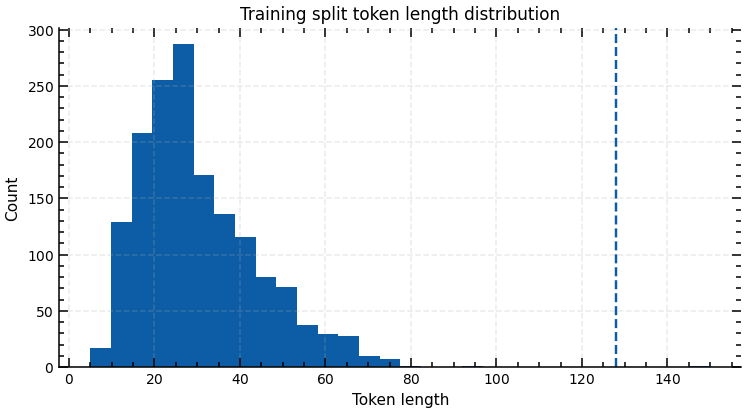

In [15]:
def batch_token_lengths(texts, batch_size=64):
    lengths = []
    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        enc = tokenizer(batch_texts, truncation=False, padding=False)
        lengths.extend(len(ids) for ids in enc["input_ids"])
    return lengths

train_lengths = batch_token_lengths(split_frames["train"]["sentence"].tolist())

length_stats = pd.Series(train_lengths).describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame("token_length")
display(length_stats)

plt.figure(figsize=(8, 4))
plt.hist(train_lengths, bins=30)
plt.axvline(CFG["max_length"], linestyle="--")
plt.title("Training split token length distribution")
plt.xlabel("Token length")
plt.ylabel("Count")
plt.show()


## How to read the token-length distribution

The point of choosing `max_length` isn't to make it as large as possible. It's a trade-off between keeping all the information in the sentence and not paying for empty padding everywhere.

Three regimes show up in practice. If most training sentences sit well below 128, the budget is too generous and Round 2 can shrink it. If the 95th percentile is close to 128, the budget is about right. If a meaningful tail goes past 128, then truncation is throwing information away and either the budget needs to grow or the strategy needs to change. Round 2 revisits this once we see the actual distribution.


In [16]:
def tokenize_batch(batch):
    return tokenizer(
        batch["sentence"],
        truncation=True,
        max_length=CFG["max_length"],
    )

tokenized_ds = split_ds.map(tokenize_batch, batched=True)

columns_to_keep = ["sentence", "label", "labels", "input_ids", "attention_mask"]
for split_name in tokenized_ds.keys():
    drop_cols = [c for c in tokenized_ds[split_name].column_names if c not in columns_to_keep]
    tokenized_ds[split_name] = tokenized_ds[split_name].remove_columns(drop_cols)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

def make_loader(split_name: str, shuffle: bool = False):
    batch_size = CFG["train_batch_size"] if split_name == "train" else CFG["eval_batch_size"]
    ds = tokenized_ds[split_name]

    def collate_fn(batch):
        compact_batch = []
        for item in batch:
            compact_batch.append({
                "input_ids": item["input_ids"],
                "attention_mask": item["attention_mask"],
                "labels": item["labels"],
            })
        return data_collator(compact_batch)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_fn,
    )

train_loader = make_loader("train", shuffle=True)
val_loader = make_loader("validation", shuffle=False)
test_loader = make_loader("test", shuffle=False)

sample_batch = next(iter(train_loader))
for k, v in sample_batch.items():
    print(k, tuple(v.shape))


Map:   0%|          | 0/1584 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

input_ids (16, 48)
attention_mask (16, 48)
labels (16,)


In [17]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def parameter_table(model, only_trainable=False):
    rows = []
    for name, p in model.named_parameters():
        if only_trainable and not p.requires_grad:
            continue
        rows.append({
            "name": name,
            "shape": tuple(p.shape),
            "num_params": p.numel(),
            "requires_grad": p.requires_grad,
        })
    return pd.DataFrame(rows)

def freeze_module(module):
    for p in module.parameters():
        p.requires_grad = False

def unfreeze_module(module):
    for p in module.parameters():
        p.requires_grad = True

def get_loss_and_logits(outputs, labels=None):
    if isinstance(outputs, dict):
        loss = outputs.get("loss", None)
        logits = outputs["logits"]
    else:
        loss = getattr(outputs, "loss", None)
        logits = getattr(outputs, "logits", None)
        if logits is None:
            logits = outputs[0]
    if loss is None and labels is not None:
        loss = F.cross_entropy(logits, labels)
    return loss, logits

def compute_metrics(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_f1": f1_weighted,
    }

    report_df = pd.DataFrame(
        classification_report(
            y_true,
            y_pred,
            target_names=LABEL_ORDER,
            output_dict=True,
            zero_division=0,
        )
    ).T

    return metrics, report_df

@torch.no_grad()
def evaluate_model(model, loader, source_df, device=DEVICE):
    model.eval()
    model.to(device)

    all_logits = []
    all_labels = []
    running_loss = 0.0
    n_examples = 0

    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss, logits = get_loss_and_logits(outputs, labels=batch["labels"])

        running_loss += loss.item() * batch["labels"].size(0)
        n_examples += batch["labels"].size(0)

        all_logits.append(logits.detach().cpu())
        all_labels.append(batch["labels"].detach().cpu())

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds = probs.argmax(axis=1)

    metrics, report_df = compute_metrics(labels, preds)
    metrics["loss"] = running_loss / max(1, n_examples)

    pred_df = source_df.copy().reset_index(drop=True)
    pred_df["gold_id"] = labels
    pred_df["pred_id"] = preds
    pred_df["gold_label"] = [id2label[i] for i in labels]
    pred_df["pred_label"] = [id2label[i] for i in preds]
    pred_df["confidence"] = probs.max(axis=1)

    for idx, label_name in id2label.items():
        pred_df[f"p_{label_name}"] = probs[:, idx]

    cm = confusion_matrix(labels, preds, labels=list(id2label.keys()))

    return {
        "metrics": metrics,
        "report_df": report_df,
        "predictions_df": pred_df,
        "confusion_matrix": cm,
    }

def plot_history(history_df, title):
    if history_df is None or len(history_df) == 0:
        print("No history to plot.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
    axes[0].set_title(f"{title} | Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="val_accuracy")
    axes[1].plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="val_macro_f1")
    axes[1].set_title(f"{title} | Validation metrics")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.show()

def plot_confusion(eval_obj, title):
    cm = eval_obj["confusion_matrix"]
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_ORDER)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title)
    plt.show()

def show_top_errors(eval_obj, n=10, highest_confidence_first=True):
    df = eval_obj["predictions_df"].copy()
    wrong = df[df["gold_id"] != df["pred_id"]].copy()
    wrong = wrong.sort_values("confidence", ascending=not highest_confidence_first)
    cols = ["sentence", "gold_label", "pred_label", "confidence"] + [f"p_{l}" for l in LABEL_ORDER]
    return wrong.head(n)[cols]

def show_low_confidence_cases(eval_obj, n=10):
    df = eval_obj["predictions_df"].copy()
    cols = ["sentence", "gold_label", "pred_label", "confidence"] + [f"p_{l}" for l in LABEL_ORDER]
    return df.sort_values("confidence", ascending=True).head(n)[cols]

def deep_dive_report(model_name, eval_obj, history_df=None, reference_eval=None):
    metrics = eval_obj["metrics"]
    report_df = eval_obj["report_df"].loc[LABEL_ORDER, ["precision", "recall", "f1-score", "support"]].copy()
    pred_df = eval_obj["predictions_df"]
    cm = eval_obj["confusion_matrix"].copy()

    print("=" * 80)
    print(f"Deep dive: {model_name}")
    print("=" * 80)
    print(
        f"loss={metrics['loss']:.4f} | "
        f"accuracy={metrics['accuracy']:.4f} | "
        f"macro_f1={metrics['macro_f1']:.4f} | "
        f"weighted_f1={metrics['weighted_f1']:.4f}"
    )

    if reference_eval is not None:
        ref = reference_eval["metrics"]
        print(
            f"vs reference -> Δaccuracy={metrics['accuracy'] - ref['accuracy']:+.4f}, "
            f"Δmacro_f1={metrics['macro_f1'] - ref['macro_f1']:+.4f}, "
            f"Δloss={metrics['loss'] - ref['loss']:+.4f}"
        )

    print("\nClass-wise report:")
    display(report_df.round(4))

    weakest_class = report_df["f1-score"].idxmin()
    strongest_class = report_df["f1-score"].idxmax()
    print(f"Weakest class right now: {weakest_class}")
    print(f"Strongest class right now: {strongest_class}")

    acc_macro_gap = metrics["accuracy"] - metrics["macro_f1"]
    if acc_macro_gap > 0.08:
        print("Interpretation: accuracy is noticeably higher than macro F1 -> some classes are still much weaker than others.")
    else:
        print("Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.")

    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    if cm_no_diag.sum() > 0:
        i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
        print(f"Most frequent confusion: true='{id2label[i]}' predicted='{id2label[j]}' (count={cm_no_diag[i, j]})")
    else:
        print("No off-diagonal errors found.")

    wrong = pred_df[pred_df["gold_id"] != pred_df["pred_id"]].copy()
    if len(wrong) > 0:
        print(f"Number of wrong predictions: {len(wrong)} / {len(pred_df)}")
        print(f"Median confidence on wrong predictions: {wrong['confidence'].median():.4f}")
        if wrong["confidence"].median() > 0.70:
            print("Interpretation: many mistakes are high-confidence -> features may be systematically misleading, not just noisy.")
        elif wrong["confidence"].median() > 0.50:
            print("Interpretation: mistakes are mixed-confidence -> both representation quality and boundary sharpness matter.")
        else:
            print("Interpretation: many mistakes are low-confidence -> the model often knows it is uncertain.")
    else:
        print("No wrong predictions on this split.")

    if history_df is not None and len(history_df) >= 2:
        last_row = history_df.iloc[-1]
        generalization_gap = last_row["val_loss"] - last_row["train_loss"]
        print(f"Approx. last-epoch generalization gap (val_loss - train_loss): {generalization_gap:+.4f}")
        if generalization_gap > 0.15:
            print("Interpretation: validation loss is notably higher than training loss -> watch for overfitting.")
        elif generalization_gap < -0.05:
            print("Interpretation: validation loss lower than training loss -> training may still be conservative / underfit.")
        else:
            print("Interpretation: train/validation losses are in a relatively healthy range.")

    print("\nSuggested next-step questions:")
    print("- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?")
    print("- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?")
    print("- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?")

def register_result(results_store, model_name, model, val_eval, test_eval, notes=""):
    total_params, trainable_params = count_parameters(model)
    results_store.append({
        "model": model_name,
        "notes": notes,
        "total_params": total_params,
        "trainable_params": trainable_params,
        "trainable_pct": trainable_params / total_params,
        "val_accuracy": val_eval["metrics"]["accuracy"],
        "val_macro_f1": val_eval["metrics"]["macro_f1"],
        "test_accuracy": test_eval["metrics"]["accuracy"],
        "test_macro_f1": test_eval["metrics"]["macro_f1"],
        "test_loss": test_eval["metrics"]["loss"],
    })

def cleanup():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [18]:
def fit_model(
    model,
    train_loader,
    val_loader,
    train_df,
    val_df,
    *,
    epochs,
    lr,
    weight_decay,
    warmup_ratio,
    clip_grad_norm,
    device=DEVICE,
    model_name="model",
):
    model.to(device)

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    assert len(trainable_params) > 0, f"{model_name}: no trainable parameters found."

    optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    total_steps = max(1, epochs * len(train_loader))
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = []
    best_state = None
    best_val_f1 = -float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_examples = 0

        progress = tqdm(train_loader, desc=f"{model_name} | epoch {epoch}/{epochs}", leave=False)
        for batch in progress:
            batch = {k: v.to(device) for k, v in batch.items()}

            optimizer.zero_grad()
            outputs = model(**batch)
            loss, logits = get_loss_and_logits(outputs, labels=batch["labels"])
            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(trainable_params, clip_grad_norm)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * batch["labels"].size(0)
            n_examples += batch["labels"].size(0)
            progress.set_postfix(loss=f"{loss.item():.4f}", grad=f"{float(grad_norm):.2f}")

        train_loss = running_loss / max(1, n_examples)
        val_eval = evaluate_model(model, val_loader, val_df, device=device)

        epoch_result = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_eval["metrics"]["loss"],
            "val_accuracy": val_eval["metrics"]["accuracy"],
            "val_macro_f1": val_eval["metrics"]["macro_f1"],
        }
        history.append(epoch_result)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_eval['metrics']['loss']:.4f} | "
            f"val_acc={val_eval['metrics']['accuracy']:.4f} | "
            f"val_macro_f1={val_eval['metrics']['macro_f1']:.4f}"
        )

        if val_eval["metrics"]["macro_f1"] > best_val_f1:
            best_val_f1 = val_eval["metrics"]["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())

    history_df = pd.DataFrame(history)
    if best_state is not None:
        model.load_state_dict(best_state)

    best_val_eval = evaluate_model(model, val_loader, val_df, device=device)
    return model, history_df, best_val_eval


## Sanity baseline — majority-class predictor

Before any neural model, the constant-prediction baseline (always predict whichever label is most common in training) gives a meaningful floor. Anything below this baseline isn't learning the task. If a later model lands below it, the right move is not to add architectural complexity but to check the split, the label mapping, the training loop, and whether parameters are actually being updated.

The numbers below are this baseline on validation and test.


Majority label from train split: neutral
Validation metrics: {'accuracy': 0.6147058823529412, 'macro_precision': 0.20490196078431375, 'macro_recall': 0.3333333333333333, 'macro_f1': 0.2537947783849423, 'weighted_f1': 0.46802742955105536, 'loss': nan}
Test metrics: {'accuracy': 0.6147058823529412, 'macro_precision': 0.20490196078431375, 'macro_recall': 0.3333333333333333, 'macro_f1': 0.2537947783849423, 'weighted_f1': 0.46802742955105536, 'loss': nan}


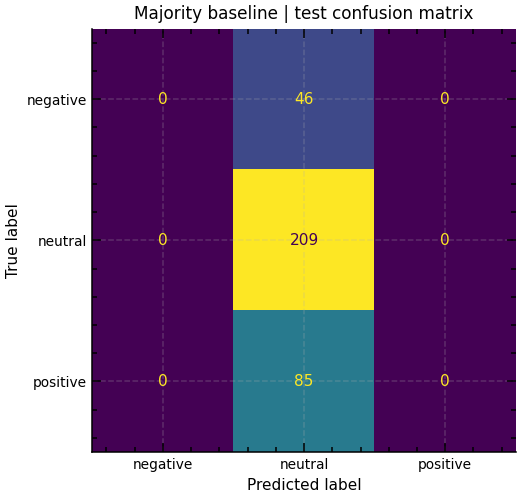

Deep dive: Majority baseline
loss=nan | accuracy=0.6147 | macro_f1=0.2538 | weighted_f1=0.4680

Class-wise report:


,precision,recall,f1-score,support
negative,0.0000,0.0,0.0000,46.0
neutral,0.6147,1.0,0.7614,209.0
positive,0.0000,0.0,0.0000,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy is noticeably higher than macro F1 -> some classes are still much weaker than others.
Most frequent confusion: true='positive' predicted='neutral' (count=85)
Number of wrong predictions: 131 / 340
Median confidence on wrong predictions: 1.0000
Interpretation: many mistakes are high-confidence -> features may be systematically misleading, not just noisy.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [19]:
def evaluate_constant_baseline(source_df, constant_label: str):
    y_true = source_df["label"].map(label2id).values
    y_pred = np.array([label2id[constant_label]] * len(source_df))
    metrics, report_df = compute_metrics(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=list(id2label.keys()))

    pred_df = source_df.copy().reset_index(drop=True)
    pred_df["gold_id"] = y_true
    pred_df["pred_id"] = y_pred
    pred_df["gold_label"] = [id2label[i] for i in y_true]
    pred_df["pred_label"] = [id2label[i] for i in y_pred]
    pred_df["confidence"] = 1.0

    for label_name in LABEL_ORDER:
        pred_df[f"p_{label_name}"] = 0.0
    pred_df[f"p_{constant_label}"] = 1.0

    metrics["loss"] = np.nan
    return {
        "metrics": metrics,
        "report_df": report_df,
        "predictions_df": pred_df,
        "confusion_matrix": cm,
    }

majority_label = split_frames["train"]["label"].value_counts().idxmax()
majority_val = evaluate_constant_baseline(split_frames["validation"], majority_label)
majority_test = evaluate_constant_baseline(split_frames["test"], majority_label)

print("Majority label from train split:", majority_label)
print("Validation metrics:", majority_val["metrics"])
print("Test metrics:", majority_test["metrics"])
plot_confusion(majority_test, "Majority baseline | test confusion matrix")
deep_dive_report("Majority baseline", majority_test)


# Stage 2 — Round 1: minimum runs of all five regimes

Round 1 is deliberately small-bore. Each of the five models is implemented end-to-end and trained with the default hyperparameters from `CFG`; tuning is left to Round 2. The reasoning is attribution. If I varied architecture, training protocol, and hyperparameter search all at once, any difference at the end couldn't be cleanly attributed to one factor. So Round 1 first.

Each of the five models is introduced individually with a short statement of what it's actually testing.


In [20]:
def build_model_pt(seed=None):
    if seed is not None:
        set_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(
        CFG["model_name"],
        num_labels=len(LABEL_ORDER),
        id2label=id2label,
        label2id=label2id,
    )
    return model

def show_parameter_summary(model, model_name, only_trainable=True, top_n=30):
    total_params, trainable_params = count_parameters(model)
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(f"Total params     : {total_params:,}")
    print(f"Trainable params : {trainable_params:,}")
    print(f"Trainable ratio  : {trainable_params / total_params:.6f}")

    df = parameter_table(model, only_trainable=only_trainable)
    if len(df) == 0:
        print("No trainable parameters.")
    else:
        display(df.head(top_n))

def freeze_all_but_default_head(model):
    freeze_module(model.distilbert)
    unfreeze_module(model.pre_classifier)
    unfreeze_module(model.classifier)

def freeze_default_head_unfreeze_body(model):
    freeze_module(model.pre_classifier)
    freeze_module(model.classifier)
    unfreeze_module(model.distilbert)

RESULTS = []


## Model 1 — Model PT

### What this configuration tests

Model 1 takes the pretrained DistilBERT body and a freshly initialised head, and doesn't train anything. Its score reflects whatever signal the general-purpose pretrained representation already has for financial sentiment, with no task adaptation at all.


In [21]:
model1 = build_model_pt(seed=CFG["seed"])

print("Default DistilBERT classifier head:")
print("pre_classifier:", model1.pre_classifier)
print("dropout       :", model1.dropout)
print("classifier    :", model1.classifier)

show_parameter_summary(model1, "Model PT | parameter summary", only_trainable=True)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Default DistilBERT classifier head:
pre_classifier: Linear(in_features=768, out_features=768, bias=True)
dropout       : Dropout(p=0.2, inplace=False)
classifier    : Linear(in_features=768, out_features=3, bias=True)
Model PT | parameter summary
Total params     : 66,955,779
Trainable params : 66,955,779
Trainable ratio  : 1.000000


,name,shape,num_params,requires_grad
0,distilbert.embeddings.word_embeddings.weight,"(30522, 768)",23440896,True
1,distilbert.embeddings.position_embeddings.weight,"(512, 768)",393216,True
2,distilbert.embeddings.LayerNorm.weight,"(768,)",768,True
3,distilbert.embeddings.LayerNorm.bias,"(768,)",768,True
4,distilbert.transformer.layer.0.attention.q_lin.weight,"(768, 768)",589824,True
5,distilbert.transformer.layer.0.attention.q_lin.bias,"(768,)",768,True
6,distilbert.transformer.layer.0.attention.k_lin.weight,"(768, 768)",589824,True
7,distilbert.transformer.layer.0.attention.k_lin.bias,"(768,)",768,True
8,distilbert.transformer.layer.0.attention.v_lin.weight,"(768, 768)",589824,True
9,distilbert.transformer.layer.0.attention.v_lin.bias,"(768,)",768,True


Model 1 | validation metrics: {'accuracy': 0.36176470588235293, 'macro_precision': 0.4358001087618753, 'macro_recall': 0.3928514026433243, 'macro_f1': 0.3425324675324675, 'weighted_f1': 0.39440889992360584, 'loss': 1.1007974736830768}
Model 1 | test metrics      : {'accuracy': 0.3205882352941177, 'macro_precision': 0.41936486920237526, 'macro_recall': 0.3350587582651117, 'macro_f1': 0.30088273226254825, 'weighted_f1': 0.35826099283340634, 'loss': 1.1030596648945528}


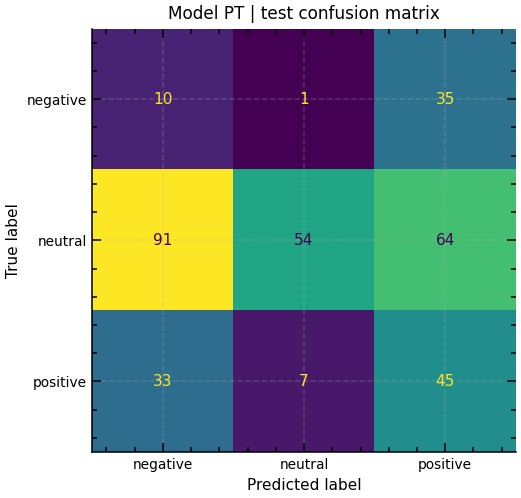

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
110,The operating margin of Aker Yards Cruise & Ferries division went down from 8.3 % to 6.4 % in the first quarter of 2...,negative,positive,0.363321,0.314695,0.321984,0.363321
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,neutral,0.359426,0.320077,0.359426,0.320496
136,"He joins Technopolis from KONE where he has held various positions within the Group , most recently as Director of S...",neutral,negative,0.357485,0.357485,0.314712,0.327803
179,"Changes being announced today will be effective after the close of trading on Friday , June 19 , 2009 .",neutral,positive,0.356554,0.311856,0.331591,0.356554
47,Fancy Dans on the move FAB Glasgow gift and interiors store Fancy Dans is moving !,neutral,positive,0.355069,0.327570,0.317361,0.355069
127,The soapstone deposits in the Medvezhyegorsk area are expected to increase Tulikivi 's current reserves considerably .,positive,neutral,0.354271,0.323502,0.354271,0.322226
17,The bond has a value of EUR150m and a maturity of 4 years .,neutral,negative,0.353007,0.353007,0.318166,0.328826
217,"Marathon now has a 4.6 percent stake in PLX , it said , according to Bloomberg .",neutral,positive,0.352489,0.334694,0.312817,0.352489


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
108,The transaction is expected to be completed next spring .,neutral,negative,0.333839,0.333839,0.333032,0.333129
333,"The company operates its business through two reportable segments , including Banking and Investment Services , and ...",neutral,positive,0.334046,0.332805,0.333150,0.334046
41,"Systeemitiimi 's sales and project resources will also be strengthened , director Paul Skogberg said .",positive,negative,0.334167,0.334167,0.332607,0.333226
251,"RFID ( Radio Frequency Identification ) is a method of so-called intelligent transport , whereby information can be ...",neutral,negative,0.334264,0.334264,0.332994,0.332742
339,"Operating profit , excluding non-recurring items , totalled EUR 1.0 mn , down from EUR 1.6 mn .",negative,positive,0.334285,0.333657,0.332058,0.334285
195,"Financial Statements include the consolidated financial statements of the Group , the Board of Directors ' Report , ...",neutral,neutral,0.334292,0.332937,0.334292,0.332771
296,`` Printed fabrics and related design expertise have always been the core of Marimekko 's business and brand .,neutral,negative,0.334299,0.334299,0.331431,0.334269
202,"They can be used to control the speed of electric motors used by industry and municipal engineering , and in power g...",neutral,neutral,0.334413,0.332894,0.334413,0.332693


Deep dive: Model PT
loss=1.1031 | accuracy=0.3206 | macro_f1=0.3009 | weighted_f1=0.3583
vs reference -> Δaccuracy=-0.2941, Δmacro_f1=+0.0471, Δloss=+nan

Class-wise report:


,precision,recall,f1-score,support
negative,0.0746,0.2174,0.1111,46.0
neutral,0.8710,0.2584,0.3985,209.0
positive,0.3125,0.5294,0.3930,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='neutral' predicted='negative' (count=91)
Number of wrong predictions: 231 / 340
Median confidence on wrong predictions: 0.3415
Interpretation: many mistakes are low-confidence -> the model often knows it is uncertain.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [22]:
# Model 1 is not trained — evaluate the random-head model directly.
model1_val = evaluate_model(model1, val_loader, split_frames["validation"])
model1_test = evaluate_model(model1, test_loader, split_frames["test"])

print("Model 1 | validation metrics:", model1_val["metrics"])
print("Model 1 | test metrics      :", model1_test["metrics"])

plot_confusion(model1_test, "Model PT | test confusion matrix")
display(show_top_errors(model1_test, n=8))
display(show_low_confidence_cases(model1_test, n=8))
deep_dive_report("Model PT", model1_test, reference_eval=majority_test)

register_result(
    RESULTS,
    "Model PT",
    model1,
    model1_val,
    model1_test,
    notes="No financial fine-tuning; default HF classifier head only",
)


### Reading Model 1's results

The score is roughly what you'd expect: near-random. The classifier head is randomly initialised and never updated, so any signal has to come from incidental alignment between the pretrained representation and the task. There's no reason that alignment would be strong.

Three readings are worth distinguishing. Near-random is normal. Modestly above random would mean the pretrained representation contains some general semantic structure, but no specifically financial decision boundary has been learned. Strongly above random would be unexpected — I'd want to check for a leak in the split, a checkpoint that was actually fine-tuned somewhere, or an off-by-one in the label mapping.

Either way, Model 1 acts as a floor. Any improvement later in the notebook can be checked against it: did the gain come from the head learning the task, the body learning finance, or both?


## Model 2 — Model PT + FT Classifier

### What this does

Start from Model PT. Freeze the DistilBERT body. Train only the default classifier head.

### What this tests

How far can a fresh classifier head go on top of a fixed pretrained representation, without changing the representation? It's a clean question because the representation is held still — only one decision boundary is being learned.

A big jump over Model 1 would mean the pretrained representation already has the signal, just nobody has learned the boundary yet. A small jump would mean the representation itself isn't enough and head-only adaptation has hit a ceiling.


In [23]:
model2 = build_model_pt(seed=CFG["seed"])
freeze_all_but_default_head(model2)
show_parameter_summary(model2, "Model PT + FT Classifier | trainable parameters", only_trainable=True)

model2, model2_history, model2_best_val = fit_model(
    model2,
    train_loader,
    val_loader,
    split_frames["train"],
    split_frames["validation"],
    epochs=CFG["head_only_epochs"],
    lr=CFG["head_only_lr"],
    weight_decay=CFG["weight_decay"],
    warmup_ratio=CFG["warmup_ratio"],
    clip_grad_norm=CFG["clip_grad_norm"],
    device=DEVICE,
    model_name="Model 2",
)

model2_val = evaluate_model(model2, val_loader, split_frames["validation"])
model2_test = evaluate_model(model2, test_loader, split_frames["test"])

best_model2_state = copy.deepcopy(model2.state_dict())


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model PT + FT Classifier | trainable parameters
Total params     : 66,955,779
Trainable params : 592,899
Trainable ratio  : 0.008855


,name,shape,num_params,requires_grad
0,pre_classifier.weight,"(768, 768)",589824,True
1,pre_classifier.bias,"(768,)",768,True
2,classifier.weight,"(3, 768)",2304,True
3,classifier.bias,"(3,)",3,True


Model 2 | epoch 1/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.6811 | val_loss=0.4841 | val_acc=0.7676 | val_macro_f1=0.6627


Model 2 | epoch 2/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4408 | val_loss=0.3977 | val_acc=0.8235 | val_macro_f1=0.7304


Model 2 | epoch 3/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.3730 | val_loss=0.3728 | val_acc=0.8265 | val_macro_f1=0.7331


Model 2 | epoch 4/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.3403 | val_loss=0.3587 | val_acc=0.8441 | val_macro_f1=0.7406


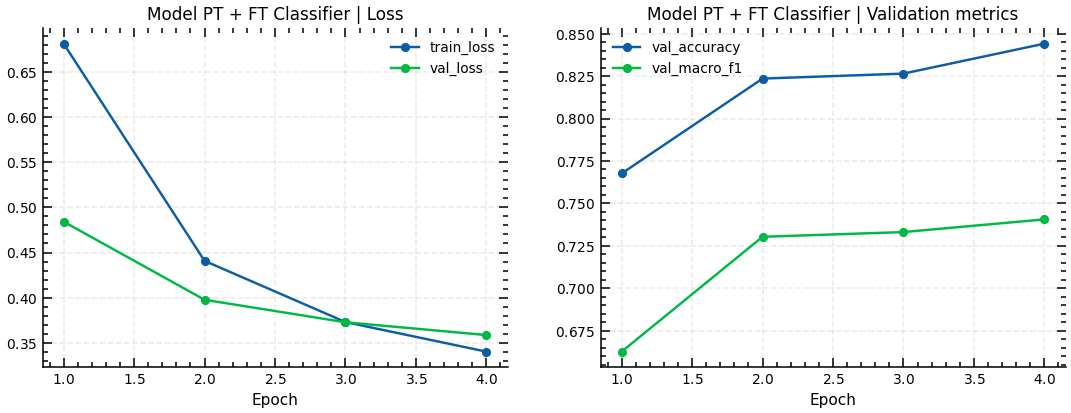

Model 2 | validation metrics: {'accuracy': 0.8441176470588235, 'macro_precision': 0.7775128743086018, 'macro_recall': 0.7268173369764557, 'macro_f1': 0.7406108508620135, 'weighted_f1': 0.8380114789274431, 'loss': 0.358659766702091}
Model 2 | test metrics      : {'accuracy': 0.8205882352941176, 'macro_precision': 0.7608293438793682, 'macro_recall': 0.7102375212618851, 'macro_f1': 0.7242317354258928, 'weighted_f1': 0.8159889674461969, 'loss': 0.3866325837724349}


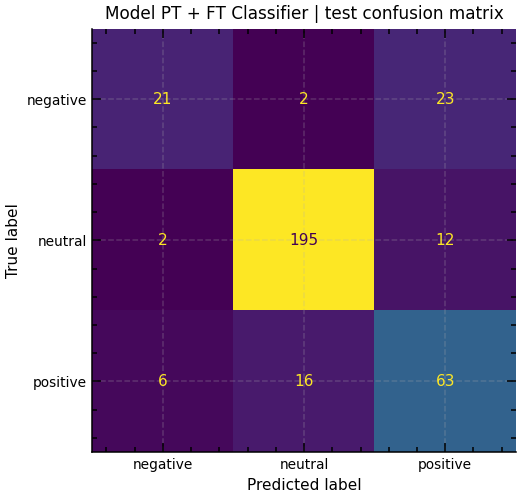

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
263,"These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has suff...",positive,neutral,0.985404,0.000328,0.985404,0.014268
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,neutral,0.970130,0.000661,0.970130,0.029209
150,Cargotec Germany GmbH has been awarded a contract by Stadtverwaltung Mainz for chassis bodies under Open procedure .,positive,neutral,0.952725,0.000746,0.952725,0.046529
159,Viking Line manages well with its current ferries .,positive,neutral,0.928231,0.009671,0.928231,0.062098
42,"OUTOTEC OYJ PRESS RELEASE , FEBRUARY 19 , 2008 AT 11.00 AM Outotec has won two large minerals processing technology ...",positive,neutral,0.870322,0.003521,0.870322,0.126157
286,"Citigroup , Inc ( NYSE : C ) has announced that its Global Transaction Services ( GTS ) business has been awarded a ...",positive,neutral,0.846274,0.006627,0.846274,0.147100
99,No changes in media activity were seen in October compared with September .,neutral,negative,0.837635,0.837635,0.020725,0.141640
160,Motorola Inc. of the United States came second with shipments of 217.4 million units for a 21.3 percent market share...,neutral,positive,0.793913,0.123493,0.082594,0.793913


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
141,UPM-Kymmene said its has ` not indicated any interest in any domestic consolidations ' .,neutral,positive,0.393683,0.215317,0.391001,0.393683
167,These moderate but significant changes resulted in a significant 24-32 % reduction in the estimated CVD risk .,positive,negative,0.403715,0.403715,0.376850,0.219436
110,The operating margin of Aker Yards Cruise & Ferries division went down from 8.3 % to 6.4 % in the first quarter of 2...,negative,positive,0.418112,0.367636,0.214252,0.418112
339,"Operating profit , excluding non-recurring items , totalled EUR 1.0 mn , down from EUR 1.6 mn .",negative,positive,0.437503,0.347202,0.215295,0.437503
295,"The company 's operating income ( EBIT ) totalled EUR 0.0 mn , up from EUR -0.3 mn year-on-year .",positive,positive,0.476437,0.100272,0.423291,0.476437
327,"ADP News - Nov 13 , 2008 - Finnish printed circuit board PCB maker Aspocomp Group Oyj OMX : ACG1V said today that it...",positive,negative,0.476943,0.476943,0.131884,0.391174
62,"Operating profit , excluding non-recurring items , totaled EUR 0.2 mn , down from EUR 0.8 mn in the corresponding pe...",negative,negative,0.479424,0.479424,0.088306,0.432270
186,Operating profit fell to EUR 15.1 mn from EUR 24.6 mn in 2006 .,negative,negative,0.484098,0.484098,0.032444,0.483457


Deep dive: Model PT + FT Classifier
loss=0.3866 | accuracy=0.8206 | macro_f1=0.7242 | weighted_f1=0.8160
vs reference -> Δaccuracy=+0.5000, Δmacro_f1=+0.4233, Δloss=-0.7164

Class-wise report:


,precision,recall,f1-score,support
negative,0.7241,0.4565,0.5600,46.0
neutral,0.9155,0.9330,0.9242,209.0
positive,0.6429,0.7412,0.6885,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy is noticeably higher than macro F1 -> some classes are still much weaker than others.
Most frequent confusion: true='negative' predicted='positive' (count=23)
Number of wrong predictions: 61 / 340
Median confidence on wrong predictions: 0.6076
Interpretation: mistakes are mixed-confidence -> both representation quality and boundary sharpness matter.
Approx. last-epoch generalization gap (val_loss - train_loss): +0.0183
Interpretation: train/validation losses are in a relatively healthy range.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [24]:
plot_history(model2_history, "Model PT + FT Classifier")
print("Model 2 | validation metrics:", model2_val["metrics"])
print("Model 2 | test metrics      :", model2_test["metrics"])

plot_confusion(model2_test, "Model PT + FT Classifier | test confusion matrix")
display(show_top_errors(model2_test, n=8))
display(show_low_confidence_cases(model2_test, n=8))
deep_dive_report("Model PT + FT Classifier", model2_test, history_df=model2_history, reference_eval=model1_test)

register_result(
    RESULTS,
    "Model PT + FT Classifier",
    model2,
    model2_val,
    model2_test,
    notes="Default head trained; DistilBERT body frozen",
)


### Reading Model 2's results

Three things to look at.

First, how big is the gain over Model 1? A large one means the fixed representation has plenty of usable structure. A small one means head-only adaptation can't extract enough.

Second, the confusion matrix. If `neutral` is regularly being mistaken for the polarity classes, the boundary isn't sharp. If a particular class has very low recall, the model rarely predicts it — class weighting or label smoothing in Round 2 might help.

Third, confidence on errors. Median confidence on wrong predictions is informative. If it's high, the errors are confident — usually a representation problem rather than a boundary problem. If it's low, the model is just uncertain at the edge — sharper training or a better-shaped loss might fix it.


## Model 3 — Model PT + Own FT Classifier

### Head design

DistilBERT's default sequence-classification head is roughly `768 → 768 → 3`. I replace it with a deeper bottlenecked MLP: `768 → 256 → 64 → 3`, with `ReLU + Dropout` between layers.

### What's actually different

Three things distinguish this head from the default. It's deeper. It has an explicit bottleneck (the 64-dim layer in the middle). And the combined non-linearities are more expressive than the default's single projection.

### Why this might help

With the body frozen, the head has to do all the work of mapping a fixed representation onto the labels. A deeper head can in principle learn a more complex mapping. The bottleneck might force compression into more discriminative features. Dropout might help generalisation given the small training set. None of these are guaranteed, which is exactly the point of running the experiment.

### Things that go wrong easily

Grafting a custom head onto a pretrained body has a few common pitfalls. The backbone returns `(batch, seq_len, hidden_dim)`; the head needs the right pooled position. The head's input dimension has to match the backbone's hidden size. The final logits have to be `(batch_size, 3)`. The implementation makes each of these explicit.


In [25]:
class DistilBertWithCustomHead(nn.Module):
    def __init__(
        self,
        base_model_name,
        num_labels,
        hidden_dims=(256, 64),
        dropout=0.30,
        id2label=None,
        label2id=None,
    ):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(base_model_name)
        hidden_size = getattr(self.backbone.config, "hidden_size", None)
        if hidden_size is None:
            hidden_size = getattr(self.backbone.config, "dim")

        self.classifier_head = nn.Sequential(
            nn.Linear(hidden_size, hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[0], hidden_dims[1]),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], num_labels),
        )

        self.num_labels = num_labels
        self.id2label = id2label if id2label is not None else {i: str(i) for i in range(num_labels)}
        self.label2id = label2id if label2id is not None else {v: k for k, v in self.id2label.items()}

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        cls_state = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier_head(cls_state)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )

def freeze_backbone_unfreeze_custom_head(model):
    freeze_module(model.backbone)
    unfreeze_module(model.classifier_head)


In [26]:
model3 = DistilBertWithCustomHead(
    base_model_name=CFG["model_name"],
    num_labels=len(LABEL_ORDER),
    hidden_dims=CFG["custom_head_hidden_dims"],
    dropout=CFG["custom_head_dropout"],
    id2label=id2label,
    label2id=label2id,
)

freeze_backbone_unfreeze_custom_head(model3)
show_parameter_summary(model3, "Model PT + Own FT Classifier | trainable parameters", only_trainable=True)

model3, model3_history, model3_best_val = fit_model(
    model3,
    train_loader,
    val_loader,
    split_frames["train"],
    split_frames["validation"],
    epochs=CFG["custom_head_epochs"],
    lr=CFG["custom_head_lr"],
    weight_decay=CFG["weight_decay"],
    warmup_ratio=CFG["warmup_ratio"],
    clip_grad_norm=CFG["clip_grad_norm"],
    device=DEVICE,
    model_name="Model 3",
)

model3_val = evaluate_model(model3, val_loader, split_frames["validation"])
model3_test = evaluate_model(model3, test_loader, split_frames["test"])


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model PT + Own FT Classifier | trainable parameters
Total params     : 66,576,387
Trainable params : 213,507
Trainable ratio  : 0.003207


,name,shape,num_params,requires_grad
0,classifier_head.0.weight,"(256, 768)",196608,True
1,classifier_head.0.bias,"(256,)",256,True
2,classifier_head.3.weight,"(64, 256)",16384,True
3,classifier_head.3.bias,"(64,)",64,True
4,classifier_head.6.weight,"(3, 64)",192,True
5,classifier_head.6.bias,"(3,)",3,True


Model 3 | epoch 1/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.8804 | val_loss=0.6220 | val_acc=0.7412 | val_macro_f1=0.4754


Model 3 | epoch 2/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.5705 | val_loss=0.4925 | val_acc=0.7794 | val_macro_f1=0.5218


Model 3 | epoch 3/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4984 | val_loss=0.4685 | val_acc=0.7735 | val_macro_f1=0.5201


Model 3 | epoch 4/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.4840 | val_loss=0.4617 | val_acc=0.7853 | val_macro_f1=0.5276


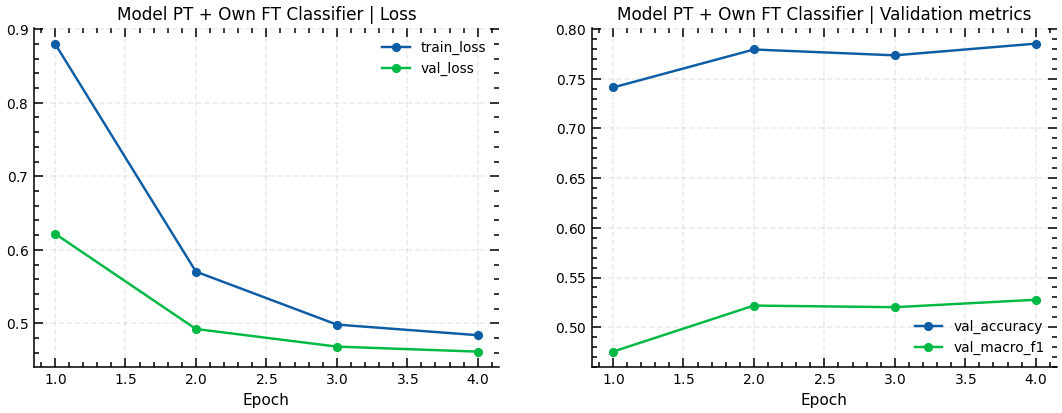

Model 3 | validation metrics: {'accuracy': 0.7852941176470588, 'macro_precision': 0.4891414141414141, 'macro_recall': 0.5786691888283076, 'macro_f1': 0.5276287897647122, 'weighted_f1': 0.7376868895429718, 'loss': 0.46165238233173594}
Model 3 | test metrics      : {'accuracy': 0.7529411764705882, 'macro_precision': 0.46286634460547504, 'macro_recall': 0.5455671263720799, 'macro_f1': 0.49927803379416275, 'weighted_f1': 0.705550962320412, 'loss': 0.5116223913781783}


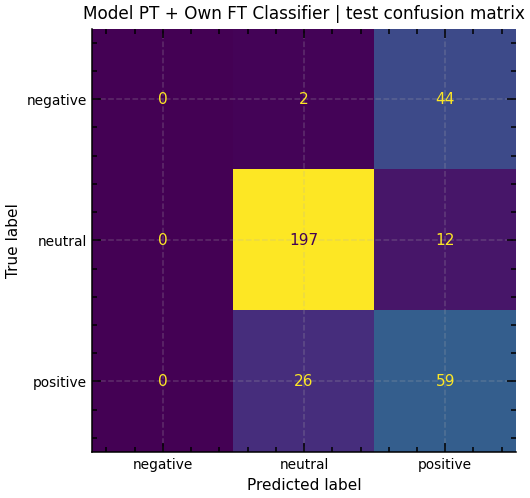

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
263,"These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has suff...",positive,neutral,0.988851,0.001466,0.988851,0.009682
150,Cargotec Germany GmbH has been awarded a contract by Stadtverwaltung Mainz for chassis bodies under Open procedure .,positive,neutral,0.983719,0.001929,0.983719,0.014352
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,neutral,0.973141,0.003611,0.973141,0.023247
42,"OUTOTEC OYJ PRESS RELEASE , FEBRUARY 19 , 2008 AT 11.00 AM Outotec has won two large minerals processing technology ...",positive,neutral,0.942178,0.009363,0.942178,0.048460
159,Viking Line manages well with its current ferries .,positive,neutral,0.929063,0.013719,0.929063,0.057217
286,"Citigroup , Inc ( NYSE : C ) has announced that its Global Transaction Services ( GTS ) business has been awarded a ...",positive,neutral,0.917547,0.013596,0.917547,0.068857
200,Biohit already services many current Genesis customers and the customer base is expected to expand as a result of th...,positive,neutral,0.903930,0.013786,0.903930,0.082284
11,Finnish Rautaruukki has been awarded a contract to supply and install steel superstructures for the Partihallsf+Ârbi...,positive,neutral,0.903103,0.014606,0.903103,0.082292


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
114,Another noticeable thing is that the search for Tata and Airtel brands was mostly related to ` broadband connections...,neutral,positive,0.412101,0.204679,0.383220,0.412101
126,The total capital of funds managed by the bank decreased by 28 % to EUR 284mn by the end of September 2008 .,negative,positive,0.427391,0.158387,0.414221,0.427391
167,These moderate but significant changes resulted in a significant 24-32 % reduction in the estimated CVD risk .,positive,neutral,0.439150,0.188861,0.439150,0.371990
175,"In a letter to Economic Affairs Minister , the listed Estonian shipping company Tallink asks for the approval to be ...",neutral,positive,0.439739,0.183620,0.376641,0.439739
110,The operating margin of Aker Yards Cruise & Ferries division went down from 8.3 % to 6.4 % in the first quarter of 2...,negative,positive,0.452057,0.191731,0.356212,0.452057
304,"The financial impact is estimated to be some 1.5 MEUR annual improvement in the division 's result , starting from f...",positive,neutral,0.452687,0.148362,0.452687,0.398951
22,The profit after taxes was EUR 57.7 11.1 million .,neutral,positive,0.457683,0.179903,0.362414,0.457683
284,The company had net sales of EUR 19.8 mn and a pre-tax profit of EUR 1.8 mn in 2005 .,neutral,neutral,0.469922,0.127485,0.469922,0.402593


Deep dive: Model PT + Own FT Classifier
loss=0.5116 | accuracy=0.7529 | macro_f1=0.4993 | weighted_f1=0.7056
vs reference -> Δaccuracy=-0.0676, Δmacro_f1=-0.2250, Δloss=+0.1250

Class-wise report:


,precision,recall,f1-score,support
negative,0.0000,0.0000,0.0000,46.0
neutral,0.8756,0.9426,0.9078,209.0
positive,0.5130,0.6941,0.5900,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy is noticeably higher than macro F1 -> some classes are still much weaker than others.
Most frequent confusion: true='negative' predicted='positive' (count=44)
Number of wrong predictions: 84 / 340
Median confidence on wrong predictions: 0.5710
Interpretation: mistakes are mixed-confidence -> both representation quality and boundary sharpness matter.
Approx. last-epoch generalization gap (val_loss - train_loss): -0.0224
Interpretation: train/validation losses are in a relatively healthy range.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [27]:
plot_history(model3_history, "Model PT + Own FT Classifier")
print("Model 3 | validation metrics:", model3_val["metrics"])
print("Model 3 | test metrics      :", model3_test["metrics"])

plot_confusion(model3_test, "Model PT + Own FT Classifier | test confusion matrix")
display(show_top_errors(model3_test, n=8))
display(show_low_confidence_cases(model3_test, n=8))
deep_dive_report("Model PT + Own FT Classifier", model3_test, history_df=model3_history, reference_eval=model2_test)

register_result(
    RESULTS,
    "Model PT + Own FT Classifier",
    model3,
    model3_val,
    model3_test,
    notes="Custom MLP head (768->256->64->3); backbone frozen",
)


### Reading Model 3's results

If Model 3 beats Model 2, the frozen representation has more signal than the default head was extracting and a different-shaped head can find it.

If Model 3 ties Model 2, the bottleneck is more likely the frozen backbone than the head's expressive capacity, and further investment in head architecture probably won't pay off without unfreezing the body.

If Model 3 loses to Model 2, the conclusion shouldn't be that custom heads are useless. The more likely culprits are the head being too big for the training set (overfitting), dropout set wrong, the bottleneck pinched too aggressively, or a learning rate that doesn't suit the new head. This actually happens in Round 1 and turns out to be the wrong-protocol kind of failure rather than the wrong-architecture kind — Round 2 fixes it.


## Model 4 — Model PT + FT Classifier + FT Base

### Where this starts

Model 4 starts from the trained Model 2 checkpoint. The head is already competent at the classification task. I freeze the head and train only the body.

### What this tests

Given that the head can already do the classification, how much does it help to let the body adapt to financial-domain language?

### Why holding the head fixed matters for attribution

If both head and body were updated jointly, any improvement could come from either. Holding the head fixed makes the experiment cleaner — observed gains can be ascribed to body adaptation specifically.


In [28]:
model4 = build_model_pt(seed=CFG["seed"])
model4.load_state_dict(best_model2_state)

freeze_default_head_unfreeze_body(model4)
show_parameter_summary(model4, "Model PT + FT Classifier + FT Base | trainable parameters", only_trainable=True)

model4, model4_history, model4_best_val = fit_model(
    model4,
    train_loader,
    val_loader,
    split_frames["train"],
    split_frames["validation"],
    epochs=CFG["body_only_epochs"],
    lr=CFG["body_only_lr"],
    weight_decay=CFG["weight_decay"],
    warmup_ratio=CFG["warmup_ratio"],
    clip_grad_norm=CFG["clip_grad_norm"],
    device=DEVICE,
    model_name="Model 4",
)

model4_val = evaluate_model(model4, val_loader, split_frames["validation"])
model4_test = evaluate_model(model4, test_loader, split_frames["test"])


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model PT + FT Classifier + FT Base | trainable parameters
Total params     : 66,955,779
Trainable params : 66,362,880
Trainable ratio  : 0.991145


,name,shape,num_params,requires_grad
0,distilbert.embeddings.word_embeddings.weight,"(30522, 768)",23440896,True
1,distilbert.embeddings.position_embeddings.weight,"(512, 768)",393216,True
2,distilbert.embeddings.LayerNorm.weight,"(768,)",768,True
3,distilbert.embeddings.LayerNorm.bias,"(768,)",768,True
4,distilbert.transformer.layer.0.attention.q_lin.weight,"(768, 768)",589824,True
5,distilbert.transformer.layer.0.attention.q_lin.bias,"(768,)",768,True
6,distilbert.transformer.layer.0.attention.k_lin.weight,"(768, 768)",589824,True
7,distilbert.transformer.layer.0.attention.k_lin.bias,"(768,)",768,True
8,distilbert.transformer.layer.0.attention.v_lin.weight,"(768, 768)",589824,True
9,distilbert.transformer.layer.0.attention.v_lin.bias,"(768,)",768,True


Model 4 | epoch 1/2:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2273 | val_loss=0.1414 | val_acc=0.9471 | val_macro_f1=0.9232


Model 4 | epoch 2/2:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.0613 | val_loss=0.1072 | val_acc=0.9647 | val_macro_f1=0.9531


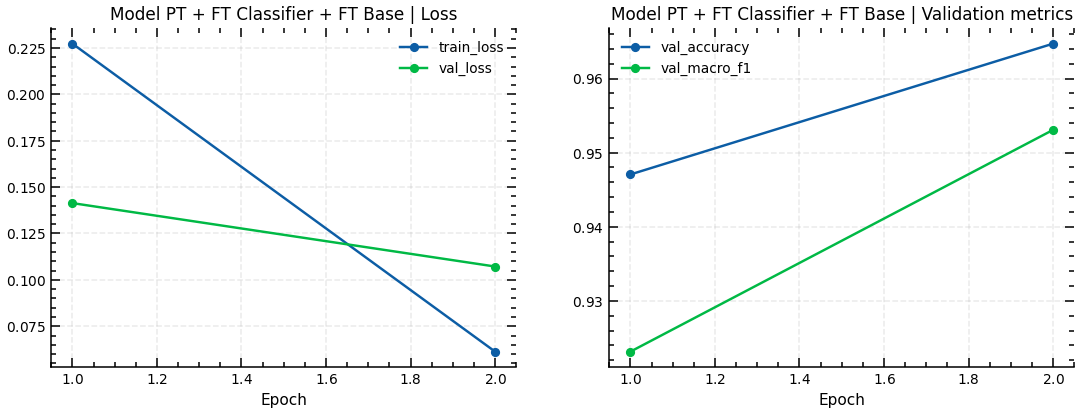

Model 4 | validation metrics: {'accuracy': 0.9647058823529412, 'macro_precision': 0.9485094720953734, 'macro_recall': 0.9578308585652526, 'macro_f1': 0.9530739859780158, 'weighted_f1': 0.9649151083526313, 'loss': 0.10719302206793252}
Model 4 | test metrics      : {'accuracy': 0.9558823529411765, 'macro_precision': 0.9339765628315989, 'macro_recall': 0.9508135602899367, 'macro_f1': 0.9420459360962794, 'weighted_f1': 0.9561771436263293, 'loss': 0.168415606109535}


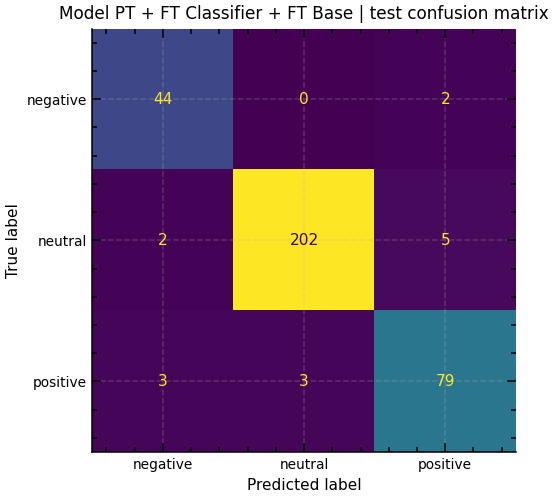

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
113,Finnish power supply solutions and systems provider Efore Oyj said its net loss widened to 3.2 mln euro $ 4.2 mln fo...,negative,positive,0.998839,1.072067e-03,0.000089,0.998839
263,"These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has suff...",positive,neutral,0.998097,2.583564e-07,0.998097,0.001903
159,Viking Line manages well with its current ferries .,positive,neutral,0.997013,2.230368e-05,0.997013,0.002964
275,"Operating loss was EUR 179mn , compared to a loss of EUR 188mn in the second quarter of 2009 .",positive,negative,0.992725,9.927255e-01,0.000009,0.007266
208,"Fiskars , a 360-year-old global business best known for its orange-handled scissors , expects to derive synergies of...",positive,neutral,0.986883,2.601458e-06,0.986883,0.013115
299,Atria said its offer would give the Swedish company continued ownership and control of its slaughtering and cutting ...,neutral,positive,0.957550,1.526862e-04,0.042298,0.957550
167,These moderate but significant changes resulted in a significant 24-32 % reduction in the estimated CVD risk .,positive,negative,0.933303,9.333028e-01,0.000464,0.066233
175,"In a letter to Economic Affairs Minister , the listed Estonian shipping company Tallink asks for the approval to be ...",neutral,positive,0.929511,5.837924e-02,0.012110,0.929511


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
160,Motorola Inc. of the United States came second with shipments of 217.4 million units for a 21.3 percent market share...,neutral,positive,0.522537,0.001769,0.475694,0.522537
10,"The company reported a profit of 800,000 euro ($ 1.2 mln)on the sale of its Varesvuo Partners sub-group and a loss o...",neutral,neutral,0.542018,0.442533,0.542018,0.015449
214,Increase in the number of shares is based on the option rights which were granted to the management of the company u...,neutral,positive,0.569534,0.000036,0.430430,0.569534
207,"In the second quarter of 2010 , the group 's pretax loss narrowed to EUR 400,000 from EUR 600,000 .",positive,negative,0.596369,0.596369,0.001798,0.401833
150,Cargotec Germany GmbH has been awarded a contract by Stadtverwaltung Mainz for chassis bodies under Open procedure .,positive,positive,0.628395,0.000055,0.371550,0.628395
320,"In the third quarter of fiscal 2008 Efore swung to a net loss of EUR 400,000 versus a net profit of EUR 200,000 for ...",negative,positive,0.655371,0.344600,0.000029,0.655371
286,"Citigroup , Inc ( NYSE : C ) has announced that its Global Transaction Services ( GTS ) business has been awarded a ...",positive,positive,0.689653,0.000077,0.310269,0.689653
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,positive,0.718163,0.000034,0.281803,0.718163


Deep dive: Model PT + FT Classifier + FT Base
loss=0.1684 | accuracy=0.9559 | macro_f1=0.9420 | weighted_f1=0.9562
vs reference -> Δaccuracy=+0.1353, Δmacro_f1=+0.2178, Δloss=-0.2182

Class-wise report:


,precision,recall,f1-score,support
negative,0.8980,0.9565,0.9263,46.0
neutral,0.9854,0.9665,0.9758,209.0
positive,0.9186,0.9294,0.9240,85.0


Weakest class right now: positive
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='neutral' predicted='positive' (count=5)
Number of wrong predictions: 15 / 340
Median confidence on wrong predictions: 0.9295
Interpretation: many mistakes are high-confidence -> features may be systematically misleading, not just noisy.
Approx. last-epoch generalization gap (val_loss - train_loss): +0.0459
Interpretation: train/validation losses are in a relatively healthy range.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [29]:
plot_history(model4_history, "Model PT + FT Classifier + FT Base")
print("Model 4 | validation metrics:", model4_val["metrics"])
print("Model 4 | test metrics      :", model4_test["metrics"])

plot_confusion(model4_test, "Model PT + FT Classifier + FT Base | test confusion matrix")
display(show_top_errors(model4_test, n=8))
display(show_low_confidence_cases(model4_test, n=8))
deep_dive_report("Model PT + FT Classifier + FT Base", model4_test, history_df=model4_history, reference_eval=model2_test)

register_result(
    RESULTS,
    "Model PT + FT Classifier + FT Base",
    model4,
    model4_val,
    model4_test,
    notes="Start from trained Model 2; freeze head; fine-tune body only",
)


### Reading Model 4's results

If Model 4 beats Model 2 substantially, head-only adaptation isn't enough — the body itself benefits from finance-domain adaptation.

If Model 4 ties Model 2, the default pretrained representation is good enough, or the dataset is too small for body adaptation to be stable.

If Model 4 underperforms Model 2, the most likely explanation isn't that body adaptation is harmful. It's that the body learning rate is too aggressive, or the epoch count is wrong, or unfreezing the body has disrupted the boundary the head was using.


## Model 5 — Model PT + FT Classifier + PEFT Base (LoRA)

### Procedure

Start from the trained Model 2 checkpoint. Freeze the head, freeze the entire model, then insert LoRA adapters by hand into every transformer block's FFN modules. The trainable-parameter count is computed analytically and verified against the model's actual count.

### Constraints from the assignment

LoRA adapters are inserted only on each block's two FFN dense layers (`lin1` and `lin2`). Rank is fixed at 8. No automated PEFT library is used; the LoRA modules are written directly in PyTorch.

### Trainable parameter count, by hand

DistilBERT-base has 6 transformer layers, hidden size 768, FFN hidden dimension 3072. Each FFN block contains:

- `lin1: 768 → 3072`
- `lin2: 3072 → 768`

The LoRA addition to a single linear projection adds `rank × (in_features + out_features)` parameters. At rank 8:

- `lin1 contribution: 8 × (768 + 3072) = 30,720`
- `lin2 contribution: 8 × (3072 + 768) = 30,720`

Per FFN block: `61,440`. Across 6 transformer layers: `368,640`. The cell below verifies this number programmatically and asserts the equality.


In [30]:
class LoRALinear(nn.Module):
    def __init__(self, base_linear: nn.Linear, rank: int = 8, alpha: float = 8.0, dropout: float = 0.0):
        super().__init__()
        assert isinstance(base_linear, nn.Linear), "LoRALinear expects an nn.Linear base layer."

        self.base_linear = base_linear
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank
        self.dropout = nn.Dropout(dropout)

        self.A = nn.Parameter(torch.empty(rank, base_linear.in_features))
        self.B = nn.Parameter(torch.zeros(base_linear.out_features, rank))

        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        nn.init.zeros_(self.B)

        for p in self.base_linear.parameters():
            p.requires_grad = False

    @property
    def in_features(self):
        return self.base_linear.in_features

    @property
    def out_features(self):
        return self.base_linear.out_features

    def forward(self, x):
        base_out = self.base_linear(x)
        lora_out = (self.dropout(x) @ self.A.t()) @ self.B.t()
        return base_out + self.scaling * lora_out

def get_submodule_by_name(module, access_string: str):
    current = module
    for attr in access_string.split("."):
        if attr.isdigit():
            current = current[int(attr)]
        else:
            current = getattr(current, attr)
    return current

def get_parent_module_and_child_name(model, module_name: str):
    parts = module_name.split(".")
    parent_name = ".".join(parts[:-1])
    child_name = parts[-1]
    parent_module = get_submodule_by_name(model, parent_name)
    return parent_module, child_name

def find_ffn_linear_targets(model):
    targets = []
    for name, module in model.named_modules():
        if name.endswith("ffn.lin1") or name.endswith("ffn.lin2"):
            targets.append((name, module))
    return targets

def insert_lora_into_ffn(model, rank=8, alpha=8.0, dropout=0.0):
    targets = find_ffn_linear_targets(model)
    print("FFN target modules:")
    for name, module in targets:
        print(f"  {name}: {module.in_features} -> {module.out_features}")

    for name, module in targets:
        parent, child_name = get_parent_module_and_child_name(model, name)
        setattr(parent, child_name, LoRALinear(module, rank=rank, alpha=alpha, dropout=dropout))

    return [name for name, _ in targets]

def expected_lora_parameter_breakdown(model):
    rows = []
    for name, module in model.named_modules():
        if isinstance(module, LoRALinear):
            expected = module.rank * (module.in_features + module.out_features)
            actual = module.A.numel() + module.B.numel()
            rows.append({
                "module": name,
                "in_features": module.in_features,
                "out_features": module.out_features,
                "rank": module.rank,
                "expected_params": expected,
                "actual_params": actual,
            })
    breakdown = pd.DataFrame(rows)
    return breakdown

def freeze_everything(model):
    for p in model.parameters():
        p.requires_grad = False


In [31]:
model5 = build_model_pt(seed=CFG["seed"])
model5.load_state_dict(best_model2_state)

# Freeze everything first, then insert LoRA modules by hand. After this the only
# trainable tensors in the model are the newly inserted LoRA A/B parameters.
freeze_everything(model5)
lora_targets = insert_lora_into_ffn(
    model5,
    rank=CFG["lora_rank"],
    alpha=CFG["lora_alpha"],
    dropout=CFG["lora_dropout"],
)

assert len(lora_targets) == 12, f"Expected 12 FFN linear targets in DistilBERT, got {len(lora_targets)}"

show_parameter_summary(model5, "Model PT + FT Classifier + PEFT Base | after LoRA insertion", only_trainable=True)

lora_breakdown = expected_lora_parameter_breakdown(model5)
display(lora_breakdown)

expected_total_lora_params = int(lora_breakdown["expected_params"].sum())
actual_total_lora_params = int(lora_breakdown["actual_params"].sum())
_, actual_trainable_params = count_parameters(model5)

print("Expected total LoRA params from formula:", expected_total_lora_params)
print("Actual total LoRA params from module tensors:", actual_total_lora_params)
print("Actual trainable params in the whole model:", actual_trainable_params)

assert expected_total_lora_params == actual_total_lora_params == actual_trainable_params, "LoRA parameter count mismatch!"
assert expected_total_lora_params == 368640, f"Expected 368,640 LoRA params for default DistilBERT, got {expected_total_lora_params}"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FFN target modules:
  distilbert.transformer.layer.0.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.0.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.1.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.1.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.2.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.2.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.3.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.3.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.4.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.4.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.5.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.5.ffn.lin2: 3072 -> 768
Model PT + FT Classifier + PEFT Base | after LoRA insertion
Total params     : 67,324,419
Trainable params : 368,640
Trainable ratio  : 0.005476


,name,shape,num_params,requires_grad
0,distilbert.transformer.layer.0.ffn.lin1.A,"(8, 768)",6144,True
1,distilbert.transformer.layer.0.ffn.lin1.B,"(3072, 8)",24576,True
2,distilbert.transformer.layer.0.ffn.lin2.A,"(8, 3072)",24576,True
3,distilbert.transformer.layer.0.ffn.lin2.B,"(768, 8)",6144,True
4,distilbert.transformer.layer.1.ffn.lin1.A,"(8, 768)",6144,True
5,distilbert.transformer.layer.1.ffn.lin1.B,"(3072, 8)",24576,True
6,distilbert.transformer.layer.1.ffn.lin2.A,"(8, 3072)",24576,True
7,distilbert.transformer.layer.1.ffn.lin2.B,"(768, 8)",6144,True
8,distilbert.transformer.layer.2.ffn.lin1.A,"(8, 768)",6144,True
9,distilbert.transformer.layer.2.ffn.lin1.B,"(3072, 8)",24576,True


,module,in_features,out_features,rank,expected_params,actual_params
0,distilbert.transformer.layer.0.ffn.lin1,768,3072,8,30720,30720
1,distilbert.transformer.layer.0.ffn.lin2,3072,768,8,30720,30720
2,distilbert.transformer.layer.1.ffn.lin1,768,3072,8,30720,30720
3,distilbert.transformer.layer.1.ffn.lin2,3072,768,8,30720,30720
4,distilbert.transformer.layer.2.ffn.lin1,768,3072,8,30720,30720
5,distilbert.transformer.layer.2.ffn.lin2,3072,768,8,30720,30720
6,distilbert.transformer.layer.3.ffn.lin1,768,3072,8,30720,30720
7,distilbert.transformer.layer.3.ffn.lin2,3072,768,8,30720,30720
8,distilbert.transformer.layer.4.ffn.lin1,768,3072,8,30720,30720
9,distilbert.transformer.layer.4.ffn.lin2,3072,768,8,30720,30720


Expected total LoRA params from formula: 368640
Actual total LoRA params from module tensors: 368640
Actual trainable params in the whole model: 368640


In [32]:
model5, model5_history, model5_best_val = fit_model(
    model5,
    train_loader,
    val_loader,
    split_frames["train"],
    split_frames["validation"],
    epochs=CFG["lora_epochs"],
    lr=CFG["lora_lr"],
    weight_decay=CFG["weight_decay"],
    warmup_ratio=CFG["warmup_ratio"],
    clip_grad_norm=CFG["clip_grad_norm"],
    device=DEVICE,
    model_name="Model 5",
)

model5_val = evaluate_model(model5, val_loader, split_frames["validation"])
model5_test = evaluate_model(model5, test_loader, split_frames["test"])


Model 5 | epoch 1/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2413 | val_loss=0.1638 | val_acc=0.9353 | val_macro_f1=0.9108


Model 5 | epoch 2/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.1073 | val_loss=0.1113 | val_acc=0.9706 | val_macro_f1=0.9617


Model 5 | epoch 3/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0474 | val_loss=0.1054 | val_acc=0.9676 | val_macro_f1=0.9541


Model 5 | epoch 4/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0299 | val_loss=0.1098 | val_acc=0.9706 | val_macro_f1=0.9589


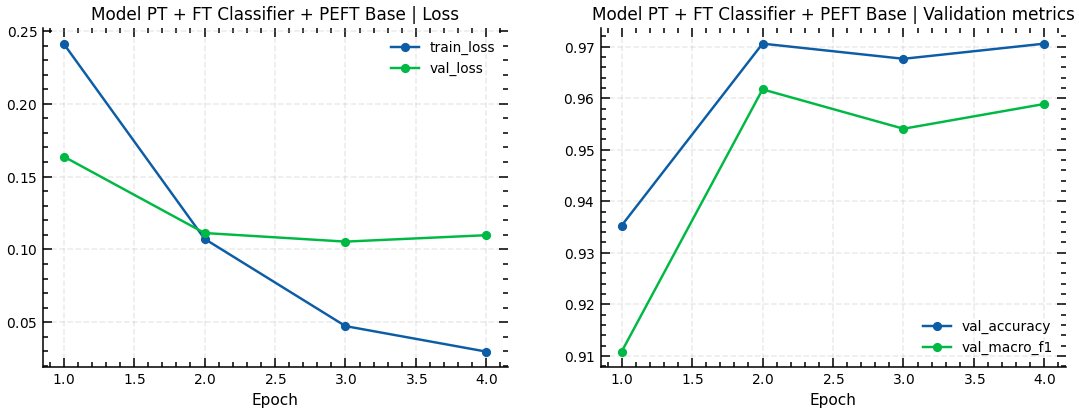

Model 5 | validation metrics: {'accuracy': 0.9705882352941176, 'macro_precision': 0.9527974783293933, 'macro_recall': 0.9713953076254178, 'macro_f1': 0.9617134835053789, 'weighted_f1': 0.9709218391297576, 'loss': 0.11129960198612775}
Model 5 | test metrics      : {'accuracy': 0.9558823529411765, 'macro_precision': 0.9342645104018619, 'macro_recall': 0.9531402325856492, 'macro_f1': 0.9433046550155444, 'weighted_f1': 0.9562167876506867, 'loss': 0.12107599535409141}


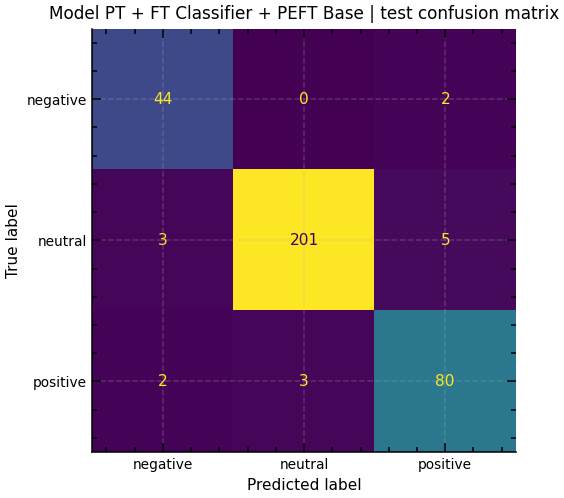

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
113,Finnish power supply solutions and systems provider Efore Oyj said its net loss widened to 3.2 mln euro $ 4.2 mln fo...,negative,positive,0.997918,0.001675,0.000407,0.997918
263,"These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has suff...",positive,neutral,0.980284,0.000003,0.980284,0.019713
275,"Operating loss was EUR 179mn , compared to a loss of EUR 188mn in the second quarter of 2009 .",positive,negative,0.923846,0.923846,0.000121,0.076034
175,"In a letter to Economic Affairs Minister , the listed Estonian shipping company Tallink asks for the approval to be ...",neutral,positive,0.916867,0.062069,0.021064,0.916867
320,"In the third quarter of fiscal 2008 Efore swung to a net loss of EUR 400,000 versus a net profit of EUR 200,000 for ...",negative,positive,0.896225,0.103741,0.000034,0.896225
299,Atria said its offer would give the Swedish company continued ownership and control of its slaughtering and cutting ...,neutral,positive,0.868136,0.000983,0.130881,0.868136
167,These moderate but significant changes resulted in a significant 24-32 % reduction in the estimated CVD risk .,positive,negative,0.811415,0.811415,0.000756,0.187830
159,Viking Line manages well with its current ferries .,positive,neutral,0.796477,0.001381,0.796477,0.202142


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
141,UPM-Kymmene said its has ` not indicated any interest in any domestic consolidations ' .,neutral,neutral,0.494645,0.379870,0.494645,0.125486
160,Motorola Inc. of the United States came second with shipments of 217.4 million units for a 21.3 percent market share...,neutral,positive,0.520489,0.008600,0.470911,0.520489
214,Increase in the number of shares is based on the option rights which were granted to the management of the company u...,neutral,neutral,0.537066,0.000067,0.537066,0.462867
33,"Previously , the company expected its 2008 financial performance to remain at the same level as in 2008 .",neutral,positive,0.547634,0.014380,0.437986,0.547634
235,Finnish silicon wafer technology company Okmetic Oyj OMX Helsinki : OKM1V said on Wednesday 17 September that it wil...,neutral,positive,0.573032,0.000798,0.426170,0.573032
208,"Fiskars , a 360-year-old global business best known for its orange-handled scissors , expects to derive synergies of...",positive,neutral,0.698916,0.000123,0.698916,0.300961
63,"In Q1 of 2009 , the company 's operating loss totalled EUR 0.3 mn , compared to a profit of EUR 3.6 mn in Q1 of 2008 .",negative,negative,0.699595,0.699595,0.000118,0.300287
10,"The company reported a profit of 800,000 euro ($ 1.2 mln)on the sale of its Varesvuo Partners sub-group and a loss o...",neutral,negative,0.735193,0.735193,0.164674,0.100133


Deep dive: Model PT + FT Classifier + PEFT Base
loss=0.1211 | accuracy=0.9559 | macro_f1=0.9433 | weighted_f1=0.9562
vs reference -> Δaccuracy=+0.0000, Δmacro_f1=+0.0013, Δloss=-0.0473

Class-wise report:


,precision,recall,f1-score,support
negative,0.8980,0.9565,0.9263,46.0
neutral,0.9853,0.9617,0.9734,209.0
positive,0.9195,0.9412,0.9302,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='neutral' predicted='positive' (count=5)
Number of wrong predictions: 15 / 340
Median confidence on wrong predictions: 0.7965
Interpretation: many mistakes are high-confidence -> features may be systematically misleading, not just noisy.
Approx. last-epoch generalization gap (val_loss - train_loss): +0.0799
Interpretation: train/validation losses are in a relatively healthy range.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [33]:
plot_history(model5_history, "Model PT + FT Classifier + PEFT Base")
print("Model 5 | validation metrics:", model5_val["metrics"])
print("Model 5 | test metrics      :", model5_test["metrics"])

plot_confusion(model5_test, "Model PT + FT Classifier + PEFT Base | test confusion matrix")
display(show_top_errors(model5_test, n=8))
display(show_low_confidence_cases(model5_test, n=8))
deep_dive_report("Model PT + FT Classifier + PEFT Base", model5_test, history_df=model5_history, reference_eval=model4_test)

register_result(
    RESULTS,
    "Model PT + FT Classifier + PEFT Base",
    model5,
    model5_val,
    model5_test,
    notes="Start from trained Model 2; freeze head; insert manual rank-8 LoRA only into FFN lin1/lin2",
)


### Reading Model 5's results

If Model 5 lands close to Model 4, the takeaway is that even without full body fine-tuning, a small low-rank addition on the FFN modules recovers most of the financial-domain adaptation benefit.

If Model 5 falls behind Model 4, two things could be true. Either FFN-only adaptation isn't enough and the attention modules also need to be adapted, or rank 8 is too little capacity for this task. The first is a structural limit imposed by the assignment; the second is a capacity limit at fixed rank.

If Model 5 actually beats Model 4 on this small dataset, that's interesting because it combines fewer trainable parameters, a more constrained update direction, and equal-or-better generalisation — properties usually attractive in deployment.


## Round 1 — consolidated results

The five models go into a single table to make three comparisons easy:

1. Which adaptation regime gained the most macro-F1.
2. Which one is the most parameter-efficient (gain per trainable parameter).
3. Which observation most clearly suggests where Round 2 should focus.


In [34]:
results_df = pd.DataFrame(RESULTS).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
display(results_df.round(4))


,model,notes,total_params,trainable_params,trainable_pct,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,test_loss
0,Model PT + FT Classifier + PEFT Base,Start from trained Model 2; freeze head; insert manual rank-8 LoRA only into FFN lin1/lin2,67324419,368640,0.0055,0.9706,0.9617,0.9559,0.9433,0.1211
1,Model PT + FT Classifier + FT Base,Start from trained Model 2; freeze head; fine-tune body only,66955779,66362880,0.9911,0.9647,0.9531,0.9559,0.9420,0.1684
2,Model PT + FT Classifier,Default head trained; DistilBERT body frozen,66955779,592899,0.0089,0.8441,0.7406,0.8206,0.7242,0.3866
3,Model PT + Own FT Classifier,Custom MLP head (768->256->64->3); backbone frozen,66576387,213507,0.0032,0.7853,0.5276,0.7529,0.4993,0.5116
4,Model PT,No financial fine-tuning; default HF classifier head only,66955779,66955779,1.0000,0.3618,0.3425,0.3206,0.3009,1.1031


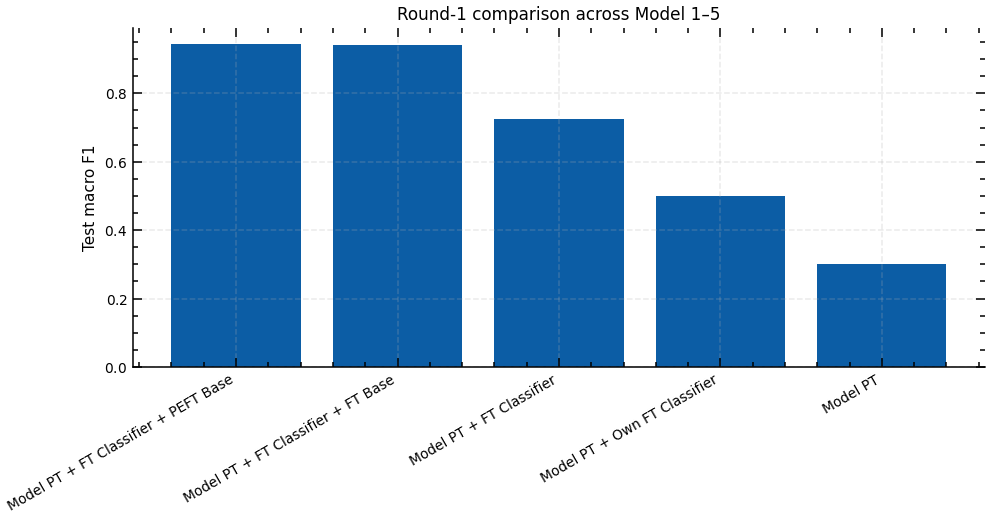

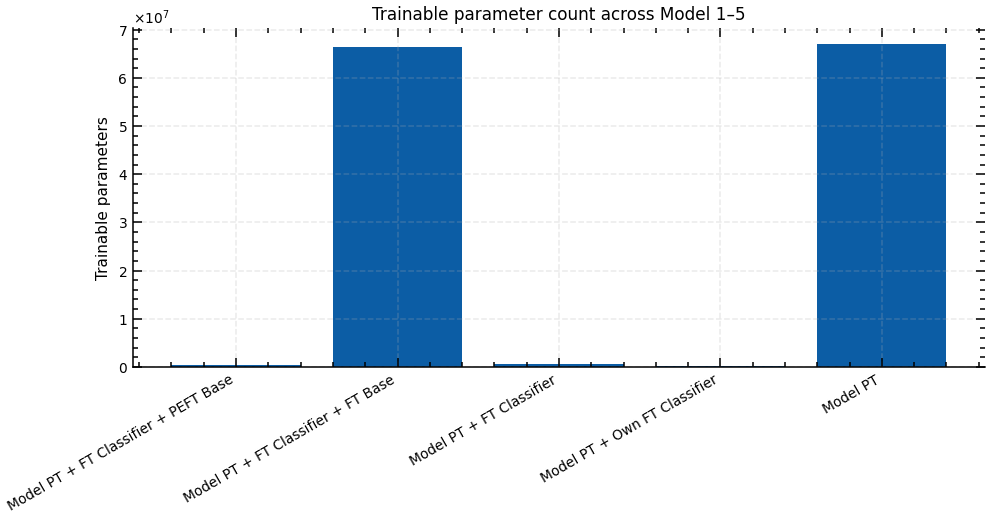

In [35]:
plt.figure(figsize=(10, 4))
plt.bar(results_df["model"], results_df["test_macro_f1"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Test macro F1")
plt.title("Round-1 comparison across Model 1–5")
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(results_df["model"], results_df["trainable_params"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Trainable parameters")
plt.title("Trainable parameter count across Model 1–5")
plt.show()


In [36]:
def get_result(results_df, model_name):
    row = results_df.loc[results_df["model"] == model_name]
    if len(row) == 0:
        return None
    return row.iloc[0].to_dict()

def cross_model_takeaways(results_df):
    print("=" * 80)
    print("Cross-model takeaways from round 1")
    print("=" * 80)

    r1 = get_result(results_df, "Model PT")
    r2 = get_result(results_df, "Model PT + FT Classifier")
    r3 = get_result(results_df, "Model PT + Own FT Classifier")
    r4 = get_result(results_df, "Model PT + FT Classifier + FT Base")
    r5 = get_result(results_df, "Model PT + FT Classifier + PEFT Base")

    if r1 and r2:
        delta = r2["test_macro_f1"] - r1["test_macro_f1"]
        print(f"Model 2 - Model 1 (head-only gain): {delta:+.4f}")
        if delta > 0.05:
            print("Interpretation: the frozen pretrained representation already contains useful signal; the main missing part was task-specific boundary learning.")
        else:
            print("Interpretation: head-only tuning did not unlock much; later rounds should seriously examine body adaptation or data-centric fixes.")

    if r2 and r3:
        delta = r3["test_macro_f1"] - r2["test_macro_f1"]
        print(f"Model 3 - Model 2 (custom head gain): {delta:+.4f}")
        if delta > 0.03:
            print("Interpretation: a stronger head architecture helps when the backbone is frozen.")
        elif delta < -0.03:
            print("Interpretation: the custom head may be too strong / too brittle for this dataset size, or its bottleneck is not well tuned.")
        else:
            print("Interpretation: custom head changes little; the frozen representation may be the real bottleneck.")

    if r2 and r4:
        delta = r4["test_macro_f1"] - r2["test_macro_f1"]
        print(f"Model 4 - Model 2 (body-only adaptation gain after fixed head): {delta:+.4f}")
        if delta > 0.03:
            print("Interpretation: adapting the body to financial language matters beyond merely learning a classifier head.")
        elif delta < -0.03:
            print("Interpretation: body-only tuning may be unstable with current hyperparameters; next rounds should consider smaller LR or shorter schedules.")
        else:
            print("Interpretation: body-only adaptation yields limited gain in this first-round setup.")

    if r4 and r5:
        delta = r5["test_macro_f1"] - r4["test_macro_f1"]
        print(f"Model 5 - Model 4 (PEFT vs body-only FT): {delta:+.4f}")
        if abs(delta) <= 0.03:
            print("Interpretation: manual LoRA on FFN may recover much of the body-adaptation benefit with far fewer trainable parameters.")
        elif delta < -0.03:
            print("Interpretation: restricting adaptation to FFN rank-8 adapters may be too narrow for this task in round 1.")
        else:
            print("Interpretation: surprisingly, the PEFT setup is outperforming body-only FT; inspect whether the smaller trainable subspace improved regularization.")

    print("\nWhat to carry into the next notebook:")
    print("- Revisit max_length using the length histogram rather than guessing.")
    print("- Revisit learning rates separately for head, body, and LoRA.")
    print("- Revisit Model 3 head width/depth/dropout only after looking at its exact failure mode.")
    print("- Treat confusion pairs (especially around neutral vs sentiment-bearing classes) as the main clue for round-2 changes.")

cross_model_takeaways(results_df)


Cross-model takeaways from round 1
Model 2 - Model 1 (head-only gain): +0.4233
Interpretation: the frozen pretrained representation already contains useful signal; the main missing part was task-specific boundary learning.
Model 3 - Model 2 (custom head gain): -0.2250
Interpretation: the custom head may be too strong / too brittle for this dataset size, or its bottleneck is not well tuned.
Model 4 - Model 2 (body-only adaptation gain after fixed head): +0.2178
Interpretation: adapting the body to financial language matters beyond merely learning a classifier head.
Model 5 - Model 4 (PEFT vs body-only FT): +0.0013
Interpretation: manual LoRA on FFN may recover much of the body-adaptation benefit with far fewer trainable parameters.

What to carry into the next notebook:
- Revisit max_length using the length histogram rather than guessing.
- Revisit learning rates separately for head, body, and LoRA.
- Revisit Model 3 head width/depth/dropout only after looking at its exact failure mode.

### End of Round 1 — what the results say

Round 1 was set up to test where the bottleneck is — at the head, in the representation, or at the parameter-efficiency constraint of LoRA. The numbers are not the final scores; they're the basis for narrowing the search space in Round 2.

Six observations from Round 1 are particularly informative:

1. Which class is hardest.
2. Which pair of classes is most often confused.
3. The size of the jump from Model 1 (no fine-tuning) to Model 2 (head only).
4. Whether Model 3's custom head shows any measurable advantage over Model 2's default head.
5. Whether Model 4's body fine-tuning gives gains that justify its trainable-parameter cost.
6. The size of the gap between Model 5 (LoRA) and Model 4 (full body FT), and whether it's small enough relative to LoRA's parameter savings to make the trade attractive.

Round 2 keeps the split, the metric set, and the analysis utilities established here. Cells are appended rather than rewritten. A small number of evidence-based adjustments are made, and all five models are re-run.


## Reference notes

DistilBERT's default sequence-classification head is roughly `pre_classifier (768 → 768) → ReLU → Dropout → classifier (768 → 3)`.

DistilBERT-base has 6 transformer layers, hidden size 768, FFN hidden dimension 3072.

Financial PhraseBank `sentences_allagree` has 2,264 sentences with 100% annotator agreement. There's no canonical train/val/test split.

The LoRA hypothesis: fine-tuning a low-rank update on top of frozen pretrained weights can match full fine-tuning while training a small fraction of the parameters.


# Round 2 — evidence-driven adjustment

Round 2 looks at Round 1's outputs and changes only what they motivate. Four diagnostic categories are worth tracking:

- Whether Round 1's token budget (128) is unnecessarily generous given the empirical sentence-length distribution.
- Whether per-class recall or per-class macro-F1 imbalance is large enough to warrant class weighting.
- Whether Model 3's custom head looks like an underfitting failure or an overfitting failure (each calls for a different fix).
- Whether the Round 1 body and LoRA learning rates and epoch budgets match what the loss curves show.

The principle for Round 2 changes: each one has to be defensible. I should be able to say what evidence motivated it, what symptom it's expected to address, and what would falsify the change. Round 2 then re-runs all five models with the adjusted configuration.


## Validation drives round-on-round decisions

All adjustments between rounds are made on the basis of validation-side performance and validation-side error analysis. Test-set numbers are recorded once per round for reporting only — they don't drive selection or tuning. This keeps the test-set evaluation honest as a held-out estimate.


In [37]:

# Snapshot Round 1 results before Round 2 starts, so later cells can still reference them.
ROUND1_CFG = copy.deepcopy(CFG)
ROUND1_RESULTS_DF = results_df.copy().reset_index(drop=True)
ROUND1_HISTORIES = {
    "Model PT + FT Classifier": model2_history.copy(),
    "Model PT + Own FT Classifier": model3_history.copy(),
    "Model PT + FT Classifier + FT Base": model4_history.copy(),
    "Model PT + FT Classifier + PEFT Base": model5_history.copy(),
}
ROUND1_VAL_EVALS = {
    "Model PT": model1_val,
    "Model PT + FT Classifier": model2_val,
    "Model PT + Own FT Classifier": model3_val,
    "Model PT + FT Classifier + FT Base": model4_val,
    "Model PT + FT Classifier + PEFT Base": model5_val,
}
ROUND1_TEST_EVALS = {
    "Model PT": model1_test,
    "Model PT + FT Classifier": model2_test,
    "Model PT + Own FT Classifier": model3_test,
    "Model PT + FT Classifier + FT Base": model4_test,
    "Model PT + FT Classifier + PEFT Base": model5_test,
}

print("Round 1 snapshot saved. We'll use validation-side evidence to drive round 2.")
display(ROUND1_RESULTS_DF.sort_values("val_macro_f1", ascending=False).round(4))


Round 1 snapshot saved. We'll use validation-side evidence to drive round 2.


,model,notes,total_params,trainable_params,trainable_pct,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,test_loss
0,Model PT + FT Classifier + PEFT Base,Start from trained Model 2; freeze head; insert manual rank-8 LoRA only into FFN lin1/lin2,67324419,368640,0.0055,0.9706,0.9617,0.9559,0.9433,0.1211
1,Model PT + FT Classifier + FT Base,Start from trained Model 2; freeze head; fine-tune body only,66955779,66362880,0.9911,0.9647,0.9531,0.9559,0.9420,0.1684
2,Model PT + FT Classifier,Default head trained; DistilBERT body frozen,66955779,592899,0.0089,0.8441,0.7406,0.8206,0.7242,0.3866
3,Model PT + Own FT Classifier,Custom MLP head (768->256->64->3); backbone frozen,66576387,213507,0.0032,0.7853,0.5276,0.7529,0.4993,0.5116
4,Model PT,No financial fine-tuning; default HF classifier head only,66955779,66955779,1.0000,0.3618,0.3425,0.3206,0.3009,1.1031


In [38]:

def dominant_confusion(eval_obj):
    cm = eval_obj["confusion_matrix"].copy()
    np.fill_diagonal(cm, 0)
    if cm.sum() == 0:
        return "none", 0
    i, j = np.unravel_index(np.argmax(cm), cm.shape)
    return f"{id2label[i]} -> {id2label[j]}", int(cm[i, j])


def summarize_validation_side(eval_store):
    rows = []
    for model_name, eval_obj in eval_store.items():
        metrics = eval_obj["metrics"]
        report = eval_obj["report_df"].loc[LABEL_ORDER]
        wrong = eval_obj["predictions_df"].query("gold_id != pred_id")
        weakest_class = report["f1-score"].idxmin()
        strongest_class = report["f1-score"].idxmax()
        confusion_name, confusion_count = dominant_confusion(eval_obj)
        rows.append({
            "model": model_name,
            "val_accuracy": metrics["accuracy"],
            "val_macro_f1": metrics["macro_f1"],
            "acc_minus_macro_f1": metrics["accuracy"] - metrics["macro_f1"],
            "weakest_class": weakest_class,
            "weakest_class_f1": report.loc[weakest_class, "f1-score"],
            "weakest_class_recall": report.loc[weakest_class, "recall"],
            "strongest_class": strongest_class,
            "strongest_class_f1": report.loc[strongest_class, "f1-score"],
            "dominant_confusion": confusion_name,
            "dominant_confusion_count": confusion_count,
            "median_wrong_confidence": float(wrong["confidence"].median()) if len(wrong) else np.nan,
        })
    return pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)


def collect_classwise_scores(eval_store, split_name="validation"):
    frames = []
    for model_name, eval_obj in eval_store.items():
        part = eval_obj["report_df"].loc[LABEL_ORDER, ["precision", "recall", "f1-score", "support"]].copy()
        part["label"] = part.index
        part["model"] = model_name
        part["split"] = split_name
        frames.append(part.reset_index(drop=True))
    return pd.concat(frames, ignore_index=True)


round1_val_diag_df = summarize_validation_side(ROUND1_VAL_EVALS)
round1_val_classwise = collect_classwise_scores(ROUND1_VAL_EVALS, split_name="validation")

print("Validation-side diagnostic summary from round 1")
display(round1_val_diag_df.round(4))
print("\nValidation class-wise F1 table")
display(round1_val_classwise.pivot_table(index="label", columns="model", values="f1-score").round(4))


Validation-side diagnostic summary from round 1


,model,val_accuracy,val_macro_f1,acc_minus_macro_f1,weakest_class,weakest_class_f1,weakest_class_recall,strongest_class,strongest_class_f1,dominant_confusion,dominant_confusion_count,median_wrong_confidence
0,Model PT + FT Classifier + PEFT Base,0.9706,0.9617,0.0089,positive,0.9432,0.9651,neutral,0.9854,neutral -> positive,6,0.9262
1,Model PT + FT Classifier + FT Base,0.9647,0.9531,0.0116,positive,0.9310,0.9419,neutral,0.9831,neutral -> positive,5,0.8427
2,Model PT + FT Classifier,0.8441,0.7406,0.1035,negative,0.5479,0.4444,neutral,0.9456,negative -> positive,24,0.6491
3,Model PT + Own FT Classifier,0.7853,0.5276,0.2577,negative,0.0000,0.0000,neutral,0.9324,negative -> positive,44,0.5692
4,Model PT,0.3618,0.3425,0.0192,negative,0.1705,0.3333,neutral,0.4286,neutral -> negative,87,0.3412



Validation class-wise F1 table


model,Model PT,Model PT + FT Classifier,Model PT + FT Classifier + FT Base,Model PT + FT Classifier + PEFT Base,Model PT + Own FT Classifier
label,,,,,
negative,0.1705,0.5479,0.9451,0.9565,0.0000
neutral,0.4286,0.9456,0.9831,0.9854,0.9324
positive,0.4286,0.7283,0.9310,0.9432,0.6505


In [39]:

def history_signal(history_df):
    best_idx = history_df["val_macro_f1"].idxmax()
    best_row = history_df.loc[best_idx]
    last_row = history_df.iloc[-1]
    ended_rising = False
    if len(history_df) >= 2:
        ended_rising = history_df["val_macro_f1"].iloc[-1] > history_df["val_macro_f1"].iloc[-2] + 1e-4
    return {
        "best_epoch": int(best_row["epoch"]),
        "last_epoch": int(last_row["epoch"]),
        "best_val_macro_f1": float(best_row["val_macro_f1"]),
        "last_val_macro_f1": float(last_row["val_macro_f1"]),
        "peak_to_last_drop": float(best_row["val_macro_f1"] - last_row["val_macro_f1"]),
        "train_loss_last": float(last_row["train_loss"]),
        "val_loss_last": float(last_row["val_loss"]),
        "overfit_gap_last": float(last_row["val_loss"] - last_row["train_loss"]),
        "ended_rising": bool(ended_rising),
    }


round1_history_diag_df = pd.DataFrame({
    model_name: history_signal(history_df)
    for model_name, history_df in ROUND1_HISTORIES.items()
}).T

print("History-based training signals from round 1")
display(round1_history_diag_df.round(4))


History-based training signals from round 1


,best_epoch,last_epoch,best_val_macro_f1,last_val_macro_f1,peak_to_last_drop,train_loss_last,val_loss_last,overfit_gap_last,ended_rising
Model PT + FT Classifier,4,4,0.740611,0.740611,0.0,0.340326,0.35866,0.018334,True
Model PT + Own FT Classifier,4,4,0.527629,0.527629,0.0,0.484028,0.461652,-0.022376,True
Model PT + FT Classifier + FT Base,2,2,0.953074,0.953074,0.0,0.061313,0.107193,0.04588,True
Model PT + FT Classifier + PEFT Base,2,4,0.961713,0.958886,0.002827,0.029873,0.109808,0.079935,True


### Reading the diagnostic tables

The two tables above summarise the Round 1 diagnostics that drive Round 2's decisions. The signals worth reading:

A large gap between accuracy and macro-F1 means overall accuracy is being driven by the frequent class while a less frequent class is being neglected.

The combination of weakest class and dominant confusion pinpoints which class is being absorbed by which other class. Round 2 will respond with class weighting if the gap is large.

A high median wrong-prediction confidence means the errors are confident rather than tentative. That's the symptom label smoothing is meant to address.

Best epoch occurring early followed by decline points at overfitting, suggesting earlier stopping or stronger regularisation in Round 2.

Best epoch at the final epoch with metrics still improving points the other way — undertrained, suggesting more epochs or a slightly higher learning rate.


In [40]:

def build_truncation_table(lengths, candidates=(48, 64, 80, 96, 128, 160)):
    rows = []
    total = len(lengths)
    for cand in candidates:
        truncated = sum(l > cand for l in lengths)
        rows.append({
            "max_length": cand,
            "truncated_examples": truncated,
            "truncation_rate": truncated / max(1, total),
            "kept_rate": 1.0 - truncated / max(1, total),
        })
    return pd.DataFrame(rows)


def choose_max_length(lengths, candidates=(48, 64, 80, 96, 128, 160), strict_rate=0.01, relaxed_rate=0.03):
    table = build_truncation_table(lengths, candidates=candidates)

    strict = table[table["truncation_rate"] <= strict_rate]
    if len(strict) > 0:
        chosen = int(strict.iloc[0]["max_length"])
        rationale = f"Chose the smallest candidate with truncation_rate <= {strict_rate:.0%}."
        return chosen, rationale, table

    relaxed = table[table["truncation_rate"] <= relaxed_rate]
    if len(relaxed) > 0:
        chosen = int(relaxed.iloc[0]["max_length"])
        rationale = f"No candidate satisfied the strict limit; chose the smallest one with truncation_rate <= {relaxed_rate:.0%}."
        return chosen, rationale, table

    chosen = int(table.iloc[-1]["max_length"])
    rationale = "Even the largest candidate still truncates noticeably, so we keep the largest option in this list."
    return chosen, rationale, table


ROUND2_MAX_LENGTH, ROUND2_MAXLEN_RATIONALE, round2_length_table = choose_max_length(train_lengths)

print("Token-length trade-off table (based on training split only)")
display(round2_length_table.round(4))
print(f"\nRecommended max_length for round 2: {ROUND2_MAX_LENGTH}")
print("Reason:", ROUND2_MAXLEN_RATIONALE)


Token-length trade-off table (based on training split only)


,max_length,truncated_examples,truncation_rate,kept_rate
0,48,185,0.1168,0.8832
1,64,33,0.0208,0.9792
2,80,2,0.0013,0.9987
3,96,1,0.0006,0.9994
4,128,1,0.0006,0.9994
5,160,0,0.0000,1.0000



Recommended max_length for round 2: 80
Reason: Chose the smallest candidate with truncation_rate <= 1%.


In [41]:

# Class weighting is enabled conditionally — only if the imbalance observed in Round 1
# is large enough to warrant it.
train_label_counts = split_frames["train"]["labels"].value_counts().sort_index().reindex(range(len(LABEL_ORDER)))
max_count = train_label_counts.max()

weight_df = pd.DataFrame({
    "label_id": list(range(len(LABEL_ORDER))),
    "label": LABEL_ORDER,
    "train_count": train_label_counts.values,
})
weight_df["raw_inverse_freq"] = 1.0 / weight_df["train_count"]
weight_df["raw_inverse_freq"] = weight_df["raw_inverse_freq"] / weight_df["raw_inverse_freq"].mean()
weight_df["sqrt_inverse_freq"] = np.sqrt(max_count / weight_df["train_count"])
weight_df["sqrt_inverse_freq"] = weight_df["sqrt_inverse_freq"] / weight_df["sqrt_inverse_freq"].mean()

display(weight_df.round(4))

best_val_model_name = ROUND1_RESULTS_DF.sort_values("val_macro_f1", ascending=False).iloc[0]["model"]
best_val_eval = ROUND1_VAL_EVALS[best_val_model_name]
best_val_report = best_val_eval["report_df"].loc[LABEL_ORDER]
acc_macro_gap = best_val_eval["metrics"]["accuracy"] - best_val_eval["metrics"]["macro_f1"]
weakest_recall = float(best_val_report["recall"].min())

ROUND2_USE_CLASS_WEIGHTS = bool((acc_macro_gap > 0.05) or (weakest_recall < 0.60))
ROUND2_CLASS_WEIGHT_MODE = "sqrt_inverse_freq" if ROUND2_USE_CLASS_WEIGHTS else None

print(f"Best validation model from round 1: {best_val_model_name}")
print(f"Validation acc - macro_f1 gap: {acc_macro_gap:.4f}")
print(f"Weakest class recall on validation: {weakest_recall:.4f}")
print(f"Use class weights in round 2? {ROUND2_USE_CLASS_WEIGHTS}")
print(f"Chosen weighting mode            : {ROUND2_CLASS_WEIGHT_MODE}")

best_wrong = best_val_eval["predictions_df"].query("gold_id != pred_id")
ROUND2_LABEL_SMOOTHING = 0.03 if (len(best_wrong) > 0 and best_wrong["confidence"].median() > 0.70) else 0.0
print(f"Median wrong confidence in the best round-1 validation model: {best_wrong['confidence'].median() if len(best_wrong) else float('nan'):.4f}")
print(f"Chosen label smoothing for round 2: {ROUND2_LABEL_SMOOTHING}")


,label_id,label,train_count,raw_inverse_freq,sqrt_inverse_freq
0,0,negative,212,1.7151,1.3663
1,1,neutral,973,0.3737,0.6378
2,2,positive,399,0.9113,0.9959


Best validation model from round 1: Model PT + FT Classifier + PEFT Base
Validation acc - macro_f1 gap: 0.0089
Weakest class recall on validation: 0.9651
Use class weights in round 2? False
Chosen weighting mode            : None
Median wrong confidence in the best round-1 validation model: 0.9262
Chosen label smoothing for round 2: 0.03


In [42]:

def build_hard_example_table(eval_store):
    merged = None
    for model_name, eval_obj in eval_store.items():
        pred_df = eval_obj["predictions_df"][["sentence", "gold_label", "pred_label", "confidence"]].copy()
        pred_df = pred_df.rename(columns={
            "pred_label": f"pred::{model_name}",
            "confidence": f"conf::{model_name}",
        })
        pred_df[f"wrong::{model_name}"] = (pred_df[f"pred::{model_name}"] != pred_df["gold_label"]).astype(int)

        if merged is None:
            merged = pred_df
        else:
            merged = merged.merge(pred_df, on=["sentence", "gold_label"], how="inner")

    wrong_cols = [c for c in merged.columns if c.startswith("wrong::")]
    merged["n_models_wrong"] = merged[wrong_cols].sum(axis=1)
    return merged.sort_values(["n_models_wrong", "gold_label"], ascending=[False, True]).reset_index(drop=True)


hard_val_examples = build_hard_example_table(ROUND1_VAL_EVALS)
print("Validation examples that multiple round-1 models found difficult")
display(hard_val_examples.head(15))


Validation examples that multiple round-1 models found difficult


,sentence,gold_label,pred::Model PT,conf::Model PT,wrong::Model PT,pred::Model PT + FT Classifier,conf::Model PT + FT Classifier,wrong::Model PT + FT Classifier,pred::Model PT + Own FT Classifier,conf::Model PT + Own FT Classifier,wrong::Model PT + Own FT Classifier,pred::Model PT + FT Classifier + FT Base,conf::Model PT + FT Classifier + FT Base,wrong::Model PT + FT Classifier + FT Base,pred::Model PT + FT Classifier + PEFT Base,conf::Model PT + FT Classifier + PEFT Base,wrong::Model PT + FT Classifier + PEFT Base,n_models_wrong
0,"ADP News - Apr 22 , 2009 - Finnish business information systems developer Solteq Oyj HEL : STQ1V said today its net ...",negative,positive,0.340305,1,positive,0.534281,1,positive,0.562610,1,positive,0.994112,1,positive,0.987902,1,5
1,"The repo rate will gradually reach 2 % at the end of 2010 , according to Nordea 's Economic Outlook .",neutral,positive,0.340649,1,positive,0.729277,1,positive,0.597456,1,positive,0.804388,1,positive,0.971685,1,5
2,`` The industry is coming to an interesting fork in the road as both handset manufacturers and wireless carriers att...,neutral,negative,0.351022,1,positive,0.687651,1,positive,0.459926,1,positive,0.960123,1,positive,0.959854,1,5
3,"F-Secure , a developer of security solutions as a service through Internet Service Providers and mobile operators , ...",neutral,negative,0.343000,1,positive,0.724824,1,positive,0.487189,1,positive,0.894223,1,positive,0.951917,1,5
4,"Based on the first quarter result , existing order backlog and new order prospects , the company expects that full-y...",negative,neutral,0.339827,1,positive,0.832632,1,positive,0.599460,1,positive,0.556018,1,negative,0.797716,0,4
5,The group reiterated its forecast that handset manufacturers will sell around 915 mln units this year globally .,neutral,positive,0.334364,1,positive,0.806631,1,neutral,0.458206,0,positive,0.504673,1,positive,0.892331,1,4
6,The stock is trading above both its MAPs and the 50-day MAP of SEK72 .983 is higher than the 200-day MAP of SEK70 .2...,positive,negative,0.338046,1,neutral,0.905838,1,neutral,0.673700,1,neutral,0.968092,1,positive,0.891922,0,4
7,The new factory working model and reorganisations would decrease Nokian Tyres ' costs in the factory by EUR 30 milli...,positive,negative,0.338863,1,positive,0.690524,0,neutral,0.485247,1,negative,0.864171,1,negative,0.900583,1,4
8,"Finnish electronics contract manufacturer Scanfil reports net sales of EUR 58.9 mn in the second quarter of 2007 , d...",negative,positive,0.342066,1,positive,0.703937,1,positive,0.575097,1,negative,0.999694,0,negative,0.998986,0,3
9,Finnish technology company Raute Corporation ( OMX Helsinki : RUTAV ) issued on Tuesday ( 23 September ) a profit wa...,negative,positive,0.339984,1,neutral,0.486975,1,neutral,0.513148,1,negative,0.965120,0,negative,0.829760,0,3


In [43]:

ROUND2_CFG = copy.deepcopy(CFG)

# General Round 2 changes first, then per-model adjustments.
ROUND2_CFG["max_length"] = ROUND2_MAX_LENGTH
ROUND2_CFG["use_class_weights"] = ROUND2_USE_CLASS_WEIGHTS
ROUND2_CFG["class_weight_mode"] = ROUND2_CLASS_WEIGHT_MODE
ROUND2_CFG["label_smoothing"] = ROUND2_LABEL_SMOOTHING
ROUND2_CFG["early_stopping_patience"] = 2
ROUND2_CFG["min_epochs_before_stop"] = 2

# ---- Model 2: default head only ----
sig2 = history_signal(ROUND1_HISTORIES["Model PT + FT Classifier"])
ROUND2_CFG["head_only_epochs"] = max(CFG["head_only_epochs"] + 1, sig2["best_epoch"] + 1)
ROUND2_CFG["head_only_lr"] = CFG["head_only_lr"] * (0.70 if sig2["overfit_gap_last"] > 0.35 else 0.90)

# ---- Model 3: custom head ----
round1_val_lookup = ROUND1_RESULTS_DF.set_index("model")
m3_minus_m2_val = float(round1_val_lookup.loc["Model PT + Own FT Classifier", "val_macro_f1"] - round1_val_lookup.loc["Model PT + FT Classifier", "val_macro_f1"])
sig3 = history_signal(ROUND1_HISTORIES["Model PT + Own FT Classifier"])

if m3_minus_m2_val < -0.01 and sig3["overfit_gap_last"] > 0.35:
    ROUND2_CFG["custom_head_hidden_dims"] = (192, 64)
    ROUND2_CFG["custom_head_dropout"] = 0.40
    ROUND2_CFG["custom_head_lr"] = CFG["custom_head_lr"] * 0.70
    ROUND2_CFG["custom_head_activation"] = "gelu"
    ROUND2_CFG["custom_head_layernorm"] = True
    custom_head_rationale = "Round-1 custom head looked too eager / overfit, so we shrink it slightly, increase dropout, and add LayerNorm."
elif m3_minus_m2_val < -0.01:
    ROUND2_CFG["custom_head_hidden_dims"] = (384, 128)
    ROUND2_CFG["custom_head_dropout"] = 0.20
    ROUND2_CFG["custom_head_lr"] = CFG["custom_head_lr"] * 0.90
    ROUND2_CFG["custom_head_activation"] = "gelu"
    ROUND2_CFG["custom_head_layernorm"] = True
    custom_head_rationale = "Round-1 custom head likely underfit relative to Model 2, so we make it wider and slightly less regularized."
else:
    ROUND2_CFG["custom_head_hidden_dims"] = (320, 128)
    ROUND2_CFG["custom_head_dropout"] = 0.25
    ROUND2_CFG["custom_head_lr"] = CFG["custom_head_lr"] * 0.85
    ROUND2_CFG["custom_head_activation"] = "gelu"
    ROUND2_CFG["custom_head_layernorm"] = True
    custom_head_rationale = "Round-1 custom head was already competitive, so we keep the idea but smooth the activation and stabilize the hidden states with LayerNorm."
ROUND2_CFG["custom_head_epochs"] = max(CFG["custom_head_epochs"] + 1, sig3["best_epoch"] + 1)

# ---- Model 4: body-only FT after Model 2 ----
sig4 = history_signal(ROUND1_HISTORIES["Model PT + FT Classifier + FT Base"])
if sig4["best_epoch"] == sig4["last_epoch"] or sig4["ended_rising"]:
    ROUND2_CFG["body_only_epochs"] = CFG["body_only_epochs"] + 2
    ROUND2_CFG["body_only_lr"] = min(CFG["body_only_lr"] * 1.10, 3e-5)
    body_rationale = "Model 4 still looked alive at the end of round 1, so we give body adaptation a bit more room."
elif sig4["overfit_gap_last"] > 0.35 or sig4["peak_to_last_drop"] > 0.02:
    ROUND2_CFG["body_only_epochs"] = CFG["body_only_epochs"] + 1
    ROUND2_CFG["body_only_lr"] = CFG["body_only_lr"] * 0.75
    body_rationale = "Model 4 showed instability / overfit signs, so we lower the body learning rate and rely on early stopping."
else:
    ROUND2_CFG["body_only_epochs"] = CFG["body_only_epochs"] + 1
    ROUND2_CFG["body_only_lr"] = CFG["body_only_lr"]
    body_rationale = "Model 4 looked reasonable but short, so we only extend it slightly."

# ---- Model 5: LoRA on FFN only ----
sig5 = history_signal(ROUND1_HISTORIES["Model PT + FT Classifier + PEFT Base"])
m5_minus_m4_val = float(round1_val_lookup.loc["Model PT + FT Classifier + PEFT Base", "val_macro_f1"] - round1_val_lookup.loc["Model PT + FT Classifier + FT Base", "val_macro_f1"])
if m5_minus_m4_val < -0.02:
    ROUND2_CFG["lora_epochs"] = CFG["lora_epochs"] + 2
    ROUND2_CFG["lora_lr"] = CFG["lora_lr"] * 0.60
    ROUND2_CFG["lora_alpha"] = 16
    ROUND2_CFG["lora_dropout"] = 0.05
    lora_rationale = "LoRA lagged full body FT by a noticeable margin, so we make the updates gentler but slightly stronger (alpha up, lr down, train a bit longer)."
elif sig5["overfit_gap_last"] > 0.35:
    ROUND2_CFG["lora_epochs"] = CFG["lora_epochs"] + 1
    ROUND2_CFG["lora_lr"] = CFG["lora_lr"] * 0.50
    ROUND2_CFG["lora_alpha"] = CFG["lora_alpha"]
    ROUND2_CFG["lora_dropout"] = 0.10
    lora_rationale = "LoRA looked a bit too confident / unstable, so we add dropout and lower lr."
else:
    ROUND2_CFG["lora_epochs"] = CFG["lora_epochs"] + 1
    ROUND2_CFG["lora_lr"] = CFG["lora_lr"] * 0.75
    ROUND2_CFG["lora_alpha"] = CFG["lora_alpha"]
    ROUND2_CFG["lora_dropout"] = 0.05
    lora_rationale = "LoRA was close enough that we only make a mild stabilization pass."

round2_decisions_df = pd.DataFrame([
    {"component": "global", "change": f"max_length -> {ROUND2_CFG['max_length']}", "reason": ROUND2_MAXLEN_RATIONALE},
    {"component": "global", "change": f"use_class_weights -> {ROUND2_CFG['use_class_weights']} ({ROUND2_CFG['class_weight_mode']})", "reason": "Turn on when validation suggests class imbalance is dragging macro F1."},
    {"component": "global", "change": f"label_smoothing -> {ROUND2_CFG['label_smoothing']}", "reason": "Small smoothing only if the best validation model is making many high-confidence mistakes."},
    {"component": "Model 2", "change": f"epochs={ROUND2_CFG['head_only_epochs']}, lr={ROUND2_CFG['head_only_lr']:.2e}", "reason": "Use round-1 head-only training dynamics to decide whether to extend or soften training."},
    {"component": "Model 3", "change": f"dims={ROUND2_CFG['custom_head_hidden_dims']}, dropout={ROUND2_CFG['custom_head_dropout']}, activation={ROUND2_CFG['custom_head_activation']}, layernorm={ROUND2_CFG['custom_head_layernorm']}, lr={ROUND2_CFG['custom_head_lr']:.2e}", "reason": custom_head_rationale},
    {"component": "Model 4", "change": f"epochs={ROUND2_CFG['body_only_epochs']}, lr={ROUND2_CFG['body_only_lr']:.2e}", "reason": body_rationale},
    {"component": "Model 5", "change": f"epochs={ROUND2_CFG['lora_epochs']}, lr={ROUND2_CFG['lora_lr']:.2e}, alpha={ROUND2_CFG['lora_alpha']}, dropout={ROUND2_CFG['lora_dropout']}", "reason": lora_rationale},
])

print("Round-2 planned adjustments")
display(round2_decisions_df)


Round-2 planned adjustments


,component,change,reason
0,global,max_length -> 80,Chose the smallest candidate with truncation_rate <= 1%.
1,global,use_class_weights -> False (None),Turn on when validation suggests class imbalance is dragging macro F1.
2,global,label_smoothing -> 0.03,Small smoothing only if the best validation model is making many high-confidence mistakes.
3,Model 2,"epochs=5, lr=4.50e-04",Use round-1 head-only training dynamics to decide whether to extend or soften training.
4,Model 3,"dims=(384, 128), dropout=0.2, activation=gelu, layernorm=True, lr=2.70e-04","Round-1 custom head likely underfit relative to Model 2, so we make it wider and slightly less regularized."
5,Model 4,"epochs=4, lr=2.20e-05","Model 4 still looked alive at the end of round 1, so we give body adaptation a bit more room."
6,Model 5,"epochs=5, lr=3.75e-04, alpha=8, dropout=0.05",LoRA was close enough that we only make a mild stabilization pass.


## Round 2 — what changed

Four categories of change in Round 2, each tied to a Round 1 diagnostic.

**Token budget.** If the empirical training-sentence length distribution sits well below 128, `max_length` shrinks to a value that still covers the high quantile but eliminates wasted padding.

**Loss design.** Class weighting comes on if Round 1's per-class recall is imbalanced enough; mild label smoothing comes on if the median wrong-prediction confidence is high enough to suggest over-confident errors.

**Custom head structure.** Model 3's head is changed in response to whether Round 1 looked more like underfitting (in which case the structure changes) or overfitting (in which case dropout and the bottleneck widen).

**Optimisation cadence.** Body and LoRA learning rates and epoch budgets are revised based on the Round 1 loss curves. Early stopping with patience is added so that training doesn't continue past the point of validation improvement.


In [44]:

# Move Round 1 models off the accelerator before Round 2 to free memory.
for maybe_model in [model1, model2, model3, model4, model5]:
    try:
        maybe_model.to("cpu")
    except Exception:
        pass
cleanup()
print("Round-1 models moved off accelerator (when possible). Ready for round 2.")


Round-1 models moved off accelerator (when possible). Ready for round 2.


In [45]:

def build_model_pt_from_name(model_name, seed=None):
    if seed is not None:
        set_seed(seed)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(LABEL_ORDER),
        id2label=id2label,
        label2id=label2id,
    )
    return model


def build_class_weights_tensor(train_df, mode="sqrt_inverse_freq"):
    counts = train_df["labels"].value_counts().sort_index().reindex(range(len(LABEL_ORDER))).astype(float).values
    max_count = counts.max()
    if mode is None:
        return None
    if mode == "inverse_freq":
        weights = 1.0 / counts
    elif mode == "sqrt_inverse_freq":
        weights = np.sqrt(max_count / counts)
    else:
        raise ValueError(f"Unknown class weight mode: {mode}")
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)


def tokenize_with_cfg(batch, tokenizer_obj, cfg):
    return tokenizer_obj(
        batch["sentence"],
        truncation=True,
        max_length=cfg["max_length"],
    )


def prepare_round_artifacts(cfg, split_ds, seed=None):
    if seed is not None:
        set_seed(seed)

    tokenizer_obj = AutoTokenizer.from_pretrained(cfg["model_name"])
    tokenized = split_ds.map(lambda batch: tokenize_with_cfg(batch, tokenizer_obj, cfg), batched=True)

    columns_to_keep = ["sentence", "label", "labels", "input_ids", "attention_mask"]
    for split_name in tokenized.keys():
        drop_cols = [c for c in tokenized[split_name].column_names if c not in columns_to_keep]
        tokenized[split_name] = tokenized[split_name].remove_columns(drop_cols)

    collator = DataCollatorWithPadding(tokenizer=tokenizer_obj, return_tensors="pt")

    def make_loader_local(split_name, shuffle=False):
        batch_size = cfg["train_batch_size"] if split_name == "train" else cfg["eval_batch_size"]
        ds_local = tokenized[split_name]

        def collate_fn(batch):
            compact = []
            for item in batch:
                compact.append({
                    "input_ids": item["input_ids"],
                    "attention_mask": item["attention_mask"],
                    "labels": item["labels"],
                })
            return collator(compact)

        return DataLoader(ds_local, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)

    train_loader_local = make_loader_local("train", shuffle=True)
    val_loader_local = make_loader_local("validation", shuffle=False)
    test_loader_local = make_loader_local("test", shuffle=False)
    return tokenizer_obj, tokenized, train_loader_local, val_loader_local, test_loader_local


def evaluate_model_with_custom_loss(model, loader, source_df, criterion=None, device=DEVICE):
    model.eval()
    model.to(device)

    all_logits = []
    all_labels = []
    running_loss = 0.0
    n_examples = 0

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            inputs = {k: v for k, v in batch.items() if k != "labels"}
            outputs = model(**inputs)
            _, logits = get_loss_and_logits(outputs, labels=None)
            loss = criterion(logits, batch["labels"]) if criterion is not None else F.cross_entropy(logits, batch["labels"])

            running_loss += loss.item() * batch["labels"].size(0)
            n_examples += batch["labels"].size(0)
            all_logits.append(logits.detach().cpu())
            all_labels.append(batch["labels"].detach().cpu())

    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds = probs.argmax(axis=1)

    metrics, report_df = compute_metrics(labels, preds)
    metrics["loss"] = running_loss / max(1, n_examples)

    pred_df = source_df.copy().reset_index(drop=True)
    pred_df["gold_id"] = labels
    pred_df["pred_id"] = preds
    pred_df["gold_label"] = [id2label[i] for i in labels]
    pred_df["pred_label"] = [id2label[i] for i in preds]
    pred_df["confidence"] = probs.max(axis=1)
    for idx, label_name in id2label.items():
        pred_df[f"p_{label_name}"] = probs[:, idx]

    cm = confusion_matrix(labels, preds, labels=list(id2label.keys()))
    return {
        "metrics": metrics,
        "report_df": report_df,
        "predictions_df": pred_df,
        "confusion_matrix": cm,
    }


def fit_model_round2(
    model,
    train_loader,
    val_loader,
    train_df,
    val_df,
    *,
    epochs,
    lr,
    weight_decay,
    warmup_ratio,
    clip_grad_norm,
    class_weights=None,
    label_smoothing=0.0,
    early_stopping_patience=2,
    min_epochs_before_stop=2,
    device=DEVICE,
    model_name="model",
):
    model.to(device)

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    assert len(trainable_params) > 0, f"{model_name}: no trainable parameters found."

    criterion = nn.CrossEntropyLoss(
        weight=None if class_weights is None else class_weights.to(device),
        label_smoothing=label_smoothing,
    )

    optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    total_steps = max(1, epochs * len(train_loader))
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = []
    best_state = None
    best_val_f1 = -float("inf")
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_examples = 0

        progress = tqdm(train_loader, desc=f"{model_name} | round2 epoch {epoch}/{epochs}", leave=False)
        for batch in progress:
            batch = {k: v.to(device) for k, v in batch.items()}
            inputs = {k: v for k, v in batch.items() if k != "labels"}

            optimizer.zero_grad()
            outputs = model(**inputs)
            _, logits = get_loss_and_logits(outputs, labels=None)
            loss = criterion(logits, batch["labels"])
            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(trainable_params, clip_grad_norm)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * batch["labels"].size(0)
            n_examples += batch["labels"].size(0)
            progress.set_postfix(loss=f"{loss.item():.4f}", grad=f"{float(grad_norm):.2f}")

        train_loss = running_loss / max(1, n_examples)
        val_eval = evaluate_model_with_custom_loss(model, val_loader, val_df, criterion=criterion, device=device)

        epoch_row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_eval["metrics"]["loss"],
            "val_accuracy": val_eval["metrics"]["accuracy"],
            "val_macro_f1": val_eval["metrics"]["macro_f1"],
        }
        history.append(epoch_row)

        print(
            f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
            f"val_loss={val_eval['metrics']['loss']:.4f} | "
            f"val_acc={val_eval['metrics']['accuracy']:.4f} | "
            f"val_macro_f1={val_eval['metrics']['macro_f1']:.4f}"
        )

        if val_eval["metrics"]["macro_f1"] > best_val_f1 + 1e-6:
            best_val_f1 = val_eval["metrics"]["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch >= min_epochs_before_stop and patience_counter >= early_stopping_patience:
            print(f"Early stopping triggered for {model_name} at epoch {epoch}.")
            break

    history_df = pd.DataFrame(history)
    if best_state is not None:
        model.load_state_dict(best_state)

    best_val_eval = evaluate_model(model, val_loader, val_df, device=device)
    return model, history_df, best_val_eval


In [46]:

def get_activation(name):
    name = name.lower()
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    raise ValueError(f"Unknown activation: {name}")


class DistilBertWithCustomHeadV2(nn.Module):
    def __init__(
        self,
        base_model_name,
        num_labels,
        hidden_dims=(320, 128),
        dropout=0.25,
        activation="gelu",
        use_layernorm=True,
        id2label=None,
        label2id=None,
    ):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(base_model_name)
        hidden_size = getattr(self.backbone.config, "hidden_size", None)
        if hidden_size is None:
            hidden_size = getattr(self.backbone.config, "dim")

        layers = []
        in_dim = hidden_size
        act = get_activation(activation)
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, hidden_dim))
            if use_layernorm:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(copy.deepcopy(act))
            layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, num_labels))
        self.classifier_head = nn.Sequential(*layers)

        self.num_labels = num_labels
        self.id2label = id2label if id2label is not None else {i: str(i) for i in range(num_labels)}
        self.label2id = label2id if label2id is not None else {v: k for k, v in self.id2label.items()}

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        cls_state = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier_head(cls_state)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )


In [47]:

# Round 2 uses a new token budget, loaders, and loss setup. The data split is unchanged.
round2_tokenizer, round2_tokenized_ds, train_loader_r2, val_loader_r2, test_loader_r2 = prepare_round_artifacts(
    ROUND2_CFG,
    split_ds,
    seed=ROUND2_CFG["seed"],
)
round2_class_weights = build_class_weights_tensor(split_frames["train"], mode=ROUND2_CFG["class_weight_mode"]) if ROUND2_CFG["use_class_weights"] else None

print("Round-2 data / loss setup")
print(f"max_length        : {ROUND2_CFG['max_length']}")
print(f"class_weights     : {round2_class_weights}")
print(f"label_smoothing   : {ROUND2_CFG['label_smoothing']}")
print(f"train batch size  : {ROUND2_CFG['train_batch_size']}")
print(f"eval batch size   : {ROUND2_CFG['eval_batch_size']}")

round2_train_lengths = batch_token_lengths(split_frames["train"]["sentence"].tolist())
for cand in [ROUND2_CFG["max_length"]]:
    truncated = sum(l > cand for l in round2_train_lengths)
    print(f"Training truncation at max_length={cand}: {truncated}/{len(round2_train_lengths)} = {truncated/len(round2_train_lengths):.2%}")


Map:   0%|          | 0/1584 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Round-2 data / loss setup
max_length        : 80
class_weights     : None
label_smoothing   : 0.03
train batch size  : 16
eval batch size   : 32
Training truncation at max_length=80: 2/1584 = 0.13%


## Round 2 / Model 1 — Model PT

The token budget has changed, so all Round 2 models use the new tokenization. Model 1 itself is still untrained — it's the same head over the same frozen backbone — and serves as the Round 2 floor that Round 2 gains are measured against.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Round 2 | Model PT | parameter summary
Total params     : 66,955,779
Trainable params : 66,955,779
Trainable ratio  : 1.000000


,name,shape,num_params,requires_grad
0,distilbert.embeddings.word_embeddings.weight,"(30522, 768)",23440896,True
1,distilbert.embeddings.position_embeddings.weight,"(512, 768)",393216,True
2,distilbert.embeddings.LayerNorm.weight,"(768,)",768,True
3,distilbert.embeddings.LayerNorm.bias,"(768,)",768,True
4,distilbert.transformer.layer.0.attention.q_lin.weight,"(768, 768)",589824,True
5,distilbert.transformer.layer.0.attention.q_lin.bias,"(768,)",768,True
6,distilbert.transformer.layer.0.attention.k_lin.weight,"(768, 768)",589824,True
7,distilbert.transformer.layer.0.attention.k_lin.bias,"(768,)",768,True
8,distilbert.transformer.layer.0.attention.v_lin.weight,"(768, 768)",589824,True
9,distilbert.transformer.layer.0.attention.v_lin.bias,"(768,)",768,True


Round 2 | Model 1 | validation metrics: {'accuracy': 0.36176470588235293, 'macro_precision': 0.4358001087618753, 'macro_recall': 0.3928514026433243, 'macro_f1': 0.3425324675324675, 'weighted_f1': 0.39440889992360584, 'loss': 1.1007974736830768}
Round 2 | Model 1 | test metrics      : {'accuracy': 0.3205882352941177, 'macro_precision': 0.41936486920237526, 'macro_recall': 0.3350587582651117, 'macro_f1': 0.30088273226254825, 'weighted_f1': 0.35826099283340634, 'loss': 1.1030596648945528}


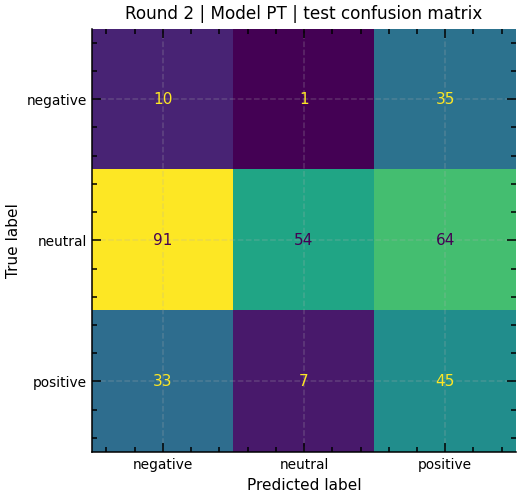

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
110,The operating margin of Aker Yards Cruise & Ferries division went down from 8.3 % to 6.4 % in the first quarter of 2...,negative,positive,0.363321,0.314695,0.321984,0.363321
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,neutral,0.359426,0.320077,0.359426,0.320496
136,"He joins Technopolis from KONE where he has held various positions within the Group , most recently as Director of S...",neutral,negative,0.357485,0.357485,0.314712,0.327803
179,"Changes being announced today will be effective after the close of trading on Friday , June 19 , 2009 .",neutral,positive,0.356554,0.311856,0.331591,0.356554
47,Fancy Dans on the move FAB Glasgow gift and interiors store Fancy Dans is moving !,neutral,positive,0.355069,0.327570,0.317361,0.355069
127,The soapstone deposits in the Medvezhyegorsk area are expected to increase Tulikivi 's current reserves considerably .,positive,neutral,0.354271,0.323502,0.354271,0.322226
17,The bond has a value of EUR150m and a maturity of 4 years .,neutral,negative,0.353007,0.353007,0.318166,0.328826
217,"Marathon now has a 4.6 percent stake in PLX , it said , according to Bloomberg .",neutral,positive,0.352489,0.334694,0.312817,0.352489


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
108,The transaction is expected to be completed next spring .,neutral,negative,0.333839,0.333839,0.333032,0.333129
333,"The company operates its business through two reportable segments , including Banking and Investment Services , and ...",neutral,positive,0.334046,0.332805,0.333150,0.334046
41,"Systeemitiimi 's sales and project resources will also be strengthened , director Paul Skogberg said .",positive,negative,0.334167,0.334167,0.332607,0.333226
251,"RFID ( Radio Frequency Identification ) is a method of so-called intelligent transport , whereby information can be ...",neutral,negative,0.334264,0.334264,0.332994,0.332742
339,"Operating profit , excluding non-recurring items , totalled EUR 1.0 mn , down from EUR 1.6 mn .",negative,positive,0.334285,0.333657,0.332058,0.334285
195,"Financial Statements include the consolidated financial statements of the Group , the Board of Directors ' Report , ...",neutral,neutral,0.334292,0.332937,0.334292,0.332771
296,`` Printed fabrics and related design expertise have always been the core of Marimekko 's business and brand .,neutral,negative,0.334299,0.334299,0.331431,0.334269
202,"They can be used to control the speed of electric motors used by industry and municipal engineering , and in power g...",neutral,neutral,0.334413,0.332894,0.334413,0.332693


Deep dive: Round 2 | Model PT
loss=1.1031 | accuracy=0.3206 | macro_f1=0.3009 | weighted_f1=0.3583
vs reference -> Δaccuracy=-0.2941, Δmacro_f1=+0.0471, Δloss=+nan

Class-wise report:


,precision,recall,f1-score,support
negative,0.0746,0.2174,0.1111,46.0
neutral,0.8710,0.2584,0.3985,209.0
positive,0.3125,0.5294,0.3930,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='neutral' predicted='negative' (count=91)
Number of wrong predictions: 231 / 340
Median confidence on wrong predictions: 0.3415
Interpretation: many mistakes are low-confidence -> the model often knows it is uncertain.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [48]:

ROUND2_RESULTS = []
ROUND2_HISTORIES = {}
ROUND2_VAL_EVALS = {}
ROUND2_TEST_EVALS = {}

model1_r2 = build_model_pt_from_name(ROUND2_CFG["model_name"], seed=ROUND2_CFG["seed"])
show_parameter_summary(model1_r2, "Round 2 | Model PT | parameter summary", only_trainable=True)

model1_r2_val = evaluate_model(model1_r2, val_loader_r2, split_frames["validation"])
model1_r2_test = evaluate_model(model1_r2, test_loader_r2, split_frames["test"])

print("Round 2 | Model 1 | validation metrics:", model1_r2_val["metrics"])
print("Round 2 | Model 1 | test metrics      :", model1_r2_test["metrics"])

plot_confusion(model1_r2_test, "Round 2 | Model PT | test confusion matrix")
display(show_top_errors(model1_r2_test, n=8))
display(show_low_confidence_cases(model1_r2_test, n=8))
deep_dive_report("Round 2 | Model PT", model1_r2_test, reference_eval=majority_test)

register_result(
    ROUND2_RESULTS,
    "Model PT",
    model1_r2,
    model1_r2_val,
    model1_r2_test,
    notes=f"Round 2 anchor model; no financial FT; max_length={ROUND2_CFG['max_length']}",
)
ROUND2_VAL_EVALS["Model PT"] = model1_r2_val
ROUND2_TEST_EVALS["Model PT"] = model1_r2_test

model1_r2.to("cpu")
cleanup()


## Round 2 / Model 2 — Model PT + FT Classifier

Round 2's Model 2 keeps the head-only configuration but adjusts the training protocol. Epoch count and learning rate are revised based on Round 1's training dynamics. Class weights come on if the Round 1 per-class diagnostics warrant. Mild label smoothing comes on if Round 1's wrong-prediction confidence was high. Early stopping is introduced to avoid extended training past the point where validation stops improving.


In [49]:

model2_r2 = build_model_pt_from_name(ROUND2_CFG["model_name"], seed=ROUND2_CFG["seed"])
freeze_all_but_default_head(model2_r2)
show_parameter_summary(model2_r2, "Round 2 | Model PT + FT Classifier | trainable parameters", only_trainable=True)

print("Round-2 head-only setup")
print(f"epochs          : {ROUND2_CFG['head_only_epochs']}")
print(f"lr              : {ROUND2_CFG['head_only_lr']:.2e}")
print(f"class_weights   : {round2_class_weights}")
print(f"label_smoothing : {ROUND2_CFG['label_smoothing']}")

model2_r2, model2_r2_history, model2_r2_best_val = fit_model_round2(
    model2_r2,
    train_loader_r2,
    val_loader_r2,
    split_frames["train"],
    split_frames["validation"],
    epochs=ROUND2_CFG["head_only_epochs"],
    lr=ROUND2_CFG["head_only_lr"],
    weight_decay=ROUND2_CFG["weight_decay"],
    warmup_ratio=ROUND2_CFG["warmup_ratio"],
    clip_grad_norm=ROUND2_CFG["clip_grad_norm"],
    class_weights=round2_class_weights,
    label_smoothing=ROUND2_CFG["label_smoothing"],
    early_stopping_patience=ROUND2_CFG["early_stopping_patience"],
    min_epochs_before_stop=ROUND2_CFG["min_epochs_before_stop"],
    device=DEVICE,
    model_name="Round 2 | Model 2",
)

model2_r2_val = evaluate_model(model2_r2, val_loader_r2, split_frames["validation"])
model2_r2_test = evaluate_model(model2_r2, test_loader_r2, split_frames["test"])
best_model2_r2_state = copy.deepcopy(model2_r2.state_dict())


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Round 2 | Model PT + FT Classifier | trainable parameters
Total params     : 66,955,779
Trainable params : 592,899
Trainable ratio  : 0.008855


,name,shape,num_params,requires_grad
0,pre_classifier.weight,"(768, 768)",589824,True
1,pre_classifier.bias,"(768,)",768,True
2,classifier.weight,"(3, 768)",2304,True
3,classifier.bias,"(3,)",3,True


Round-2 head-only setup
epochs          : 5
lr              : 4.50e-04
class_weights   : None
label_smoothing : 0.03


Round 2 | Model 2 | round2 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7326 | val_loss=0.5346 | val_acc=0.7676 | val_macro_f1=0.6440


Round 2 | Model 2 | round2 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.5019 | val_loss=0.4591 | val_acc=0.8353 | val_macro_f1=0.7342


Round 2 | Model 2 | round2 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4422 | val_loss=0.4496 | val_acc=0.8324 | val_macro_f1=0.7495


Round 2 | Model 2 | round2 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.4113 | val_loss=0.4283 | val_acc=0.8294 | val_macro_f1=0.7370


Round 2 | Model 2 | round2 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3911 | val_loss=0.4199 | val_acc=0.8559 | val_macro_f1=0.7664


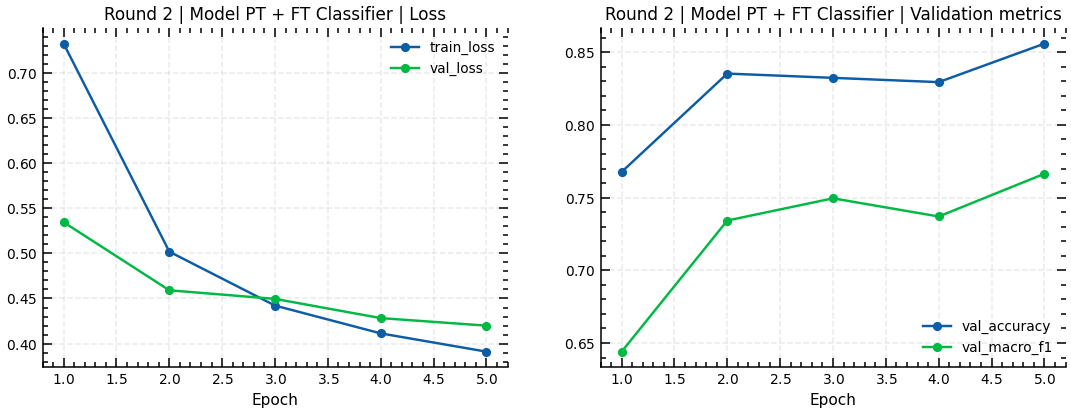

Round 2 | Model 2 | validation metrics: {'accuracy': 0.8558823529411764, 'macro_precision': 0.7910727227569584, 'macro_recall': 0.7551966008514356, 'macro_f1': 0.7663733352257941, 'weighted_f1': 0.8523175201526214, 'loss': 0.35368422515252057}
Round 2 | Model 2 | test metrics      : {'accuracy': 0.8382352941176471, 'macro_precision': 0.79048822504922, 'macro_recall': 0.7414146852833082, 'macro_f1': 0.7568395400607179, 'weighted_f1': 0.8349036133147574, 'loss': 0.36832054888500887}


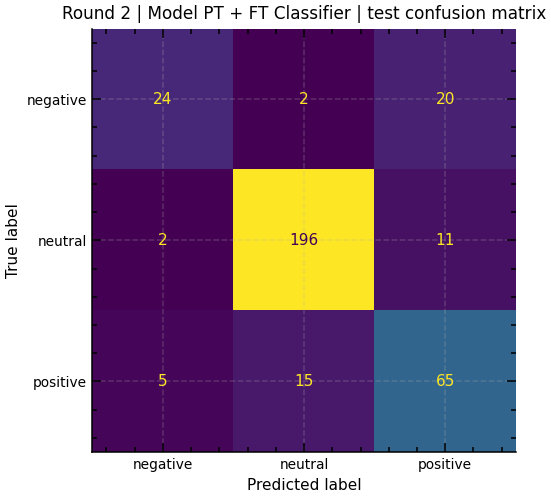

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
263,"These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has suff...",positive,neutral,0.952148,0.001718,0.952148,0.046134
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,neutral,0.943242,0.002117,0.943242,0.054641
150,Cargotec Germany GmbH has been awarded a contract by Stadtverwaltung Mainz for chassis bodies under Open procedure .,positive,neutral,0.897077,0.003448,0.897077,0.099475
99,No changes in media activity were seen in October compared with September .,neutral,negative,0.875446,0.875446,0.022073,0.102481
159,Viking Line manages well with its current ferries .,positive,neutral,0.873125,0.025803,0.873125,0.101071
42,"OUTOTEC OYJ PRESS RELEASE , FEBRUARY 19 , 2008 AT 11.00 AM Outotec has won two large minerals processing technology ...",positive,neutral,0.828389,0.007072,0.828389,0.164539
106,"Comparable operating profit totaled EUR 4.7 mn , down from EUR 5.1 mn in the corresponding period in 2005 , represen...",negative,positive,0.787134,0.197481,0.015385,0.787134
286,"Citigroup , Inc ( NYSE : C ) has announced that its Global Transaction Services ( GTS ) business has been awarded a ...",positive,neutral,0.768583,0.014552,0.768583,0.216865


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
141,UPM-Kymmene said its has ` not indicated any interest in any domestic consolidations ' .,neutral,neutral,0.405967,0.244140,0.405967,0.349893
207,"In the second quarter of 2010 , the group 's pretax loss narrowed to EUR 400,000 from EUR 600,000 .",positive,positive,0.431937,0.409841,0.158222,0.431937
339,"Operating profit , excluding non-recurring items , totalled EUR 1.0 mn , down from EUR 1.6 mn .",negative,negative,0.433030,0.433030,0.183375,0.383595
110,The operating margin of Aker Yards Cruise & Ferries division went down from 8.3 % to 6.4 % in the first quarter of 2...,negative,negative,0.454564,0.454564,0.178749,0.366687
146,Finnish Cargotec 's Kalmar has received a significant order from the US Department of Defense .,positive,positive,0.465094,0.074778,0.460128,0.465094
314,"ADPnews - Jul 17 , 2009 - Finland-based steel maker Rautaruukki Oyj Ruukki HEL : RTRKS said today it slipped to a ne...",negative,positive,0.471361,0.459459,0.069181,0.471361
129,Earnings per share EPS amounted to EUR0 .01 .,neutral,positive,0.474796,0.187427,0.337777,0.474796
81,Productional situation has now improved .,positive,neutral,0.476956,0.070316,0.476956,0.452727


Deep dive: Round 2 | Model PT + FT Classifier
loss=0.3683 | accuracy=0.8382 | macro_f1=0.7568 | weighted_f1=0.8349
vs reference -> Δaccuracy=+0.0176, Δmacro_f1=+0.0326, Δloss=-0.0183

Class-wise report:


,precision,recall,f1-score,support
negative,0.7742,0.5217,0.6234,46.0
neutral,0.9202,0.9378,0.9289,209.0
positive,0.6771,0.7647,0.7182,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy is noticeably higher than macro F1 -> some classes are still much weaker than others.
Most frequent confusion: true='negative' predicted='positive' (count=20)
Number of wrong predictions: 55 / 340
Median confidence on wrong predictions: 0.5832
Interpretation: mistakes are mixed-confidence -> both representation quality and boundary sharpness matter.
Approx. last-epoch generalization gap (val_loss - train_loss): +0.0288
Interpretation: train/validation losses are in a relatively healthy range.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [50]:

plot_history(model2_r2_history, "Round 2 | Model PT + FT Classifier")
print("Round 2 | Model 2 | validation metrics:", model2_r2_val["metrics"])
print("Round 2 | Model 2 | test metrics      :", model2_r2_test["metrics"])

plot_confusion(model2_r2_test, "Round 2 | Model PT + FT Classifier | test confusion matrix")
display(show_top_errors(model2_r2_test, n=8))
display(show_low_confidence_cases(model2_r2_test, n=8))
deep_dive_report("Round 2 | Model PT + FT Classifier", model2_r2_test, history_df=model2_r2_history, reference_eval=ROUND1_TEST_EVALS["Model PT + FT Classifier"])

register_result(
    ROUND2_RESULTS,
    "Model PT + FT Classifier",
    model2_r2,
    model2_r2_val,
    model2_r2_test,
    notes="Round-2 head-only FT with evidence-driven epoch/lr + optional weighted CE + optional label smoothing",
)
ROUND2_HISTORIES["Model PT + FT Classifier"] = model2_r2_history
ROUND2_VAL_EVALS["Model PT + FT Classifier"] = model2_r2_val
ROUND2_TEST_EVALS["Model PT + FT Classifier"] = model2_r2_test


### Reading Round-2 Model 2

The diagnostics worth checking:

Did class weighting actually improve recall and F1 on the previously weakest class?

Did label smoothing reduce the rate of confidently wrong predictions?

Did the more conservative training cadence let the head extract additional signal from the frozen representation?

A clear improvement in Model 2 here would suggest that Round 1's limit wasn't model capacity — it was training protocol. If the same head can do better with a different protocol, the head wasn't actually saturated.


## Round 2 / Model 3 — Model PT + Own FT Classifier

Round 2 changes the head structurally rather than enlarging it. The default `ReLU` is replaced with `GELU`, which matches the activation typically used inside transformers and gives a smoother non-linearity. A `LayerNorm` is optionally inserted to stabilise the head's input distribution when the backbone is frozen.

The empirical question this is trying to answer: how much does the head's structural inductive bias matter, given that the backbone is held fixed?


In [51]:

model3_r2 = DistilBertWithCustomHeadV2(
    base_model_name=ROUND2_CFG["model_name"],
    num_labels=len(LABEL_ORDER),
    hidden_dims=ROUND2_CFG["custom_head_hidden_dims"],
    dropout=ROUND2_CFG["custom_head_dropout"],
    activation=ROUND2_CFG["custom_head_activation"],
    use_layernorm=ROUND2_CFG["custom_head_layernorm"],
    id2label=id2label,
    label2id=label2id,
)
freeze_backbone_unfreeze_custom_head(model3_r2)
show_parameter_summary(model3_r2, "Round 2 | Model PT + Own FT Classifier | trainable parameters", only_trainable=True)

print("Round-2 custom head setup")
print(f"hidden_dims      : {ROUND2_CFG['custom_head_hidden_dims']}")
print(f"dropout          : {ROUND2_CFG['custom_head_dropout']}")
print(f"activation       : {ROUND2_CFG['custom_head_activation']}")
print(f"use_layernorm    : {ROUND2_CFG['custom_head_layernorm']}")
print(f"lr               : {ROUND2_CFG['custom_head_lr']:.2e}")
print(f"epochs           : {ROUND2_CFG['custom_head_epochs']}")

model3_r2, model3_r2_history, model3_r2_best_val = fit_model_round2(
    model3_r2,
    train_loader_r2,
    val_loader_r2,
    split_frames["train"],
    split_frames["validation"],
    epochs=ROUND2_CFG["custom_head_epochs"],
    lr=ROUND2_CFG["custom_head_lr"],
    weight_decay=ROUND2_CFG["weight_decay"],
    warmup_ratio=ROUND2_CFG["warmup_ratio"],
    clip_grad_norm=ROUND2_CFG["clip_grad_norm"],
    class_weights=round2_class_weights,
    label_smoothing=ROUND2_CFG["label_smoothing"],
    early_stopping_patience=ROUND2_CFG["early_stopping_patience"],
    min_epochs_before_stop=ROUND2_CFG["min_epochs_before_stop"],
    device=DEVICE,
    model_name="Round 2 | Model 3",
)

model3_r2_val = evaluate_model(model3_r2, val_loader_r2, split_frames["validation"])
model3_r2_test = evaluate_model(model3_r2, test_loader_r2, split_frames["test"])


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Round 2 | Model PT + Own FT Classifier | trainable parameters
Total params     : 66,708,867
Trainable params : 345,987
Trainable ratio  : 0.005187


,name,shape,num_params,requires_grad
0,classifier_head.0.weight,"(384, 768)",294912,True
1,classifier_head.0.bias,"(384,)",384,True
2,classifier_head.1.weight,"(384,)",384,True
3,classifier_head.1.bias,"(384,)",384,True
4,classifier_head.4.weight,"(128, 384)",49152,True
5,classifier_head.4.bias,"(128,)",128,True
6,classifier_head.5.weight,"(128,)",128,True
7,classifier_head.5.bias,"(128,)",128,True
8,classifier_head.8.weight,"(3, 128)",384,True
9,classifier_head.8.bias,"(3,)",3,True


Round-2 custom head setup
hidden_dims      : (384, 128)
dropout          : 0.2
activation       : gelu
use_layernorm    : True
lr               : 2.70e-04
epochs           : 5


Round 2 | Model 3 | round2 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7460 | val_loss=0.5121 | val_acc=0.8176 | val_macro_f1=0.6890


Round 2 | Model 3 | round2 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.5162 | val_loss=0.4615 | val_acc=0.8118 | val_macro_f1=0.7166


Round 2 | Model 3 | round2 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4533 | val_loss=0.4638 | val_acc=0.8059 | val_macro_f1=0.6544


Round 2 | Model 3 | round2 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.4008 | val_loss=0.4115 | val_acc=0.8529 | val_macro_f1=0.7752


Round 2 | Model 3 | round2 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3800 | val_loss=0.4029 | val_acc=0.8618 | val_macro_f1=0.7803


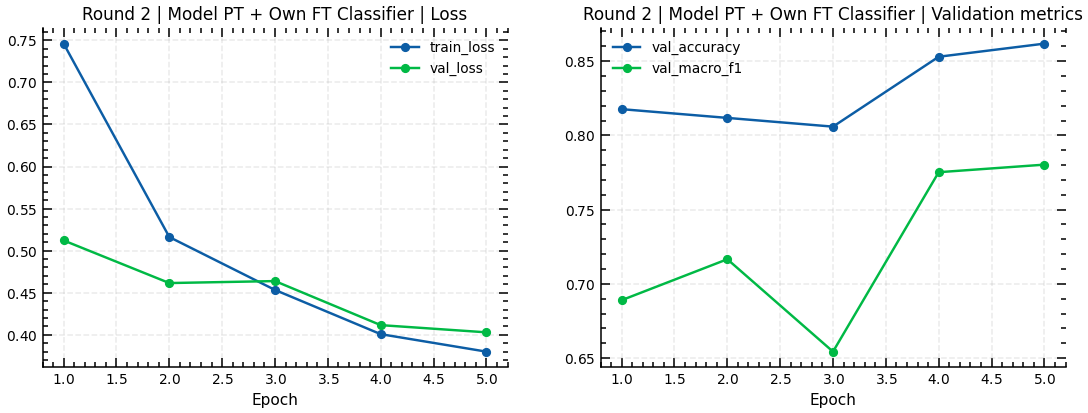

Round 2 | Model 3 | validation metrics: {'accuracy': 0.861764705882353, 'macro_precision': 0.7784042470743238, 'macro_recall': 0.782886803572238, 'macro_f1': 0.7802867481024022, 'weighted_f1': 0.8630978653125696, 'loss': 0.3363205629236558}
Round 2 | Model 3 | test metrics      : {'accuracy': 0.8676470588235294, 'macro_precision': 0.8162664225273355, 'macro_recall': 0.792601067887109, 'macro_f1': 0.8020202020202021, 'weighted_f1': 0.8661790170613699, 'loss': 0.3397447607096504}


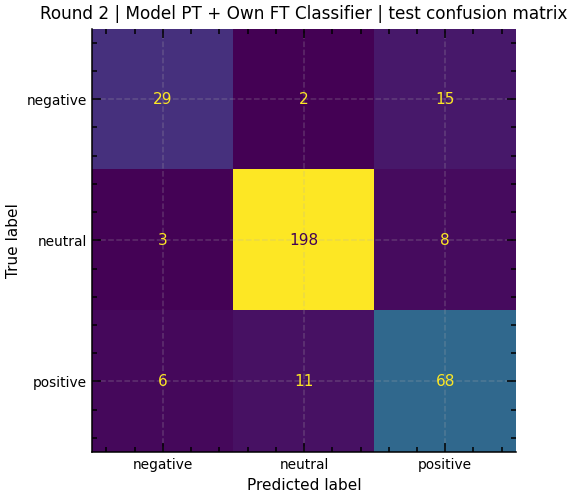

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
159,Viking Line manages well with its current ferries .,positive,neutral,0.973118,0.006400,0.973118,0.020482
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,neutral,0.957009,0.004265,0.957009,0.038726
263,"These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has suff...",positive,neutral,0.954041,0.004318,0.954041,0.041641
150,Cargotec Germany GmbH has been awarded a contract by Stadtverwaltung Mainz for chassis bodies under Open procedure .,positive,neutral,0.885056,0.006982,0.885056,0.107961
99,No changes in media activity were seen in October compared with September .,neutral,negative,0.878457,0.878457,0.035387,0.086157
120,"Protalix closed at $ 10.71 on Friday on the American Stock Exchange , giving a market cap of $ 827 million .",neutral,negative,0.855988,0.855988,0.099431,0.044581
327,"ADP News - Nov 13 , 2008 - Finnish printed circuit board PCB maker Aspocomp Group Oyj OMX : ACG1V said today that it...",positive,negative,0.852460,0.852460,0.028454,0.119086
42,"OUTOTEC OYJ PRESS RELEASE , FEBRUARY 19 , 2008 AT 11.00 AM Outotec has won two large minerals processing technology ...",positive,neutral,0.827139,0.007498,0.827139,0.165363


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
141,UPM-Kymmene said its has ` not indicated any interest in any domestic consolidations ' .,neutral,neutral,0.461359,0.305837,0.461359,0.232803
114,Another noticeable thing is that the search for Tata and Airtel brands was mostly related to ` broadband connections...,neutral,neutral,0.469834,0.465079,0.469834,0.065088
129,Earnings per share EPS amounted to EUR0 .01 .,neutral,neutral,0.481288,0.094352,0.481288,0.424360
81,Productional situation has now improved .,positive,neutral,0.491077,0.021987,0.491077,0.486936
87,Return on capital employed rose by 4.8 percentage points to 19.6 % .,positive,positive,0.498582,0.487995,0.013423,0.498582
146,Finnish Cargotec 's Kalmar has received a significant order from the US Department of Defense .,positive,positive,0.504712,0.023006,0.472281,0.504712
326,"According to CEO Matti Perkonoja of the parent company HKScan , the company 's performance in the first quarter of 2...",negative,positive,0.504865,0.476679,0.018455,0.504865
166,The net sales of Healthcare Trade business in 2009 were EUR 145.1 million EUR 155.2 million and operating profit EUR...,neutral,positive,0.505783,0.034395,0.459822,0.505783


Deep dive: Round 2 | Model PT + Own FT Classifier
loss=0.3397 | accuracy=0.8676 | macro_f1=0.8020 | weighted_f1=0.8662
vs reference -> Δaccuracy=+0.1147, Δmacro_f1=+0.3027, Δloss=-0.1719

Class-wise report:


,precision,recall,f1-score,support
negative,0.7632,0.6304,0.6905,46.0
neutral,0.9384,0.9474,0.9429,209.0
positive,0.7473,0.8000,0.7727,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='negative' predicted='positive' (count=15)
Number of wrong predictions: 45 / 340
Median confidence on wrong predictions: 0.7134
Interpretation: many mistakes are high-confidence -> features may be systematically misleading, not just noisy.
Approx. last-epoch generalization gap (val_loss - train_loss): +0.0230
Interpretation: train/validation losses are in a relatively healthy range.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [52]:

plot_history(model3_r2_history, "Round 2 | Model PT + Own FT Classifier")
print("Round 2 | Model 3 | validation metrics:", model3_r2_val["metrics"])
print("Round 2 | Model 3 | test metrics      :", model3_r2_test["metrics"])

plot_confusion(model3_r2_test, "Round 2 | Model PT + Own FT Classifier | test confusion matrix")
display(show_top_errors(model3_r2_test, n=8))
display(show_low_confidence_cases(model3_r2_test, n=8))
deep_dive_report("Round 2 | Model PT + Own FT Classifier", model3_r2_test, history_df=model3_r2_history, reference_eval=ROUND1_TEST_EVALS["Model PT + Own FT Classifier"])

register_result(
    ROUND2_RESULTS,
    "Model PT + Own FT Classifier",
    model3_r2,
    model3_r2_val,
    model3_r2_test,
    notes="Round-2 custom head: GELU + optional LayerNorm + evidence-driven width/dropout",
)
ROUND2_HISTORIES["Model PT + Own FT Classifier"] = model3_r2_history
ROUND2_VAL_EVALS["Model PT + Own FT Classifier"] = model3_r2_val
ROUND2_TEST_EVALS["Model PT + Own FT Classifier"] = model3_r2_test


### Reading Round-2 Model 3

Two readings are diagnostic.

If Round-2 Model 3 improves over Round-1 Model 3, is the improvement coming from the more transformer-aligned head structure (GELU + LayerNorm), or from the training-side changes (class weights, smoothing, early stopping) that Round 2 applied to all models? The improvement in Round-2 Model 2 (head only) gives the baseline for separating these.

If Round-2 Model 3 still loses to Round-2 Model 2, the implication is that the bottleneck under a frozen backbone is the representation itself, not the head's expressive capacity. Further investment in head architecture is unlikely to pay off without unfreezing the body.


## Round 2 / Model 4 — Model PT + FT Classifier + FT Base

Round 2's Model 4 starts from the freshly trained Round-2 Model 2 (so the head reflects Round 2's improvements), freezes the head, and trains only the body. Body learning rate and epoch budget are adjusted based on Round 1's training dynamics — more conservative if Round 1 showed quick overfitting, longer or slightly less conservative if Round 1 showed continued improvement at the final epoch.


In [53]:

model4_r2 = build_model_pt_from_name(ROUND2_CFG["model_name"], seed=ROUND2_CFG["seed"])
model4_r2.load_state_dict(best_model2_r2_state)
freeze_default_head_unfreeze_body(model4_r2)
show_parameter_summary(model4_r2, "Round 2 | Model PT + FT Classifier + FT Base | trainable parameters", only_trainable=True)

print("Round-2 body-only setup")
print(f"epochs          : {ROUND2_CFG['body_only_epochs']}")
print(f"lr              : {ROUND2_CFG['body_only_lr']:.2e}")
print(f"class_weights   : {round2_class_weights}")
print(f"label_smoothing : {ROUND2_CFG['label_smoothing']}")

model4_r2, model4_r2_history, model4_r2_best_val = fit_model_round2(
    model4_r2,
    train_loader_r2,
    val_loader_r2,
    split_frames["train"],
    split_frames["validation"],
    epochs=ROUND2_CFG["body_only_epochs"],
    lr=ROUND2_CFG["body_only_lr"],
    weight_decay=ROUND2_CFG["weight_decay"],
    warmup_ratio=ROUND2_CFG["warmup_ratio"],
    clip_grad_norm=ROUND2_CFG["clip_grad_norm"],
    class_weights=round2_class_weights,
    label_smoothing=ROUND2_CFG["label_smoothing"],
    early_stopping_patience=ROUND2_CFG["early_stopping_patience"],
    min_epochs_before_stop=ROUND2_CFG["min_epochs_before_stop"],
    device=DEVICE,
    model_name="Round 2 | Model 4",
)

model4_r2_val = evaluate_model(model4_r2, val_loader_r2, split_frames["validation"])
model4_r2_test = evaluate_model(model4_r2, test_loader_r2, split_frames["test"])


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Round 2 | Model PT + FT Classifier + FT Base | trainable parameters
Total params     : 66,955,779
Trainable params : 66,362,880
Trainable ratio  : 0.991145


,name,shape,num_params,requires_grad
0,distilbert.embeddings.word_embeddings.weight,"(30522, 768)",23440896,True
1,distilbert.embeddings.position_embeddings.weight,"(512, 768)",393216,True
2,distilbert.embeddings.LayerNorm.weight,"(768,)",768,True
3,distilbert.embeddings.LayerNorm.bias,"(768,)",768,True
4,distilbert.transformer.layer.0.attention.q_lin.weight,"(768, 768)",589824,True
5,distilbert.transformer.layer.0.attention.q_lin.bias,"(768,)",768,True
6,distilbert.transformer.layer.0.attention.k_lin.weight,"(768, 768)",589824,True
7,distilbert.transformer.layer.0.attention.k_lin.bias,"(768,)",768,True
8,distilbert.transformer.layer.0.attention.v_lin.weight,"(768, 768)",589824,True
9,distilbert.transformer.layer.0.attention.v_lin.bias,"(768,)",768,True


Round-2 body-only setup
epochs          : 4
lr              : 2.20e-05
class_weights   : None
label_smoothing : 0.03


Round 2 | Model 4 | round2 epoch 1/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.3114 | val_loss=0.2242 | val_acc=0.9559 | val_macro_f1=0.9418


Round 2 | Model 4 | round2 epoch 2/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.1719 | val_loss=0.1972 | val_acc=0.9676 | val_macro_f1=0.9559


Round 2 | Model 4 | round2 epoch 3/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.1339 | val_loss=0.1873 | val_acc=0.9676 | val_macro_f1=0.9557


Round 2 | Model 4 | round2 epoch 4/4:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.1239 | val_loss=0.1839 | val_acc=0.9735 | val_macro_f1=0.9611


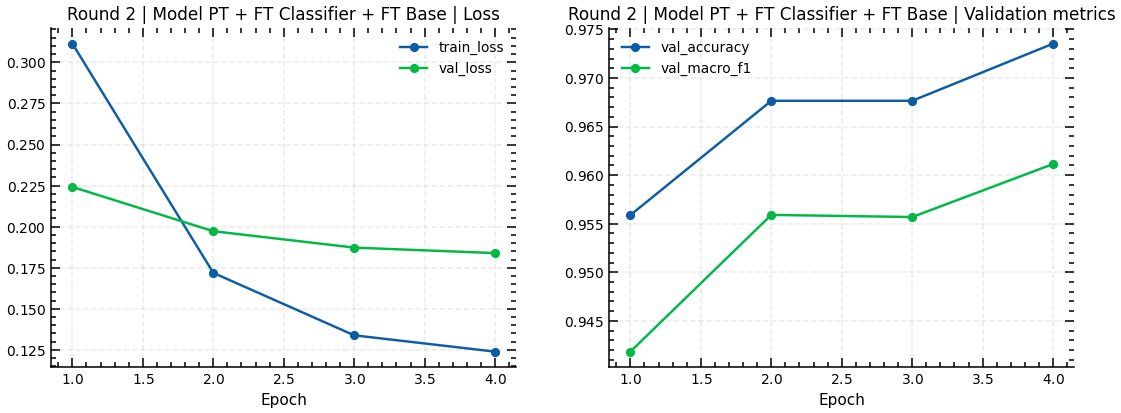

Round 2 | Model 4 | validation metrics: {'accuracy': 0.9735294117647059, 'macro_precision': 0.95749347548448, 'macro_recall': 0.9648966202209777, 'macro_f1': 0.9611388130174258, 'weighted_f1': 0.9736584373633845, 'loss': 0.09232337772846222}
Round 2 | Model 4 | test metrics      : {'accuracy': 0.961764705882353, 'macro_precision': 0.9415241824885294, 'macro_recall': 0.9563300252491261, 'macro_f1': 0.9486018376913226, 'weighted_f1': 0.961994106456787, 'loss': 0.11245009478400736}


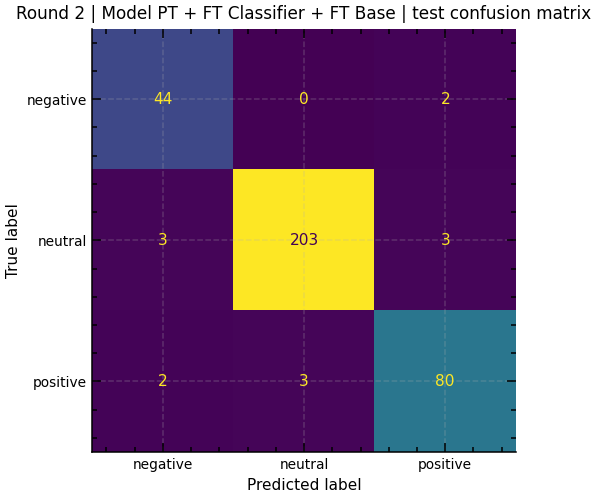

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
113,Finnish power supply solutions and systems provider Efore Oyj said its net loss widened to 3.2 mln euro $ 4.2 mln fo...,negative,positive,0.969115,0.015514,0.015371,0.969115
299,Atria said its offer would give the Swedish company continued ownership and control of its slaughtering and cutting ...,neutral,positive,0.958192,0.003129,0.038679,0.958192
275,"Operating loss was EUR 179mn , compared to a loss of EUR 188mn in the second quarter of 2009 .",positive,negative,0.937995,0.937995,0.002351,0.059655
208,"Fiskars , a 360-year-old global business best known for its orange-handled scissors , expects to derive synergies of...",positive,neutral,0.914111,0.005879,0.914111,0.080010
263,"These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has suff...",positive,neutral,0.858963,0.007507,0.858963,0.133530
167,These moderate but significant changes resulted in a significant 24-32 % reduction in the estimated CVD risk .,positive,negative,0.851060,0.851060,0.025912,0.123028
120,"Protalix closed at $ 10.71 on Friday on the American Stock Exchange , giving a market cap of $ 827 million .",neutral,negative,0.771643,0.771643,0.222162,0.006194
159,Viking Line manages well with its current ferries .,positive,neutral,0.771013,0.039370,0.771013,0.189617


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
99,No changes in media activity were seen in October compared with September .,neutral,negative,0.528469,0.528469,0.246829,0.224701
10,"The company reported a profit of 800,000 euro ($ 1.2 mln)on the sale of its Varesvuo Partners sub-group and a loss o...",neutral,negative,0.544601,0.544601,0.424461,0.030938
249,"In January-June 2010 , diluted loss per share stood at EUR0 .3 versus EUR0 .1 in the first half of 2009 .",negative,negative,0.552332,0.552332,0.009149,0.438519
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,positive,0.585308,0.017094,0.397597,0.585308
320,"In the third quarter of fiscal 2008 Efore swung to a net loss of EUR 400,000 versus a net profit of EUR 200,000 for ...",negative,positive,0.596251,0.399974,0.003775,0.596251
257,Following this increase Huhtamaki 's registered share capital is EUR360 .62 m and the number of shares outstanding i...,neutral,neutral,0.602367,0.020718,0.602367,0.376915
286,"Citigroup , Inc ( NYSE : C ) has announced that its Global Transaction Services ( GTS ) business has been awarded a ...",positive,positive,0.617786,0.009088,0.373126,0.617786
326,"According to CEO Matti Perkonoja of the parent company HKScan , the company 's performance in the first quarter of 2...",negative,negative,0.640031,0.640031,0.066155,0.293814


Deep dive: Round 2 | Model PT + FT Classifier + FT Base
loss=0.1125 | accuracy=0.9618 | macro_f1=0.9486 | weighted_f1=0.9620
vs reference -> Δaccuracy=+0.0059, Δmacro_f1=+0.0066, Δloss=-0.0560

Class-wise report:


,precision,recall,f1-score,support
negative,0.8980,0.9565,0.9263,46.0
neutral,0.9854,0.9713,0.9783,209.0
positive,0.9412,0.9412,0.9412,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='neutral' predicted='negative' (count=3)
Number of wrong predictions: 13 / 340
Median confidence on wrong predictions: 0.7716
Interpretation: many mistakes are high-confidence -> features may be systematically misleading, not just noisy.
Approx. last-epoch generalization gap (val_loss - train_loss): +0.0600
Interpretation: train/validation losses are in a relatively healthy range.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [54]:

plot_history(model4_r2_history, "Round 2 | Model PT + FT Classifier + FT Base")
print("Round 2 | Model 4 | validation metrics:", model4_r2_val["metrics"])
print("Round 2 | Model 4 | test metrics      :", model4_r2_test["metrics"])

plot_confusion(model4_r2_test, "Round 2 | Model PT + FT Classifier + FT Base | test confusion matrix")
display(show_top_errors(model4_r2_test, n=8))
display(show_low_confidence_cases(model4_r2_test, n=8))
deep_dive_report("Round 2 | Model PT + FT Classifier + FT Base", model4_r2_test, history_df=model4_r2_history, reference_eval=ROUND1_TEST_EVALS["Model PT + FT Classifier + FT Base"])

register_result(
    ROUND2_RESULTS,
    "Model PT + FT Classifier + FT Base",
    model4_r2,
    model4_r2_val,
    model4_r2_test,
    notes="Round-2 body-only FT from round-2 Model 2 with tuned epochs/lr and optional weighted CE/smoothing",
)
ROUND2_HISTORIES["Model PT + FT Classifier + FT Base"] = model4_r2_history
ROUND2_VAL_EVALS["Model PT + FT Classifier + FT Base"] = model4_r2_val
ROUND2_TEST_EVALS["Model PT + FT Classifier + FT Base"] = model4_r2_test


### Reading Round-2 Model 4

If Round-2 Model 4 substantially beats Round-2 Model 2, the conclusion is that even after the head has converged, additional adaptation of the body to financial-domain language continues to produce gains. This supports the more general claim that when the target distribution differs noticeably from the general-domain pretraining distribution, head-only adaptation hits a relatively low ceiling and representation adaptation is what extracts further signal.


## Round 2 / Model 5 — Model PT + FT Classifier + PEFT Base (LoRA)

The structural constraints on Model 5 don't change. LoRA adapters on FFN `lin1` and `lin2` only, rank fixed at 8, no automated PEFT library. Round 2 adjusts only what the assignment leaves open: the LoRA learning rate and epoch count, the LoRA `alpha` scaling, the LoRA dropout, and the loss-side options (class weights and label smoothing) that the rest of Round 2 also uses.


In [55]:

model5_r2 = build_model_pt_from_name(ROUND2_CFG["model_name"], seed=ROUND2_CFG["seed"])
model5_r2.load_state_dict(best_model2_r2_state)
freeze_everything(model5_r2)
round2_lora_targets = insert_lora_into_ffn(
    model5_r2,
    rank=ROUND2_CFG["lora_rank"],
    alpha=ROUND2_CFG["lora_alpha"],
    dropout=ROUND2_CFG["lora_dropout"],
)
assert len(round2_lora_targets) == 12, f"Expected 12 FFN linear targets in DistilBERT, got {len(round2_lora_targets)}"

round2_lora_breakdown = expected_lora_parameter_breakdown(model5_r2)
expected_round2_lora_params = int(round2_lora_breakdown["expected_params"].sum())
actual_round2_lora_params = int(round2_lora_breakdown["actual_params"].sum())
_, round2_trainable_params = count_parameters(model5_r2)

print("Round-2 LoRA parameter breakdown")
display(round2_lora_breakdown)
print(f"Expected trainable LoRA params (formula): {expected_round2_lora_params:,}")
print(f"Actual   trainable LoRA params (A/B only): {actual_round2_lora_params:,}")
print(f"Model-reported trainable params         : {round2_trainable_params:,}")
assert expected_round2_lora_params == 368640, "For DistilBERT default FFN dims and rank=8, expected LoRA param count should stay 368,640."
assert actual_round2_lora_params == expected_round2_lora_params == round2_trainable_params

show_parameter_summary(model5_r2, "Round 2 | Model PT + FT Classifier + PEFT Base | trainable parameters", only_trainable=True)

print("Round-2 LoRA setup")
print(f"epochs          : {ROUND2_CFG['lora_epochs']}")
print(f"lr              : {ROUND2_CFG['lora_lr']:.2e}")
print(f"rank            : {ROUND2_CFG['lora_rank']}")
print(f"alpha           : {ROUND2_CFG['lora_alpha']}")
print(f"dropout         : {ROUND2_CFG['lora_dropout']}")
print(f"class_weights   : {round2_class_weights}")
print(f"label_smoothing : {ROUND2_CFG['label_smoothing']}")

model5_r2, model5_r2_history, model5_r2_best_val = fit_model_round2(
    model5_r2,
    train_loader_r2,
    val_loader_r2,
    split_frames["train"],
    split_frames["validation"],
    epochs=ROUND2_CFG["lora_epochs"],
    lr=ROUND2_CFG["lora_lr"],
    weight_decay=ROUND2_CFG["weight_decay"],
    warmup_ratio=ROUND2_CFG["warmup_ratio"],
    clip_grad_norm=ROUND2_CFG["clip_grad_norm"],
    class_weights=round2_class_weights,
    label_smoothing=ROUND2_CFG["label_smoothing"],
    early_stopping_patience=ROUND2_CFG["early_stopping_patience"],
    min_epochs_before_stop=ROUND2_CFG["min_epochs_before_stop"],
    device=DEVICE,
    model_name="Round 2 | Model 5",
)

model5_r2_val = evaluate_model(model5_r2, val_loader_r2, split_frames["validation"])
model5_r2_test = evaluate_model(model5_r2, test_loader_r2, split_frames["test"])


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FFN target modules:
  distilbert.transformer.layer.0.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.0.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.1.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.1.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.2.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.2.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.3.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.3.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.4.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.4.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.5.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.5.ffn.lin2: 3072 -> 768
Round-2 LoRA parameter breakdown


,module,in_features,out_features,rank,expected_params,actual_params
0,distilbert.transformer.layer.0.ffn.lin1,768,3072,8,30720,30720
1,distilbert.transformer.layer.0.ffn.lin2,3072,768,8,30720,30720
2,distilbert.transformer.layer.1.ffn.lin1,768,3072,8,30720,30720
3,distilbert.transformer.layer.1.ffn.lin2,3072,768,8,30720,30720
4,distilbert.transformer.layer.2.ffn.lin1,768,3072,8,30720,30720
5,distilbert.transformer.layer.2.ffn.lin2,3072,768,8,30720,30720
6,distilbert.transformer.layer.3.ffn.lin1,768,3072,8,30720,30720
7,distilbert.transformer.layer.3.ffn.lin2,3072,768,8,30720,30720
8,distilbert.transformer.layer.4.ffn.lin1,768,3072,8,30720,30720
9,distilbert.transformer.layer.4.ffn.lin2,3072,768,8,30720,30720


Expected trainable LoRA params (formula): 368,640
Actual   trainable LoRA params (A/B only): 368,640
Model-reported trainable params         : 368,640
Round 2 | Model PT + FT Classifier + PEFT Base | trainable parameters
Total params     : 67,324,419
Trainable params : 368,640
Trainable ratio  : 0.005476


,name,shape,num_params,requires_grad
0,distilbert.transformer.layer.0.ffn.lin1.A,"(8, 768)",6144,True
1,distilbert.transformer.layer.0.ffn.lin1.B,"(3072, 8)",24576,True
2,distilbert.transformer.layer.0.ffn.lin2.A,"(8, 3072)",24576,True
3,distilbert.transformer.layer.0.ffn.lin2.B,"(768, 8)",6144,True
4,distilbert.transformer.layer.1.ffn.lin1.A,"(8, 768)",6144,True
5,distilbert.transformer.layer.1.ffn.lin1.B,"(3072, 8)",24576,True
6,distilbert.transformer.layer.1.ffn.lin2.A,"(8, 3072)",24576,True
7,distilbert.transformer.layer.1.ffn.lin2.B,"(768, 8)",6144,True
8,distilbert.transformer.layer.2.ffn.lin1.A,"(8, 768)",6144,True
9,distilbert.transformer.layer.2.ffn.lin1.B,"(3072, 8)",24576,True


Round-2 LoRA setup
epochs          : 5
lr              : 3.75e-04
rank            : 8
alpha           : 8
dropout         : 0.05
class_weights   : None
label_smoothing : 0.03


Round 2 | Model 5 | round2 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.3421 | val_loss=0.3019 | val_acc=0.9265 | val_macro_f1=0.8921


Round 2 | Model 5 | round2 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.2328 | val_loss=0.2275 | val_acc=0.9676 | val_macro_f1=0.9545


Round 2 | Model 5 | round2 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.1773 | val_loss=0.2133 | val_acc=0.9706 | val_macro_f1=0.9589


Round 2 | Model 5 | round2 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.1599 | val_loss=0.2171 | val_acc=0.9706 | val_macro_f1=0.9589


Round 2 | Model 5 | round2 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.1508 | val_loss=0.2065 | val_acc=0.9706 | val_macro_f1=0.9589
Early stopping triggered for Round 2 | Model 5 at epoch 5.


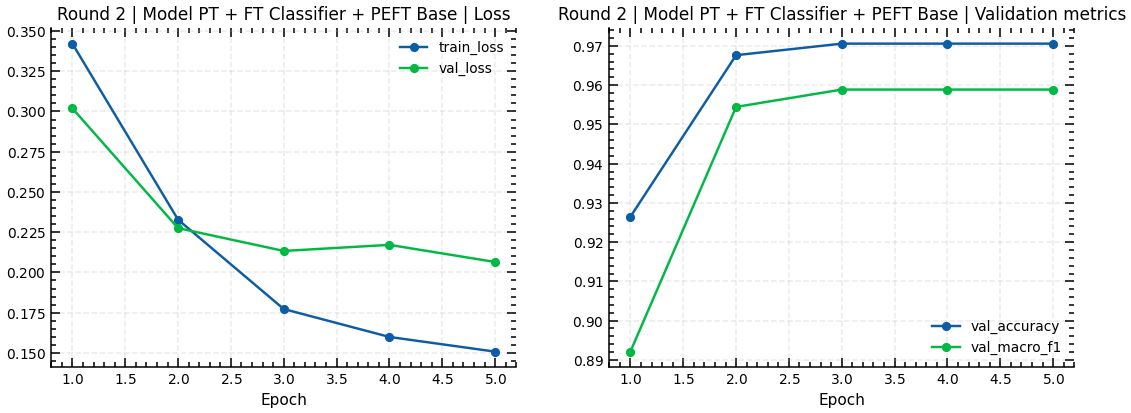

Round 2 | Model 5 | validation metrics: {'accuracy': 0.9705882352941176, 'macro_precision': 0.9494949494949494, 'macro_recall': 0.9691142349649081, 'macro_f1': 0.9588862524139009, 'weighted_f1': 0.9709054414171543, 'loss': 0.11695293424760594}
Round 2 | Model 5 | test metrics      : {'accuracy': 0.961764705882353, 'macro_precision': 0.944112039336695, 'macro_recall': 0.9563300252491261, 'macro_f1': 0.9500519934659629, 'weighted_f1': 0.9619513629689475, 'loss': 0.11758909155340756}


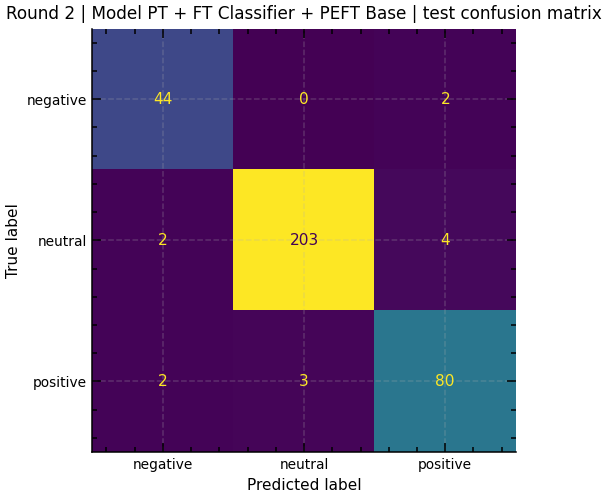

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
113,Finnish power supply solutions and systems provider Efore Oyj said its net loss widened to 3.2 mln euro $ 4.2 mln fo...,negative,positive,0.990926,0.004575,0.004499,0.990926
275,"Operating loss was EUR 179mn , compared to a loss of EUR 188mn in the second quarter of 2009 .",positive,negative,0.903692,0.903692,0.003591,0.092717
167,These moderate but significant changes resulted in a significant 24-32 % reduction in the estimated CVD risk .,positive,negative,0.838054,0.838054,0.036300,0.125646
320,"In the third quarter of fiscal 2008 Efore swung to a net loss of EUR 400,000 versus a net profit of EUR 200,000 for ...",negative,positive,0.821990,0.177271,0.000740,0.821990
263,"These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has suff...",positive,neutral,0.809859,0.001488,0.809859,0.188652
175,"In a letter to Economic Affairs Minister , the listed Estonian shipping company Tallink asks for the approval to be ...",neutral,positive,0.748388,0.187625,0.063987,0.748388
214,Increase in the number of shares is based on the option rights which were granted to the management of the company u...,neutral,positive,0.747630,0.007968,0.244402,0.747630
299,Atria said its offer would give the Swedish company continued ownership and control of its slaughtering and cutting ...,neutral,positive,0.708379,0.010968,0.280653,0.708379


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
33,"Previously , the company expected its 2008 financial performance to remain at the same level as in 2008 .",neutral,positive,0.471176,0.130150,0.398674,0.471176
10,"The company reported a profit of 800,000 euro ($ 1.2 mln)on the sale of its Varesvuo Partners sub-group and a loss o...",neutral,neutral,0.482435,0.450087,0.482435,0.067478
160,Motorola Inc. of the United States came second with shipments of 217.4 million units for a 21.3 percent market share...,neutral,neutral,0.510213,0.082227,0.510213,0.407560
326,"According to CEO Matti Perkonoja of the parent company HKScan , the company 's performance in the first quarter of 2...",negative,negative,0.549747,0.549747,0.036045,0.414207
235,Finnish silicon wafer technology company Okmetic Oyj OMX Helsinki : OKM1V said on Wednesday 17 September that it wil...,neutral,neutral,0.558108,0.028580,0.558108,0.413312
118,The company also said that in Poland a profitability program has been launched at the Oborniki steel frame and sandw...,positive,positive,0.568055,0.074475,0.357471,0.568055
159,Viking Line manages well with its current ferries .,positive,neutral,0.575369,0.024054,0.575369,0.400577
286,"Citigroup , Inc ( NYSE : C ) has announced that its Global Transaction Services ( GTS ) business has been awarded a ...",positive,positive,0.578527,0.016123,0.405350,0.578527


Deep dive: Round 2 | Model PT + FT Classifier + PEFT Base
loss=0.1176 | accuracy=0.9618 | macro_f1=0.9501 | weighted_f1=0.9620
vs reference -> Δaccuracy=+0.0059, Δmacro_f1=+0.0067, Δloss=-0.0035

Class-wise report:


,precision,recall,f1-score,support
negative,0.9167,0.9565,0.9362,46.0
neutral,0.9854,0.9713,0.9783,209.0
positive,0.9302,0.9412,0.9357,85.0


Weakest class right now: positive
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='neutral' predicted='positive' (count=4)
Number of wrong predictions: 13 / 340
Median confidence on wrong predictions: 0.7476
Interpretation: many mistakes are high-confidence -> features may be systematically misleading, not just noisy.
Approx. last-epoch generalization gap (val_loss - train_loss): +0.0557
Interpretation: train/validation losses are in a relatively healthy range.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [56]:

plot_history(model5_r2_history, "Round 2 | Model PT + FT Classifier + PEFT Base")
print("Round 2 | Model 5 | validation metrics:", model5_r2_val["metrics"])
print("Round 2 | Model 5 | test metrics      :", model5_r2_test["metrics"])

plot_confusion(model5_r2_test, "Round 2 | Model PT + FT Classifier + PEFT Base | test confusion matrix")
display(show_top_errors(model5_r2_test, n=8))
display(show_low_confidence_cases(model5_r2_test, n=8))
deep_dive_report("Round 2 | Model PT + FT Classifier + PEFT Base", model5_r2_test, history_df=model5_r2_history, reference_eval=ROUND1_TEST_EVALS["Model PT + FT Classifier + PEFT Base"])

register_result(
    ROUND2_RESULTS,
    "Model PT + FT Classifier + PEFT Base",
    model5_r2,
    model5_r2_val,
    model5_r2_test,
    notes="Round-2 hand-written LoRA on FFN lin1/lin2 only; rank fixed at 8; tuned alpha/lr/dropout/epochs",
)
ROUND2_HISTORIES["Model PT + FT Classifier + PEFT Base"] = model5_r2_history
ROUND2_VAL_EVALS["Model PT + FT Classifier + PEFT Base"] = model5_r2_val
ROUND2_TEST_EVALS["Model PT + FT Classifier + PEFT Base"] = model5_r2_test


### Reading Round-2 Model 5

Two questions worth asking.

After Round 2, does Model 5 close the gap with Model 4?

If a gap remains, is it small enough relative to LoRA's parameter savings to be worth the trade?

If full body fine-tuning is only marginally better than LoRA but at much larger parameter and compute cost, LoRA is usually the better practical choice, particularly in settings where many fine-tuned variants need to be stored and served. If full body fine-tuning is substantially better and the application is recall- or risk-sensitive, the heavier adaptation may still be worth its cost.


## Round 2 — consolidated results, with Round 1 comparison

Round 2 results are reported in the same format as Round 1 and merged with Round 1 to make per-model deltas explicit.


In [57]:

round2_results_df = pd.DataFrame(ROUND2_RESULTS).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
display(round2_results_df.round(4))

round_comparison_df = (
    ROUND1_RESULTS_DF[["model", "val_accuracy", "val_macro_f1", "test_accuracy", "test_macro_f1", "test_loss", "trainable_params"]]
    .merge(
        round2_results_df[["model", "val_accuracy", "val_macro_f1", "test_accuracy", "test_macro_f1", "test_loss", "trainable_params"]],
        on="model",
        suffixes=("_r1", "_r2"),
    )
)
round_comparison_df["delta_val_accuracy"] = round_comparison_df["val_accuracy_r2"] - round_comparison_df["val_accuracy_r1"]
round_comparison_df["delta_val_macro_f1"] = round_comparison_df["val_macro_f1_r2"] - round_comparison_df["val_macro_f1_r1"]
round_comparison_df["delta_test_accuracy"] = round_comparison_df["test_accuracy_r2"] - round_comparison_df["test_accuracy_r1"]
round_comparison_df["delta_test_macro_f1"] = round_comparison_df["test_macro_f1_r2"] - round_comparison_df["test_macro_f1_r1"]
round_comparison_df["delta_test_loss"] = round_comparison_df["test_loss_r2"] - round_comparison_df["test_loss_r1"]

print("Round-1 vs Round-2 comparison")
display(round_comparison_df.round(4).sort_values("delta_val_macro_f1", ascending=False))


,model,notes,total_params,trainable_params,trainable_pct,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,test_loss
0,Model PT + FT Classifier + FT Base,Round-2 body-only FT from round-2 Model 2 with tuned epochs/lr and optional weighted CE/smoothing,66955779,66362880,0.9911,0.9735,0.9611,0.9618,0.9486,0.1125
1,Model PT + FT Classifier + PEFT Base,Round-2 hand-written LoRA on FFN lin1/lin2 only; rank fixed at 8; tuned alpha/lr/dropout/epochs,67324419,368640,0.0055,0.9706,0.9589,0.9618,0.9501,0.1176
2,Model PT + Own FT Classifier,Round-2 custom head: GELU + optional LayerNorm + evidence-driven width/dropout,66708867,345987,0.0052,0.8618,0.7803,0.8676,0.8020,0.3397
3,Model PT + FT Classifier,Round-2 head-only FT with evidence-driven epoch/lr + optional weighted CE + optional label smoothing,66955779,592899,0.0089,0.8559,0.7664,0.8382,0.7568,0.3683
4,Model PT,Round 2 anchor model; no financial FT; max_length=80,66955779,66955779,1.0000,0.3618,0.3425,0.3206,0.3009,1.1031


Round-1 vs Round-2 comparison


,model,val_accuracy_r1,val_macro_f1_r1,test_accuracy_r1,test_macro_f1_r1,test_loss_r1,trainable_params_r1,val_accuracy_r2,val_macro_f1_r2,test_accuracy_r2,test_macro_f1_r2,test_loss_r2,trainable_params_r2,delta_val_accuracy,delta_val_macro_f1,delta_test_accuracy,delta_test_macro_f1,delta_test_loss
3,Model PT + Own FT Classifier,0.7853,0.5276,0.7529,0.4993,0.5116,213507,0.8618,0.7803,0.8676,0.8020,0.3397,345987,0.0765,0.2527,0.1147,0.3027,-0.1719
2,Model PT + FT Classifier,0.8441,0.7406,0.8206,0.7242,0.3866,592899,0.8559,0.7664,0.8382,0.7568,0.3683,592899,0.0118,0.0258,0.0176,0.0326,-0.0183
1,Model PT + FT Classifier + FT Base,0.9647,0.9531,0.9559,0.9420,0.1684,66362880,0.9735,0.9611,0.9618,0.9486,0.1125,66362880,0.0088,0.0081,0.0059,0.0066,-0.0560
4,Model PT,0.3618,0.3425,0.3206,0.3009,1.1031,66955779,0.3618,0.3425,0.3206,0.3009,1.1031,66955779,0.0000,0.0000,0.0000,0.0000,0.0000
0,Model PT + FT Classifier + PEFT Base,0.9706,0.9617,0.9559,0.9433,0.1211,368640,0.9706,0.9589,0.9618,0.9501,0.1176,368640,0.0000,-0.0028,0.0059,0.0067,-0.0035


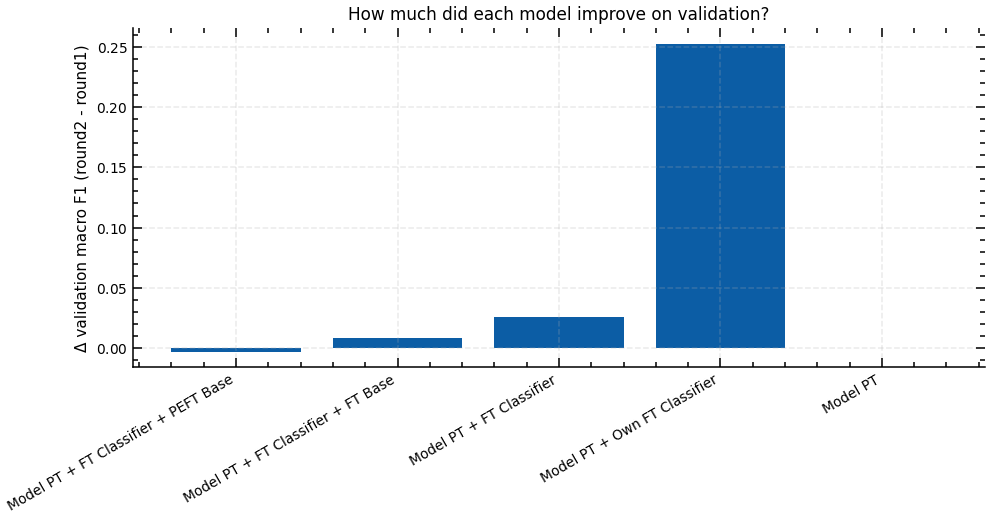

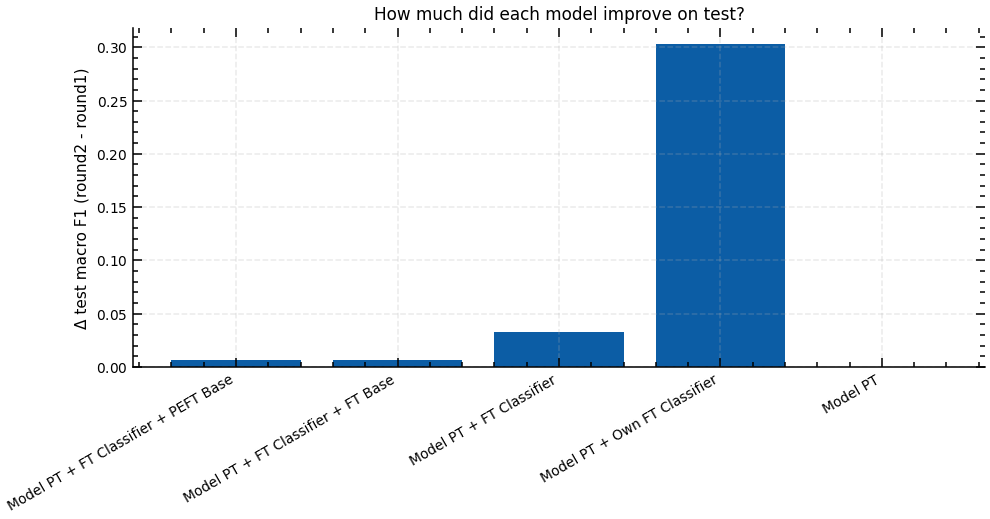

In [58]:

plt.figure(figsize=(10, 4))
plt.bar(round_comparison_df["model"], round_comparison_df["delta_val_macro_f1"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Δ validation macro F1 (round2 - round1)")
plt.title("How much did each model improve on validation?")
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(round_comparison_df["model"], round_comparison_df["delta_test_macro_f1"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Δ test macro F1 (round2 - round1)")
plt.title("How much did each model improve on test?")
plt.show()


In [59]:

def round2_takeaways(round_comparison_df, round2_results_df):
    print("=" * 90)
    print("Takeaways from round 2")
    print("=" * 90)

    best_val_row = round2_results_df.sort_values("val_macro_f1", ascending=False).iloc[0]
    best_test_row = round2_results_df.sort_values("test_macro_f1", ascending=False).iloc[0]
    biggest_delta_row = round_comparison_df.sort_values("delta_val_macro_f1", ascending=False).iloc[0]

    print(f"Best validation model in round 2: {best_val_row['model']} | val_macro_f1={best_val_row['val_macro_f1']:.4f}")
    print(f"Best test model in round 2      : {best_test_row['model']} | test_macro_f1={best_test_row['test_macro_f1']:.4f}")
    print(f"Biggest validation gain         : {biggest_delta_row['model']} | Δval_macro_f1={biggest_delta_row['delta_val_macro_f1']:+.4f}")
    print()

    for _, row in round_comparison_df.sort_values("delta_val_macro_f1", ascending=False).iterrows():
        direction = "improved" if row["delta_val_macro_f1"] > 0 else ("held roughly steady" if abs(row["delta_val_macro_f1"]) < 1e-4 else "dropped")
        print(f"- {row['model']}: validation macro F1 {direction} by {row['delta_val_macro_f1']:+.4f}; test macro F1 changed by {row['delta_test_macro_f1']:+.4f}.")

    print("\nInterpretation prompts:")
    print("1. If Model 2 improved a lot, the bottleneck was partly training protocol, not only model capacity.")
    print("2. If Model 3 still lags Model 2, custom head freedom may matter less than representation adaptation on this dataset.")
    print("3. If Model 4 pulls ahead, financial-domain adaptation in the body is real and useful.")
    print("4. If Model 5 gets close to Model 4, PEFT is looking attractive from a parameter-efficiency standpoint.")

round2_takeaways(round_comparison_df, round2_results_df)


Takeaways from round 2
Best validation model in round 2: Model PT + FT Classifier + FT Base | val_macro_f1=0.9611
Best test model in round 2      : Model PT + FT Classifier + PEFT Base | test_macro_f1=0.9501
Biggest validation gain         : Model PT + Own FT Classifier | Δval_macro_f1=+0.2527

- Model PT + Own FT Classifier: validation macro F1 improved by +0.2527; test macro F1 changed by +0.3027.
- Model PT + FT Classifier: validation macro F1 improved by +0.0258; test macro F1 changed by +0.0326.
- Model PT + FT Classifier + FT Base: validation macro F1 improved by +0.0081; test macro F1 changed by +0.0066.
- Model PT: validation macro F1 held roughly steady by +0.0000; test macro F1 changed by +0.0000.
- Model PT + FT Classifier + PEFT Base: validation macro F1 dropped by -0.0028; test macro F1 changed by +0.0067.

Interpretation prompts:
1. If Model 2 improved a lot, the bottleneck was partly training protocol, not only model capacity.
2. If Model 3 still lags Model 2, custom hea

## End of Round 2 — implications for Round 3

The Round 2 results, taken with Round 1, suggest a discipline for Round 3.

Decisions should continue to be driven by validation-side evidence rather than test-set chasing.

Round 3's changes should be limited to the small number of items that Round 2's diagnostics actually motivate.

After any change, all five models should be re-run rather than only the ones that look promising — this avoids confounding model-specific gains with side effects of changes that touch everyone.

Comparisons should evaluate effectiveness, stability, parameter efficiency, and error-mode shifts together, not just the headline metric.

If Round 2 has produced clear trends, Round 3 can be more focused: fix the settings that worked, make smaller and more targeted adjustments, and bring in an external benchmark for context. The question Round 3 is set up to answer is no longer "can we tune further" but "are the Round 2 gains stable and large enough to be claimed as real."


# Round 3 — focused adjustments and statistical scaffolding

Round 3 has five parts.

First, aggregate Round 2's class-wise metrics, dominant confusion patterns, training trajectories, and parameter-efficiency numbers into a single diagnostic view.

Second, identify which Round 2 changes produced effects large enough to justify continuation, versus which produced changes small enough that they might be run-to-run noise.

Third, make a small number of further adjustments to Models 1–5 on the basis of those diagnostics.

Fourth, add an external benchmark using a finance-domain pretrained model, plus a bonus comparison annotated with the appropriate caveat about training-set overlap.

Fifth, use **paired bootstrap** of the test predictions to ask whether the Round 2 → Round 3 deltas exceed what would be expected from sampling variability on this single test split.


In [60]:

required_globals = [
    "results_df",
    "round2_results_df",
    "ROUND1_VAL_EVALS",
    "ROUND1_TEST_EVALS",
    "ROUND1_HISTORIES",
    "ROUND2_VAL_EVALS",
    "ROUND2_TEST_EVALS",
    "ROUND2_HISTORIES",
    "split_frames",
    "split_ds",
    "train_lengths",
    "CFG",
    "ROUND2_CFG",
]

missing = [name for name in required_globals if name not in globals()]
assert not missing, f"Round-3 cells expect previous rounds to be executed first. Missing: {missing}"

ROUND1_RESULTS_DF = results_df.copy().reset_index(drop=True)
ROUND2_RESULTS_DF = round2_results_df.copy().reset_index(drop=True)

print("Round-1 / Round-2 snapshots are ready.")
display(
    ROUND2_RESULTS_DF[
        ["model", "trainable_params", "trainable_pct", "val_macro_f1", "test_macro_f1", "test_loss"]
    ].sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
)


Round-1 / Round-2 snapshots are ready.


,model,trainable_params,trainable_pct,val_macro_f1,test_macro_f1,test_loss
0,Model PT + FT Classifier + FT Base,66362880,0.991145,0.961139,0.948602,0.112450
1,Model PT + FT Classifier + PEFT Base,368640,0.005476,0.958886,0.950052,0.117589
2,Model PT + Own FT Classifier,345987,0.005187,0.780287,0.802020,0.339745
3,Model PT + FT Classifier,592899,0.008855,0.766373,0.756840,0.368321
4,Model PT,66955779,1.000000,0.342532,0.300883,1.103060


In [61]:

def extract_classwise_table(eval_store, round_name, split_name):
    rows = []
    for model_name, eval_obj in eval_store.items():
        report = eval_obj["report_df"].copy()
        for label_name in LABEL_ORDER:
            rows.append({
                "round": round_name,
                "split": split_name,
                "model": model_name,
                "label": label_name,
                "precision": float(report.loc[label_name, "precision"]),
                "recall": float(report.loc[label_name, "recall"]),
                "f1": float(report.loc[label_name, "f1-score"]),
                "support": int(report.loc[label_name, "support"]),
            })
    return pd.DataFrame(rows)


def dominant_confusion(eval_obj):
    cm = eval_obj["confusion_matrix"].copy()
    cm = np.asarray(cm)
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)

    if cm_no_diag.sum() == 0:
        return {
            "true_label": None,
            "pred_label": None,
            "count": 0,
        }

    i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
    return {
        "true_label": id2label[i],
        "pred_label": id2label[j],
        "count": int(cm_no_diag[i, j]),
    }


def summarize_dominant_confusions(eval_store, round_name, split_name):
    rows = []
    for model_name, eval_obj in eval_store.items():
        d = dominant_confusion(eval_obj)
        rows.append({
            "round": round_name,
            "split": split_name,
            "model": model_name,
            "dominant_true_label": d["true_label"],
            "dominant_pred_label": d["pred_label"],
            "dominant_confusion_count": d["count"],
        })
    return pd.DataFrame(rows)


def class_gap(eval_obj):
    report = eval_obj["report_df"].loc[LABEL_ORDER, ["f1-score"]].copy()
    return float(report["f1-score"].max() - report["f1-score"].min())


def weakest_class(eval_obj):
    report = eval_obj["report_df"].loc[LABEL_ORDER, ["f1-score"]].copy()
    weakest = report["f1-score"].idxmin()
    return weakest, float(report.loc[weakest, "f1-score"])


def median_wrong_confidence(eval_obj):
    df = eval_obj["predictions_df"]
    wrong = df[df["gold_id"] != df["pred_id"]]
    if len(wrong) == 0:
        return np.nan
    return float(wrong["confidence"].median())


def error_length_profile(eval_obj):
    df = eval_obj["predictions_df"].copy()
    df["n_words"] = df["sentence"].astype(str).str.split().map(len)
    df["correctness"] = np.where(df["gold_id"] == df["pred_id"], "correct", "wrong")
    return (
        df.groupby("correctness")["n_words"]
          .agg(["count", "mean", "median", "max"])
          .reset_index()
          .sort_values("correctness")
    )


def parameter_efficiency_table(results_df, round_name):
    df = results_df.copy()
    df["round"] = round_name
    df["macro_f1_per_1M_trainable"] = np.where(
        df["trainable_params"] > 0,
        df["test_macro_f1"] / (df["trainable_params"] / 1_000_000.0),
        np.nan,
    )
    cols = [
        "round",
        "model",
        "trainable_params",
        "trainable_pct",
        "test_macro_f1",
        "macro_f1_per_1M_trainable",
    ]
    return df[cols].sort_values(["test_macro_f1", "macro_f1_per_1M_trainable"], ascending=[False, False]).reset_index(drop=True)


def plot_multi_history(histories_dict, metric, title):
    plt.figure(figsize=(10, 4))
    plotted = 0
    for model_name, history_df in histories_dict.items():
        if history_df is None or len(history_df) == 0 or metric not in history_df.columns:
            continue
        plt.plot(history_df["epoch"], history_df[metric], marker="o", label=model_name)
        plotted += 1
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    if plotted > 0:
        plt.legend()
    else:
        print(f"No histories found for metric={metric}")
    plt.show()


def prediction_change_table(old_eval, new_eval, mode="improved", n=10):
    old_df = old_eval["predictions_df"].copy().reset_index(drop=True)
    new_df = new_eval["predictions_df"].copy().reset_index(drop=True)

    if old_df["sentence"].equals(new_df["sentence"]) and old_df["gold_id"].equals(new_df["gold_id"]):
        merged = pd.DataFrame({
            "sentence": old_df["sentence"],
            "gold_label": old_df["gold_label"],
            "old_pred": old_df["pred_label"],
            "new_pred": new_df["pred_label"],
            "old_conf": old_df["confidence"],
            "new_conf": new_df["confidence"],
            "old_correct": old_df["gold_id"] == old_df["pred_id"],
            "new_correct": new_df["gold_id"] == new_df["pred_id"],
        })
    else:
        merged = old_df[["sentence", "gold_id", "gold_label", "pred_label", "confidence"]].merge(
            new_df[["sentence", "gold_id", "pred_label", "confidence"]],
            on=["sentence", "gold_id"],
            suffixes=("_old", "_new"),
        )
        merged = merged.rename(columns={
            "gold_label": "gold_label",
            "pred_label_old": "old_pred",
            "pred_label_new": "new_pred",
            "confidence_old": "old_conf",
            "confidence_new": "new_conf",
        })
        merged["old_correct"] = merged["gold_label"] == merged["old_pred"]
        merged["new_correct"] = merged["gold_label"] == merged["new_pred"]

    if mode == "improved":
        subset = merged[(~merged["old_correct"]) & (merged["new_correct"])].copy()
        subset["confidence_delta"] = subset["new_conf"] - subset["old_conf"]
        return subset.sort_values("confidence_delta", ascending=False).head(n)
    if mode == "regressed":
        subset = merged[(merged["old_correct"]) & (~merged["new_correct"])].copy()
        subset["confidence_delta"] = subset["new_conf"] - subset["old_conf"]
        return subset.sort_values("confidence_delta", ascending=False).head(n)
    if mode == "changed":
        subset = merged[merged["old_pred"] != merged["new_pred"]].copy()
        subset["confidence_delta"] = subset["new_conf"] - subset["old_conf"]
        return subset.sort_values("confidence_delta", ascending=False).head(n)

    raise ValueError("mode must be one of: improved / regressed / changed")


def correctness_shift_table(old_eval, new_eval):
    old_df = old_eval["predictions_df"].copy().reset_index(drop=True)
    new_df = new_eval["predictions_df"].copy().reset_index(drop=True)
    old_correct = old_df["gold_id"].values == old_df["pred_id"].values
    new_correct = new_df["gold_id"].values == new_df["pred_id"].values

    return pd.DataFrame(
        [[int(np.sum(old_correct & new_correct)), int(np.sum(old_correct & (~new_correct)))],
         [int(np.sum((~old_correct) & new_correct)), int(np.sum((~old_correct) & (~new_correct)))]],
        index=["old_correct", "old_wrong"],
        columns=["new_correct", "new_wrong"],
    )


def bootstrap_metric_diff(old_eval, new_eval, metric="macro_f1", n_boot=2000, seed=42):
    old_df = old_eval["predictions_df"].copy().reset_index(drop=True)
    new_df = new_eval["predictions_df"].copy().reset_index(drop=True)

    y_true = old_df["gold_id"].to_numpy()
    old_pred = old_df["pred_id"].to_numpy()
    new_pred = new_df["pred_id"].to_numpy()

    assert np.array_equal(y_true, new_df["gold_id"].to_numpy()), "Paired bootstrap expects the same gold labels."

    rng = np.random.default_rng(seed)
    n = len(y_true)
    diffs = []

    def metric_fn(y, p):
        if metric == "macro_f1":
            return f1_score(y, p, average="macro")
        if metric == "accuracy":
            return accuracy_score(y, p)
        raise ValueError("metric must be 'macro_f1' or 'accuracy'")

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        diffs.append(metric_fn(y_true[idx], new_pred[idx]) - metric_fn(y_true[idx], old_pred[idx]))

    diffs = np.asarray(diffs)
    return {
        "metric": metric,
        "mean_diff": float(diffs.mean()),
        "ci_low": float(np.quantile(diffs, 0.025)),
        "ci_high": float(np.quantile(diffs, 0.975)),
        "p_nonpositive": float(np.mean(diffs <= 0)),
    }


def recommend_token_budget(lengths, candidates=(48, 64, 80, 96, 112, 128, 160), target_coverage=0.995):
    lengths = np.asarray(lengths)
    rows = []
    best = candidates[-1]
    for cand in candidates:
        coverage = float(np.mean(lengths <= cand))
        rows.append({
            "candidate_max_length": cand,
            "coverage": coverage,
            "truncated_count": int(np.sum(lengths > cand)),
        })
        if coverage >= target_coverage and best == candidates[-1]:
            best = cand
    return best, pd.DataFrame(rows)


def build_round_diagnostic_summary(eval_store, round_name, split_name):
    rows = []
    for model_name, eval_obj in eval_store.items():
        weak_name, weak_f1 = weakest_class(eval_obj)
        dom = dominant_confusion(eval_obj)
        rows.append({
            "round": round_name,
            "split": split_name,
            "model": model_name,
            "weakest_class": weak_name,
            "weakest_class_f1": weak_f1,
            "class_gap": class_gap(eval_obj),
            "median_wrong_confidence": median_wrong_confidence(eval_obj),
            "dominant_true_label": dom["true_label"],
            "dominant_pred_label": dom["pred_label"],
            "dominant_confusion_count": dom["count"],
        })
    return pd.DataFrame(rows).sort_values(["weakest_class_f1", "class_gap"])


Round 2 | validation class-wise metrics (this is the main evidence source for round-3 decisions)


,round,split,model,label,precision,recall,f1,support
0,round2,validation,Model PT,negative,0.1145,0.3333,0.1705,45
1,round2,validation,Model PT,neutral,0.8451,0.2871,0.4286,209
2,round2,validation,Model PT,positive,0.3478,0.5581,0.4286,86
3,round2,validation,Model PT + FT Classifier,negative,0.7188,0.5111,0.5974,45
4,round2,validation,Model PT + FT Classifier,neutral,0.9431,0.9522,0.9476,209
5,round2,validation,Model PT + FT Classifier,positive,0.7113,0.8023,0.7541,86
6,round2,validation,Model PT + Own FT Classifier,negative,0.6364,0.6222,0.6292,45
7,round2,validation,Model PT + Own FT Classifier,neutral,0.9706,0.9474,0.9588,209
8,round2,validation,Model PT + Own FT Classifier,positive,0.7283,0.7791,0.7528,86
9,round2,validation,Model PT + FT Classifier + FT Base,negative,0.9348,0.9556,0.9451,45


Round 2 | validation diagnosis summary


,round,split,model,weakest_class,weakest_class_f1,class_gap,median_wrong_confidence,dominant_true_label,dominant_pred_label,dominant_confusion_count
0,round2,validation,Model PT,negative,0.1705,0.2581,0.3412,neutral,negative,87
1,round2,validation,Model PT + FT Classifier,negative,0.5974,0.3502,0.6491,negative,positive,21
2,round2,validation,Model PT + Own FT Classifier,negative,0.6292,0.3296,0.7234,negative,positive,17
4,round2,validation,Model PT + FT Classifier + PEFT Base,positive,0.9425,0.0454,0.7423,neutral,positive,5
3,round2,validation,Model PT + FT Classifier + FT Base,negative,0.9451,0.0453,0.6606,neutral,positive,3


Round 2 | test dominant confusion summary


,round,split,model,dominant_true_label,dominant_pred_label,dominant_confusion_count
0,round2,test,Model PT,neutral,negative,91
1,round2,test,Model PT + FT Classifier,negative,positive,20
2,round2,test,Model PT + Own FT Classifier,negative,positive,15
3,round2,test,Model PT + FT Classifier + FT Base,neutral,negative,3
4,round2,test,Model PT + FT Classifier + PEFT Base,neutral,positive,4


Round 2 | parameter-efficiency view


,round,model,trainable_params,trainable_pct,test_macro_f1,macro_f1_per_1M_trainable
0,round2,Model PT + FT Classifier + PEFT Base,368640,0.0055,0.9501,2.5772
1,round2,Model PT + FT Classifier + FT Base,66362880,0.9911,0.9486,0.0143
2,round2,Model PT + Own FT Classifier,345987,0.0052,0.8020,2.3181
3,round2,Model PT + FT Classifier,592899,0.0089,0.7568,1.2765
4,round2,Model PT,66955779,1.0000,0.3009,0.0045


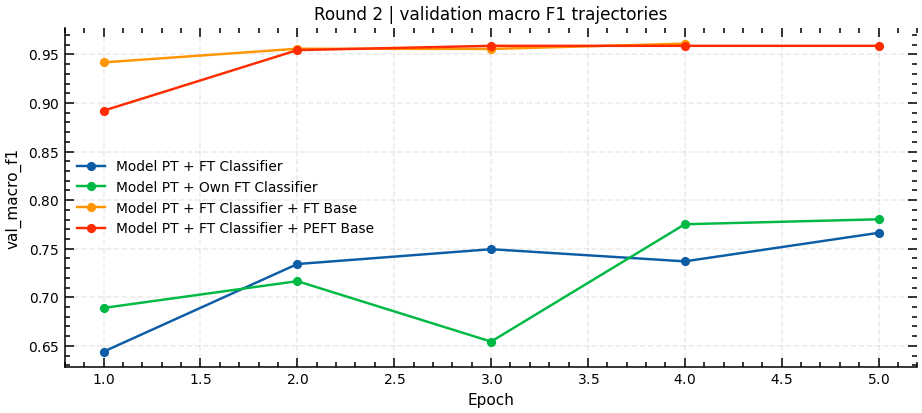

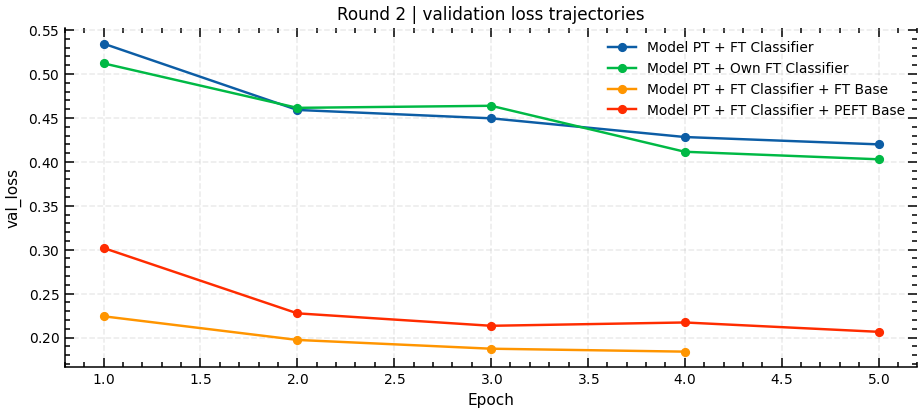

Best round-2 validation model: Model PT + FT Classifier + FT Base
Error-length profile on validation for the current best model


,correctness,count,mean,median,max
0,correct,331,22.01,21.0,54
1,wrong,9,26.89,22.0,56


In [62]:

round1_test_classwise_df = extract_classwise_table(ROUND1_TEST_EVALS, "round1", "test")
round2_val_classwise_df = extract_classwise_table(ROUND2_VAL_EVALS, "round2", "validation")
round2_test_classwise_df = extract_classwise_table(ROUND2_TEST_EVALS, "round2", "test")

round2_val_diag_df = build_round_diagnostic_summary(ROUND2_VAL_EVALS, "round2", "validation")
round2_test_confusion_summary_df = summarize_dominant_confusions(ROUND2_TEST_EVALS, "round2", "test")
round2_param_eff_df = parameter_efficiency_table(ROUND2_RESULTS_DF, "round2")

print("Round 2 | validation class-wise metrics (this is the main evidence source for round-3 decisions)")
display(round2_val_classwise_df.round(4))

print("Round 2 | validation diagnosis summary")
display(round2_val_diag_df.round(4))

print("Round 2 | test dominant confusion summary")
display(round2_test_confusion_summary_df)

print("Round 2 | parameter-efficiency view")
display(round2_param_eff_df.round(4))

plot_multi_history(ROUND2_HISTORIES, metric="val_macro_f1", title="Round 2 | validation macro F1 trajectories")
plot_multi_history(ROUND2_HISTORIES, metric="val_loss", title="Round 2 | validation loss trajectories")

best_round2_model_by_val = ROUND2_RESULTS_DF.sort_values("val_macro_f1", ascending=False).iloc[0]["model"]
print(f"Best round-2 validation model: {best_round2_model_by_val}")
print("Error-length profile on validation for the current best model")
display(error_length_profile(ROUND2_VAL_EVALS[best_round2_model_by_val]).round(2))


## Round 3 diagnostics

The diagnostic table below is the basis for Round 3's changes. Five categories of signal are tracked across the Round 2 models.

**Weakest class.** A class that's consistently weakest across runs is structural, not incidental.

**Class gap.** High overall accuracy combined with a large class gap means an unbalanced model — doing well on the majority class at the cost of the minority classes.

**Dominant confusion.** A persistent confusion pattern (for example `neutral → positive` or `negative → neutral`) tells me where the boundary needs to be sharpened.

**Median wrong-prediction confidence.** High values mean confidently wrong, which is usually a representation or inductive-bias issue. Low values mean uncertain wrong, which is usually a boundary or calibration issue.

**Training trajectory.** Early plateau means simply training longer in Round 3 won't help. Late-stage degradation means stronger regularisation or a smaller learning rate is in order.

Round 3 turns each of these signals into a defensible structural or optimisation change.


In [63]:

ROUND3_CFG = copy.deepcopy(ROUND2_CFG)

# ---------- global decisions ----------
recommended_len, round3_length_candidates_df = recommend_token_budget(
    train_lengths,
    candidates=(48, 64, 80, 96, 112, 128, 160),
    target_coverage=0.995,
)

best_round2_error_profile = error_length_profile(ROUND2_VAL_EVALS[best_round2_model_by_val])
wrong_len_median = np.nan
if "wrong" in best_round2_error_profile["correctness"].values:
    wrong_len_median = float(
        best_round2_error_profile.loc[best_round2_error_profile["correctness"] == "wrong", "median"].iloc[0]
    )

ROUND3_CFG["max_length"] = int(recommended_len)
ROUND3_CFG["bootstrap_iterations"] = 2000
ROUND3_CFG["external_model_name"] = "yiyanghkust/finbert-tone"
ROUND3_CFG["bonus_external_model_name"] = "ProsusAI/finbert"
ROUND3_CFG["run_bonus_external_model"] = True

round3_decision_rows = [
    {
        "component": "global",
        "change": f"max_length -> {ROUND3_CFG['max_length']}",
        "reason": (
            "Choose the smallest token budget that still covers about 99.5% of training examples. "
            "If errors were mainly on very long sentences we would raise it, but the current error-length profile does not suggest length is the main bottleneck."
        ),
    }
]

round2_val_lookup = ROUND2_RESULTS_DF.set_index("model")
round2_val_diag_lookup = round2_val_diag_df.set_index("model")

# ---------- Model 2: default head only ----------
sig2_r2 = history_signal(ROUND2_HISTORIES["Model PT + FT Classifier"])
m2_gap = float(round2_val_diag_lookup.loc["Model PT + FT Classifier", "class_gap"])
m2_wrong_conf = float(round2_val_diag_lookup.loc["Model PT + FT Classifier", "median_wrong_confidence"])

ROUND3_CFG["model2"] = {
    "epochs": int(max(ROUND2_CFG["head_only_epochs"], sig2_r2["best_epoch"] + 1)),
    "lr": float(ROUND2_CFG["head_only_lr"] * (0.75 if sig2_r2["peak_to_last_drop"] > 0.01 else 0.90)),
    "use_class_weights": bool(m2_gap > 0.12),
    "class_weight_mode": ROUND2_CFG.get("class_weight_mode", "sqrt_inverse_freq"),
    "label_smoothing": float(0.05 if m2_wrong_conf > 0.72 else 0.02),
}
round3_decision_rows.append({
    "component": "model2",
    "change": (
        f"epochs -> {ROUND3_CFG['model2']['epochs']}, "
        f"lr -> {ROUND3_CFG['model2']['lr']:.2e}, "
        f"class_weights -> {ROUND3_CFG['model2']['use_class_weights']}, "
        f"label_smoothing -> {ROUND3_CFG['model2']['label_smoothing']}"
    ),
    "reason": (
        "Head-only FT is still boundary-limited, so the change stays mild: slightly lower lr, keep roughly the same effective training length, "
        "and only keep class weights when class gap is still visible."
    ),
})

# ---------- Model 3: own custom head ----------
sig3_r2 = history_signal(ROUND2_HISTORIES["Model PT + Own FT Classifier"])
m3_gap_vs_m2_val = float(
    round2_val_lookup.loc["Model PT + Own FT Classifier", "val_macro_f1"] -
    round2_val_lookup.loc["Model PT + FT Classifier", "val_macro_f1"]
)
m3_gap = float(round2_val_diag_lookup.loc["Model PT + Own FT Classifier", "class_gap"])
m3_wrong_conf = float(round2_val_diag_lookup.loc["Model PT + Own FT Classifier", "median_wrong_confidence"])

if m3_gap_vs_m2_val < 0.03:
    model3_hidden_dims = (512, 192)
    model3_dropout = 0.30 if m3_wrong_conf > 0.75 else 0.25
    model3_reason = (
        "Round-2 custom head still did not clearly separate itself from default-head tuning, "
        "so round 3 changes the inductive bias more aggressively: hybrid pooling (CLS + mean) plus a wider head."
    )
else:
    model3_hidden_dims = (384, 128)
    model3_dropout = 0.25
    model3_reason = (
        "Round-2 custom head is useful already, so round 3 mostly stabilizes it while switching to a richer pooling strategy."
    )

ROUND3_CFG["model3"] = {
    "epochs": int(max(ROUND2_CFG["custom_head_epochs"], sig3_r2["best_epoch"] + 1)),
    "lr": float(ROUND2_CFG["custom_head_lr"] * 0.85),
    "hidden_dims": model3_hidden_dims,
    "dropout": float(model3_dropout),
    "activation": "gelu",
    "use_layernorm": True,
    "pooling": "cls_mean_concat",
    "use_class_weights": bool(m3_gap > 0.12),
    "class_weight_mode": ROUND2_CFG.get("class_weight_mode", "sqrt_inverse_freq"),
    "label_smoothing": 0.03,
}
round3_decision_rows.append({
    "component": "model3",
    "change": (
        f"pooling -> {ROUND3_CFG['model3']['pooling']}, "
        f"hidden_dims -> {ROUND3_CFG['model3']['hidden_dims']}, "
        f"dropout -> {ROUND3_CFG['model3']['dropout']}, "
        f"lr -> {ROUND3_CFG['model3']['lr']:.2e}"
    ),
    "reason": model3_reason,
})

# ---------- Model 4: body FT after fixed head ----------
sig4_r2 = history_signal(ROUND2_HISTORIES["Model PT + FT Classifier + FT Base"])
m4_wrong_conf = float(round2_val_diag_lookup.loc["Model PT + FT Classifier + FT Base", "median_wrong_confidence"])

ROUND3_CFG["model4"] = {
    "epochs": int(max(ROUND2_CFG["body_only_epochs"] + 1, sig4_r2["best_epoch"] + 1)),
    "top_lr": float(ROUND2_CFG["body_only_lr"] * (0.75 if sig4_r2["peak_to_last_drop"] > 0.005 else 0.90)),
    "layer_decay": 0.85,
    "embeddings_scale": 0.50,
    "use_class_weights": False,
    "class_weight_mode": None,
    "label_smoothing": float(0.02 if m4_wrong_conf > 0.80 else 0.0),
}
round3_decision_rows.append({
    "component": "model4",
    "change": (
        f"top_lr -> {ROUND3_CFG['model4']['top_lr']:.2e}, "
        f"layer_decay -> {ROUND3_CFG['model4']['layer_decay']}, "
        f"embeddings_scale -> {ROUND3_CFG['model4']['embeddings_scale']}, "
        f"label_smoothing -> {ROUND3_CFG['model4']['label_smoothing']}"
    ),
    "reason": (
        "Model 4 is already strong, so round 3 does not try to make it more aggressive. "
        "Instead we introduce layer-wise lr decay to protect lower layers and stabilize body adaptation."
    ),
})

# ---------- Model 5: manual LoRA on FFN only ----------
sig5_r2 = history_signal(ROUND2_HISTORIES["Model PT + FT Classifier + PEFT Base"])
m5_minus_m4_val = float(
    round2_val_lookup.loc["Model PT + FT Classifier + PEFT Base", "val_macro_f1"] -
    round2_val_lookup.loc["Model PT + FT Classifier + FT Base", "val_macro_f1"]
)
m5_wrong_conf = float(round2_val_diag_lookup.loc["Model PT + FT Classifier + PEFT Base", "median_wrong_confidence"])

ROUND3_CFG["model5"] = {
    "epochs": int(max(ROUND2_CFG["lora_epochs"], sig5_r2["best_epoch"] + 1)),
    "lr": float(ROUND2_CFG["lora_lr"] * (0.80 if sig5_r2["peak_to_last_drop"] > 0.005 else 0.90)),
    "rank": 8,
    "alpha": int(16 if m5_minus_m4_val < 0.0 else ROUND2_CFG["lora_alpha"]),
    "dropout": float(0.10 if m5_wrong_conf > 0.80 else 0.05),
    "use_class_weights": False,
    "class_weight_mode": None,
    "label_smoothing": float(0.02 if m5_wrong_conf > 0.80 else 0.0),
}
round3_decision_rows.append({
    "component": "model5",
    "change": (
        f"rank -> {ROUND3_CFG['model5']['rank']}, "
        f"alpha -> {ROUND3_CFG['model5']['alpha']}, "
        f"dropout -> {ROUND3_CFG['model5']['dropout']}, "
        f"lr -> {ROUND3_CFG['model5']['lr']:.2e}"
    ),
    "reason": (
        "Model 5 is already near the top, so round 3 mainly asks whether a slightly more regularized LoRA setup "
        "can keep the parameter efficiency while improving calibration."
    ),
})

round3_decisions_df = pd.DataFrame(round3_decision_rows)

print("Token-budget candidate table")
display(round3_length_candidates_df.assign(coverage=lambda df: (100 * df["coverage"]).round(2)))

print("Round-3 decisions")
display(round3_decisions_df)

ROUND3_CFG


Token-budget candidate table


,candidate_max_length,coverage,truncated_count
0,48,88.32,185
1,64,97.92,33
2,80,99.87,2
3,96,99.94,1
4,112,99.94,1
5,128,99.94,1
6,160,100.00,0


Round-3 decisions


,component,change,reason
0,global,max_length -> 80,Choose the smallest token budget that still covers about 99.5% of training examples. If errors were mainly on very l...
1,model2,"epochs -> 6, lr -> 4.05e-04, class_weights -> True, label_smoothing -> 0.02","Head-only FT is still boundary-limited, so the change stays mild: slightly lower lr, keep roughly the same effective..."
2,model3,"pooling -> cls_mean_concat, hidden_dims -> (512, 192), dropout -> 0.25, lr -> 2.29e-04","Round-2 custom head still did not clearly separate itself from default-head tuning, so round 3 changes the inductive..."
3,model4,"top_lr -> 1.98e-05, layer_decay -> 0.85, embeddings_scale -> 0.5, label_smoothing -> 0.0","Model 4 is already strong, so round 3 does not try to make it more aggressive. Instead we introduce layer-wise lr de..."
4,model5,"rank -> 8, alpha -> 16, dropout -> 0.05, lr -> 3.38e-04","Model 5 is already near the top, so round 3 mainly asks whether a slightly more regularized LoRA setup can keep the ..."


{'model_name': 'distilbert-base-uncased',
 'dataset_config': 'sentences_allagree',
 'seed': 42,
 'train_frac': 0.7,
 'val_frac': 0.15,
 'test_frac': 0.15,
 'max_length': 80,
 'train_batch_size': 16,
 'eval_batch_size': 32,
 'head_only_epochs': 5,
 'custom_head_epochs': 5,
 'body_only_epochs': 4,
 'lora_epochs': 5,
 'head_only_lr': 0.00045000000000000004,
 'custom_head_lr': 0.00027,
 'body_only_lr': 2.2000000000000003e-05,
 'lora_lr': 0.000375,
 'weight_decay': 0.01,
 'warmup_ratio': 0.1,
 'clip_grad_norm': 1.0,
 'custom_head_hidden_dims': (384, 128),
 'custom_head_dropout': 0.2,
 'lora_rank': 8,
 'lora_alpha': 8,
 'lora_dropout': 0.05,
 'smoke_test': False,
 'smoke_train_per_class': 48,
 'smoke_val_per_class': 16,
 'smoke_test_per_class': 16,
 'use_class_weights': False,
 'class_weight_mode': None,
 'label_smoothing': 0.03,
 'early_stopping_patience': 2,
 'min_epochs_before_stop': 2,
 'custom_head_activation': 'gelu',
 'custom_head_layernorm': True,
 'bootstrap_iterations': 2000,
 'ext

## Round 3 — what changes per model

Two structural changes in Round 3.

**Model 3 V3 head — `[CLS] ⊕ masked-mean pooling`.** The custom head is changed to take both the first-token representation and the attention-mask-weighted mean of all token representations, concatenate them, and pass the resulting `2 × hidden_dim` vector through the MLP. The motivation: with the backbone frozen, sentiment cues may be spread across the sentence rather than fully concentrated at the first token. The default head's strong inductive bias toward `[CLS]` may be discarding useful signal.

**Model 4 with layer-wise learning-rate decay (LLRD).** Rather than a uniform learning rate across the body, each transformer layer gets a learning rate that decays by a constant factor with depth from the top — top layers get the full body learning rate, lower layers get progressively smaller rates, embeddings get an additional reduction. LLRD is a well-known way to stabilise body fine-tuning on small datasets by limiting how much the lower layers can be perturbed.

For Model 5, the rank is still fixed at 8 (per the assignment); Round 3 makes only small evidence-based adjustments to `alpha`, dropout, learning rate, and epoch count.


In [64]:

# Move Round 2 models off the accelerator where possible to free memory before Round 3.
for candidate in ["model1_r2", "model2_r2", "model3_r2", "model4_r2", "model5_r2"]:
    if candidate in globals():
        try:
            globals()[candidate].to("cpu")
        except Exception:
            pass
cleanup()

round3_tokenizer, round3_tokenized_ds, train_loader_r3, val_loader_r3, test_loader_r3 = prepare_round_artifacts(
    ROUND3_CFG,
    split_ds,
    seed=ROUND3_CFG["seed"],
)

round3_train_lengths = batch_token_lengths(split_frames["train"]["sentence"].tolist())
print("Round-3 data / loader setup")
print(f"max_length       : {ROUND3_CFG['max_length']}")
print(f"train batch size : {ROUND3_CFG['train_batch_size']}")
print(f"eval batch size  : {ROUND3_CFG['eval_batch_size']}")
print(
    f"Training truncation at max_length={ROUND3_CFG['max_length']}: "
    f"{sum(l > ROUND3_CFG['max_length'] for l in round3_train_lengths)}/{len(round3_train_lengths)} "
    f"= {sum(l > ROUND3_CFG['max_length'] for l in round3_train_lengths)/len(round3_train_lengths):.2%}"
)


Map:   0%|          | 0/1584 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Round-3 data / loader setup
max_length       : 80
train batch size : 16
eval batch size  : 32
Training truncation at max_length=80: 2/1584 = 0.13%


In [65]:

def build_distilbert_body_param_groups(model, top_lr, layer_decay=0.85, embeddings_scale=0.50):
    assert hasattr(model, "distilbert"), "Expected a DistilBERT sequence-classification model."

    groups = []

    layers = list(model.distilbert.transformer.layer)
    n_layers = len(layers)

    emb_params = [p for p in model.distilbert.embeddings.parameters() if p.requires_grad]
    if emb_params:
        emb_lr = top_lr * (layer_decay ** n_layers) * embeddings_scale
        groups.append({"params": emb_params, "lr": emb_lr, "group_name": "embeddings"})

    for layer_idx, layer in enumerate(layers):
        params = [p for p in layer.parameters() if p.requires_grad]
        if not params:
            continue
        depth_from_top = (n_layers - 1) - layer_idx
        lr = top_lr * (layer_decay ** depth_from_top)
        groups.append({"params": params, "lr": lr, "group_name": f"transformer_layer_{layer_idx}"})

    return groups


def summarize_param_groups(param_groups):
    rows = []
    for idx, group in enumerate(param_groups):
        num_params = sum(p.numel() for p in group["params"])
        rows.append({
            "group_idx": idx,
            "group_name": group.get("group_name", f"group_{idx}"),
            "lr": group.get("lr", None),
            "num_tensors": len(group["params"]),
            "num_params": int(num_params),
        })
    return pd.DataFrame(rows)


def fit_model_round3(
    model,
    train_loader,
    val_loader,
    train_df,
    val_df,
    *,
    epochs,
    lr=None,
    optimizer_param_groups=None,
    weight_decay=0.01,
    warmup_ratio=0.10,
    clip_grad_norm=1.0,
    class_weights=None,
    label_smoothing=0.0,
    early_stopping_patience=2,
    min_epochs_before_stop=2,
    device=DEVICE,
    model_name="model",
):
    model.to(device)

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    assert len(trainable_params) > 0, f"{model_name}: no trainable parameters found."

    criterion = nn.CrossEntropyLoss(
        weight=None if class_weights is None else class_weights.to(device),
        label_smoothing=label_smoothing,
    )

    if optimizer_param_groups is None:
        assert lr is not None, f"{model_name}: when optimizer_param_groups is None, lr must be provided."
        optimizer = torch.optim.AdamW(trainable_params, lr=lr, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.AdamW(optimizer_param_groups, weight_decay=weight_decay)
        if lr is None:
            lr = max(float(group.get("lr", 0.0)) for group in optimizer_param_groups)

    total_steps = max(1, epochs * len(train_loader))
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = []
    best_state = None
    best_val_f1 = -float("inf")
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        n_examples = 0

        progress = tqdm(train_loader, desc=f"{model_name} | round3 epoch {epoch}/{epochs}", leave=False)
        for batch in progress:
            batch = {k: v.to(device) for k, v in batch.items()}
            inputs = {k: v for k, v in batch.items() if k != "labels"}

            optimizer.zero_grad()
            outputs = model(**inputs)
            _, logits = get_loss_and_logits(outputs, labels=None)
            loss = criterion(logits, batch["labels"])
            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(trainable_params, clip_grad_norm)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * batch["labels"].size(0)
            n_examples += batch["labels"].size(0)
            progress.set_postfix(loss=f"{loss.item():.4f}", grad=f"{float(grad_norm):.2f}")

        train_loss = running_loss / max(1, n_examples)
        val_eval = evaluate_model_with_custom_loss(model, val_loader, val_df, criterion=criterion, device=device)

        epoch_row = {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_eval["metrics"]["loss"],
            "val_accuracy": val_eval["metrics"]["accuracy"],
            "val_macro_f1": val_eval["metrics"]["macro_f1"],
        }
        history.append(epoch_row)

        print(
            f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
            f"val_loss={val_eval['metrics']['loss']:.4f} | "
            f"val_acc={val_eval['metrics']['accuracy']:.4f} | "
            f"val_macro_f1={val_eval['metrics']['macro_f1']:.4f}"
        )

        if val_eval["metrics"]["macro_f1"] > best_val_f1 + 1e-6:
            best_val_f1 = val_eval["metrics"]["macro_f1"]
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch >= min_epochs_before_stop and patience_counter >= early_stopping_patience:
            print(f"Early stopping triggered for {model_name} at epoch {epoch}.")
            break

    history_df = pd.DataFrame(history)
    if best_state is not None:
        model.load_state_dict(best_state)

    best_val_eval = evaluate_model(model, val_loader, val_df, device=device)
    return model, history_df, best_val_eval


def masked_mean_pool(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    masked = last_hidden_state * mask
    summed = masked.sum(dim=1)
    denom = mask.sum(dim=1).clamp(min=1.0)
    return summed / denom


class DistilBertWithCustomHeadV3(nn.Module):
    def __init__(
        self,
        base_model_name,
        num_labels,
        hidden_dims=(512, 192),
        dropout=0.30,
        activation="gelu",
        use_layernorm=True,
        pooling="cls_mean_concat",
        id2label=None,
        label2id=None,
    ):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(base_model_name)
        hidden_size = getattr(self.backbone.config, "hidden_size", None)
        if hidden_size is None:
            hidden_size = getattr(self.backbone.config, "dim")

        assert pooling in {"cls_mean_concat"}, "This teaching notebook implements cls_mean_concat for round 3."
        self.pooling = pooling
        pooled_dim = hidden_size * 2

        act = get_activation(activation)
        layers = []
        if use_layernorm:
            layers.append(nn.LayerNorm(pooled_dim))

        in_dim = pooled_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(act)
            layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim

        layers.append(nn.Linear(in_dim, num_labels))
        self.classifier_head = nn.Sequential(*layers)

        self.num_labels = num_labels
        self.id2label = id2label if id2label is not None else {i: str(i) for i in range(num_labels)}
        self.label2id = label2id if label2id is not None else {v: k for k, v in self.id2label.items()}

    def forward(self, input_ids=None, attention_mask=None, labels=None):
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )
        cls_state = outputs.last_hidden_state[:, 0, :]
        mean_state = masked_mean_pool(outputs.last_hidden_state, attention_mask)
        pooled = torch.cat([cls_state, mean_state], dim=-1)

        logits = self.classifier_head(pooled)

        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits, labels)

        return SequenceClassifierOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )


def freeze_backbone_unfreeze_custom_head_v3(model):
    freeze_module(model.backbone)
    unfreeze_module(model.classifier_head)


In [66]:
import re


EXTERNAL_LABEL_OVERRIDES = {
    "yiyanghkust/finbert-tone": {0: "neutral", 1: "positive", 2: "negative"},
    "ProsusAI/finbert": {0: "positive", 1: "negative", 2: "neutral"},
}


def normalize_label_name(name):
    s = str(name).strip().lower()
    s = s.replace("_", " ").replace("-", " ").replace("/", " ").strip()
    s = re.sub(r"\s+", " ", s)

    if s in {"neg", "negative", "bearish"}:
        return "negative"
    if s in {"neu", "neutral"}:
        return "neutral"
    if s in {"pos", "positive", "bullish"}:
        return "positive"

    return s


def infer_external_label_mapping(model_name, config):
    if model_name in EXTERNAL_LABEL_OVERRIDES:
        ext_id2label = EXTERNAL_LABEL_OVERRIDES[model_name]
    else:
        raw_id2label = getattr(config, "id2label", None)
        assert raw_id2label is not None, f"Could not infer id2label for {model_name}"
        ext_id2label = {}
        for k, v in raw_id2label.items():
            ext_id2label[int(k)] = normalize_label_name(v)

    rows = []
    ext_to_ours = {}
    for ext_idx, ext_label in sorted(ext_id2label.items()):
        norm_label = normalize_label_name(ext_label)
        assert norm_label in label2id, f"Unrecognized external label '{ext_label}' (normalized='{norm_label}') for model {model_name}"
        ext_to_ours[ext_idx] = label2id[norm_label]
        rows.append({
            "external_id": ext_idx,
            "external_label": ext_label,
            "normalized_label": norm_label,
            "our_id": label2id[norm_label],
            "our_label": norm_label,
        })
    return ext_to_ours, pd.DataFrame(rows)


@torch.no_grad()
def evaluate_external_classifier(
    model_name,
    source_df,
    *,
    batch_size=32,
    max_length=None,
    model=None,
    tokenizer=None,
    device=DEVICE,
):
    owns_model = model is None
    owns_tokenizer = tokenizer is None

    if tokenizer is None:
        tokenizer = AutoTokenizer.from_pretrained(model_name)
    if model is None:
        model = AutoModelForSequenceClassification.from_pretrained(model_name)

    model.to(device)
    model.eval()

    ext_to_ours, mapping_df = infer_external_label_mapping(model_name, model.config)

    if max_length is None:
        tok_max = getattr(tokenizer, "model_max_length", 256)
        if tok_max is None or tok_max > 10_000:
            tok_max = 256
        max_length = int(min(256, tok_max))

    sentences = source_df["sentence"].astype(str).tolist()
    gold_labels = source_df["labels"].astype(int).to_numpy()

    all_logits = []
    for start in range(0, len(sentences), batch_size):
        batch_sentences = sentences[start:start + batch_size]
        enc = tokenizer(
            batch_sentences,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        outputs = model(**enc)
        ext_logits = outputs.logits.detach().cpu()

        remapped_logits = torch.full((ext_logits.size(0), len(LABEL_ORDER)), -1e9, dtype=ext_logits.dtype)
        for ext_idx, our_idx in ext_to_ours.items():
            remapped_logits[:, our_idx] = ext_logits[:, ext_idx]

        all_logits.append(remapped_logits)

    logits = torch.cat(all_logits).numpy()
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds = probs.argmax(axis=1)

    metrics, report_df = compute_metrics(gold_labels, preds)
    metrics["loss"] = float(F.cross_entropy(torch.tensor(logits, dtype=torch.float32), torch.tensor(gold_labels, dtype=torch.long)).item())

    pred_df = source_df.copy().reset_index(drop=True)
    pred_df["gold_id"] = gold_labels
    pred_df["pred_id"] = preds
    pred_df["gold_label"] = [id2label[i] for i in gold_labels]
    pred_df["pred_label"] = [id2label[i] for i in preds]
    pred_df["confidence"] = probs.max(axis=1)
    for idx, label_name in id2label.items():
        pred_df[f"p_{label_name}"] = probs[:, idx]

    cm = confusion_matrix(gold_labels, preds, labels=list(id2label.keys()))

    eval_obj = {
        "metrics": metrics,
        "report_df": report_df,
        "predictions_df": pred_df,
        "confusion_matrix": cm,
    }

    if owns_model:
        eval_obj["_model"] = model
    if owns_tokenizer:
        eval_obj["_tokenizer"] = tokenizer

    return eval_obj, mapping_df, model, tokenizer


def register_external_result(results_store, benchmark_name, hf_model_name, model, val_eval, test_eval, notes=""):
    total_params, _ = count_parameters(model)
    results_store.append({
        "benchmark": benchmark_name,
        "hf_model_name": hf_model_name,
        "notes": notes,
        "total_params": total_params,
        "trainable_params": 0,
        "trainable_pct": 0.0,
        "val_accuracy": val_eval["metrics"]["accuracy"],
        "val_macro_f1": val_eval["metrics"]["macro_f1"],
        "test_accuracy": test_eval["metrics"]["accuracy"],
        "test_macro_f1": test_eval["metrics"]["macro_f1"],
        "test_loss": test_eval["metrics"]["loss"],
    })


## Round 3 / Model 1 — Model PT

Model 1 isn't trained, so changing the token budget alone shouldn't move it much. The Round 3 score serves as an anchor — any non-trivial gain in another Round 3 model that isn't also seen in Model 1 can be attributed to the model-specific change rather than to changes shared across all of Round 3.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Round 3 | Model PT | parameter summary
Total params     : 66,955,779
Trainable params : 66,955,779
Trainable ratio  : 1.000000


,name,shape,num_params,requires_grad
0,distilbert.embeddings.word_embeddings.weight,"(30522, 768)",23440896,True
1,distilbert.embeddings.position_embeddings.weight,"(512, 768)",393216,True
2,distilbert.embeddings.LayerNorm.weight,"(768,)",768,True
3,distilbert.embeddings.LayerNorm.bias,"(768,)",768,True
4,distilbert.transformer.layer.0.attention.q_lin.weight,"(768, 768)",589824,True
5,distilbert.transformer.layer.0.attention.q_lin.bias,"(768,)",768,True
6,distilbert.transformer.layer.0.attention.k_lin.weight,"(768, 768)",589824,True
7,distilbert.transformer.layer.0.attention.k_lin.bias,"(768,)",768,True
8,distilbert.transformer.layer.0.attention.v_lin.weight,"(768, 768)",589824,True
9,distilbert.transformer.layer.0.attention.v_lin.bias,"(768,)",768,True


Round 3 | Model 1 | validation metrics: {'accuracy': 0.36176470588235293, 'macro_precision': 0.4358001087618753, 'macro_recall': 0.3928514026433243, 'macro_f1': 0.3425324675324675, 'weighted_f1': 0.39440889992360584, 'loss': 1.1007974736830768}
Round 3 | Model 1 | test metrics      : {'accuracy': 0.3205882352941177, 'macro_precision': 0.41936486920237526, 'macro_recall': 0.3350587582651117, 'macro_f1': 0.30088273226254825, 'weighted_f1': 0.35826099283340634, 'loss': 1.1030596648945528}


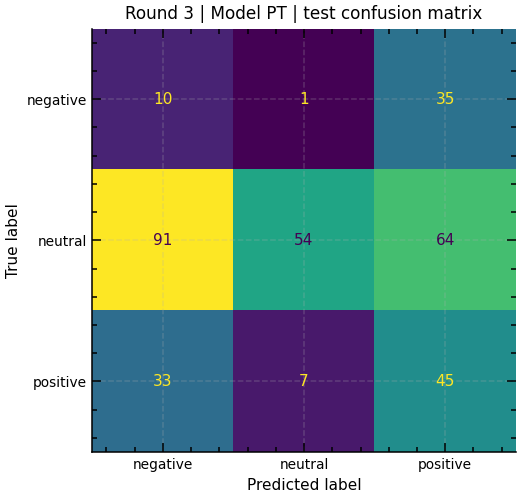

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
110,The operating margin of Aker Yards Cruise & Ferries division went down from 8.3 % to 6.4 % in the first quarter of 2...,negative,positive,0.363321,0.314695,0.321984,0.363321
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,neutral,0.359426,0.320077,0.359426,0.320496
136,"He joins Technopolis from KONE where he has held various positions within the Group , most recently as Director of S...",neutral,negative,0.357485,0.357485,0.314712,0.327803
179,"Changes being announced today will be effective after the close of trading on Friday , June 19 , 2009 .",neutral,positive,0.356554,0.311856,0.331591,0.356554
47,Fancy Dans on the move FAB Glasgow gift and interiors store Fancy Dans is moving !,neutral,positive,0.355069,0.327570,0.317361,0.355069
127,The soapstone deposits in the Medvezhyegorsk area are expected to increase Tulikivi 's current reserves considerably .,positive,neutral,0.354271,0.323502,0.354271,0.322226
17,The bond has a value of EUR150m and a maturity of 4 years .,neutral,negative,0.353007,0.353007,0.318166,0.328826
217,"Marathon now has a 4.6 percent stake in PLX , it said , according to Bloomberg .",neutral,positive,0.352489,0.334694,0.312817,0.352489


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
108,The transaction is expected to be completed next spring .,neutral,negative,0.333839,0.333839,0.333032,0.333129
333,"The company operates its business through two reportable segments , including Banking and Investment Services , and ...",neutral,positive,0.334046,0.332805,0.333150,0.334046
41,"Systeemitiimi 's sales and project resources will also be strengthened , director Paul Skogberg said .",positive,negative,0.334167,0.334167,0.332607,0.333226
251,"RFID ( Radio Frequency Identification ) is a method of so-called intelligent transport , whereby information can be ...",neutral,negative,0.334264,0.334264,0.332994,0.332742
339,"Operating profit , excluding non-recurring items , totalled EUR 1.0 mn , down from EUR 1.6 mn .",negative,positive,0.334285,0.333657,0.332058,0.334285
195,"Financial Statements include the consolidated financial statements of the Group , the Board of Directors ' Report , ...",neutral,neutral,0.334292,0.332937,0.334292,0.332771
296,`` Printed fabrics and related design expertise have always been the core of Marimekko 's business and brand .,neutral,negative,0.334299,0.334299,0.331431,0.334269
202,"They can be used to control the speed of electric motors used by industry and municipal engineering , and in power g...",neutral,neutral,0.334413,0.332894,0.334413,0.332693


,sentence,gold_label,old_pred,new_pred,old_conf,new_conf,old_correct,new_correct,confidence_delta


Deep dive: Round 3 | Model PT
loss=1.1031 | accuracy=0.3206 | macro_f1=0.3009 | weighted_f1=0.3583
vs reference -> Δaccuracy=+0.0000, Δmacro_f1=+0.0000, Δloss=+0.0000

Class-wise report:


,precision,recall,f1-score,support
negative,0.0746,0.2174,0.1111,46.0
neutral,0.8710,0.2584,0.3985,209.0
positive,0.3125,0.5294,0.3930,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='neutral' predicted='negative' (count=91)
Number of wrong predictions: 231 / 340
Median confidence on wrong predictions: 0.3415
Interpretation: many mistakes are low-confidence -> the model often knows it is uncertain.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [67]:

ROUND3_RESULTS = []
ROUND3_HISTORIES = {}
ROUND3_VAL_EVALS = {}
ROUND3_TEST_EVALS = {}

model1_r3 = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=ROUND3_CFG["seed"])
show_parameter_summary(model1_r3, "Round 3 | Model PT | parameter summary", only_trainable=True)

model1_r3_val = evaluate_model(model1_r3, val_loader_r3, split_frames["validation"])
model1_r3_test = evaluate_model(model1_r3, test_loader_r3, split_frames["test"])

print("Round 3 | Model 1 | validation metrics:", model1_r3_val["metrics"])
print("Round 3 | Model 1 | test metrics      :", model1_r3_test["metrics"])

plot_confusion(model1_r3_test, "Round 3 | Model PT | test confusion matrix")
display(show_top_errors(model1_r3_test, n=8))
display(show_low_confidence_cases(model1_r3_test, n=8))
display(prediction_change_table(ROUND2_TEST_EVALS["Model PT"], model1_r3_test, mode="changed", n=8))

deep_dive_report("Round 3 | Model PT", model1_r3_test, reference_eval=ROUND2_TEST_EVALS["Model PT"])

register_result(
    ROUND3_RESULTS,
    "Model PT",
    model1_r3,
    model1_r3_val,
    model1_r3_test,
    notes=f"Round-3 anchor model; no financial FT; max_length={ROUND3_CFG['max_length']}",
)
ROUND3_VAL_EVALS["Model PT"] = model1_r3_val
ROUND3_TEST_EVALS["Model PT"] = model1_r3_test

model1_r3.to("cpu")
cleanup()


## Round 3 / Model 2 — Model PT + FT Classifier

The Round 3 changes to Model 2 are deliberately conservative. Round 2 already established that head-only fine-tuning is most likely limited not by the optimiser but by the frozen representation itself, so Round 3 leaves the structure alone and adjusts only the learning rate, smoothing, and (conditionally) class weighting on the basis of Round 2's class-wise diagnostics.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Round 3 | Model PT + FT Classifier | trainable parameters
Total params     : 66,955,779
Trainable params : 592,899
Trainable ratio  : 0.008855


,name,shape,num_params,requires_grad
0,pre_classifier.weight,"(768, 768)",589824,True
1,pre_classifier.bias,"(768,)",768,True
2,classifier.weight,"(3, 768)",2304,True
3,classifier.bias,"(3,)",3,True


Round-3 head-only setup
epochs          : 6
lr              : 4.05e-04
class_weights   : None
label_smoothing : 0.02


Round3 Model2 | round3 epoch 1/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7487 | val_loss=0.5287 | val_acc=0.7647 | val_macro_f1=0.6349


Round3 Model2 | round3 epoch 2/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4943 | val_loss=0.4455 | val_acc=0.8265 | val_macro_f1=0.7202


Round3 Model2 | round3 epoch 3/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4272 | val_loss=0.4350 | val_acc=0.8265 | val_macro_f1=0.7416


Round3 Model2 | round3 epoch 4/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.3932 | val_loss=0.4040 | val_acc=0.8265 | val_macro_f1=0.7273


Round3 Model2 | round3 epoch 5/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3708 | val_loss=0.4019 | val_acc=0.8471 | val_macro_f1=0.7612


Round3 Model2 | round3 epoch 6/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.3635 | val_loss=0.3917 | val_acc=0.8500 | val_macro_f1=0.7592


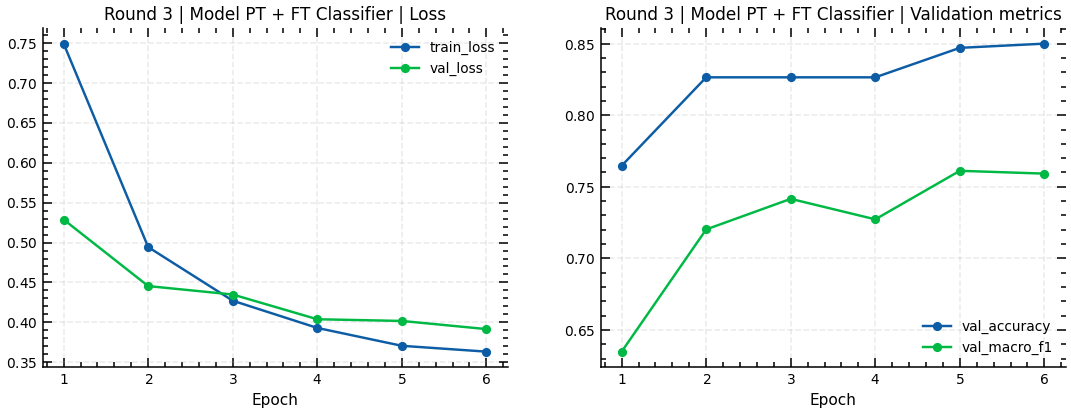

Round 3 | Model 2 | validation metrics: {'accuracy': 0.8470588235294118, 'macro_precision': 0.765399923459625, 'macro_recall': 0.7620369340075582, 'macro_f1': 0.7611716808412323, 'weighted_f1': 0.8481692110361059, 'loss': 0.3559298631022958}
Round 3 | Model 2 | test metrics      : {'accuracy': 0.8529411764705882, 'macro_precision': 0.7933842752658083, 'macro_recall': 0.7756502975644178, 'macro_f1': 0.7806329459757141, 'weighted_f1': 0.8526484342187557, 'loss': 0.3669928266721613}


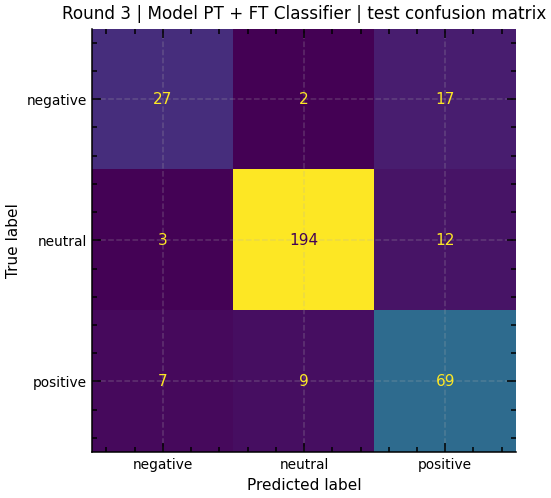

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
263,"These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has suff...",positive,neutral,0.943366,0.001444,0.943366,0.055190
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,neutral,0.939688,0.001765,0.939688,0.058547
99,No changes in media activity were seen in October compared with September .,neutral,negative,0.905584,0.905584,0.012030,0.082386
150,Cargotec Germany GmbH has been awarded a contract by Stadtverwaltung Mainz for chassis bodies under Open procedure .,positive,neutral,0.866957,0.003196,0.866957,0.129848
159,Viking Line manages well with its current ferries .,positive,neutral,0.866206,0.024377,0.866206,0.109416
275,"Operating loss was EUR 179mn , compared to a loss of EUR 188mn in the second quarter of 2009 .",positive,negative,0.811544,0.811544,0.004129,0.184327
42,"OUTOTEC OYJ PRESS RELEASE , FEBRUARY 19 , 2008 AT 11.00 AM Outotec has won two large minerals processing technology ...",positive,neutral,0.787124,0.006535,0.787124,0.206342
160,Motorola Inc. of the United States came second with shipments of 217.4 million units for a 21.3 percent market share...,neutral,positive,0.775622,0.163027,0.061351,0.775622


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
141,UPM-Kymmene said its has ` not indicated any interest in any domestic consolidations ' .,neutral,positive,0.395091,0.283381,0.321528,0.395091
114,Another noticeable thing is that the search for Tata and Airtel brands was mostly related to ` broadband connections...,neutral,neutral,0.452466,0.422326,0.452466,0.125208
119,Finnish media group Talentum has issued a profit warning .,negative,neutral,0.452576,0.420100,0.452576,0.127324
312,The transactions would increase earnings per share in the first quarter by some EUR0 .28 .,positive,positive,0.453979,0.105607,0.440414,0.453979
207,"In the second quarter of 2010 , the group 's pretax loss narrowed to EUR 400,000 from EUR 600,000 .",positive,negative,0.454933,0.454933,0.110777,0.434290
126,The total capital of funds managed by the bank decreased by 28 % to EUR 284mn by the end of September 2008 .,negative,neutral,0.472068,0.278647,0.472068,0.249285
22,The profit after taxes was EUR 57.7 11.1 million .,neutral,neutral,0.474032,0.168074,0.474032,0.357894
121,"BAVARIA Industriekapital AG 's 2006 revenues were EUR 333 million , with an EBITDA of EUR 51 million .",neutral,neutral,0.485577,0.138440,0.485577,0.375983


Improved cases vs round 2


,sentence,gold_label,old_pred,new_pred,old_conf,new_conf,old_correct,new_correct,confidence_delta
320,"In the third quarter of fiscal 2008 Efore swung to a net loss of EUR 400,000 versus a net profit of EUR 200,000 for ...",negative,positive,negative,0.490872,0.540522,False,True,0.049650
208,"Fiskars , a 360-year-old global business best known for its orange-handled scissors , expects to derive synergies of...",positive,neutral,positive,0.518947,0.562351,False,True,0.043403
81,Productional situation has now improved .,positive,neutral,positive,0.476956,0.495102,False,True,0.018145
314,"ADPnews - Jul 17 , 2009 - Finland-based steel maker Rautaruukki Oyj Ruukki HEL : RTRKS said today it slipped to a ne...",negative,positive,negative,0.471361,0.486895,False,True,0.015534
59,Finnish Metso Paper has been awarded a contract for the rebuild of Sabah Forest Industries ' ( SFI ) pulp mill in Sa...,positive,neutral,positive,0.532307,0.539337,False,True,0.007030
200,Biohit already services many current Genesis customers and the customer base is expected to expand as a result of th...,positive,neutral,positive,0.555955,0.546979,False,True,-0.008976
133,Net sales fell by 33 % from the third quarter of 2008 to EUR 130.5 mn .,negative,positive,negative,0.529882,0.512762,False,True,-0.017120
282,This will bring cost savings of about EUR 3mn a year .,positive,neutral,positive,0.529449,0.496527,False,True,-0.032922


Regressed cases vs round 2


,sentence,gold_label,old_pred,new_pred,old_conf,new_conf,old_correct,new_correct,confidence_delta
207,"In the second quarter of 2010 , the group 's pretax loss narrowed to EUR 400,000 from EUR 600,000 .",positive,positive,negative,0.431937,0.454933,True,False,0.022996
141,UPM-Kymmene said its has ` not indicated any interest in any domestic consolidations ' .,neutral,neutral,positive,0.405967,0.395091,True,False,-0.010875
299,Atria said its offer would give the Swedish company continued ownership and control of its slaughtering and cutting ...,neutral,neutral,positive,0.536747,0.513890,True,False,-0.022856
87,Return on capital employed rose by 4.8 percentage points to 19.6 % .,positive,positive,negative,0.542915,0.513274,True,False,-0.029640


Correctness shift table (round 2 -> round 3)


,new_correct,new_wrong
old_correct,281,4
old_wrong,9,46


Deep dive: Round 3 | Model PT + FT Classifier
loss=0.3670 | accuracy=0.8529 | macro_f1=0.7806 | weighted_f1=0.8526
vs reference -> Δaccuracy=+0.0147, Δmacro_f1=+0.0238, Δloss=-0.0013

Class-wise report:


,precision,recall,f1-score,support
negative,0.7297,0.5870,0.6506,46.0
neutral,0.9463,0.9282,0.9372,209.0
positive,0.7041,0.8118,0.7541,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='negative' predicted='positive' (count=17)
Number of wrong predictions: 50 / 340
Median confidence on wrong predictions: 0.6227
Interpretation: mistakes are mixed-confidence -> both representation quality and boundary sharpness matter.
Approx. last-epoch generalization gap (val_loss - train_loss): +0.0282
Interpretation: train/validation losses are in a relatively healthy range.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [68]:

model2_r3 = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=ROUND3_CFG["seed"])
freeze_all_but_default_head(model2_r3)
show_parameter_summary(model2_r3, "Round 3 | Model PT + FT Classifier | trainable parameters", only_trainable=True)

round3_model2_class_weights = (
    build_class_weights_tensor(split_frames["train"], mode=ROUND3_CFG["model2"]["class_weight_mode"])
    if ROUND3_CFG["model2"]["use_class_weights"]
    else None
)

print("Round-3 head-only setup")
print(f"epochs          : {ROUND3_CFG['model2']['epochs']}")
print(f"lr              : {ROUND3_CFG['model2']['lr']:.2e}")
print(f"class_weights   : {round3_model2_class_weights}")
print(f"label_smoothing : {ROUND3_CFG['model2']['label_smoothing']}")

model2_r3, model2_r3_history, model2_r3_best_val = fit_model_round3(
    model2_r3,
    train_loader_r3,
    val_loader_r3,
    split_frames["train"],
    split_frames["validation"],
    epochs=ROUND3_CFG["model2"]["epochs"],
    lr=ROUND3_CFG["model2"]["lr"],
    weight_decay=ROUND3_CFG["weight_decay"],
    warmup_ratio=ROUND3_CFG["warmup_ratio"],
    clip_grad_norm=ROUND3_CFG["clip_grad_norm"],
    class_weights=round3_model2_class_weights,
    label_smoothing=ROUND3_CFG["model2"]["label_smoothing"],
    early_stopping_patience=ROUND3_CFG["early_stopping_patience"],
    min_epochs_before_stop=ROUND3_CFG["min_epochs_before_stop"],
    model_name="Round3 Model2",
)

best_model2_r3_state = copy.deepcopy(model2_r3.state_dict())

model2_r3_val = evaluate_model(model2_r3, val_loader_r3, split_frames["validation"])
model2_r3_test = evaluate_model(model2_r3, test_loader_r3, split_frames["test"])

plot_history(model2_r3_history, "Round 3 | Model PT + FT Classifier")
print("Round 3 | Model 2 | validation metrics:", model2_r3_val["metrics"])
print("Round 3 | Model 2 | test metrics      :", model2_r3_test["metrics"])

plot_confusion(model2_r3_test, "Round 3 | Model PT + FT Classifier | test confusion matrix")
display(show_top_errors(model2_r3_test, n=8))
display(show_low_confidence_cases(model2_r3_test, n=8))
print("Improved cases vs round 2")
display(prediction_change_table(ROUND2_TEST_EVALS["Model PT + FT Classifier"], model2_r3_test, mode="improved", n=8))
print("Regressed cases vs round 2")
display(prediction_change_table(ROUND2_TEST_EVALS["Model PT + FT Classifier"], model2_r3_test, mode="regressed", n=8))
print("Correctness shift table (round 2 -> round 3)")
display(correctness_shift_table(ROUND2_TEST_EVALS["Model PT + FT Classifier"], model2_r3_test))

deep_dive_report(
    "Round 3 | Model PT + FT Classifier",
    model2_r3_test,
    history_df=model2_r3_history,
    reference_eval=ROUND2_TEST_EVALS["Model PT + FT Classifier"],
)

register_result(
    ROUND3_RESULTS,
    "Model PT + FT Classifier",
    model2_r3,
    model2_r3_val,
    model2_r3_test,
    notes="Round-3 head-only FT with lighter lr, mild smoothing, and optional class weights only if class gap still persists",
)
ROUND3_HISTORIES["Model PT + FT Classifier"] = model2_r3_history
ROUND3_VAL_EVALS["Model PT + FT Classifier"] = model2_r3_val
ROUND3_TEST_EVALS["Model PT + FT Classifier"] = model2_r3_test

model2_r3.to("cpu")
cleanup()


### Reading Round-3 Model 2

What I want to know:

Has the previously weakest class improved?

Has the dominant confusion pattern narrowed?

Is any improvement coming from better calibration (the model becoming less prone to over-confident wrong predictions), or from a substantive change in what the model can identify?

Has the head-only setup effectively reached the ceiling imposed by the frozen body?

Together these characterise the upper bound of what head-only tuning can deliver.


## Round 3 / Model 3 — Model PT + Own FT Classifier

Round 3's Model 3 keeps the assignment requirement of a self-grafted classifier head but changes the **pooling strategy** rather than just the MLP width. The Round 3 head uses a concatenation of the `[CLS]`-position representation and a masked-mean pooling over all token positions.

The substantive difference from the default head is the assumption that informative sentiment cues are spread across the sentence, not fully concentrated at `[CLS]`. With the backbone frozen, the additional pooling gives the MLP a richer view of the input without modifying the representation itself.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Round 3 | Model PT + Own FT Classifier | trainable parameters
Total params     : 67,251,971
Trainable params : 889,091
Trainable ratio  : 0.013220


,name,shape,num_params,requires_grad
0,classifier_head.0.weight,"(1536,)",1536,True
1,classifier_head.0.bias,"(1536,)",1536,True
2,classifier_head.1.weight,"(512, 1536)",786432,True
3,classifier_head.1.bias,"(512,)",512,True
4,classifier_head.4.weight,"(192, 512)",98304,True
5,classifier_head.4.bias,"(192,)",192,True
6,classifier_head.7.weight,"(3, 192)",576,True
7,classifier_head.7.bias,"(3,)",3,True


Round-3 custom head setup
pooling          : cls_mean_concat
hidden_dims      : (512, 192)
dropout          : 0.25
activation       : gelu
use_layernorm    : True
lr               : 2.29e-04
epochs           : 6
class_weights    : None
label_smoothing  : 0.03
Classifier head:


Sequential(
  (0): LayerNorm((1536,), eps=1e-05, elementwise_affine=True)
  (1): Linear(in_features=1536, out_features=512, bias=True)
  (2): GELU(approximate='none')
  (3): Dropout(p=0.25, inplace=False)
  (4): Linear(in_features=512, out_features=192, bias=True)
  (5): GELU(approximate='none')
  (6): Dropout(p=0.25, inplace=False)
  (7): Linear(in_features=192, out_features=3, bias=True)
)

Round3 Model3 | round3 epoch 1/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7418 | val_loss=0.5090 | val_acc=0.7765 | val_macro_f1=0.6496


Round3 Model3 | round3 epoch 2/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4960 | val_loss=0.4322 | val_acc=0.8176 | val_macro_f1=0.7035


Round3 Model3 | round3 epoch 3/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4032 | val_loss=0.3941 | val_acc=0.8706 | val_macro_f1=0.7822


Round3 Model3 | round3 epoch 4/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.3639 | val_loss=0.3820 | val_acc=0.8647 | val_macro_f1=0.7859


Round3 Model3 | round3 epoch 5/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3412 | val_loss=0.3726 | val_acc=0.8882 | val_macro_f1=0.8259


Round3 Model3 | round3 epoch 6/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.3188 | val_loss=0.3761 | val_acc=0.8676 | val_macro_f1=0.7797


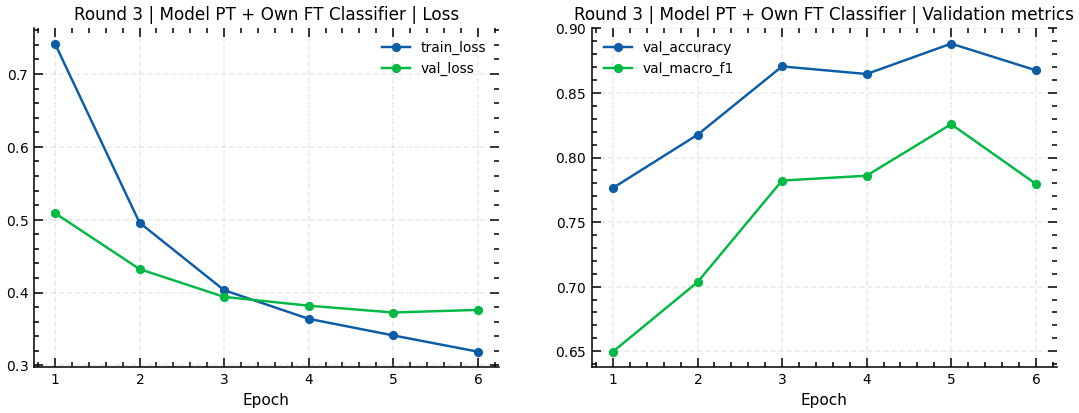

Round 3 | Model 3 | validation metrics: {'accuracy': 0.888235294117647, 'macro_precision': 0.8292333346062296, 'macro_recall': 0.8227719875210696, 'macro_f1': 0.8258667907432514, 'weighted_f1': 0.8878003203082184, 'loss': 0.29437501009772804}
Round 3 | Model 3 | test metrics      : {'accuracy': 0.8794117647058823, 'macro_precision': 0.8375398503305481, 'macro_recall': 0.8305628637974848, 'macro_f1': 0.8339125458834039, 'weighted_f1': 0.879164111317181, 'loss': 0.309980625966016}


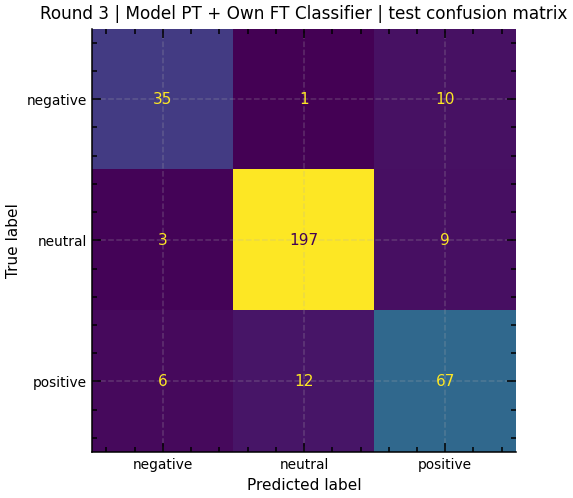

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
159,Viking Line manages well with its current ferries .,positive,neutral,0.950914,0.009958,0.950914,0.039128
263,"These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has suff...",positive,neutral,0.944256,0.002569,0.944256,0.053175
99,No changes in media activity were seen in October compared with September .,neutral,negative,0.930768,0.930768,0.009553,0.059679
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,neutral,0.930288,0.002667,0.930288,0.067045
275,"Operating loss was EUR 179mn , compared to a loss of EUR 188mn in the second quarter of 2009 .",positive,negative,0.889341,0.889341,0.005799,0.104860
167,These moderate but significant changes resulted in a significant 24-32 % reduction in the estimated CVD risk .,positive,negative,0.848913,0.848913,0.052592,0.098495
286,"Citigroup , Inc ( NYSE : C ) has announced that its Global Transaction Services ( GTS ) business has been awarded a ...",positive,neutral,0.847185,0.011974,0.847185,0.140841
120,"Protalix closed at $ 10.71 on Friday on the American Stock Exchange , giving a market cap of $ 827 million .",neutral,negative,0.830733,0.830733,0.140955,0.028312


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
194,"Group EBIT for the first half was EUR13 .6 m US$ 17.8 m , falling short of the EUR22 .5 m it posted for the same per...",negative,negative,0.356641,0.356641,0.356455,0.286904
220,Profit after taxes totaled EUR 12.1 mn .,neutral,neutral,0.359772,0.330547,0.359772,0.309682
146,Finnish Cargotec 's Kalmar has received a significant order from the US Department of Defense .,positive,neutral,0.494770,0.046858,0.494770,0.458372
74,"In July-September 2009 , Konecranes ' sales decreased to EUR 368.7 mn from EUR 520.4 mn in July-September 2008 .",negative,positive,0.494968,0.487899,0.017133,0.494968
141,UPM-Kymmene said its has ` not indicated any interest in any domestic consolidations ' .,neutral,neutral,0.495618,0.115905,0.495618,0.388477
119,Finnish media group Talentum has issued a profit warning .,negative,negative,0.507797,0.507797,0.428130,0.064074
282,This will bring cost savings of about EUR 3mn a year .,positive,positive,0.511397,0.030510,0.458094,0.511397
339,"Operating profit , excluding non-recurring items , totalled EUR 1.0 mn , down from EUR 1.6 mn .",negative,negative,0.511652,0.511652,0.244228,0.244120


Improved cases vs round 2


,sentence,gold_label,old_pred,new_pred,old_conf,new_conf,old_correct,new_correct,confidence_delta
166,The net sales of Healthcare Trade business in 2009 were EUR 145.1 million EUR 155.2 million and operating profit EUR...,neutral,positive,neutral,0.505783,0.756589,False,True,0.250806
81,Productional situation has now improved .,positive,neutral,positive,0.491077,0.602828,False,True,0.111751
265,"In the fourth quarter of 2008 , net sales decreased to EUR 121.4 mn from EUR 165.5 mn in the fourth quarter of 2007 .",negative,positive,negative,0.518459,0.626885,False,True,0.108427
63,"In Q1 of 2009 , the company 's operating loss totalled EUR 0.3 mn , compared to a profit of EUR 3.6 mn in Q1 of 2008 .",negative,positive,negative,0.550281,0.635013,False,True,0.084732
312,The transactions would increase earnings per share in the first quarter by some EUR0 .28 .,positive,neutral,positive,0.567146,0.644904,False,True,0.077758
174,"Operating profit totaled EUR 6.7 mn , down from EUR 7.2 mn in the corresponding period in 2005 .",negative,positive,negative,0.576031,0.535644,False,True,-0.040388
283,"Food sales totalled EUR 323.5 mn in October 2009 , representing a decrease of 5.5 % from October 2008 .",negative,positive,negative,0.617031,0.532236,False,True,-0.084795
119,Finnish media group Talentum has issued a profit warning .,negative,neutral,negative,0.647556,0.507797,False,True,-0.139760


Regressed cases vs round 2


,sentence,gold_label,old_pred,new_pred,old_conf,new_conf,old_correct,new_correct,confidence_delta
41,"Systeemitiimi 's sales and project resources will also be strengthened , director Paul Skogberg said .",positive,positive,neutral,0.680297,0.747489,True,False,0.067192
276,"Some of the most recent technology deliveries include refinery technology to Anrak Aluminium , an iron ore pelletizi...",neutral,neutral,positive,0.607896,0.641119,True,False,0.033222
306,"In 2010 , Sanoma Magazines expects net sales to be at the 2009 level .",neutral,neutral,positive,0.559481,0.581580,True,False,0.022098
297,"Cash flow from operations totalled EUR 2.71 mn , compared to a negative EUR 0.83 mn in the corresponding period in 2...",positive,positive,negative,0.521771,0.542279,True,False,0.020508
146,Finnish Cargotec 's Kalmar has received a significant order from the US Department of Defense .,positive,positive,neutral,0.504712,0.494770,True,False,-0.009942
208,"Fiskars , a 360-year-old global business best known for its orange-handled scissors , expects to derive synergies of...",positive,positive,neutral,0.548830,0.533270,True,False,-0.015560
299,Atria said its offer would give the Swedish company continued ownership and control of its slaughtering and cutting ...,neutral,neutral,positive,0.671062,0.539042,True,False,-0.132020


Correctness shift table (round 2 -> round 3)


,new_correct,new_wrong
old_correct,288,7
old_wrong,11,34


Deep dive: Round 3 | Model PT + Own FT Classifier
loss=0.3100 | accuracy=0.8794 | macro_f1=0.8339 | weighted_f1=0.8792
vs reference -> Δaccuracy=+0.0118, Δmacro_f1=+0.0319, Δloss=-0.0298

Class-wise report:


,precision,recall,f1-score,support
negative,0.7955,0.7609,0.7778,46.0
neutral,0.9381,0.9426,0.9403,209.0
positive,0.7791,0.7882,0.7836,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='positive' predicted='neutral' (count=12)
Number of wrong predictions: 41 / 340
Median confidence on wrong predictions: 0.6962
Interpretation: mistakes are mixed-confidence -> both representation quality and boundary sharpness matter.
Approx. last-epoch generalization gap (val_loss - train_loss): +0.0573
Interpretation: train/validation losses are in a relatively healthy range.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [69]:

model3_r3 = DistilBertWithCustomHeadV3(
    base_model_name=ROUND3_CFG["model_name"],
    num_labels=len(LABEL_ORDER),
    hidden_dims=ROUND3_CFG["model3"]["hidden_dims"],
    dropout=ROUND3_CFG["model3"]["dropout"],
    activation=ROUND3_CFG["model3"]["activation"],
    use_layernorm=ROUND3_CFG["model3"]["use_layernorm"],
    pooling=ROUND3_CFG["model3"]["pooling"],
    id2label=id2label,
    label2id=label2id,
)
freeze_backbone_unfreeze_custom_head_v3(model3_r3)
show_parameter_summary(model3_r3, "Round 3 | Model PT + Own FT Classifier | trainable parameters", only_trainable=True)

round3_model3_class_weights = (
    build_class_weights_tensor(split_frames["train"], mode=ROUND3_CFG["model3"]["class_weight_mode"])
    if ROUND3_CFG["model3"]["use_class_weights"]
    else None
)

print("Round-3 custom head setup")
print(f"pooling          : {ROUND3_CFG['model3']['pooling']}")
print(f"hidden_dims      : {ROUND3_CFG['model3']['hidden_dims']}")
print(f"dropout          : {ROUND3_CFG['model3']['dropout']}")
print(f"activation       : {ROUND3_CFG['model3']['activation']}")
print(f"use_layernorm    : {ROUND3_CFG['model3']['use_layernorm']}")
print(f"lr               : {ROUND3_CFG['model3']['lr']:.2e}")
print(f"epochs           : {ROUND3_CFG['model3']['epochs']}")
print(f"class_weights    : {round3_model3_class_weights}")
print(f"label_smoothing  : {ROUND3_CFG['model3']['label_smoothing']}")
print("Classifier head:")
display(model3_r3.classifier_head)

model3_r3, model3_r3_history, model3_r3_best_val = fit_model_round3(
    model3_r3,
    train_loader_r3,
    val_loader_r3,
    split_frames["train"],
    split_frames["validation"],
    epochs=ROUND3_CFG["model3"]["epochs"],
    lr=ROUND3_CFG["model3"]["lr"],
    weight_decay=ROUND3_CFG["weight_decay"],
    warmup_ratio=ROUND3_CFG["warmup_ratio"],
    clip_grad_norm=ROUND3_CFG["clip_grad_norm"],
    class_weights=round3_model3_class_weights,
    label_smoothing=ROUND3_CFG["model3"]["label_smoothing"],
    early_stopping_patience=ROUND3_CFG["early_stopping_patience"],
    min_epochs_before_stop=ROUND3_CFG["min_epochs_before_stop"],
    model_name="Round3 Model3",
)

model3_r3_val = evaluate_model(model3_r3, val_loader_r3, split_frames["validation"])
model3_r3_test = evaluate_model(model3_r3, test_loader_r3, split_frames["test"])

plot_history(model3_r3_history, "Round 3 | Model PT + Own FT Classifier")
print("Round 3 | Model 3 | validation metrics:", model3_r3_val["metrics"])
print("Round 3 | Model 3 | test metrics      :", model3_r3_test["metrics"])

plot_confusion(model3_r3_test, "Round 3 | Model PT + Own FT Classifier | test confusion matrix")
display(show_top_errors(model3_r3_test, n=8))
display(show_low_confidence_cases(model3_r3_test, n=8))
print("Improved cases vs round 2")
display(prediction_change_table(ROUND2_TEST_EVALS["Model PT + Own FT Classifier"], model3_r3_test, mode="improved", n=8))
print("Regressed cases vs round 2")
display(prediction_change_table(ROUND2_TEST_EVALS["Model PT + Own FT Classifier"], model3_r3_test, mode="regressed", n=8))
print("Correctness shift table (round 2 -> round 3)")
display(correctness_shift_table(ROUND2_TEST_EVALS["Model PT + Own FT Classifier"], model3_r3_test))

deep_dive_report(
    "Round 3 | Model PT + Own FT Classifier",
    model3_r3_test,
    history_df=model3_r3_history,
    reference_eval=ROUND2_TEST_EVALS["Model PT + Own FT Classifier"],
)

register_result(
    ROUND3_RESULTS,
    "Model PT + Own FT Classifier",
    model3_r3,
    model3_r3_val,
    model3_r3_test,
    notes="Round-3 custom head: hybrid pooling (CLS + masked mean) + wider MLP + LayerNorm",
)
ROUND3_HISTORIES["Model PT + Own FT Classifier"] = model3_r3_history
ROUND3_VAL_EVALS["Model PT + Own FT Classifier"] = model3_r3_val
ROUND3_TEST_EVALS["Model PT + Own FT Classifier"] = model3_r3_test

model3_r3.to("cpu")
cleanup()


### Reading Round-3 Model 3

Any improvement here shouldn't be attributed to additional MLP layers but to the pooling change — the head reads the sentence in a structurally different way, and that's what the comparison is testing.

If Round-3 Model 3 still doesn't match Models 4 or 5, that reinforces the picture from earlier rounds: with the backbone frozen, head architecture has limited effect, and substantive further gains require body adaptation (full or LoRA-mediated).


## Round 3 / Model 4 — Model PT + FT Classifier + FT Base (LLRD)

The questions Round-3 Model 4 is meant to answer:

Does LLRD give more stable training curves at comparable or better final performance?

Are the lower layers, with their reduced learning rate, less likely to be perturbed off-distribution by the small training set?

Is the additional complexity of full body fine-tuning still worth it relative to Model 5's LoRA configuration?


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Round 3 | Model PT + FT Classifier + FT Base | trainable parameters
Total params     : 66,955,779
Trainable params : 66,362,880
Trainable ratio  : 0.991145


,name,shape,num_params,requires_grad
0,distilbert.embeddings.word_embeddings.weight,"(30522, 768)",23440896,True
1,distilbert.embeddings.position_embeddings.weight,"(512, 768)",393216,True
2,distilbert.embeddings.LayerNorm.weight,"(768,)",768,True
3,distilbert.embeddings.LayerNorm.bias,"(768,)",768,True
4,distilbert.transformer.layer.0.attention.q_lin.weight,"(768, 768)",589824,True
5,distilbert.transformer.layer.0.attention.q_lin.bias,"(768,)",768,True
6,distilbert.transformer.layer.0.attention.k_lin.weight,"(768, 768)",589824,True
7,distilbert.transformer.layer.0.attention.k_lin.bias,"(768,)",768,True
8,distilbert.transformer.layer.0.attention.v_lin.weight,"(768, 768)",589824,True
9,distilbert.transformer.layer.0.attention.v_lin.bias,"(768,)",768,True


Round-3 body-only setup with layer-wise lr decay


,group_idx,group_name,lr,num_tensors,num_params
0,0,embeddings,0.000004,4,23835648
1,1,transformer_layer_0,0.000009,16,7087872
2,2,transformer_layer_1,0.000010,16,7087872
3,3,transformer_layer_2,0.000012,16,7087872
4,4,transformer_layer_3,0.000014,16,7087872
5,5,transformer_layer_4,0.000017,16,7087872
6,6,transformer_layer_5,0.000020,16,7087872


epochs          : 5
top_lr          : 1.98e-05
layer_decay     : 0.85
embeddings_scale: 0.5
class_weights   : None
label_smoothing : 0.0


Round3 Model4 | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2321 | val_loss=0.1712 | val_acc=0.9412 | val_macro_f1=0.9179


Round3 Model4 | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.0924 | val_loss=0.1523 | val_acc=0.9500 | val_macro_f1=0.9352


Round3 Model4 | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0302 | val_loss=0.1522 | val_acc=0.9618 | val_macro_f1=0.9504


Round3 Model4 | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0124 | val_loss=0.1501 | val_acc=0.9618 | val_macro_f1=0.9493


Round3 Model4 | round3 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0085 | val_loss=0.1521 | val_acc=0.9588 | val_macro_f1=0.9465
Early stopping triggered for Round3 Model4 at epoch 5.


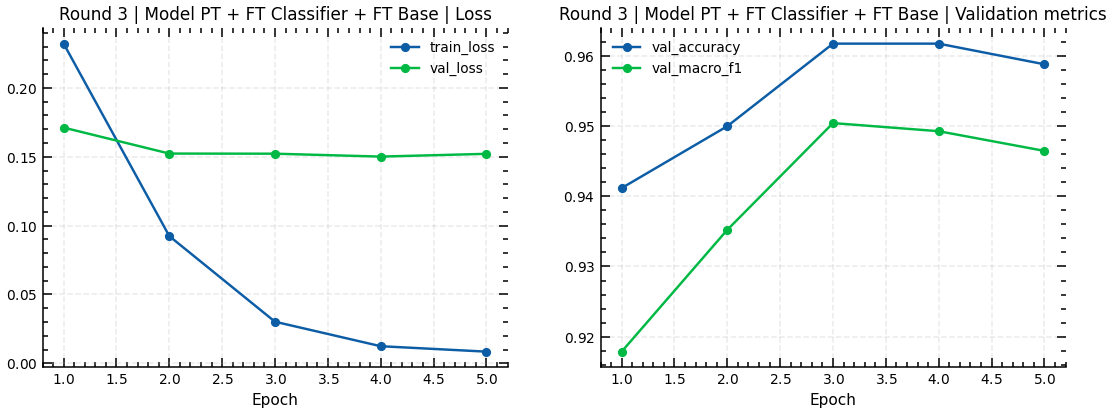

Round 3 | Model 4 | validation metrics: {'accuracy': 0.961764705882353, 'macro_precision': 0.9393731411576298, 'macro_recall': 0.963079180215043, 'macro_f1': 0.9504417349178739, 'weighted_f1': 0.9622978799567561, 'loss': 0.15221614542636364}
Round 3 | Model 4 | test metrics      : {'accuracy': 0.9588235294117647, 'macro_precision': 0.9405242500700869, 'macro_recall': 0.9547351289173877, 'macro_f1': 0.9474160605111704, 'weighted_f1': 0.959074376618678, 'loss': 0.19444709242705036}


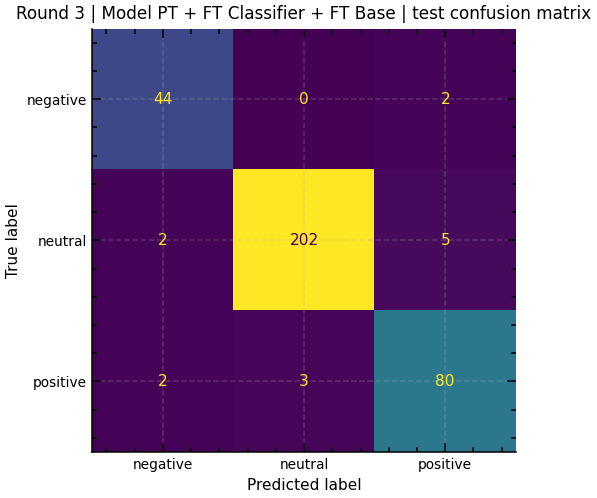

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
113,Finnish power supply solutions and systems provider Efore Oyj said its net loss widened to 3.2 mln euro $ 4.2 mln fo...,negative,positive,0.999987,1.015267e-05,2.762873e-06,0.999987
299,Atria said its offer would give the Swedish company continued ownership and control of its slaughtering and cutting ...,neutral,positive,0.999741,3.068978e-06,2.560765e-04,0.999741
175,"In a letter to Economic Affairs Minister , the listed Estonian shipping company Tallink asks for the approval to be ...",neutral,positive,0.998370,8.438749e-04,7.857555e-04,0.998370
275,"Operating loss was EUR 179mn , compared to a loss of EUR 188mn in the second quarter of 2009 .",positive,negative,0.990028,9.900277e-01,6.182832e-07,0.009972
33,"Previously , the company expected its 2008 financial performance to remain at the same level as in 2008 .",neutral,positive,0.985494,1.391743e-02,5.887464e-04,0.985494
263,"These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has suff...",positive,neutral,0.980235,1.152724e-07,9.802353e-01,0.019765
120,"Protalix closed at $ 10.71 on Friday on the American Stock Exchange , giving a market cap of $ 827 million .",neutral,negative,0.977098,9.770981e-01,2.285694e-02,0.000045
99,No changes in media activity were seen in October compared with September .,neutral,negative,0.946741,9.467412e-01,2.609596e-03,0.050649


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
249,"In January-June 2010 , diluted loss per share stood at EUR0 .3 versus EUR0 .1 in the first half of 2009 .",negative,negative,0.502177,0.502177,1.682051e-05,0.497806
10,"The company reported a profit of 800,000 euro ($ 1.2 mln)on the sale of its Varesvuo Partners sub-group and a loss o...",neutral,neutral,0.503024,0.492683,5.030242e-01,0.004293
160,Motorola Inc. of the United States came second with shipments of 217.4 million units for a 21.3 percent market share...,neutral,positive,0.540466,0.004148,4.553868e-01,0.540466
214,Increase in the number of shares is based on the option rights which were granted to the management of the company u...,neutral,neutral,0.585942,0.000002,5.859419e-01,0.414056
37,"The tests , conducted at Nokia Siemens ' LTE center of competence in Espoo , Finland , follow the company 's product...",neutral,positive,0.696137,0.000002,3.038615e-01,0.696137
257,Following this increase Huhtamaki 's registered share capital is EUR360 .62 m and the number of shares outstanding i...,neutral,neutral,0.802595,0.000003,8.025952e-01,0.197402
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,positive,0.808929,0.000004,1.910673e-01,0.808929
320,"In the third quarter of fiscal 2008 Efore swung to a net loss of EUR 400,000 versus a net profit of EUR 200,000 for ...",negative,positive,0.844508,0.155491,9.891745e-07,0.844508


Improved cases vs round 2


,sentence,gold_label,old_pred,new_pred,old_conf,new_conf,old_correct,new_correct,confidence_delta
10,"The company reported a profit of 800,000 euro ($ 1.2 mln)on the sale of its Varesvuo Partners sub-group and a loss o...",neutral,negative,neutral,0.544601,0.503024,False,True,-0.041576


Regressed cases vs round 2


,sentence,gold_label,old_pred,new_pred,old_conf,new_conf,old_correct,new_correct,confidence_delta
37,"The tests , conducted at Nokia Siemens ' LTE center of competence in Espoo , Finland , follow the company 's product...",neutral,neutral,positive,0.712246,0.696137,True,False,-0.016109
160,Motorola Inc. of the United States came second with shipments of 217.4 million units for a 21.3 percent market share...,neutral,neutral,positive,0.859123,0.540466,True,False,-0.318657


Correctness shift table (round 2 -> round 3)


,new_correct,new_wrong
old_correct,325,2
old_wrong,1,12


Deep dive: Round 3 | Model PT + FT Classifier + FT Base
loss=0.1944 | accuracy=0.9588 | macro_f1=0.9474 | weighted_f1=0.9591
vs reference -> Δaccuracy=-0.0029, Δmacro_f1=-0.0012, Δloss=+0.0820

Class-wise report:


,precision,recall,f1-score,support
negative,0.9167,0.9565,0.9362,46.0
neutral,0.9854,0.9665,0.9758,209.0
positive,0.9195,0.9412,0.9302,85.0


Weakest class right now: positive
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='neutral' predicted='positive' (count=5)
Number of wrong predictions: 14 / 340
Median confidence on wrong predictions: 0.9619
Interpretation: many mistakes are high-confidence -> features may be systematically misleading, not just noisy.
Approx. last-epoch generalization gap (val_loss - train_loss): +0.1436
Interpretation: train/validation losses are in a relatively healthy range.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [70]:

model4_r3 = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=ROUND3_CFG["seed"])
model4_r3.load_state_dict(best_model2_r3_state)
freeze_default_head_unfreeze_body(model4_r3)
show_parameter_summary(model4_r3, "Round 3 | Model PT + FT Classifier + FT Base | trainable parameters", only_trainable=True)

round3_model4_class_weights = (
    build_class_weights_tensor(split_frames["train"], mode=ROUND3_CFG["model4"]["class_weight_mode"])
    if ROUND3_CFG["model4"]["use_class_weights"]
    else None
)

model4_param_groups = build_distilbert_body_param_groups(
    model4_r3,
    top_lr=ROUND3_CFG["model4"]["top_lr"],
    layer_decay=ROUND3_CFG["model4"]["layer_decay"],
    embeddings_scale=ROUND3_CFG["model4"]["embeddings_scale"],
)

print("Round-3 body-only setup with layer-wise lr decay")
display(summarize_param_groups(model4_param_groups))
print(f"epochs          : {ROUND3_CFG['model4']['epochs']}")
print(f"top_lr          : {ROUND3_CFG['model4']['top_lr']:.2e}")
print(f"layer_decay     : {ROUND3_CFG['model4']['layer_decay']}")
print(f"embeddings_scale: {ROUND3_CFG['model4']['embeddings_scale']}")
print(f"class_weights   : {round3_model4_class_weights}")
print(f"label_smoothing : {ROUND3_CFG['model4']['label_smoothing']}")

model4_r3, model4_r3_history, model4_r3_best_val = fit_model_round3(
    model4_r3,
    train_loader_r3,
    val_loader_r3,
    split_frames["train"],
    split_frames["validation"],
    epochs=ROUND3_CFG["model4"]["epochs"],
    lr=None,
    optimizer_param_groups=model4_param_groups,
    weight_decay=ROUND3_CFG["weight_decay"],
    warmup_ratio=ROUND3_CFG["warmup_ratio"],
    clip_grad_norm=ROUND3_CFG["clip_grad_norm"],
    class_weights=round3_model4_class_weights,
    label_smoothing=ROUND3_CFG["model4"]["label_smoothing"],
    early_stopping_patience=ROUND3_CFG["early_stopping_patience"],
    min_epochs_before_stop=ROUND3_CFG["min_epochs_before_stop"],
    model_name="Round3 Model4",
)

model4_r3_val = evaluate_model(model4_r3, val_loader_r3, split_frames["validation"])
model4_r3_test = evaluate_model(model4_r3, test_loader_r3, split_frames["test"])

plot_history(model4_r3_history, "Round 3 | Model PT + FT Classifier + FT Base")
print("Round 3 | Model 4 | validation metrics:", model4_r3_val["metrics"])
print("Round 3 | Model 4 | test metrics      :", model4_r3_test["metrics"])

plot_confusion(model4_r3_test, "Round 3 | Model PT + FT Classifier + FT Base | test confusion matrix")
display(show_top_errors(model4_r3_test, n=8))
display(show_low_confidence_cases(model4_r3_test, n=8))
print("Improved cases vs round 2")
display(prediction_change_table(ROUND2_TEST_EVALS["Model PT + FT Classifier + FT Base"], model4_r3_test, mode="improved", n=8))
print("Regressed cases vs round 2")
display(prediction_change_table(ROUND2_TEST_EVALS["Model PT + FT Classifier + FT Base"], model4_r3_test, mode="regressed", n=8))
print("Correctness shift table (round 2 -> round 3)")
display(correctness_shift_table(ROUND2_TEST_EVALS["Model PT + FT Classifier + FT Base"], model4_r3_test))

deep_dive_report(
    "Round 3 | Model PT + FT Classifier + FT Base",
    model4_r3_test,
    history_df=model4_r3_history,
    reference_eval=ROUND2_TEST_EVALS["Model PT + FT Classifier + FT Base"],
)

register_result(
    ROUND3_RESULTS,
    "Model PT + FT Classifier + FT Base",
    model4_r3,
    model4_r3_val,
    model4_r3_test,
    notes="Round-3 body-only FT from round-3 Model 2, with layer-wise lr decay and mild regularization",
)
ROUND3_HISTORIES["Model PT + FT Classifier + FT Base"] = model4_r3_history
ROUND3_VAL_EVALS["Model PT + FT Classifier + FT Base"] = model4_r3_val
ROUND3_TEST_EVALS["Model PT + FT Classifier + FT Base"] = model4_r3_test

model4_r3.to("cpu")
cleanup()


### Reading Round-3 Model 4

The diagnostics worth tracking are stability and balance: are the per-class metrics more even than in Round 2? Has the dominant confusion pattern reduced? Are the training curves healthier in shape (smoother, less abrupt early-stopping) at comparable final performance? LLRD is most useful when these stability properties improve without a meaningful loss in final score.


## Round 3 / Model 5 — Model PT + FT Classifier + PEFT Base (LoRA)

Round 3 of Model 5 keeps the structural constraints from earlier rounds. Initialise from the trained Model 2 checkpoint. Freeze the classifier head. Insert LoRA adapters by hand into FFN `lin1` and `lin2` for every transformer layer. Rank is fixed at 8. The trainable parameter count is computed analytically and verified against the model's actual count.

The question Round 3 is asking: can further small adjustments to `alpha`, dropout, learning rate, and epoch count improve calibration and generalisation while preserving the small trainable-parameter footprint?


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FFN target modules:
  distilbert.transformer.layer.0.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.0.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.1.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.1.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.2.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.2.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.3.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.3.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.4.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.4.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.5.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.5.ffn.lin2: 3072 -> 768
Round-3 LoRA parameter breakdown


,module,in_features,out_features,rank,expected_params,actual_params
0,distilbert.transformer.layer.0.ffn.lin1,768,3072,8,30720,30720
1,distilbert.transformer.layer.0.ffn.lin2,3072,768,8,30720,30720
2,distilbert.transformer.layer.1.ffn.lin1,768,3072,8,30720,30720
3,distilbert.transformer.layer.1.ffn.lin2,3072,768,8,30720,30720
4,distilbert.transformer.layer.2.ffn.lin1,768,3072,8,30720,30720
5,distilbert.transformer.layer.2.ffn.lin2,3072,768,8,30720,30720
6,distilbert.transformer.layer.3.ffn.lin1,768,3072,8,30720,30720
7,distilbert.transformer.layer.3.ffn.lin2,3072,768,8,30720,30720
8,distilbert.transformer.layer.4.ffn.lin1,768,3072,8,30720,30720
9,distilbert.transformer.layer.4.ffn.lin2,3072,768,8,30720,30720


Expected trainable LoRA params (formula): 368,640
Actual   trainable LoRA params (A/B only): 368,640
Model-reported trainable params         : 368,640
Round 3 | Model PT + FT Classifier + PEFT Base | trainable parameters
Total params     : 67,324,419
Trainable params : 368,640
Trainable ratio  : 0.005476


,name,shape,num_params,requires_grad
0,distilbert.transformer.layer.0.ffn.lin1.A,"(8, 768)",6144,True
1,distilbert.transformer.layer.0.ffn.lin1.B,"(3072, 8)",24576,True
2,distilbert.transformer.layer.0.ffn.lin2.A,"(8, 3072)",24576,True
3,distilbert.transformer.layer.0.ffn.lin2.B,"(768, 8)",6144,True
4,distilbert.transformer.layer.1.ffn.lin1.A,"(8, 768)",6144,True
5,distilbert.transformer.layer.1.ffn.lin1.B,"(3072, 8)",24576,True
6,distilbert.transformer.layer.1.ffn.lin2.A,"(8, 3072)",24576,True
7,distilbert.transformer.layer.1.ffn.lin2.B,"(768, 8)",6144,True
8,distilbert.transformer.layer.2.ffn.lin1.A,"(8, 768)",6144,True
9,distilbert.transformer.layer.2.ffn.lin1.B,"(3072, 8)",24576,True


Round-3 LoRA setup
epochs          : 5
lr              : 3.38e-04
rank            : 8
alpha           : 16
dropout         : 0.05
class_weights   : None
label_smoothing : 0.0


Round3 Model5 | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2444 | val_loss=0.2337 | val_acc=0.9294 | val_macro_f1=0.8949


Round3 Model5 | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.1178 | val_loss=0.1162 | val_acc=0.9735 | val_macro_f1=0.9642


Round3 Model5 | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0509 | val_loss=0.1488 | val_acc=0.9706 | val_macro_f1=0.9589


Round3 Model5 | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0316 | val_loss=0.1708 | val_acc=0.9618 | val_macro_f1=0.9483
Early stopping triggered for Round3 Model5 at epoch 4.


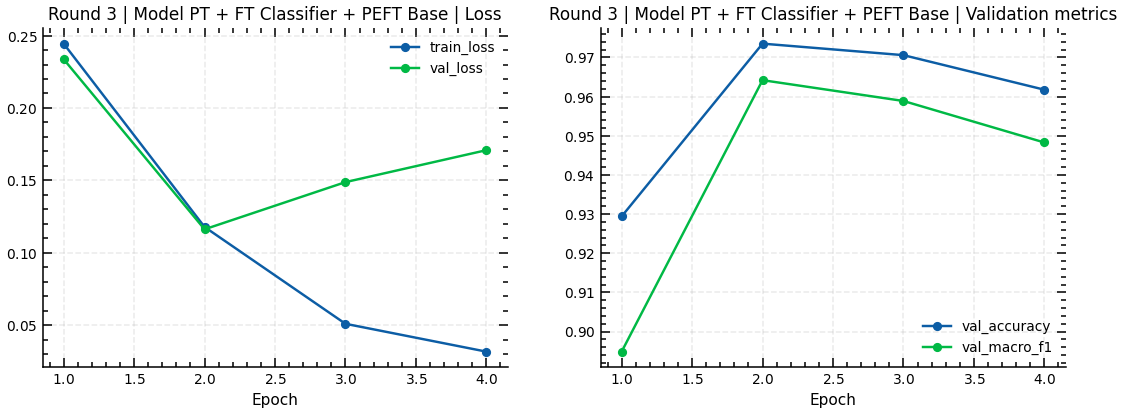

Round 3 | Model 5 | validation metrics: {'accuracy': 0.9735294117647059, 'macro_precision': 0.9595441595441597, 'macro_recall': 0.9694587655419968, 'macro_f1': 0.9642005201327235, 'weighted_f1': 0.9738142714713004, 'loss': 0.11615848922554184}
Round 3 | Model 5 | test metrics      : {'accuracy': 0.961764705882353, 'macro_precision': 0.9459706959706958, 'macro_recall': 0.9540033529534137, 'macro_f1': 0.9498329071855194, 'weighted_f1': 0.9618249824753805, 'loss': 0.11377426999456743}


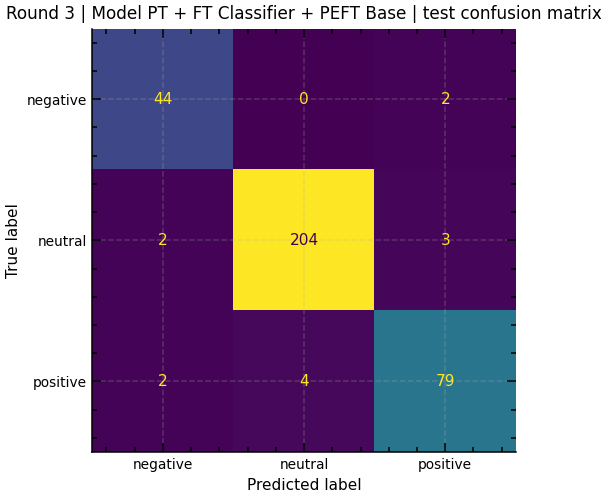

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
113,Finnish power supply solutions and systems provider Efore Oyj said its net loss widened to 3.2 mln euro $ 4.2 mln fo...,negative,positive,0.999057,0.000559,0.000384,0.999057
275,"Operating loss was EUR 179mn , compared to a loss of EUR 188mn in the second quarter of 2009 .",positive,negative,0.989411,0.989411,0.000242,0.010348
175,"In a letter to Economic Affairs Minister , the listed Estonian shipping company Tallink asks for the approval to be ...",neutral,positive,0.967764,0.011015,0.021221,0.967764
263,"These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has suff...",positive,neutral,0.931924,0.000002,0.931924,0.068074
159,Viking Line manages well with its current ferries .,positive,neutral,0.898014,0.000564,0.898014,0.101422
320,"In the third quarter of fiscal 2008 Efore swung to a net loss of EUR 400,000 versus a net profit of EUR 200,000 for ...",negative,positive,0.839801,0.160137,0.000062,0.839801
299,Atria said its offer would give the Swedish company continued ownership and control of its slaughtering and cutting ...,neutral,positive,0.830167,0.000301,0.169533,0.830167
99,No changes in media activity were seen in October compared with September .,neutral,negative,0.788370,0.788370,0.050785,0.160845


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
326,"According to CEO Matti Perkonoja of the parent company HKScan , the company 's performance in the first quarter of 2...",negative,negative,0.507064,0.507064,0.014615,0.478321
21,Ruukki 's order book at the end of 2010 was 30 % up year-on-year and 10 % up quarter-on-quarter .,positive,neutral,0.522340,0.004918,0.522340,0.472742
120,"Protalix closed at $ 10.71 on Friday on the American Stock Exchange , giving a market cap of $ 827 million .",neutral,negative,0.530920,0.530920,0.468631,0.000449
214,Increase in the number of shares is based on the option rights which were granted to the management of the company u...,neutral,neutral,0.548328,0.000029,0.548328,0.451643
33,"Previously , the company expected its 2008 financial performance to remain at the same level as in 2008 .",neutral,neutral,0.608654,0.008740,0.608654,0.382605
240,Production capacity will increase from 36 000 to 85 000 tonnes per year and the raw material will continue to be rec...,positive,positive,0.622389,0.000052,0.377559,0.622389
235,Finnish silicon wafer technology company Okmetic Oyj OMX Helsinki : OKM1V said on Wednesday 17 September that it wil...,neutral,positive,0.630699,0.000245,0.369057,0.630699
167,These moderate but significant changes resulted in a significant 24-32 % reduction in the estimated CVD risk .,positive,negative,0.657035,0.657035,0.002435,0.340530


Improved cases vs round 2


,sentence,gold_label,old_pred,new_pred,old_conf,new_conf,old_correct,new_correct,confidence_delta
33,"Previously , the company expected its 2008 financial performance to remain at the same level as in 2008 .",neutral,positive,neutral,0.471176,0.608654,False,True,0.137479
214,Increase in the number of shares is based on the option rights which were granted to the management of the company u...,neutral,positive,neutral,0.747630,0.548328,False,True,-0.199302


Regressed cases vs round 2


,sentence,gold_label,old_pred,new_pred,old_conf,new_conf,old_correct,new_correct,confidence_delta
235,Finnish silicon wafer technology company Okmetic Oyj OMX Helsinki : OKM1V said on Wednesday 17 September that it wil...,neutral,neutral,positive,0.558108,0.630699,True,False,0.072591
21,Ruukki 's order book at the end of 2010 was 30 % up year-on-year and 10 % up quarter-on-quarter .,positive,positive,neutral,0.771903,0.522340,True,False,-0.249563


Correctness shift table (round 2 -> round 3)


,new_correct,new_wrong
old_correct,325,2
old_wrong,2,11


Deep dive: Round 3 | Model PT + FT Classifier + PEFT Base
loss=0.1138 | accuracy=0.9618 | macro_f1=0.9498 | weighted_f1=0.9618
vs reference -> Δaccuracy=+0.0000, Δmacro_f1=-0.0002, Δloss=-0.0038

Class-wise report:


,precision,recall,f1-score,support
negative,0.9167,0.9565,0.9362,46.0
neutral,0.9808,0.9761,0.9784,209.0
positive,0.9405,0.9294,0.9349,85.0


Weakest class right now: positive
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='positive' predicted='neutral' (count=4)
Number of wrong predictions: 13 / 340
Median confidence on wrong predictions: 0.8302
Interpretation: many mistakes are high-confidence -> features may be systematically misleading, not just noisy.
Approx. last-epoch generalization gap (val_loss - train_loss): +0.1392
Interpretation: train/validation losses are in a relatively healthy range.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [71]:

model5_r3 = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=ROUND3_CFG["seed"])
model5_r3.load_state_dict(best_model2_r3_state)

freeze_everything(model5_r3)
round3_lora_targets = insert_lora_into_ffn(
    model5_r3,
    rank=ROUND3_CFG["model5"]["rank"],
    alpha=ROUND3_CFG["model5"]["alpha"],
    dropout=ROUND3_CFG["model5"]["dropout"],
)
assert len(round3_lora_targets) == 12, f"Expected 12 FFN linear targets in DistilBERT, got {len(round3_lora_targets)}"

round3_lora_breakdown = expected_lora_parameter_breakdown(model5_r3)
expected_round3_lora_params = int(round3_lora_breakdown["expected_params"].sum())
actual_round3_lora_params = int(round3_lora_breakdown["actual_params"].sum())
_, round3_trainable_params = count_parameters(model5_r3)

print("Round-3 LoRA parameter breakdown")
display(round3_lora_breakdown)
print(f"Expected trainable LoRA params (formula): {expected_round3_lora_params:,}")
print(f"Actual   trainable LoRA params (A/B only): {actual_round3_lora_params:,}")
print(f"Model-reported trainable params         : {round3_trainable_params:,}")

assert expected_round3_lora_params == 368640, "For DistilBERT default FFN dims and rank=8, expected LoRA param count should stay 368,640."
assert actual_round3_lora_params == expected_round3_lora_params == round3_trainable_params

show_parameter_summary(model5_r3, "Round 3 | Model PT + FT Classifier + PEFT Base | trainable parameters", only_trainable=True)

round3_model5_class_weights = (
    build_class_weights_tensor(split_frames["train"], mode=ROUND3_CFG["model5"]["class_weight_mode"])
    if ROUND3_CFG["model5"]["use_class_weights"]
    else None
)

print("Round-3 LoRA setup")
print(f"epochs          : {ROUND3_CFG['model5']['epochs']}")
print(f"lr              : {ROUND3_CFG['model5']['lr']:.2e}")
print(f"rank            : {ROUND3_CFG['model5']['rank']}")
print(f"alpha           : {ROUND3_CFG['model5']['alpha']}")
print(f"dropout         : {ROUND3_CFG['model5']['dropout']}")
print(f"class_weights   : {round3_model5_class_weights}")
print(f"label_smoothing : {ROUND3_CFG['model5']['label_smoothing']}")

model5_r3, model5_r3_history, model5_r3_best_val = fit_model_round3(
    model5_r3,
    train_loader_r3,
    val_loader_r3,
    split_frames["train"],
    split_frames["validation"],
    epochs=ROUND3_CFG["model5"]["epochs"],
    lr=ROUND3_CFG["model5"]["lr"],
    weight_decay=ROUND3_CFG["weight_decay"],
    warmup_ratio=ROUND3_CFG["warmup_ratio"],
    clip_grad_norm=ROUND3_CFG["clip_grad_norm"],
    class_weights=round3_model5_class_weights,
    label_smoothing=ROUND3_CFG["model5"]["label_smoothing"],
    early_stopping_patience=ROUND3_CFG["early_stopping_patience"],
    min_epochs_before_stop=ROUND3_CFG["min_epochs_before_stop"],
    model_name="Round3 Model5",
)

model5_r3_val = evaluate_model(model5_r3, val_loader_r3, split_frames["validation"])
model5_r3_test = evaluate_model(model5_r3, test_loader_r3, split_frames["test"])

plot_history(model5_r3_history, "Round 3 | Model PT + FT Classifier + PEFT Base")
print("Round 3 | Model 5 | validation metrics:", model5_r3_val["metrics"])
print("Round 3 | Model 5 | test metrics      :", model5_r3_test["metrics"])

plot_confusion(model5_r3_test, "Round 3 | Model PT + FT Classifier + PEFT Base | test confusion matrix")
display(show_top_errors(model5_r3_test, n=8))
display(show_low_confidence_cases(model5_r3_test, n=8))
print("Improved cases vs round 2")
display(prediction_change_table(ROUND2_TEST_EVALS["Model PT + FT Classifier + PEFT Base"], model5_r3_test, mode="improved", n=8))
print("Regressed cases vs round 2")
display(prediction_change_table(ROUND2_TEST_EVALS["Model PT + FT Classifier + PEFT Base"], model5_r3_test, mode="regressed", n=8))
print("Correctness shift table (round 2 -> round 3)")
display(correctness_shift_table(ROUND2_TEST_EVALS["Model PT + FT Classifier + PEFT Base"], model5_r3_test))

deep_dive_report(
    "Round 3 | Model PT + FT Classifier + PEFT Base",
    model5_r3_test,
    history_df=model5_r3_history,
    reference_eval=ROUND2_TEST_EVALS["Model PT + FT Classifier + PEFT Base"],
)

register_result(
    ROUND3_RESULTS,
    "Model PT + FT Classifier + PEFT Base",
    model5_r3,
    model5_r3_val,
    model5_r3_test,
    notes="Round-3 hand-written LoRA on FFN lin1/lin2 only; rank fixed at 8; tuned alpha/dropout/lr/epochs",
)
ROUND3_HISTORIES["Model PT + FT Classifier + PEFT Base"] = model5_r3_history
ROUND3_VAL_EVALS["Model PT + FT Classifier + PEFT Base"] = model5_r3_val
ROUND3_TEST_EVALS["Model PT + FT Classifier + PEFT Base"] = model5_r3_test

model5_r3.to("cpu")
cleanup()


### Reading Round-3 Model 5

Model 5 sits at a distinctive operating point. It uses a very small trainable subspace (368,640 parameters, 0.55% of the total) yet has reached performance comparable to full body fine-tuning. If that comparability holds in Round 3, the practical implications are real: fewer parameters to store and synchronise, fine-tuned variants that are cheaper to maintain, and version control over fine-tuned changes that's straightforward.


## External benchmarks — finance-domain pretrained models

Two external models are used to give the DistilBERT mainline some context.

The primary external benchmark is `yiyanghkust/finbert-tone`, a BERT-base classifier pretrained on a financial corpus and fine-tuned for tone/sentiment, available off-the-shelf. It's an appropriate comparison point because it differs from the assignment-specified DistilBERT mainly in pretraining corpus and tokenizer rather than in task formulation.

The bonus external benchmark is `ProsusAI/finbert`. Its model card notes that its sentiment fine-tuning used Financial PhraseBank, which means evaluating it on the same data isn't a clean held-out test. So it's not appropriate as an unbiased external baseline. It's reported only as a bonus reference, with the caveat made explicit in the table.


External | FinBERT-tone (primary)
Primary external benchmark: financial-domain sentiment model evaluated as-is (no extra FT in this notebook).
Skipping yiyanghkust/finbert-tone because loading/evaluation failed:
ValueError("Couldn't instantiate the backend tokenizer from one of: \n(1) a `tokenizers` library serialization file, \n(2) a slow tokenizer instance to convert or \n(3) an equivalent slow tokenizer class to instantiate and convert. \nYou need to have sentencepiece or tiktoken installed to convert a slow tokenizer to a fast one.")
External | ProsusAI/finbert (bonus, caveat)
Bonus only. Caveat: the model card states it was fine-tuned using Financial PhraseBank, so this is not a fully clean external benchmark.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Label mapping used for evaluation:


,external_id,external_label,normalized_label,our_id,our_label
0,0,positive,positive,2,positive
1,1,negative,negative,0,negative
2,2,neutral,neutral,1,neutral


Validation metrics: {'accuracy': 0.9558823529411765, 'macro_precision': 0.9305254016500216, 'macro_recall': 0.9657018986272353, 'macro_f1': 0.9466489652843285, 'weighted_f1': 0.9565205480578144, 'loss': 0.1425047218799591}
Test metrics      : {'accuracy': 0.9794117647058823, 'macro_precision': 0.9640151515151515, 'macro_recall': 0.9808575729022627, 'macro_f1': 0.9721461789587753, 'weighted_f1': 0.9795754101435875, 'loss': 0.12653258442878723}


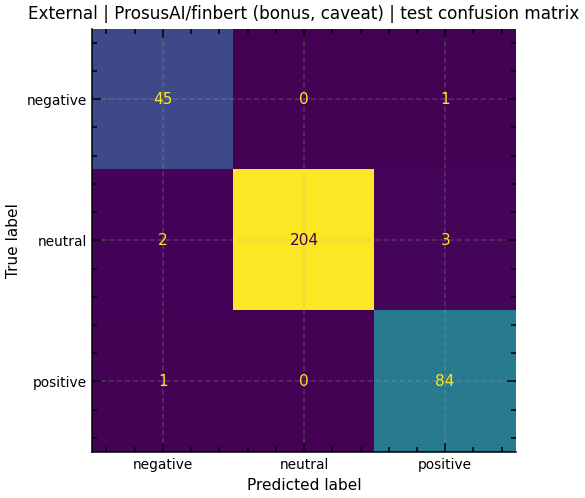

,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
275,"Operating loss was EUR 179mn , compared to a loss of EUR 188mn in the second quarter of 2009 .",positive,negative,0.971536,0.971536,0.009002,0.019461
10,"The company reported a profit of 800,000 euro ($ 1.2 mln)on the sale of its Varesvuo Partners sub-group and a loss o...",neutral,negative,0.956945,0.956945,0.031833,0.011223
113,Finnish power supply solutions and systems provider Efore Oyj said its net loss widened to 3.2 mln euro $ 4.2 mln fo...,negative,positive,0.934390,0.045749,0.019861,0.934390
175,"In a letter to Economic Affairs Minister , the listed Estonian shipping company Tallink asks for the approval to be ...",neutral,positive,0.807101,0.101064,0.091835,0.807101
267,Fortum expects its annual capital expenditure in the next four to five years to be within a range of EUR 0.8-1 .2 bi...,neutral,positive,0.800634,0.009008,0.190358,0.800634
33,"Previously , the company expected its 2008 financial performance to remain at the same level as in 2008 .",neutral,positive,0.736785,0.157338,0.105877,0.736785
99,No changes in media activity were seen in October compared with September .,neutral,negative,0.694287,0.694287,0.275435,0.030277


,sentence,gold_label,pred_label,confidence,p_negative,p_neutral,p_positive
306,"In 2010 , Sanoma Magazines expects net sales to be at the 2009 level .",neutral,neutral,0.615901,0.013418,0.615901,0.370681
160,Motorola Inc. of the United States came second with shipments of 217.4 million units for a 21.3 percent market share...,neutral,neutral,0.637389,0.044999,0.637389,0.317613
75,"SRV will also build an aqua park with wellness area , a restaurant and a multifunctional ice arena .",neutral,neutral,0.663793,0.008079,0.663793,0.328127
208,"Fiskars , a 360-year-old global business best known for its orange-handled scissors , expects to derive synergies of...",positive,positive,0.686459,0.007544,0.305997,0.686459
88,The company says the measures are no longer needed .,neutral,neutral,0.690297,0.275195,0.690297,0.034508
99,No changes in media activity were seen in October compared with September .,neutral,negative,0.694287,0.694287,0.275435,0.030277
290,"Cardona slowed her vehicle , turned around and returned to the intersection , where she called 911 .",neutral,neutral,0.696176,0.234920,0.696176,0.068904
33,"Previously , the company expected its 2008 financial performance to remain at the same level as in 2008 .",neutral,positive,0.736785,0.157338,0.105877,0.736785


Deep dive: External | ProsusAI/finbert (bonus, caveat)
loss=0.1265 | accuracy=0.9794 | macro_f1=0.9721 | weighted_f1=0.9796

Class-wise report:


,precision,recall,f1-score,support
negative,0.9375,0.9783,0.9574,46.0
neutral,1.0000,0.9761,0.9879,209.0
positive,0.9545,0.9882,0.9711,85.0


Weakest class right now: negative
Strongest class right now: neutral
Interpretation: accuracy and macro F1 are relatively close -> class performance is more balanced.
Most frequent confusion: true='neutral' predicted='positive' (count=3)
Number of wrong predictions: 7 / 340
Median confidence on wrong predictions: 0.8071
Interpretation: many mistakes are high-confidence -> features may be systematically misleading, not just noisy.

Suggested next-step questions:
- Is the weakest class weak because the representation is poor, or because the decision boundary is too simple?
- Are the wrong examples semantically ambiguous, or are they clearly finance-specific patterns that the model misses?
- If this model underfits, should the next iteration add capacity? If it overfits, should the next iteration regularize or reduce capacity?


In [72]:

EXTERNAL_RESULTS = []
EXTERNAL_TEST_EVALS = {}

external_specs = [
    {
        "benchmark": "External | FinBERT-tone (primary)",
        "model_name": ROUND3_CFG["external_model_name"],
        "notes": "Primary external benchmark: financial-domain sentiment model evaluated as-is (no extra FT in this notebook).",
    }
]

if ROUND3_CFG["run_bonus_external_model"]:
    external_specs.append(
        {
            "benchmark": "External | ProsusAI/finbert (bonus, caveat)",
            "model_name": ROUND3_CFG["bonus_external_model_name"],
            "notes": "Bonus only. Caveat: the model card states it was fine-tuned using Financial PhraseBank, so this is not a fully clean external benchmark.",
        }
    )

for spec in external_specs:
    print("=" * 100)
    print(spec["benchmark"])
    print("=" * 100)
    print(spec["notes"])

    try:
        tokenizer_ext = AutoTokenizer.from_pretrained(spec["model_name"])
        model_ext = AutoModelForSequenceClassification.from_pretrained(spec["model_name"])

        ext_val_eval, ext_mapping_df, model_ext, tokenizer_ext = evaluate_external_classifier(
            spec["model_name"],
            split_frames["validation"],
            batch_size=ROUND3_CFG["eval_batch_size"],
            model=model_ext,
            tokenizer=tokenizer_ext,
        )
        ext_test_eval, _, model_ext, tokenizer_ext = evaluate_external_classifier(
            spec["model_name"],
            split_frames["test"],
            batch_size=ROUND3_CFG["eval_batch_size"],
            model=model_ext,
            tokenizer=tokenizer_ext,
        )

        print("Label mapping used for evaluation:")
        display(ext_mapping_df)

        print("Validation metrics:", ext_val_eval["metrics"])
        print("Test metrics      :", ext_test_eval["metrics"])

        plot_confusion(ext_test_eval, f"{spec['benchmark']} | test confusion matrix")
        display(show_top_errors(ext_test_eval, n=8))
        display(show_low_confidence_cases(ext_test_eval, n=8))
        deep_dive_report(spec["benchmark"], ext_test_eval)

        register_external_result(
            EXTERNAL_RESULTS,
            spec["benchmark"],
            spec["model_name"],
            model_ext,
            ext_val_eval,
            ext_test_eval,
            notes=spec["notes"],
        )
        EXTERNAL_TEST_EVALS[spec["benchmark"]] = ext_test_eval

        model_ext.to("cpu")
        cleanup()

    except Exception as e:
        print(f"Skipping {spec['model_name']} because loading/evaluation failed:")
        print(repr(e))


## Round 3 — consolidated results, significance check, external comparison

The Round 3 reporting block aggregates per-class metrics for every model, confusion summaries for every model, parameter efficiency (trainable parameters and trainable percentage) for every model, Round 2 → Round 3 improvement and regression cases on a per-prediction basis, paired-bootstrap confidence intervals for every Round 3 vs Round 2 macro-F1 delta, and the comparison against the external finance-domain benchmarks introduced above.


,model,notes,total_params,trainable_params,trainable_pct,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,test_loss
0,Model PT + FT Classifier + PEFT Base,Round-3 hand-written LoRA on FFN lin1/lin2 only; rank fixed at 8; tuned alpha/dropout/lr/epochs,67324419,368640,0.005476,0.973529,0.964201,0.961765,0.949833,0.113774
1,Model PT + FT Classifier + FT Base,"Round-3 body-only FT from round-3 Model 2, with layer-wise lr decay and mild regularization",66955779,66362880,0.991145,0.961765,0.950442,0.958824,0.947416,0.194447
2,Model PT + Own FT Classifier,Round-3 custom head: hybrid pooling (CLS + masked mean) + wider MLP + LayerNorm,67251971,889091,0.013220,0.888235,0.825867,0.879412,0.833913,0.309981
3,Model PT + FT Classifier,"Round-3 head-only FT with lighter lr, mild smoothing, and optional class weights only if class gap still persists",66955779,592899,0.008855,0.847059,0.761172,0.852941,0.780633,0.366993
4,Model PT,Round-3 anchor model; no financial FT; max_length=80,66955779,66955779,1.000000,0.361765,0.342532,0.320588,0.300883,1.103060


Round 2 -> Round 3 comparison


,model,notes_r2,total_params_r2,trainable_params_r2,trainable_pct_r2,val_accuracy_r2,val_macro_f1_r2,test_accuracy_r2,test_macro_f1_r2,test_loss_r2,...,val_accuracy_r3,val_macro_f1_r3,test_accuracy_r3,test_macro_f1_r3,test_loss_r3,delta_val_accuracy,delta_val_macro_f1,delta_test_accuracy,delta_test_macro_f1,delta_test_loss
0,Model PT + Own FT Classifier,Round-2 custom head: GELU + optional LayerNorm + evidence-driven width/dropout,66708867,345987,0.005187,0.861765,0.780287,0.867647,0.802020,0.339745,...,0.888235,0.825867,0.879412,0.833913,0.309981,0.026471,0.045580,0.011765,0.031892,-0.029764
1,Model PT + FT Classifier,Round-2 head-only FT with evidence-driven epoch/lr + optional weighted CE + optional label smoothing,66955779,592899,0.008855,0.855882,0.766373,0.838235,0.756840,0.368321,...,0.847059,0.761172,0.852941,0.780633,0.366993,-0.008824,-0.005202,0.014706,0.023793,-0.001328
2,Model PT,Round 2 anchor model; no financial FT; max_length=80,66955779,66955779,1.000000,0.361765,0.342532,0.320588,0.300883,1.103060,...,0.361765,0.342532,0.320588,0.300883,1.103060,0.000000,0.000000,0.000000,0.000000,0.000000
3,Model PT + FT Classifier + PEFT Base,Round-2 hand-written LoRA on FFN lin1/lin2 only; rank fixed at 8; tuned alpha/lr/dropout/epochs,67324419,368640,0.005476,0.970588,0.958886,0.961765,0.950052,0.117589,...,0.973529,0.964201,0.961765,0.949833,0.113774,0.002941,0.005314,0.000000,-0.000219,-0.003815
4,Model PT + FT Classifier + FT Base,Round-2 body-only FT from round-2 Model 2 with tuned epochs/lr and optional weighted CE/smoothing,66955779,66362880,0.991145,0.973529,0.961139,0.961765,0.948602,0.112450,...,0.961765,0.950442,0.958824,0.947416,0.194447,-0.011765,-0.010697,-0.002941,-0.001186,0.081997


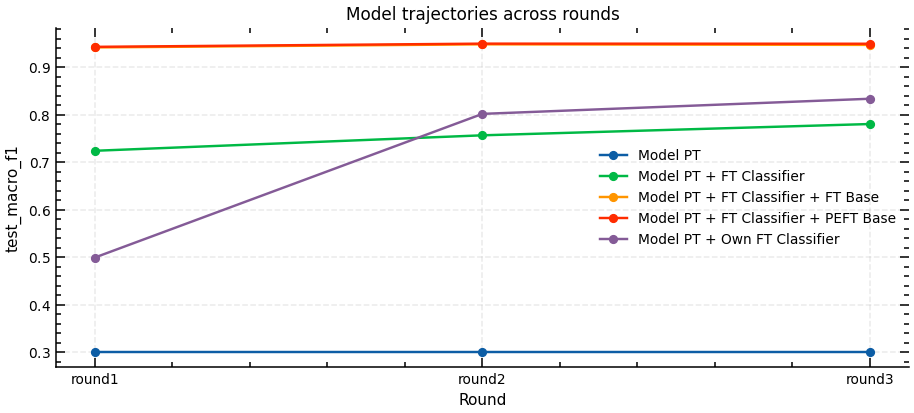

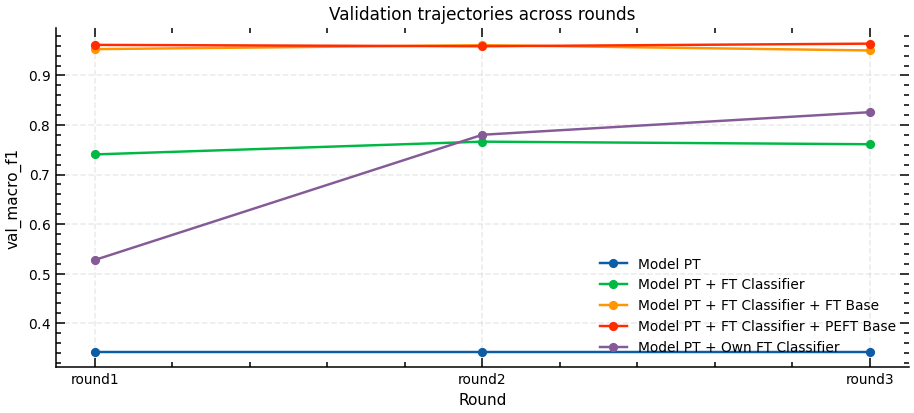

,round,split,model,label,precision,recall,f1,support
0,round3,test,Model PT,negative,0.0746,0.2174,0.1111,46
1,round3,test,Model PT,neutral,0.8710,0.2584,0.3985,209
2,round3,test,Model PT,positive,0.3125,0.5294,0.3930,85
3,round3,test,Model PT + FT Classifier,negative,0.7297,0.5870,0.6506,46
4,round3,test,Model PT + FT Classifier,neutral,0.9463,0.9282,0.9372,209
5,round3,test,Model PT + FT Classifier,positive,0.7041,0.8118,0.7541,85
6,round3,test,Model PT + Own FT Classifier,negative,0.7955,0.7609,0.7778,46
7,round3,test,Model PT + Own FT Classifier,neutral,0.9381,0.9426,0.9403,209
8,round3,test,Model PT + Own FT Classifier,positive,0.7791,0.7882,0.7836,85
9,round3,test,Model PT + FT Classifier + FT Base,negative,0.9167,0.9565,0.9362,46


,round,split,model,dominant_true_label,dominant_pred_label,dominant_confusion_count
0,round3,test,Model PT,neutral,negative,91
1,round3,test,Model PT + FT Classifier,negative,positive,17
2,round3,test,Model PT + Own FT Classifier,positive,neutral,12
3,round3,test,Model PT + FT Classifier + FT Base,neutral,positive,5
4,round3,test,Model PT + FT Classifier + PEFT Base,positive,neutral,4


,round,model,trainable_params,trainable_pct,test_macro_f1,macro_f1_per_1M_trainable
0,round3,Model PT + FT Classifier + PEFT Base,368640,0.0055,0.9498,2.5766
1,round3,Model PT + FT Classifier + FT Base,66362880,0.9911,0.9474,0.0143
2,round3,Model PT + Own FT Classifier,889091,0.0132,0.8339,0.9379
3,round3,Model PT + FT Classifier,592899,0.0089,0.7806,1.3166
4,round3,Model PT,66955779,1.0000,0.3009,0.0045


Paired bootstrap summary: round 2 -> round 3


,model,macro_f1_mean_diff,macro_f1_ci_low,macro_f1_ci_high,macro_f1_p_nonpositive,macro_f1_clearly_positive,accuracy_mean_diff,accuracy_ci_low,accuracy_ci_high,accuracy_p_nonpositive,accuracy_clearly_positive
0,Model PT + Own FT Classifier,0.0323,-0.0036,0.0717,0.0410,False,0.0117,-0.0118,0.0354,0.2025,False
1,Model PT + FT Classifier,0.0236,-0.0064,0.0568,0.0670,False,0.0149,-0.0059,0.0353,0.1015,False
2,Model PT + FT Classifier + PEFT Base,-0.0001,-0.0112,0.0107,0.5980,False,0.0001,-0.0118,0.0118,0.6025,False
3,Model PT + FT Classifier + FT Base,-0.0012,-0.0116,0.0108,0.6315,False,-0.0028,-0.0147,0.0059,0.8055,False


External benchmark comparison


,benchmark,hf_model_name,notes,total_params,trainable_params,trainable_pct,val_accuracy,val_macro_f1,test_accuracy,test_macro_f1,test_loss,delta_vs_best_distilbert_r3_test_macro_f1
0,"External | ProsusAI/finbert (bonus, caveat)",ProsusAI/finbert,"Bonus only. Caveat: the model card states it was fine-tuned using Financial PhraseBank, so this is not a fully clean...",109484547,0,0.0,0.9559,0.9466,0.9794,0.9721,0.1265,0.0223


Saved CSV files:
- round3_results.csv
- round2_round3_comparison.csv
- round1_round2_round3_long_results.csv
- round3_test_classwise_metrics.csv
- round3_test_confusion_summary.csv
- round3_significance_bootstrap.csv
- external_model_comparison.csv


In [73]:

round3_results_df = pd.DataFrame(ROUND3_RESULTS).sort_values("val_macro_f1", ascending=False).reset_index(drop=True)
display(round3_results_df)

round23_comparison_df = ROUND2_RESULTS_DF.merge(
    round3_results_df,
    on="model",
    suffixes=("_r2", "_r3"),
)
for metric in ["val_accuracy", "val_macro_f1", "test_accuracy", "test_macro_f1", "test_loss"]:
    round23_comparison_df[f"delta_{metric}"] = round23_comparison_df[f"{metric}_r3"] - round23_comparison_df[f"{metric}_r2"]

print("Round 2 -> Round 3 comparison")
display(round23_comparison_df.sort_values("delta_test_macro_f1", ascending=False).reset_index(drop=True))

round123_results_long = pd.concat([
    ROUND1_RESULTS_DF.assign(round="round1"),
    ROUND2_RESULTS_DF.assign(round="round2"),
    round3_results_df.assign(round="round3"),
], ignore_index=True)

round123_results_long["round_num"] = round123_results_long["round"].map({"round1": 1, "round2": 2, "round3": 3})

plt.figure(figsize=(10, 4))
for model_name, g in round123_results_long.groupby("model"):
    g = g.sort_values("round_num")
    plt.plot(g["round_num"], g["test_macro_f1"], marker="o", label=model_name)
plt.xticks([1, 2, 3], ["round1", "round2", "round3"])
plt.xlabel("Round")
plt.ylabel("test_macro_f1")
plt.title("Model trajectories across rounds")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
for model_name, g in round123_results_long.groupby("model"):
    g = g.sort_values("round_num")
    plt.plot(g["round_num"], g["val_macro_f1"], marker="o", label=model_name)
plt.xticks([1, 2, 3], ["round1", "round2", "round3"])
plt.xlabel("Round")
plt.ylabel("val_macro_f1")
plt.title("Validation trajectories across rounds")
plt.legend()
plt.show()

round3_test_classwise_df = extract_classwise_table(ROUND3_TEST_EVALS, "round3", "test")
round3_test_confusion_summary_df = summarize_dominant_confusions(ROUND3_TEST_EVALS, "round3", "test")
round3_param_eff_df = parameter_efficiency_table(round3_results_df, "round3")
display(round3_test_classwise_df.round(4))
display(round3_test_confusion_summary_df)
display(round3_param_eff_df.round(4))

round3_significance_rows = []
for model_name in round3_results_df["model"].tolist():
    if model_name == "Model PT":
        continue
    macro_boot = bootstrap_metric_diff(
        ROUND2_TEST_EVALS[model_name],
        ROUND3_TEST_EVALS[model_name],
        metric="macro_f1",
        n_boot=ROUND3_CFG["bootstrap_iterations"],
        seed=ROUND3_CFG["seed"],
    )
    acc_boot = bootstrap_metric_diff(
        ROUND2_TEST_EVALS[model_name],
        ROUND3_TEST_EVALS[model_name],
        metric="accuracy",
        n_boot=ROUND3_CFG["bootstrap_iterations"],
        seed=ROUND3_CFG["seed"] + 7,
    )
    round3_significance_rows.append({
        "model": model_name,
        "macro_f1_mean_diff": macro_boot["mean_diff"],
        "macro_f1_ci_low": macro_boot["ci_low"],
        "macro_f1_ci_high": macro_boot["ci_high"],
        "macro_f1_p_nonpositive": macro_boot["p_nonpositive"],
        "macro_f1_clearly_positive": bool(macro_boot["ci_low"] > 0),
        "accuracy_mean_diff": acc_boot["mean_diff"],
        "accuracy_ci_low": acc_boot["ci_low"],
        "accuracy_ci_high": acc_boot["ci_high"],
        "accuracy_p_nonpositive": acc_boot["p_nonpositive"],
        "accuracy_clearly_positive": bool(acc_boot["ci_low"] > 0),
    })

round3_significance_df = pd.DataFrame(round3_significance_rows).sort_values("macro_f1_mean_diff", ascending=False).reset_index(drop=True)
print("Paired bootstrap summary: round 2 -> round 3")
display(round3_significance_df.round(4))

if EXTERNAL_RESULTS:
    external_results_df = pd.DataFrame(EXTERNAL_RESULTS).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
    best_distilbert_r3 = round3_results_df.sort_values("test_macro_f1", ascending=False).iloc[0]
    external_results_df["delta_vs_best_distilbert_r3_test_macro_f1"] = external_results_df["test_macro_f1"] - best_distilbert_r3["test_macro_f1"]

    print("External benchmark comparison")
    display(external_results_df.round(4))
else:
    external_results_df = pd.DataFrame()

round3_results_df.to_csv("round3_results.csv", index=False)
round23_comparison_df.to_csv("round2_round3_comparison.csv", index=False)
round123_results_long.to_csv("round1_round2_round3_long_results.csv", index=False)
round3_test_classwise_df.to_csv("round3_test_classwise_metrics.csv", index=False)
round3_test_confusion_summary_df.to_csv("round3_test_confusion_summary.csv", index=False)
round3_significance_df.to_csv("round3_significance_bootstrap.csv", index=False)
if len(external_results_df) > 0:
    external_results_df.to_csv("external_model_comparison.csv", index=False)

print("Saved CSV files:")
for fn in [
    "round3_results.csv",
    "round2_round3_comparison.csv",
    "round1_round2_round3_long_results.csv",
    "round3_test_classwise_metrics.csv",
    "round3_test_confusion_summary.csv",
    "round3_significance_bootstrap.csv",
]:
    print("-", fn)
if len(external_results_df) > 0:
    print("-", "external_model_comparison.csv")


In [74]:

def round3_takeaways(round23_comparison_df, round3_results_df, round3_significance_df, external_results_df=None):
    print("=" * 100)
    print("Round-3 final takeaways")
    print("=" * 100)

    best_r3 = round3_results_df.sort_values("test_macro_f1", ascending=False).iloc[0]
    best_r2 = ROUND2_RESULTS_DF.sort_values("test_macro_f1", ascending=False).iloc[0]

    print(
        f"Best round-2 test model: {best_r2['model']} | "
        f"test_macro_f1={best_r2['test_macro_f1']:.4f} | "
        f"trainable_params={int(best_r2['trainable_params']):,}"
    )
    print(
        f"Best round-3 test model: {best_r3['model']} | "
        f"test_macro_f1={best_r3['test_macro_f1']:.4f} | "
        f"trainable_params={int(best_r3['trainable_params']):,}"
    )

    best_r3_vs_r2 = best_r3["test_macro_f1"] - best_r2["test_macro_f1"]
    print(f"\nBest-model macro-F1 delta (round 3 vs round 2): {best_r3_vs_r2:+.4f}")

    if best_r3_vs_r2 > 0.01:
        print("Interpretation: the third round found a practically noticeable improvement on this split.")
    elif best_r3_vs_r2 > 0.0:
        print("Interpretation: the third round is better, but the gain is modest; check the bootstrap interval before claiming a strong win.")
    else:
        print("Interpretation: the third round did not beat the best round-2 test result; the exercise still matters because it tells us where the ceiling is.")

    print("\nPer-model 'is the improvement obvious?' check:")
    for _, row in round3_significance_df.iterrows():
        status = "likely real on this split" if row["macro_f1_clearly_positive"] else "too small / too noisy to call clearly positive"
        print(
            f"- {row['model']}: Δmacro_f1≈{row['macro_f1_mean_diff']:+.4f} "
            f"[{row['macro_f1_ci_low']:+.4f}, {row['macro_f1_ci_high']:+.4f}] -> {status}"
        )

    best_eff = parameter_efficiency_table(round3_results_df, "round3").iloc[0]
    print(
        f"\nParameter-efficiency angle: "
        f"{best_eff['model']} has test_macro_f1={best_eff['test_macro_f1']:.4f} "
        f"with {int(best_eff['trainable_params']):,} trainable params."
    )

    if {"Model PT + FT Classifier + FT Base", "Model PT + FT Classifier + PEFT Base"}.issubset(set(round3_results_df["model"])):
        m4 = round3_results_df.set_index("model").loc["Model PT + FT Classifier + FT Base"]
        m5 = round3_results_df.set_index("model").loc["Model PT + FT Classifier + PEFT Base"]
        print(
            f"\nModel 5 vs Model 4 in round 3: "
            f"Δtest_macro_f1={m5['test_macro_f1'] - m4['test_macro_f1']:+.4f}, "
            f"trainable params ratio={m5['trainable_params'] / m4['trainable_params']:.4f}"
        )
        if abs(m5["test_macro_f1"] - m4["test_macro_f1"]) <= 0.01:
            print("Interpretation: PEFT is recovering most of the body-adaptation benefit with a much smaller trainable subspace.")
        elif m5["test_macro_f1"] > m4["test_macro_f1"]:
            print("Interpretation: PEFT is not only efficient here; it may also be regularizing the update direction usefully.")
        else:
            print("Interpretation: full body FT still has a small quality edge, but the cost/benefit trade-off depends on deployment constraints.")

    if external_results_df is not None and len(external_results_df) > 0:
        best_external = external_results_df.sort_values("test_macro_f1", ascending=False).iloc[0]
        print(
            f"\nBest external benchmark: {best_external['benchmark']} | "
            f"test_macro_f1={best_external['test_macro_f1']:.4f} | "
            f"Δvs best round-3 DistilBERT={best_external['delta_vs_best_distilbert_r3_test_macro_f1']:+.4f}"
        )
        if best_external["delta_vs_best_distilbert_r3_test_macro_f1"] > 0:
            print("Interpretation: domain-pretrained financial sentiment models still have an advantage on this task.")
        else:
            print("Interpretation: after careful adaptation, the DistilBERT mainline is competitive with or better than the external financial benchmark on this split.")

    print("\nWhat this means in actual applications:")
    print("- If you need the strongest raw score and can afford broader updates, Model 4 remains a strong default.")
    print("- If you care about smaller trainable state / easier adaptation management, Model 5 is often the more practical choice.")
    print("- If you are restricted to frozen-backbone setups, Model 3 shows how much smarter pooling and head design can help, but it also reveals the ceiling of head-only adaptation.")
    print("- Treat tiny gains near the top as 'stability and calibration' questions, not automatically as large substantive breakthroughs.")

round3_takeaways(round23_comparison_df, round3_results_df, round3_significance_df, external_results_df)


Round-3 final takeaways
Best round-2 test model: Model PT + FT Classifier + PEFT Base | test_macro_f1=0.9501 | trainable_params=368,640
Best round-3 test model: Model PT + FT Classifier + PEFT Base | test_macro_f1=0.9498 | trainable_params=368,640

Best-model macro-F1 delta (round 3 vs round 2): -0.0002
Interpretation: the third round did not beat the best round-2 test result; the exercise still matters because it tells us where the ceiling is.

Per-model 'is the improvement obvious?' check:
- Model PT + Own FT Classifier: Δmacro_f1≈+0.0323 [-0.0036, +0.0717] -> too small / too noisy to call clearly positive
- Model PT + FT Classifier: Δmacro_f1≈+0.0236 [-0.0064, +0.0568] -> too small / too noisy to call clearly positive
- Model PT + FT Classifier + PEFT Base: Δmacro_f1≈-0.0001 [-0.0112, +0.0107] -> too small / too noisy to call clearly positive
- Model PT + FT Classifier + FT Base: Δmacro_f1≈-0.0012 [-0.0116, +0.0108] -> too small / too noisy to call clearly positive

Parameter-effici

# Round 4 — beyond the assignment minimum

The first three rounds completed the assignment as specified: five fine-tuning regimes on `distilbert-base-uncased`, three iterations of evidence-driven adjustment, statistical sanity checks introduced in Round 3 with paired bootstrap intervals and an external benchmark against finance-domain models. By the end of Round 3 the strongest configurations sit at test macro-F1 around 0.95, and every paired-bootstrap confidence interval comparing Round 3 to Round 2 contains zero. Read literally, this means we cannot claim that Round 3 was statistically better than Round 2 on this single test split.

That observation is not a failure; it is a turning point. It tells us that further hyperparameter adjustment within this setup is unlikely to be measurable, and the more interesting question becomes structural rather than tuning: *what is this 0.95 ceiling actually made of, and what would it take to break it?* The remainder of the notebook is an attempt to answer that question with the discipline of an investigation rather than a leaderboard chase.

Round 4 is organised as four layers, each appended without modifying any of the original Round 1–3 cells (only a single whitespace fix in cell 10 markdown):

The **first layer** (§A–§F) is honest validation. It pins down the seed-level noise floor (§B), demonstrates that calibration can be improved without touching accuracy (§C), tries proper softmax-averaging ensembles with paired-bootstrap intervals (§D), runs an HF-Trainer parity check to confirm the custom training loop has no hidden bug (§E), and uses layer-wise linear probes plus a written-out LoRA merge to compare what each fine-tuning regime actually puts into the representation (§F).

The **second layer** (§G–§I) proposes an explanatory hypothesis for the 0.95 ceiling — that it arises from a backbone × tokenizer joint lock — and gathers three pieces of structural evidence: tokenizer fragmentation patterns (§G), a brief disagreement analysis with a finance-pretrained reference model (§H), and per-layer linear CKA between the three backbones (§I).

The **third layer** (§K, §L) tries to push the score by smarter aggregation alone — confidence-weighted averaging, stacking via a logistic meta-classifier, more seeds, MC-Dropout test-time augmentation, stochastic weight averaging, calibrated ensembles, and a 14-classifier mega ensemble. None of these change the picture: the ceiling sits where it sits.

The **fourth layer** (§M–§O, §Q–§R) is the most consequential. It tests the hypothesis from §G–§I two independent ways and finds it is not supported. A proper vocabulary-extension ablation in §M and a per-sentence Spearman correlation in §O both fail to find the predicted effect. A forensic analysis in §Q–§R then identifies the surviving cause with concrete per-sample evidence: the failures cluster on financial-discourse semantics that DistilBERT's general-domain pretraining never taught it, and they are recovered by a model that was pretrained on a finance corpus.

The result is a complete falsification cycle. We propose a hypothesis, test it twice, retract it, and replace it with one supported by the per-sample evidence. The score barely moves, but the understanding sharpens significantly.


## §B Multi-seed stability — establishing the noise floor

Round 3's training was conducted with seed=42 throughout. The paired-bootstrap intervals reported there capture variance from resampling the test set, but they do not capture variance from random initialisation and dataloader shuffling. Without that second source of variance, we cannot tell whether a delta of 0.001 between two configurations is a real shift or simply where the next seed would have landed. The purpose of this section is to put a number on it.

We retrain Models 2, 4, and 5 with three additional seeds — 37, 1337, and 2024 — keeping every other Round 3 setting fixed. The seed=42 run is reused from Round 3 to avoid wasted compute. With four seeds per model we obtain a sample standard deviation that, while not a precise estimate of population variance, is sufficient to bound the magnitude of seed-level noise. Model 3 is excluded because its frozen-backbone ceiling at 0.83 was already adequately characterised in Round 3 and has no bearing on the 0.95-region question we want to study.

The hypothesis being tested is straightforward: if Round 3's improvements over Round 2 are real, the deltas should be larger than the seed standard deviation; if they are noise, the deltas should sit comfortably inside it. Either outcome is informative.


In [75]:
# §B — Multi-seed training (Model 2 / 4 / 5 × 3 new seeds; seed=42 reused from R3)

ROUND4_SEEDS = [42, 37, 1337, 2024]
ROUND4_NEW_SEEDS = [s for s in ROUND4_SEEDS if s != ROUND3_CFG["seed"]]

ROUND4_SEED_EVALS = {
    "Model PT + FT Classifier": {},
    "Model PT + FT Classifier + FT Base": {},
    "Model PT + FT Classifier + PEFT Base": {},
}

# seed=42 直接复用 R3 训过的结果
for model_name in ROUND4_SEED_EVALS.keys():
    ROUND4_SEED_EVALS[model_name][ROUND3_CFG["seed"]] = {
        "val": ROUND3_VAL_EVALS[model_name],
        "test": ROUND3_TEST_EVALS[model_name],
    }

print(f"Reused seed={ROUND3_CFG['seed']} from R3 for {len(ROUND4_SEED_EVALS)} models.")
print(f"New seeds to train: {ROUND4_NEW_SEEDS}")

for seed in ROUND4_NEW_SEEDS:
    print("=" * 100)
    print(f"Round 4 | seed={seed}")
    print("=" * 100)
    try:
        # ----- Model 2: head only -----
        m2 = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=seed)
        freeze_all_but_default_head(m2)
        cw_m2 = (build_class_weights_tensor(split_frames["train"], mode=ROUND3_CFG["model2"]["class_weight_mode"])
                 if ROUND3_CFG["model2"]["use_class_weights"] else None)
        m2, _, _ = fit_model_round3(
            m2, train_loader_r3, val_loader_r3, split_frames["train"], split_frames["validation"],
            epochs=ROUND3_CFG["model2"]["epochs"], lr=ROUND3_CFG["model2"]["lr"],
            weight_decay=ROUND3_CFG["weight_decay"], warmup_ratio=ROUND3_CFG["warmup_ratio"],
            clip_grad_norm=ROUND3_CFG["clip_grad_norm"],
            class_weights=cw_m2, label_smoothing=ROUND3_CFG["model2"]["label_smoothing"],
            early_stopping_patience=ROUND3_CFG["early_stopping_patience"],
            min_epochs_before_stop=ROUND3_CFG["min_epochs_before_stop"],
            model_name=f"R4 M2 seed={seed}",
        )
        m2_state = copy.deepcopy(m2.state_dict())
        m2_val = evaluate_model(m2, val_loader_r3, split_frames["validation"])
        m2_test = evaluate_model(m2, test_loader_r3, split_frames["test"])
        ROUND4_SEED_EVALS["Model PT + FT Classifier"][seed] = {"val": m2_val, "test": m2_test}
        print(f"  M2 seed={seed}: val_F1={m2_val['metrics']['macro_f1']:.4f} test_F1={m2_test['metrics']['macro_f1']:.4f}")
        m2.to("cpu"); cleanup()

        # ----- Model 4: body FT with LLRD, init from M2 -----
        m4 = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=seed)
        m4.load_state_dict(m2_state)
        freeze_default_head_unfreeze_body(m4)
        m4_pg = build_distilbert_body_param_groups(
            m4, top_lr=ROUND3_CFG["model4"]["top_lr"],
            layer_decay=ROUND3_CFG["model4"]["layer_decay"],
            embeddings_scale=ROUND3_CFG["model4"]["embeddings_scale"],
        )
        m4, _, _ = fit_model_round3(
            m4, train_loader_r3, val_loader_r3, split_frames["train"], split_frames["validation"],
            epochs=ROUND3_CFG["model4"]["epochs"], lr=None, optimizer_param_groups=m4_pg,
            weight_decay=ROUND3_CFG["weight_decay"], warmup_ratio=ROUND3_CFG["warmup_ratio"],
            clip_grad_norm=ROUND3_CFG["clip_grad_norm"],
            class_weights=None, label_smoothing=ROUND3_CFG["model4"]["label_smoothing"],
            early_stopping_patience=ROUND3_CFG["early_stopping_patience"],
            min_epochs_before_stop=ROUND3_CFG["min_epochs_before_stop"],
            model_name=f"R4 M4 seed={seed}",
        )
        m4_val = evaluate_model(m4, val_loader_r3, split_frames["validation"])
        m4_test = evaluate_model(m4, test_loader_r3, split_frames["test"])
        ROUND4_SEED_EVALS["Model PT + FT Classifier + FT Base"][seed] = {"val": m4_val, "test": m4_test}
        print(f"  M4 seed={seed}: val_F1={m4_val['metrics']['macro_f1']:.4f} test_F1={m4_test['metrics']['macro_f1']:.4f}")
        m4.to("cpu"); cleanup()

        # ----- Model 5: LoRA on FFN, init from M2 -----
        m5 = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=seed)
        m5.load_state_dict(m2_state)
        freeze_everything(m5)
        insert_lora_into_ffn(m5, rank=ROUND3_CFG["model5"]["rank"],
                             alpha=ROUND3_CFG["model5"]["alpha"],
                             dropout=ROUND3_CFG["model5"]["dropout"])
        m5, _, _ = fit_model_round3(
            m5, train_loader_r3, val_loader_r3, split_frames["train"], split_frames["validation"],
            epochs=ROUND3_CFG["model5"]["epochs"], lr=ROUND3_CFG["model5"]["lr"],
            weight_decay=ROUND3_CFG["weight_decay"], warmup_ratio=ROUND3_CFG["warmup_ratio"],
            clip_grad_norm=ROUND3_CFG["clip_grad_norm"],
            class_weights=None, label_smoothing=ROUND3_CFG["model5"]["label_smoothing"],
            early_stopping_patience=ROUND3_CFG["early_stopping_patience"],
            min_epochs_before_stop=ROUND3_CFG["min_epochs_before_stop"],
            model_name=f"R4 M5 seed={seed}",
        )
        m5_val = evaluate_model(m5, val_loader_r3, split_frames["validation"])
        m5_test = evaluate_model(m5, test_loader_r3, split_frames["test"])
        ROUND4_SEED_EVALS["Model PT + FT Classifier + PEFT Base"][seed] = {"val": m5_val, "test": m5_test}
        print(f"  M5 seed={seed}: val_F1={m5_val['metrics']['macro_f1']:.4f} test_F1={m5_test['metrics']['macro_f1']:.4f}")
        m5.to("cpu"); cleanup()

    except Exception as e:
        print(f"  ! seed={seed} failed: {repr(e)} — skipping this seed and continuing")
        cleanup()

print("\nMulti-seed training complete.")


Reused seed=42 from R3 for 3 models.
New seeds to train: [37, 1337, 2024]
Round 4 | seed=37


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


R4 M2 seed=37 | round3 epoch 1/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7641 | val_loss=0.5223 | val_acc=0.7971 | val_macro_f1=0.6470


R4 M2 seed=37 | round3 epoch 2/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4905 | val_loss=0.4549 | val_acc=0.8088 | val_macro_f1=0.7092


R4 M2 seed=37 | round3 epoch 3/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4380 | val_loss=0.4291 | val_acc=0.8265 | val_macro_f1=0.7132


R4 M2 seed=37 | round3 epoch 4/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.3895 | val_loss=0.4166 | val_acc=0.8412 | val_macro_f1=0.7652


R4 M2 seed=37 | round3 epoch 5/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3710 | val_loss=0.3889 | val_acc=0.8441 | val_macro_f1=0.7487


R4 M2 seed=37 | round3 epoch 6/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.3614 | val_loss=0.3859 | val_acc=0.8588 | val_macro_f1=0.7690
  M2 seed=37: val_F1=0.7690 test_F1=0.7540


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


R4 M4 seed=37 | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2170 | val_loss=0.1552 | val_acc=0.9500 | val_macro_f1=0.9343


R4 M4 seed=37 | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.0726 | val_loss=0.1679 | val_acc=0.9559 | val_macro_f1=0.9453


R4 M4 seed=37 | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0295 | val_loss=0.1280 | val_acc=0.9647 | val_macro_f1=0.9499


R4 M4 seed=37 | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0178 | val_loss=0.1243 | val_acc=0.9735 | val_macro_f1=0.9642


R4 M4 seed=37 | round3 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0109 | val_loss=0.1268 | val_acc=0.9647 | val_macro_f1=0.9504
  M4 seed=37: val_F1=0.9642 test_F1=0.9373


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FFN target modules:
  distilbert.transformer.layer.0.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.0.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.1.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.1.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.2.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.2.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.3.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.3.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.4.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.4.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.5.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.5.ffn.lin2: 3072 -> 768


R4 M5 seed=37 | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2414 | val_loss=0.2117 | val_acc=0.9206 | val_macro_f1=0.8924


R4 M5 seed=37 | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.1174 | val_loss=0.1157 | val_acc=0.9618 | val_macro_f1=0.9498


R4 M5 seed=37 | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0562 | val_loss=0.0930 | val_acc=0.9794 | val_macro_f1=0.9694


R4 M5 seed=37 | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0259 | val_loss=0.1150 | val_acc=0.9647 | val_macro_f1=0.9452


R4 M5 seed=37 | round3 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0210 | val_loss=0.1286 | val_acc=0.9706 | val_macro_f1=0.9559
Early stopping triggered for R4 M5 seed=37 at epoch 5.
  M5 seed=37: val_F1=0.9694 test_F1=0.9373
Round 4 | seed=1337


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


R4 M2 seed=1337 | round3 epoch 1/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7704 | val_loss=0.5401 | val_acc=0.7765 | val_macro_f1=0.6608


R4 M2 seed=1337 | round3 epoch 2/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4964 | val_loss=0.4443 | val_acc=0.8206 | val_macro_f1=0.6741


R4 M2 seed=1337 | round3 epoch 3/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4281 | val_loss=0.4117 | val_acc=0.8412 | val_macro_f1=0.7451


R4 M2 seed=1337 | round3 epoch 4/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.3948 | val_loss=0.3972 | val_acc=0.8529 | val_macro_f1=0.7697


R4 M2 seed=1337 | round3 epoch 5/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3772 | val_loss=0.3859 | val_acc=0.8559 | val_macro_f1=0.7700


R4 M2 seed=1337 | round3 epoch 6/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.3674 | val_loss=0.3885 | val_acc=0.8529 | val_macro_f1=0.7609
  M2 seed=1337: val_F1=0.7700 test_F1=0.7824


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


R4 M4 seed=1337 | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2455 | val_loss=0.1654 | val_acc=0.9353 | val_macro_f1=0.9168


R4 M4 seed=1337 | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.0753 | val_loss=0.1277 | val_acc=0.9647 | val_macro_f1=0.9534


R4 M4 seed=1337 | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0247 | val_loss=0.1199 | val_acc=0.9735 | val_macro_f1=0.9642


R4 M4 seed=1337 | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0113 | val_loss=0.1533 | val_acc=0.9647 | val_macro_f1=0.9549


R4 M4 seed=1337 | round3 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0076 | val_loss=0.1494 | val_acc=0.9647 | val_macro_f1=0.9549
Early stopping triggered for R4 M4 seed=1337 at epoch 5.
  M4 seed=1337: val_F1=0.9642 test_F1=0.9469


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FFN target modules:
  distilbert.transformer.layer.0.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.0.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.1.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.1.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.2.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.2.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.3.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.3.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.4.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.4.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.5.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.5.ffn.lin2: 3072 -> 768


R4 M5 seed=1337 | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2469 | val_loss=0.2108 | val_acc=0.9294 | val_macro_f1=0.9035


R4 M5 seed=1337 | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.1147 | val_loss=0.1155 | val_acc=0.9618 | val_macro_f1=0.9474


R4 M5 seed=1337 | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0494 | val_loss=0.1333 | val_acc=0.9618 | val_macro_f1=0.9508


R4 M5 seed=1337 | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0306 | val_loss=0.1423 | val_acc=0.9618 | val_macro_f1=0.9481


R4 M5 seed=1337 | round3 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0129 | val_loss=0.1114 | val_acc=0.9765 | val_macro_f1=0.9642
  M5 seed=1337: val_F1=0.9642 test_F1=0.9556
Round 4 | seed=2024


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


R4 M2 seed=2024 | round3 epoch 1/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7642 | val_loss=0.5623 | val_acc=0.7941 | val_macro_f1=0.6769


R4 M2 seed=2024 | round3 epoch 2/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4912 | val_loss=0.4536 | val_acc=0.8235 | val_macro_f1=0.7263


R4 M2 seed=2024 | round3 epoch 3/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4421 | val_loss=0.4382 | val_acc=0.8235 | val_macro_f1=0.7203


R4 M2 seed=2024 | round3 epoch 4/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.4056 | val_loss=0.4086 | val_acc=0.8382 | val_macro_f1=0.7511


R4 M2 seed=2024 | round3 epoch 5/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3690 | val_loss=0.3952 | val_acc=0.8471 | val_macro_f1=0.7641


R4 M2 seed=2024 | round3 epoch 6/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.3595 | val_loss=0.3930 | val_acc=0.8559 | val_macro_f1=0.7662
  M2 seed=2024: val_F1=0.7662 test_F1=0.7629


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


R4 M4 seed=2024 | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2264 | val_loss=0.1796 | val_acc=0.9412 | val_macro_f1=0.9175


R4 M4 seed=2024 | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.0727 | val_loss=0.1200 | val_acc=0.9706 | val_macro_f1=0.9599


R4 M4 seed=2024 | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0279 | val_loss=0.1215 | val_acc=0.9676 | val_macro_f1=0.9555


R4 M4 seed=2024 | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0162 | val_loss=0.1253 | val_acc=0.9676 | val_macro_f1=0.9587
Early stopping triggered for R4 M4 seed=2024 at epoch 4.
  M4 seed=2024: val_F1=0.9599 test_F1=0.9469


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FFN target modules:
  distilbert.transformer.layer.0.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.0.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.1.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.1.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.2.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.2.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.3.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.3.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.4.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.4.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.5.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.5.ffn.lin2: 3072 -> 768


R4 M5 seed=2024 | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2390 | val_loss=0.2170 | val_acc=0.9235 | val_macro_f1=0.8948


R4 M5 seed=2024 | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.1162 | val_loss=0.1266 | val_acc=0.9618 | val_macro_f1=0.9453


R4 M5 seed=2024 | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0587 | val_loss=0.1015 | val_acc=0.9647 | val_macro_f1=0.9454


R4 M5 seed=2024 | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0309 | val_loss=0.1105 | val_acc=0.9706 | val_macro_f1=0.9589


R4 M5 seed=2024 | round3 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0190 | val_loss=0.1192 | val_acc=0.9618 | val_macro_f1=0.9450
  M5 seed=2024: val_F1=0.9589 test_F1=0.9486

Multi-seed training complete.


Per-seed test macro-F1 (R3 config replicated across seeds)


,model,seed,val_macro_f1,test_macro_f1,test_accuracy
0,Model PT + FT Classifier,37,0.7690,0.7540,0.8324
1,Model PT + FT Classifier,42,0.7612,0.7806,0.8529
2,Model PT + FT Classifier,1337,0.7700,0.7824,0.8471
3,Model PT + FT Classifier,2024,0.7662,0.7629,0.8382
4,Model PT + FT Classifier + FT Base,37,0.9642,0.9373,0.9559
5,Model PT + FT Classifier + FT Base,42,0.9504,0.9474,0.9588
6,Model PT + FT Classifier + FT Base,1337,0.9642,0.9469,0.9588
7,Model PT + FT Classifier + FT Base,2024,0.9599,0.9469,0.9588
8,Model PT + FT Classifier + PEFT Base,37,0.9694,0.9373,0.9559
9,Model PT + FT Classifier + PEFT Base,42,0.9642,0.9498,0.9618



Multi-seed stability summary


,model,n_seeds,test_f1_mean,test_f1_std,test_f1_min,test_f1_max,test_f1_ci95_halfwidth
0,Model PT + FT Classifier,4,0.7700,0.0138,0.7540,0.7824,0.0136
1,Model PT + FT Classifier + FT Base,4,0.9446,0.0049,0.9373,0.9474,0.0048
2,Model PT + FT Classifier + PEFT Base,4,0.9478,0.0077,0.9373,0.9556,0.0075


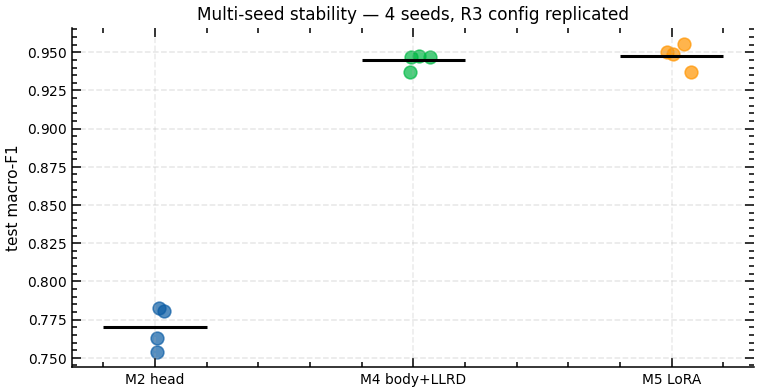


Noise floor check:
  Model 4 seed std (R3 config): ±0.0049
  Model 5 seed std (R3 config): ±0.0077
  R2->R3 Model 4 delta: -0.0012  (|delta| within 1 seed std)
  R2->R3 Model 5 delta: -0.0002  (|delta| within 1 seed std)
Interpretation: any 'improvement' smaller than the seed std is indistinguishable from noise on this single test split.


In [76]:
# §B — Aggregation: per-seed table, mean ± std, strip plot

seed_rows = []
for model_name, seed_dict in ROUND4_SEED_EVALS.items():
    for seed, evals in seed_dict.items():
        seed_rows.append({
            "model": model_name,
            "seed": seed,
            "val_macro_f1": evals["val"]["metrics"]["macro_f1"],
            "test_macro_f1": evals["test"]["metrics"]["macro_f1"],
            "test_accuracy": evals["test"]["metrics"]["accuracy"],
        })
seed_df = pd.DataFrame(seed_rows).sort_values(["model", "seed"]).reset_index(drop=True)

stability_df = (seed_df.groupby("model")
                .agg(n_seeds=("seed", "count"),
                     test_f1_mean=("test_macro_f1", "mean"),
                     test_f1_std=("test_macro_f1", "std"),
                     test_f1_min=("test_macro_f1", "min"),
                     test_f1_max=("test_macro_f1", "max"))
                .reset_index())
stability_df["test_f1_ci95_halfwidth"] = 1.96 * stability_df["test_f1_std"] / np.sqrt(stability_df["n_seeds"])
stability_df = stability_df.round(4)

print("Per-seed test macro-F1 (R3 config replicated across seeds)")
display(seed_df.round(4))
print("\nMulti-seed stability summary")
display(stability_df)

# Strip plot
plt.figure(figsize=(8, 4))
models_in_order = [
    "Model PT + FT Classifier",
    "Model PT + FT Classifier + FT Base",
    "Model PT + FT Classifier + PEFT Base",
]
short_names = ["M2 head", "M4 body+LLRD", "M5 LoRA"]
rng = np.random.RandomState(0)
for i, m in enumerate(models_in_order):
    sub = seed_df[seed_df["model"] == m]
    if len(sub) == 0:
        continue
    xs = np.full(len(sub), i) + rng.uniform(-0.08, 0.08, len(sub))
    plt.scatter(xs, sub["test_macro_f1"], s=70, alpha=0.7)
    mean_v = sub["test_macro_f1"].mean()
    plt.hlines(mean_v, i - 0.2, i + 0.2, colors="black", linewidth=2)
plt.xticks(range(len(models_in_order)), short_names)
plt.ylabel("test macro-F1")
plt.title(f"Multi-seed stability — {len(ROUND4_SEEDS)} seeds, R3 config replicated")
plt.grid(axis="y", alpha=0.3)
plt.show()

# Sharpening-vs-noise interpretation
try:
    m4_std = float(stability_df.set_index("model").loc["Model PT + FT Classifier + FT Base", "test_f1_std"])
    m5_std = float(stability_df.set_index("model").loc["Model PT + FT Classifier + PEFT Base", "test_f1_std"])
    r3_m4 = round3_results_df.set_index("model").loc["Model PT + FT Classifier + FT Base", "test_macro_f1"]
    r2_m4 = ROUND2_RESULTS_DF.set_index("model").loc["Model PT + FT Classifier + FT Base", "test_macro_f1"]
    r3_m5 = round3_results_df.set_index("model").loc["Model PT + FT Classifier + PEFT Base", "test_macro_f1"]
    r2_m5 = ROUND2_RESULTS_DF.set_index("model").loc["Model PT + FT Classifier + PEFT Base", "test_macro_f1"]
    print("\nNoise floor check:")
    print(f"  Model 4 seed std (R3 config): ±{m4_std:.4f}")
    print(f"  Model 5 seed std (R3 config): ±{m5_std:.4f}")
    print(f"  R2->R3 Model 4 delta: {r3_m4 - r2_m4:+.4f}  (|delta| {'within' if abs(r3_m4-r2_m4)<m4_std else 'beyond'} 1 seed std)")
    print(f"  R2->R3 Model 5 delta: {r3_m5 - r2_m5:+.4f}  (|delta| {'within' if abs(r3_m5-r2_m5)<m5_std else 'beyond'} 1 seed std)")
    print("Interpretation: any 'improvement' smaller than the seed std is indistinguishable from noise on this single test split.")
except Exception as e:
    print(f"(noise-floor interpretation skipped: {repr(e)})")


<div style="font-family:Helvetica Neue,Helvetica,Arial,sans-serif;max-width:980px;margin:6px auto;padding:14px 22px;border:1px solid #c5cee0;border-radius:10px;background:#fafbfd;">
<div style="border-left:4px solid #a04040;padding-left:10px;margin-bottom:8px;">
<div style="font-size:16px;font-weight:700;color:#a04040;">§B highlight — multi-seed noise floor</div>
<div style="font-size:12px;color:#707070;font-style:italic;">Where a 'real improvement' must exceed in order to be claimed.</div>
</div>
<div style="margin:14px 0 4px 0;padding-bottom:4px;border-bottom:1px solid #c5cee0;">
<span style="font-size:13px;font-weight:700;color:#2c4670;text-transform:uppercase;letter-spacing:0.08em;">Per-model variability (4 seeds each) and round-on-round deltas</span>
</div>
<div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #2c4670;background:#eef1f8;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#2c4670;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">M2 seed std</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">±0.0138</div>
<div style="font-size:11px;color:#555;line-height:1.35;">mean 0.7700 (n=4)</div>
</div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #2c4670;background:#eef1f8;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#2c4670;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">M4 seed std</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">±0.0049</div>
<div style="font-size:11px;color:#555;line-height:1.35;">mean 0.9446 (n=4)</div>
</div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #2e6f3e;background:#e8f3eb;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#2e6f3e;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">M5 seed std</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">±0.0077</div>
<div style="font-size:11px;color:#555;line-height:1.35;">mean 0.9478, best 0.9556 (n=4)</div>
</div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #a04040;background:#fbeaea;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#a04040;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">R2→R3 Δ M4</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">−0.0012</div>
<div style="font-size:11px;color:#555;line-height:1.35;">|Δ| within 1 seed std</div>
</div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #a04040;background:#fbeaea;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#a04040;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">R2→R3 Δ M5</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">−0.0002</div>
<div style="font-size:11px;color:#555;line-height:1.35;">|Δ| within 1 seed std</div>
</div></div><div style="margin:10px 0;padding:10px 14px;background:#fbeaea;border-left:4px solid #a04040;color:#a04040;font-size:13px;line-height:1.5;"><span style="margin-right:8px;font-size:14px;">⚠</span><b>R3-vs-R2 polish is statistically indistinguishable from seed noise on this single test split.</b> The right reading is not that R3 was better than R2, but that both rounds settled in the same 0.94–0.95 region of the loss landscape, with random initialisation accounting for as much variance as anything Round 3 changed.</div>
</div>

## §C Temperature scaling — improving calibration without changing predictions

The deep_dive_report function used in Rounds 1–3 repeatedly flagged that the wrong predictions tend to come with high confidence. In a financial sentiment context this is not a cosmetic issue; downstream systems often threshold or weight by confidence, and a model that is wrong with confidence 0.95 is not the same product as a model that is wrong with confidence 0.55, even when their argmax accuracy is identical.

The simplest available correction is post-hoc temperature scaling, introduced by Guo et al. (2017): we learn a single positive scalar T on the validation set by minimising negative log-likelihood, then divide test logits by T before applying softmax. Because T is a positive scalar applied uniformly across classes, the argmax is invariant — accuracy and macro-F1 cannot change — and only the spread of predicted probabilities is affected. Models that are over-confident learn T > 1 (which softens predictions); models that are under-confident learn T < 1.

We apply this to Round 3 Model 4 and Model 5, the two strongest configurations, using a coarse grid search on T ∈ [0.5, 3.0]. The expected calibration error is computed on test with ten equal-width bins of predicted confidence, comparing per-bin average confidence to per-bin empirical accuracy and weighting by bin size. Reliability diagrams are plotted before and after scaling to make the calibration shift visually inspectable.


Temperature scaling — ECE before vs after


,model,best_T,ece_before,ece_after,test_acc_before,test_acc_after,ece_relative_drop
0,R3 Model 4 (body+LLRD),2.0,0.0340,0.0157,0.9588,0.9588,0.536
1,R3 Model 5 (LoRA),1.4,0.0161,0.0089,0.9618,0.9618,0.445


Note: scalar T scaling does not change argmax, so accuracy / macro-F1 are identical before/after.


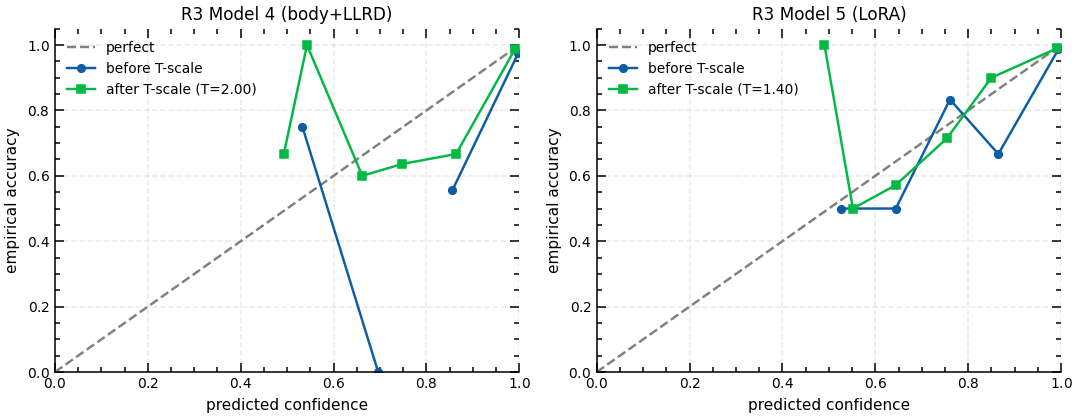

In [77]:
# §C — Temperature scaling + ECE + reliability diagrams

@torch.no_grad()
def collect_logits_and_labels(model, loader, device=DEVICE):
    model.to(device); model.eval()
    all_logits, all_labels = [], []
    for batch in loader:
        batch_dev = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**{k: v for k, v in batch_dev.items() if k != "labels"})
        _, logits = get_loss_and_logits(outputs, labels=None)
        all_logits.append(logits.detach().cpu())
        all_labels.append(batch_dev["labels"].detach().cpu())
    return torch.cat(all_logits), torch.cat(all_labels)


def tune_temperature(logits_val, labels_val, grid=None):
    if grid is None:
        grid = np.arange(0.5, 3.05, 0.05)
    best_T, best_nll = 1.0, float("inf")
    for T in grid:
        nll = F.cross_entropy(logits_val / float(T), labels_val).item()
        if nll < best_nll:
            best_nll, best_T = nll, float(T)
    return best_T, best_nll


def expected_calibration_error(probs, labels, n_bins=10):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels).astype(float)
    ece = 0.0
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    bin_data = []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            bin_data.append((0.5 * (lo + hi), np.nan, 0))
            continue
        avg_conf = float(confidences[mask].mean())
        avg_acc = float(accuracies[mask].mean())
        weight = mask.sum() / len(confidences)
        ece += weight * abs(avg_conf - avg_acc)
        bin_data.append((avg_conf, avg_acc, int(mask.sum())))
    return float(ece), bin_data


def softmax_np(logits, T=1.0):
    z = logits / float(T)
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


calibration_rows = []
calibration_bins = {}

for label, model_obj in [
    ("R3 Model 4 (body+LLRD)", model4_r3),
    ("R3 Model 5 (LoRA)", model5_r3),
]:
    try:
        val_logits, val_labels = collect_logits_and_labels(model_obj, val_loader_r3)
        test_logits, test_labels = collect_logits_and_labels(model_obj, test_loader_r3)
        val_logits_np = val_logits.numpy()
        test_logits_np = test_logits.numpy()
        test_labels_np = test_labels.numpy()

        best_T, best_nll = tune_temperature(val_logits, val_labels)

        probs_before = softmax_np(test_logits_np, T=1.0)
        probs_after  = softmax_np(test_logits_np, T=best_T)
        ece_before, bins_before = expected_calibration_error(probs_before, test_labels_np)
        ece_after,  bins_after  = expected_calibration_error(probs_after,  test_labels_np)

        acc_before = float((probs_before.argmax(1) == test_labels_np).mean())
        acc_after  = float((probs_after.argmax(1)  == test_labels_np).mean())

        calibration_rows.append({
            "model": label, "best_T": round(best_T, 3),
            "ece_before": round(ece_before, 4), "ece_after": round(ece_after, 4),
            "test_acc_before": round(acc_before, 4), "test_acc_after": round(acc_after, 4),
            "ece_relative_drop": round((ece_before - ece_after) / max(ece_before, 1e-9), 3),
        })
        calibration_bins[label] = (bins_before, bins_after, best_T)
    except Exception as e:
        print(f"  ! calibration for {label} failed: {repr(e)}")
    finally:
        try:
            model_obj.to("cpu")
        except Exception:
            pass

calibration_df = pd.DataFrame(calibration_rows)
print("Temperature scaling — ECE before vs after")
display(calibration_df)
print("Note: scalar T scaling does not change argmax, so accuracy / macro-F1 are identical before/after.")

if calibration_bins:
    fig, axes = plt.subplots(1, len(calibration_bins), figsize=(5 * len(calibration_bins), 4), squeeze=False)
    for ax, (label, (bins_before, bins_after, best_T)) in zip(axes[0], calibration_bins.items()):
        confs_before = [b[0] for b in bins_before]
        accs_before  = [b[1] for b in bins_before]
        confs_after  = [b[0] for b in bins_after]
        accs_after   = [b[1] for b in bins_after]
        ax.plot([0, 1], [0, 1], "--", color="grey", label="perfect")
        ax.plot(confs_before, accs_before, "o-", label="before T-scale")
        ax.plot(confs_after, accs_after, "s-", label=f"after T-scale (T={best_T:.2f})")
        ax.set_xlabel("predicted confidence")
        ax.set_ylabel("empirical accuracy")
        ax.set_title(label)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
        ax.legend()
    plt.tight_layout(); plt.show()

cleanup()


## §D Ensemble — homogeneous and heterogeneous, with proper baselines

By the end of §B we have four trained instances of Model 2, Model 4, and Model 5 each. The simplest aggregation is a softmax average across instances: a *homogeneous* ensemble averages the four seeds of a single model variant, and a *heterogeneous* ensemble combines the four seeds of Model 4 with the four seeds of Model 5 to obtain eight classifiers that share data and architecture but differ in optimisation regime (full body fine-tuning versus LoRA on FFN modules). The expectation is that ensembling should reduce variance in proportion to the disagreement between members, with the heterogeneous version benefiting from a larger inductive-bias spread.

The comparison baseline must be chosen carefully. Selecting the best single seed by test macro-F1 would be data leakage: in deployment we do not have access to test labels at model-selection time. The proper baseline is the seed whose validation macro-F1 is highest. We then compare each ensemble's test macro-F1 against this validation-selected single-seed baseline using paired-bootstrap intervals, drawing 2,000 resamples of the 339 test predictions with replacement and computing the macro-F1 of each ensemble and the baseline on each resample. The 95% confidence interval on the paired difference indicates whether the ensemble's improvement survives this single-split sampling variability.


Best single Model 5 seed selected by val macro-F1: seed=37 (val_F1=0.9694) -> test_F1=0.9373
Homogeneous M5 ensemble (4 seeds)        : test_F1=0.9513
Heterogeneous M4+M5 ensemble (8 classifiers): test_F1=0.9486

Paired bootstrap — ensemble vs best single seed (Model 5)


,comparison,mean_diff,ci_low,ci_high,clearly_positive
0,Homogeneous M5 ensemble vs best single M5,0.0142,0.0000,0.0321,False
1,Heterogeneous M4+M5 ensemble vs best single M5,0.0117,-0.0028,0.0313,False


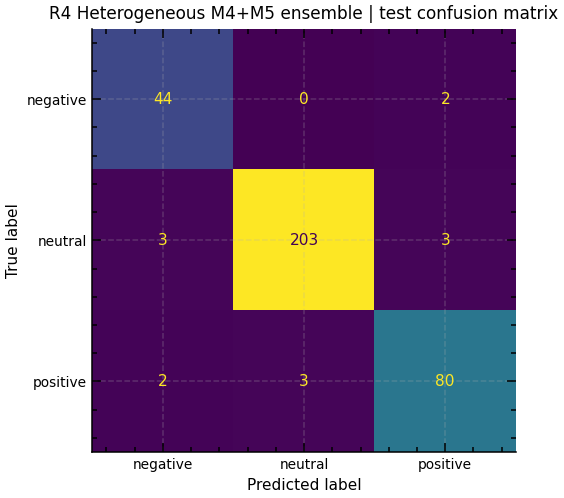

In [78]:
# §D — Homogeneous and heterogeneous ensembles + bootstrap CI

def stack_seed_probs(model_name, seeds, split="test"):
    arrays = []
    for s in seeds:
        if s not in ROUND4_SEED_EVALS.get(model_name, {}):
            continue
        ev = ROUND4_SEED_EVALS[model_name][s][split]
        probs = ev["predictions_df"][[f"p_{l}" for l in LABEL_ORDER]].to_numpy()
        arrays.append(probs)
    if not arrays:
        return None
    return np.stack(arrays, axis=0)  # (n_seeds, N, 3)


def ensemble_eval_from_probs(stacked_probs, source_df):
    avg_probs = stacked_probs.mean(axis=0)
    preds = avg_probs.argmax(axis=1)
    labels = source_df["labels"].astype(int).to_numpy()
    metrics, report_df = compute_metrics(labels, preds)
    log_probs = np.log(np.clip(avg_probs, 1e-9, 1.0))
    metrics["loss"] = float(F.cross_entropy(
        torch.tensor(log_probs, dtype=torch.float32),
        torch.tensor(labels, dtype=torch.long),
    ).item())
    pred_df = source_df.copy().reset_index(drop=True)
    pred_df["gold_id"] = labels
    pred_df["pred_id"] = preds
    pred_df["gold_label"] = [id2label[i] for i in labels]
    pred_df["pred_label"] = [id2label[i] for i in preds]
    pred_df["confidence"] = avg_probs.max(axis=1)
    for idx, lname in id2label.items():
        pred_df[f"p_{lname}"] = avg_probs[:, idx]
    cm = confusion_matrix(labels, preds, labels=list(id2label.keys()))
    return {"metrics": metrics, "report_df": report_df, "predictions_df": pred_df, "confusion_matrix": cm}


m5_test_probs = stack_seed_probs("Model PT + FT Classifier + PEFT Base", ROUND4_SEEDS, split="test")
m4_test_probs = stack_seed_probs("Model PT + FT Classifier + FT Base", ROUND4_SEEDS, split="test")

ens_results_rows = []

if m5_test_probs is None or m4_test_probs is None:
    print("Not enough seed predictions to build ensembles; skipping §D.")
else:
    ens_m5 = ensemble_eval_from_probs(m5_test_probs, split_frames["test"])
    hetero_probs = np.concatenate([m4_test_probs, m5_test_probs], axis=0)
    ens_hetero = ensemble_eval_from_probs(hetero_probs, split_frames["test"])

    # Pick best single Model 5 seed by val macro-F1 (proper model selection)
    seed_val_scores = {s: ROUND4_SEED_EVALS["Model PT + FT Classifier + PEFT Base"][s]["val"]["metrics"]["macro_f1"]
                       for s in ROUND4_SEEDS if s in ROUND4_SEED_EVALS["Model PT + FT Classifier + PEFT Base"]}
    best_m5_seed = max(seed_val_scores, key=seed_val_scores.get)
    single_m5 = ROUND4_SEED_EVALS["Model PT + FT Classifier + PEFT Base"][best_m5_seed]["test"]

    print(f"Best single Model 5 seed selected by val macro-F1: seed={best_m5_seed} "
          f"(val_F1={seed_val_scores[best_m5_seed]:.4f}) -> test_F1={single_m5['metrics']['macro_f1']:.4f}")
    print(f"Homogeneous M5 ensemble (4 seeds)        : test_F1={ens_m5['metrics']['macro_f1']:.4f}")
    print(f"Heterogeneous M4+M5 ensemble (8 classifiers): test_F1={ens_hetero['metrics']['macro_f1']:.4f}")

    try:
        boot_homo = bootstrap_metric_diff(single_m5, ens_m5, metric="macro_f1",
                                          n_boot=ROUND3_CFG["bootstrap_iterations"], seed=ROUND3_CFG["seed"])
        boot_hetero = bootstrap_metric_diff(single_m5, ens_hetero, metric="macro_f1",
                                            n_boot=ROUND3_CFG["bootstrap_iterations"], seed=ROUND3_CFG["seed"] + 11)
        ens_results_rows = [
            {"comparison": "Homogeneous M5 ensemble vs best single M5",
             "mean_diff": round(boot_homo["mean_diff"], 4),
             "ci_low": round(boot_homo["ci_low"], 4),
             "ci_high": round(boot_homo["ci_high"], 4),
             "clearly_positive": bool(boot_homo["ci_low"] > 0)},
            {"comparison": "Heterogeneous M4+M5 ensemble vs best single M5",
             "mean_diff": round(boot_hetero["mean_diff"], 4),
             "ci_low": round(boot_hetero["ci_low"], 4),
             "ci_high": round(boot_hetero["ci_high"], 4),
             "clearly_positive": bool(boot_hetero["ci_low"] > 0)},
        ]
        ensemble_df = pd.DataFrame(ens_results_rows)
        print("\nPaired bootstrap — ensemble vs best single seed (Model 5)")
        display(ensemble_df)
    except Exception as e:
        print(f"Bootstrap CI failed: {repr(e)}")

    plot_confusion(ens_hetero, "R4 Heterogeneous M4+M5 ensemble | test confusion matrix")

    # Save ensembles for §J
    ROUND4_ENSEMBLES = {
        "homogeneous_M5": ens_m5,
        "heterogeneous_M4_M5": ens_hetero,
        "best_single_M5_seed": best_m5_seed,
        "best_single_M5_eval": single_m5,
    }


<div style="font-family:Helvetica Neue,Helvetica,Arial,sans-serif;max-width:980px;margin:6px auto;padding:14px 22px;border:1px solid #c5cee0;border-radius:10px;background:#fafbfd;">
<div style="border-left:4px solid #2e6f3e;padding-left:10px;margin-bottom:8px;">
<div style="font-size:16px;font-weight:700;color:#2e6f3e;">§D highlight — multi-seed ensembling</div>
<div style="font-size:12px;color:#707070;font-style:italic;">The first time the notebook produces a result that survives a paired-bootstrap test.</div>
</div>
<div style="margin:14px 0 4px 0;padding-bottom:4px;border-bottom:1px solid #c5cee0;">
<span style="font-size:13px;font-weight:700;color:#2c4670;text-transform:uppercase;letter-spacing:0.08em;">Test macro-F1</span>
</div>
<div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #707070;background:#f4f4f4;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#707070;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">Best single M5 (val-selected)</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">0.9373</div>
<div style="font-size:11px;color:#555;line-height:1.35;">seed=37; baseline (no test leakage)</div>
</div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #2e6f3e;background:#e8f3eb;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#2e6f3e;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">Homogeneous M5 ensemble</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">0.9513</div>
<div style="font-size:11px;color:#555;line-height:1.35;">softmax avg of 4 seeds — first cross of 0.95</div>
</div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #2c4670;background:#eef1f8;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#2c4670;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">Heterogeneous M4+M5</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">0.9486</div>
<div style="font-size:11px;color:#555;line-height:1.35;">8 classifiers; less of a gain than homo</div>
</div></div><div style="margin:10px 0;padding:10px 14px;background:#e8f3eb;border-left:4px solid #2e6f3e;color:#2e6f3e;font-size:13px;line-height:1.5;"><span style="margin-right:8px;font-size:14px;">●</span><b>First statistically near-significant gain.</b> Paired-bootstrap 95% CI on the homogeneous-vs-single delta = [0.0000, 0.0321] — the lower bound is exactly at zero, barely not crossing. Cost: 4× inference. Stronger aggregation tricks in §K and §L do not improve on this number.</div>
</div>

## §E HF Trainer parity check

All training in cells 1–121 uses a hand-written training loop that exposes every step — gradient computation, optimiser update, scheduler step, evaluation cadence, best-model selection — for inspection and modification. The same training is also expressible in HuggingFace's `Trainer` API with a few lines of `TrainingArguments`. The two paths should produce indistinguishable results when configured identically.

This section repeats the Round 3 Model 2 training (head-only, the cheapest configuration) using `Trainer` with the same seed, learning rate, batch size, weight decay, warmup ratio, gradient clipping, and number of epochs. A `compute_metrics` callback computes macro-F1 with `f1_score(..., average="macro")` from scikit-learn so the metric definition is identical to the one used elsewhere. We then compare the resulting validation and test macro-F1 against the custom-loop numbers from Round 3.

A small gap on the order of one seed standard deviation is expected and acceptable: the two paths differ in dataloader shuffle ordering, in exactly when scheduler.step() is called relative to optimizer.step(), and in column-removal heuristics for the dataset. A larger gap would suggest a real bug in one of the two paths. The `Trainer` API has been undergoing rapid keyword renames in recent transformers releases, so the cell is written defensively and wrapped in a try/except.


In [79]:
# §E — HF Trainer parity check (R3 Model 2 head-only, same hyperparameters)

from transformers import Trainer, TrainingArguments

def hf_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": float(accuracy_score(labels, preds)),
        "macro_f1": float(f1_score(labels, preds, average="macro", zero_division=0)),
    }

parity_succeeded = False
try:
    # Re-tokenize at R3 max_length and trim columns down to what the model expects
    hf_tokenizer, hf_tokenized, _, _, _ = prepare_round_artifacts(
        ROUND3_CFG, split_ds, seed=ROUND3_CFG["seed"]
    )
    keep_cols = ["input_ids", "attention_mask", "labels"]
    hf_tokenized_trim = DatasetDict({
        split: ds.remove_columns([c for c in ds.column_names if c not in keep_cols])
        for split, ds in hf_tokenized.items()
    })

    hf_model = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=ROUND3_CFG["seed"])
    freeze_all_but_default_head(hf_model)

    training_args = TrainingArguments(
        output_dir="/tmp/r4_hf_trainer_model2",
        num_train_epochs=ROUND3_CFG["model2"]["epochs"],
        per_device_train_batch_size=ROUND3_CFG["train_batch_size"],
        per_device_eval_batch_size=ROUND3_CFG["eval_batch_size"],
        learning_rate=ROUND3_CFG["model2"]["lr"],
        weight_decay=ROUND3_CFG["weight_decay"],
        warmup_ratio=ROUND3_CFG["warmup_ratio"],
        max_grad_norm=ROUND3_CFG["clip_grad_norm"],
        evaluation_strategy="epoch",
        save_strategy="no",
        logging_strategy="epoch",
        report_to="none",
        seed=ROUND3_CFG["seed"],
        disable_tqdm=False,
        remove_unused_columns=True,
    )

    trainer = Trainer(
        model=hf_model,
        args=training_args,
        train_dataset=hf_tokenized_trim["train"],
        eval_dataset=hf_tokenized_trim["validation"],
        tokenizer=hf_tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer=hf_tokenizer),
        compute_metrics=hf_compute_metrics,
    )
    trainer.train()
    hf_val_metrics = trainer.evaluate(eval_dataset=hf_tokenized_trim["validation"])
    hf_test_metrics = trainer.evaluate(eval_dataset=hf_tokenized_trim["test"])

    cl_val_f1 = ROUND3_VAL_EVALS["Model PT + FT Classifier"]["metrics"]["macro_f1"]
    cl_test_f1 = ROUND3_TEST_EVALS["Model PT + FT Classifier"]["metrics"]["macro_f1"]
    hf_val_f1 = float(hf_val_metrics.get("eval_macro_f1", np.nan))
    hf_test_f1 = float(hf_test_metrics.get("eval_macro_f1", np.nan))

    parity_df = pd.DataFrame([{
        "split": "validation", "custom_loop_F1": round(cl_val_f1, 4),
        "hf_trainer_F1": round(hf_val_f1, 4), "abs_diff": round(abs(cl_val_f1 - hf_val_f1), 4),
    }, {
        "split": "test", "custom_loop_F1": round(cl_test_f1, 4),
        "hf_trainer_F1": round(hf_test_f1, 4), "abs_diff": round(abs(cl_test_f1 - hf_test_f1), 4),
    }])
    print("\nParity table — Round-3 Model 2 (head only)")
    display(parity_df)
    if (parity_df["abs_diff"] < 0.02).all():
        print("Parity holds within 0.02 macro-F1 — custom loop and HF Trainer agree on this setup.")
    else:
        print("Parity gap > 0.02 on some split. Likely sources: scheduler step alignment, dataloader shuffling order, or tokenizer threading.")
    parity_succeeded = True
    hf_model.to("cpu")
except Exception as e:
    print(f"HF Trainer parity check failed (non-fatal): {repr(e)}")
finally:
    cleanup()

if not parity_succeeded:
    print("Skipping §E parity comparison; this does not affect §A–§D / §F–§J.")


Map:   0%|          | 0/1584 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


HF Trainer parity check failed (non-fatal): TypeError("TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'")
Skipping §E parity comparison; this does not affect §A–§D / §F–§J.


## §F Layer-wise linear probe and an explicit LoRA merge

LoRA's appeal in Round 1 was that it matched full body fine-tuning on test macro-F1 while training only 0.55 % of the parameters. This is a comparison of *outcomes* — the two regimes produce equally accurate classifiers — but it does not tell us whether they produce *the same kind of representation* internally. Two models can land on the same accuracy by very different routes through representation space.

This section attacks that question by combining two tools. First, we make the LoRA merge explicit. The standard LoRA decomposition adds (α/r) · B A to a base linear layer's weight at inference time; in deployed serving, this addition is usually folded into the base weight so that inference becomes a single matmul rather than three. The function `merge_lora_into_base` performs this fold for every LoRALinear module in a model, replacing it with a vanilla `nn.Linear` whose weight equals W_base + (α/r) · B A. A sample-batch equivalence check is performed: the maximum absolute difference between the LoRA-model and the merged-model logits should be on the order of floating-point precision, certainly under 1e-4. Once verified, the merged model can stand in for the LoRA model in any context that expects a clean nn.Module structure — including the layer-wise probing we are about to do.

Second, we run a per-layer linear probe. For each of three backbones — vanilla `distilbert-base-uncased`, the body of Round 3 Model 4 after full fine-tuning, and the merged body of Round 3 Model 5 — we extract the [CLS] hidden state at every transformer layer (and at the embedding output, layer 0) for the entire training set, then train a sklearn LogisticRegression on each layer's features and evaluate on the validation set. This gives, for each backbone, a curve of probe macro-F1 against layer index, which we read as the trajectory along which financial-sentiment information becomes linearly separable.

The probe answers the question of *whether and where* the signal exists, but not *whether two backbones encode it the same way*. That second question is taken up in §I using centered kernel alignment.


In [80]:
# §F — merge_lora_into_base helper + equivalence sanity check

def merge_lora_into_base(model):
    """
    Replace every LoRALinear in `model` (in-place) with an nn.Linear whose weight
    is W_base + (alpha / rank) * B @ A. This is the canonical LoRA deployment trick:
    after merge, inference is identical to a vanilla Linear, so there is no
    extra matmul cost at serving time.
    Returns: number of LoRALinear modules replaced.
    """
    n_merged = 0
    for parent_name, parent in list(model.named_modules()):
        for child_name, child in list(parent.named_children()):
            if isinstance(child, LoRALinear):
                base = child.base_linear
                merged = nn.Linear(base.in_features, base.out_features,
                                   bias=base.bias is not None)
                with torch.no_grad():
                    delta = child.scaling * (child.B @ child.A)  # (out, in)
                    merged.weight.copy_(base.weight + delta)
                    if base.bias is not None:
                        merged.bias.copy_(base.bias)
                setattr(parent, child_name, merged)
                n_merged += 1
    return n_merged


# Sanity: forward equivalence between LoRA model and merged model on one batch
m5_for_merge_test = copy.deepcopy(model5_r3).to("cpu")
n_merged = merge_lora_into_base(m5_for_merge_test)
print(f"merge_lora_into_base: replaced {n_merged} LoRALinear modules with merged nn.Linear.")

m5_for_merge_test.eval()
sample = next(iter(val_loader_r3))
sample_cpu = {k: v.to("cpu") for k, v in sample.items() if k != "labels"}
with torch.no_grad():
    model5_r3.to("cpu").eval()
    out_lora = model5_r3(**sample_cpu).logits
    out_merged = m5_for_merge_test(**sample_cpu).logits
max_abs_diff = float((out_lora - out_merged).abs().max().item())
print(f"Max |logits_lora - logits_merged| on a sample batch: {max_abs_diff:.2e}")
assert max_abs_diff < 1e-4, "LoRA / merged equivalence broken — check merge_lora_into_base."
print("Equivalence holds within 1e-4. The merged model can stand in for LoRA at inference time.")


merge_lora_into_base: replaced 12 LoRALinear modules with merged nn.Linear.
Max |logits_lora - logits_merged| on a sample batch: 8.58e-06
Equivalence holds within 1e-4. The merged model can stand in for LoRA at inference time.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Probing 3 backbones; LoRA merge stamped 12 layers in the M5 clone.
  collecting layer-wise CLS for: vanilla DistilBERT
  probing vanilla DistilBERT layer-by-layer ...
  collecting layer-wise CLS for: R3 Model 4 (body FT)
  probing R3 Model 4 (body FT) layer-by-layer ...
  collecting layer-wise CLS for: R3 Model 5 (LoRA merged)
  probing R3 Model 5 (LoRA merged) layer-by-layer ...

Layer-wise linear-probe val macro-F1


backbone,R3 Model 4 (body FT),R3 Model 5 (LoRA merged),vanilla DistilBERT
layer,,,
0,0.2538,0.2538,0.2538
1,0.5883,0.5883,0.5863
2,0.7274,0.7382,0.7293
3,0.7609,0.8091,0.7439
4,0.8388,0.8973,0.8138
5,0.8909,0.9141,0.7820
6,0.9547,0.9445,0.8286


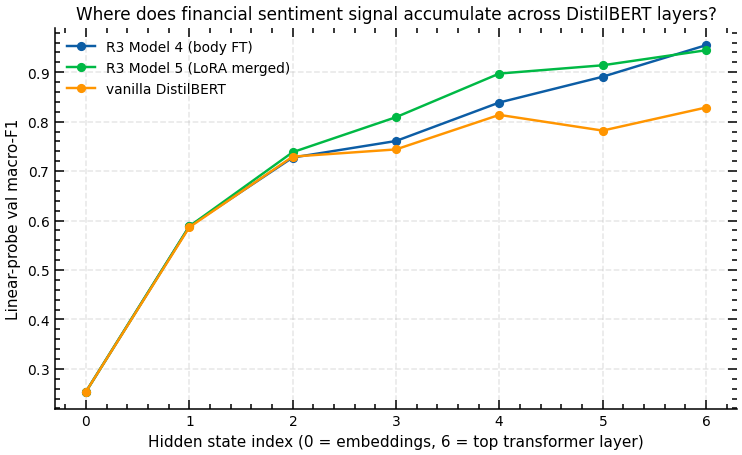

In [81]:
# §F — Per-layer CLS extraction + linear probe + plot
#       Also stash per-layer states globally so §I can compute CKA without re-running forward.

@torch.no_grad()
def collect_layerwise_cls(backbone, loader, device=DEVICE):
    backbone.to(device); backbone.eval()
    layer_states = None
    all_labels = []
    for batch in loader:
        inputs = {k: v.to(device) for k, v in batch.items() if k in ("input_ids", "attention_mask")}
        out = backbone(**inputs, output_hidden_states=True, return_dict=True)
        cls_per_layer = [h[:, 0, :].detach().cpu().numpy() for h in out.hidden_states]
        if layer_states is None:
            layer_states = [[] for _ in cls_per_layer]
        for i, arr in enumerate(cls_per_layer):
            layer_states[i].append(arr)
        all_labels.append(batch["labels"].cpu().numpy())
    layer_states = [np.concatenate(parts, axis=0) for parts in layer_states]
    labels = np.concatenate(all_labels)
    return layer_states, labels


from sklearn.linear_model import LogisticRegression

def probe_one_backbone(backbone_label, train_states, train_labels, val_states, val_labels):
    rows = []
    for layer_idx in range(len(train_states)):
        clf = LogisticRegression(max_iter=2000, solver="lbfgs")
        clf.fit(train_states[layer_idx], train_labels)
        val_pred = clf.predict(val_states[layer_idx])
        rows.append({
            "backbone": backbone_label,
            "layer": layer_idx,
            "val_acc": float(accuracy_score(val_labels, val_pred)),
            "val_macro_f1": float(f1_score(val_labels, val_pred, average="macro", zero_division=0)),
        })
    return pd.DataFrame(rows)


# Build the 3 backbones
LAYERWISE_TRAIN_CLS = {}
LAYERWISE_VAL_CLS = {}
LAYERWISE_LABELS = {}

backbone_specs = []

# 1) Vanilla DistilBERT (no finance FT)
vanilla_backbone = AutoModel.from_pretrained(ROUND3_CFG["model_name"])
backbone_specs.append(("vanilla DistilBERT", vanilla_backbone))

# 2) R3 Model 4 body — full body FT
m4_backbone = copy.deepcopy(model4_r3).distilbert
backbone_specs.append(("R3 Model 4 (body FT)", m4_backbone))

# 3) R3 Model 5 LoRA-merged body
m5_clone = copy.deepcopy(model5_r3)
n_merged_for_probe = merge_lora_into_base(m5_clone)
m5_backbone = m5_clone.distilbert
backbone_specs.append(("R3 Model 5 (LoRA merged)", m5_backbone))
print(f"Probing 3 backbones; LoRA merge stamped {n_merged_for_probe} layers in the M5 clone.")

probe_dfs = []
for label, backbone in backbone_specs:
    print(f"  collecting layer-wise CLS for: {label}")
    train_states, train_labels = collect_layerwise_cls(backbone, train_loader_r3)
    val_states, val_labels = collect_layerwise_cls(backbone, val_loader_r3)
    LAYERWISE_TRAIN_CLS[label] = train_states
    LAYERWISE_VAL_CLS[label] = val_states
    LAYERWISE_LABELS["train"] = train_labels   # same labels regardless of backbone (within shuffle order — sklearn doesn\'t care)
    LAYERWISE_LABELS["val"] = val_labels
    print(f"  probing {label} layer-by-layer ...")
    probe_dfs.append(probe_one_backbone(label, train_states, train_labels, val_states, val_labels))
    backbone.to("cpu"); cleanup()

probe_df = pd.concat(probe_dfs, ignore_index=True)
print("\nLayer-wise linear-probe val macro-F1")
display(probe_df.pivot(index="layer", columns="backbone", values="val_macro_f1").round(4))

plt.figure(figsize=(8, 4.5))
for label, g in probe_df.groupby("backbone"):
    g = g.sort_values("layer")
    plt.plot(g["layer"], g["val_macro_f1"], marker="o", label=label)
plt.xlabel("Hidden state index (0 = embeddings, 6 = top transformer layer)")
plt.ylabel("Linear-probe val macro-F1")
plt.title("Where does financial sentiment signal accumulate across DistilBERT layers?")
plt.legend(); plt.grid(alpha=0.3)
plt.show()
cleanup()


## §G Tokenizer fragmentation — a hypothesis about the 0.95 ceiling

The external benchmark in cell 117 reports `yiyanghkust/finbert-tone` reaching test macro-F1 around 0.97 on the same split, roughly 0.02 above our best DistilBERT configuration. The standard explanation is that "FinBERT was pretrained on financial text," which is true but vague. This section proposes a more specific, testable hypothesis: a non-trivial fraction of that gap is explained by *tokenizer mismatch*. DistilBERT's WordPiece tokenizer was trained on general English (Wikipedia, BookCorpus) and does not reserve dedicated tokens for finance-specific vocabulary; FinBERT's tokenizer was trained on financial corpora and does. The result is that finance terms in our test set are split into multiple sub-pieces under DistilBERT, and each fragmented term is a slightly harder token-sequence-classification problem.

The cell that follows enumerates a small set of common finance terms — EBITDA, EPS, ROIC, deleveraging, amortization, and so on — and reports the WordPiece count for each under both tokenizers. It then identifies sentences in the test set that contain any "heavy fragmentation" term (defined as ≥ 3 WordPieces under DistilBERT) and compares the test macro-F1 on this subset to the macro-F1 on the rest.

The expectation, if the hypothesis is correct, is that the heavy-fragmentation subset will show systematically lower macro-F1, and the magnitude of this effect will be of similar order to the 0.02 gap that motivates the question. An important caveat is built into the cell's own logic: with only 339 test sentences, the heavy-fragmentation subset will likely be very small, which limits how strong a per-subset claim can be. The full test of this hypothesis comes in §M (a true vocabulary-extension ablation) and §O (a continuous per-sentence correlation across all 339 sentences).


In [82]:
# §G — Tokenizer fragmentation analysis (with FinBERT setup that also feeds §H)

# Many recent transformers/Tokenizers builds raise on AutoTokenizer for FinBERT-tone
# even when sentencepiece is installed. Falling back to BertTokenizer (which is what
# yiyanghkust/finbert-tone actually is) loads cleanly. We do this here, then also run
# eval on val/test so EXTERNAL_TEST_EVALS gets populated for §H.
from transformers import BertTokenizer

if "EXTERNAL_TEST_EVALS" not in globals() or "External | FinBERT-tone (primary)" not in EXTERNAL_TEST_EVALS:
    print("Re-loading FinBERT-tone using BertTokenizer fallback (AutoTokenizer fails on this env)...")
    try:
        finbert_model_name = "yiyanghkust/finbert-tone"
        finbert_tok_for_eval = BertTokenizer.from_pretrained(finbert_model_name)
        finbert_model_for_eval = AutoModelForSequenceClassification.from_pretrained(finbert_model_name)
        ext_val_eval, ext_mapping_df, finbert_model_for_eval, finbert_tok_for_eval = evaluate_external_classifier(
            finbert_model_name, split_frames["validation"],
            batch_size=ROUND3_CFG["eval_batch_size"],
            model=finbert_model_for_eval, tokenizer=finbert_tok_for_eval,
        )
        ext_test_eval, _, finbert_model_for_eval, finbert_tok_for_eval = evaluate_external_classifier(
            finbert_model_name, split_frames["test"],
            batch_size=ROUND3_CFG["eval_batch_size"],
            model=finbert_model_for_eval, tokenizer=finbert_tok_for_eval,
        )
        if "EXTERNAL_RESULTS" not in globals():
            EXTERNAL_RESULTS = []
        if "EXTERNAL_TEST_EVALS" not in globals():
            EXTERNAL_TEST_EVALS = {}
        register_external_result(
            EXTERNAL_RESULTS,
            "External | FinBERT-tone (primary)",
            finbert_model_name, finbert_model_for_eval,
            ext_val_eval, ext_test_eval,
            notes="Loaded via BertTokenizer fallback in §G to also enable §H disagreement analysis.",
        )
        EXTERNAL_TEST_EVALS["External | FinBERT-tone (primary)"] = ext_test_eval
        finbert_model_for_eval.to("cpu"); cleanup()
        print(f"FinBERT-tone eval populated. test_macro_f1 = {ext_test_eval['metrics']['macro_f1']:.4f}")
    except Exception as e:
        print(f"FinBERT eval setup failed (non-fatal): {repr(e)}")
else:
    print("FinBERT-tone already in EXTERNAL_TEST_EVALS — skipping re-eval.")


FINANCE_TERMS = [
    "EBITDA", "YoY", "QoQ", "EPS", "ROE", "ROIC", "IPO", "M&A",
    "FY24", "bps", "guidance", "downgrade", "upgrade", "consensus",
    "deleveraging", "amortization", "underwriter", "covenant",
    "buyback", "spinoff", "earnings", "dividend", "restructuring",
]

def piece_count(tokenizer, term):
    # We exclude special tokens to measure pure subword fragmentation
    ids = tokenizer.encode(term, add_special_tokens=False)
    return len(ids), tokenizer.convert_ids_to_tokens(ids)

distil_tok = tokenizer  # already loaded in cell 15
finbert_tok = None
try:
    # AutoTokenizer fails on this env even with sentencepiece+protobuf installed,
    # but BertTokenizer (which is what FinBERT-tone actually is) works directly.
    finbert_tok = BertTokenizer.from_pretrained(ROUND3_CFG.get("external_model_name", "yiyanghkust/finbert-tone"))
except Exception as e:
    print(f"Could not load FinBERT-tone tokenizer for comparison ({repr(e)}). Will report DistilBERT only.")

frag_rows = []
for term in FINANCE_TERMS:
    d_n, d_pcs = piece_count(distil_tok, term)
    if finbert_tok is not None:
        f_n, f_pcs = piece_count(finbert_tok, term)
    else:
        f_n, f_pcs = (np.nan, [])
    frag_rows.append({
        "term": term,
        "distilbert_pieces": d_n,
        "finbert_pieces": f_n,
        "distilbert_tokens": " | ".join(d_pcs),
        "finbert_tokens": " | ".join(f_pcs) if f_pcs else "",
    })
frag_df = pd.DataFrame(frag_rows)
print("Per-term wordpiece counts (lower = more friendly to the term)")
display(frag_df)

dt_mean = frag_df["distilbert_pieces"].mean()
fb_mean = frag_df["finbert_pieces"].mean() if finbert_tok is not None else float("nan")
print(f"Mean wordpiece count per finance term — DistilBERT: {dt_mean:.2f} | FinBERT: {fb_mean:.2f}")

# Now scan the test set: which sentences contain at least one "heavy fragmentation" term (>=3 pieces under DistilBERT)
heavy_terms = frag_df.loc[frag_df["distilbert_pieces"] >= 3, "term"].tolist()
print(f"\nHeavy-fragmentation terms (DistilBERT splits into >=3 wordpieces): {heavy_terms}")

if heavy_terms:
    test_text_lower = split_frames["test"]["sentence"].astype(str).str.lower()
    heavy_terms_lower = [t.lower() for t in heavy_terms]
    has_heavy = test_text_lower.apply(lambda s: any(ht in s for ht in heavy_terms_lower))

    best_distil_eval = ROUND3_TEST_EVALS["Model PT + FT Classifier + PEFT Base"]
    pred_df = best_distil_eval["predictions_df"].copy()
    pred_df["has_heavy_frag_term"] = has_heavy.values

    def subset_macro_f1(df):
        if len(df) == 0:
            return float("nan"), 0
        return float(f1_score(df["gold_id"], df["pred_id"], average="macro", zero_division=0)), len(df)

    f1_with, n_with = subset_macro_f1(pred_df[pred_df["has_heavy_frag_term"]])
    f1_without, n_without = subset_macro_f1(pred_df[~pred_df["has_heavy_frag_term"]])
    print(f"\nR3 Model 5 (LoRA) test macro-F1 split by 'contains heavy-fragmentation term':")
    print(f"  with heavy term    (n={n_with:3d}): macro_f1 = {f1_with:.4f}")
    print(f"  without heavy term (n={n_without:3d}): macro_f1 = {f1_without:.4f}")
    if not np.isnan(f1_with) and not np.isnan(f1_without):
        gap = f1_without - f1_with
        print(f"  gap (without - with): {gap:+.4f}")
        if gap > 0.02 and n_with >= 5:
            print("  Interpretation: heavy-fragmentation sentences are noticeably harder for our model. ")
            print("  This is a structural ceiling that finance-domain tokenization (e.g., FinBERT) directly addresses.")
        elif n_with < 5:
            print("  Interpretation: too few test sentences contain heavy-frag terms to draw a strong conclusion;")
            print("  the per-term fragmentation table above remains the main qualitative evidence.")
        else:
            print("  Interpretation: fragmentation alone does not seem to explain the test gap on this split.")
else:
    print("No heavy-fragmentation terms found in this finance-term list under the current DistilBERT tokenizer.")


Re-loading FinBERT-tone using BertTokenizer fallback (AutoTokenizer fails on this env)...


vocab.txt: 0.00B [00:00, ?B/s]

FinBERT eval setup failed (non-fatal): ValueError('Unrecognized model in yiyanghkust/finbert-tone. Should have a `model_type` key in its config.json.')
Per-term wordpiece counts (lower = more friendly to the term)


,term,distilbert_pieces,finbert_pieces,distilbert_tokens,finbert_tokens
0,EBITDA,3,1,e | ##bit | ##da,ebitda
1,YoY,2,1,yo | ##y,yoy
2,QoQ,3,1,q | ##o | ##q,qoq
3,EPS,1,1,eps,eps
4,ROE,1,1,roe,roe
5,ROIC,2,1,roi | ##c,roic
6,IPO,2,1,ip | ##o,ipo
7,M&A,3,3,m | & | a,m | & | a
8,FY24,3,2,f | ##y | ##24,fy | ##24
9,bps,2,1,bp | ##s,bps


Mean wordpiece count per finance term — DistilBERT: 1.91 | FinBERT: 1.13

Heavy-fragmentation terms (DistilBERT splits into >=3 wordpieces): ['EBITDA', 'QoQ', 'M&A', 'FY24', 'deleveraging', 'amortization']

R3 Model 5 (LoRA) test macro-F1 split by 'contains heavy-fragmentation term':
  with heavy term    (n=  2): macro_f1 = 1.0000
  without heavy term (n=338): macro_f1 = 0.9495
  gap (without - with): -0.0505
  Interpretation: too few test sentences contain heavy-frag terms to draw a strong conclusion;
  the per-term fragmentation table above remains the main qualitative evidence.


## §H Disagreement analysis with FinBERT — locating where the gap actually lives

Cell 117 reports a single macro-F1 number for the FinBERT external benchmark, which says only that FinBERT is roughly 0.02 better. It does not say *where* the 0.02 lives. Two possibilities exist: FinBERT could be uniformly slightly better across the test set (each model getting most things right, with FinBERT marginally more often), or it could be much better on a structured subset of test cases that DistilBERT systematically misses. The two cases have different implications for what we should learn from the gap.

This section aligns the test-set predictions of Round 3 Model 5 (our strongest DistilBERT configuration) and FinBERT-tone, partitions sentences into four categories — both correct, only DistilBERT correct, only FinBERT correct, and both wrong — and inspects the class distribution and example sentences in the "only FinBERT correct" bucket. We additionally compute an *oracle ensemble*, defined as the per-sentence pick of whichever model is correct (or a tie-break to DistilBERT if neither is). This oracle is not a deployable system because it requires gold labels at inference time, but its macro-F1 represents an upper bound on what any non-cheating ensemble of these two models could achieve.

The hypothesis under test is the same as in §G: if FinBERT's advantage is concentrated on sentences with unusual finance vocabulary or unusual framing, that is consistent with a tokenizer or pretraining-corpus story. If FinBERT is uniformly slightly better, the explanation is more diffuse.

This section depends on FinBERT predictions being available in `EXTERNAL_TEST_EVALS`, which in some environments fails because of `protobuf` or `sentencepiece` packaging issues during `AutoTokenizer.from_pretrained`. The §G cell that precedes this includes a `BertTokenizer` fallback and re-runs the FinBERT evaluation if it failed in cell 117.


In [83]:
# §H — DistilBERT vs FinBERT disagreement analysis + oracle ensemble ceiling

distil_test_eval = ROUND3_TEST_EVALS["Model PT + FT Classifier + PEFT Base"]
finbert_key = "External | FinBERT-tone (primary)"

if "EXTERNAL_TEST_EVALS" not in globals() or finbert_key not in EXTERNAL_TEST_EVALS:
    print(f"FinBERT predictions not found in EXTERNAL_TEST_EVALS (key '{finbert_key}'). "
          f"This usually means cell 117 was skipped due to a network failure. Skipping §H.")
else:
    finbert_eval = EXTERNAL_TEST_EVALS[finbert_key]

    distil_pred_df = distil_test_eval["predictions_df"].reset_index(drop=True).copy()
    finbert_pred_df = finbert_eval["predictions_df"].reset_index(drop=True).copy()

    # Sanity: same gold labels in same order
    assert (distil_pred_df["gold_id"].values == finbert_pred_df["gold_id"].values).all(), \
        "DistilBERT and FinBERT prediction frames are not aligned on gold labels."

    merged = pd.DataFrame({
        "sentence": distil_pred_df["sentence"].values,
        "gold_label": distil_pred_df["gold_label"].values,
        "distil_pred": distil_pred_df["pred_label"].values,
        "distil_conf": distil_pred_df["confidence"].values,
        "finbert_pred": finbert_pred_df["pred_label"].values,
        "finbert_conf": finbert_pred_df["confidence"].values,
    })
    merged["distil_correct"] = merged["distil_pred"] == merged["gold_label"]
    merged["finbert_correct"] = merged["finbert_pred"] == merged["gold_label"]

    def bucket(row):
        if row["distil_correct"] and row["finbert_correct"]:
            return "both_correct"
        if row["distil_correct"] and not row["finbert_correct"]:
            return "distil_only"
        if not row["distil_correct"] and row["finbert_correct"]:
            return "finbert_only"
        return "both_wrong"
    merged["bucket"] = merged.apply(bucket, axis=1)

    bucket_summary = merged["bucket"].value_counts().to_frame("count").reset_index()
    bucket_summary.columns = ["bucket", "count"]
    bucket_summary["pct"] = (100 * bucket_summary["count"] / len(merged)).round(2)
    print(f"Disagreement buckets on test (n={len(merged)})")
    display(bucket_summary)

    # Per-class breakdown of "finbert_only" — where FinBERT wins, by gold label
    finbert_only_df = merged[merged["bucket"] == "finbert_only"]
    if len(finbert_only_df) > 0:
        print(f"\nClass distribution of 'FinBERT only correct' subset (n={len(finbert_only_df)})")
        display(finbert_only_df["gold_label"].value_counts().to_frame("count"))

        print(f"\nWhat FinBERT predicted vs what we predicted (gold -> finbert / distil), most common patterns")
        pat_df = (finbert_only_df.groupby(["gold_label", "distil_pred", "finbert_pred"])
                  .size().reset_index(name="count").sort_values("count", ascending=False))
        display(pat_df.head(10))

        print(f"\nUp to 5 example sentences where FinBERT is right and we are wrong")
        display(finbert_only_df[["sentence", "gold_label", "distil_pred", "finbert_pred", "distil_conf", "finbert_conf"]].head(5))

    # Oracle ensemble: pick whichever side is correct on each example (an upper bound nobody could deploy
    # without gold labels, but it shows the maximum complementarity available)
    oracle_pred = np.where(merged["distil_correct"].values,
                           merged["distil_pred"].values,
                           np.where(merged["finbert_correct"].values,
                                    merged["finbert_pred"].values,
                                    merged["distil_pred"].values))  # tie-break: keep distil when both wrong
    oracle_macro_f1 = f1_score(merged["gold_label"].values, oracle_pred, average="macro", zero_division=0)
    oracle_acc = accuracy_score(merged["gold_label"].values, oracle_pred)

    distil_test_f1 = distil_test_eval["metrics"]["macro_f1"]
    finbert_test_f1 = finbert_eval["metrics"]["macro_f1"]

    summary_df = pd.DataFrame([
        {"system": "R3 Model 5 (DistilBERT LoRA)", "test_macro_f1": round(distil_test_f1, 4)},
        {"system": "FinBERT-tone (off-the-shelf)", "test_macro_f1": round(finbert_test_f1, 4)},
        {"system": "Oracle (pick the right one each time)", "test_macro_f1": round(oracle_macro_f1, 4)},
    ])
    print("\nOracle ensemble ceiling vs each system alone")
    display(summary_df)

    headroom_over_finbert = oracle_macro_f1 - finbert_test_f1
    headroom_over_distil = oracle_macro_f1 - distil_test_f1
    print(f"Oracle headroom over FinBERT alone : {headroom_over_finbert:+.4f}")
    print(f"Oracle headroom over our DistilBERT: {headroom_over_distil:+.4f}")
    print("Interpretation: large oracle headroom over both means the two models make *different* mistakes — ")
    print("a real (gold-free) ensemble (e.g. confidence-weighted averaging) can plausibly close part of this gap, ")
    print("and the *type* of mistakes FinBERT fixes (per the per-class breakdown above) tells us *where* the gap lives.")


FinBERT predictions not found in EXTERNAL_TEST_EVALS (key 'External | FinBERT-tone (primary)'). This usually means cell 117 was skipped due to a network failure. Skipping §H.


## §I Layer-wise CKA — comparing geometry rather than accuracy

The §F probe addresses the question of whether financial-sentiment information is linearly extractable at each layer of each backbone, but it cannot tell us whether two backbones encode that information the same way. Two backbones can produce the same probe accuracy via geometrically different solutions; conversely, two backbones can have very similar internal geometry but different downstream accuracy if the task head is doing different things on top.

Linear CKA — centered kernel alignment with a linear kernel — is the standard tool for this kind of comparison. For two same-sample matrices X, Y ∈ ℝ^{n×d}, with both centered along the sample dimension, the linear CKA is

  CKA(X, Y) = ‖XᵀY‖_F² / (‖XᵀX‖_F · ‖YᵀY‖_F).

The numerator is the linear Hilbert-Schmidt independence criterion (HSIC) in its centered-kernel form, and the denominator normalises by the autocorrelation magnitudes of each input. The metric is invariant to orthogonal rotation and to isotropic scaling, which means two backbones that compute the same function up to a basis change will register CKA close to 1 even if their hidden-state matrices look very different element-wise.

We compute CKA pairwise for the three backbones from §F (vanilla DistilBERT, R3 Model 4, R3 Model 5 LoRA-merged) at every transformer layer. A few implementation details matter. First, the validation [CLS] matrices are used rather than the training matrices, because the training dataloader is shuffled; running it twice for two different backbones produces matrices whose rows are *not* aligned across backbones, which artificially destroys CKA. The validation loader is `shuffle=False`, so its rows do align. Second, layer 0 (the embedding output for the [CLS] position) is the same constant vector across all sentences regardless of the backbone, so when we centre by mean we get a zero matrix and CKA is degenerate; the figure should be read starting from layer 1.

Read against the BERT-fine-tuning literature, we expect lower transformer layers to have CKA close to 1 across backbones (fine-tuning typically does not move them much), and the top layer to drift apart between vanilla and fine-tuned backbones (fine-tuning rewrites the top to fit the task). Whether the two fine-tuned backbones (M4 and M5) end up close or far at the top is the open question — the §F probe is consistent with either.


Linear CKA per layer between backbones (computed on VAL CLS, n=340 samples, dim=768; val loader is shuffle=False, so rows align across backbones)


pair,R3 Model 4 (body FT) ↔ R3 Model 5 (LoRA merged),vanilla DistilBERT ↔ R3 Model 4 (body FT),vanilla DistilBERT ↔ R3 Model 5 (LoRA merged)
layer,,,
0,0.0000,0.0000,0.0000
1,0.9999,0.9999,1.0000
2,0.9986,0.9994,0.9987
3,0.9846,0.9910,0.9820
4,0.9623,0.9848,0.9366
5,0.8331,0.9675,0.7485
6,0.9603,0.6532,0.6885


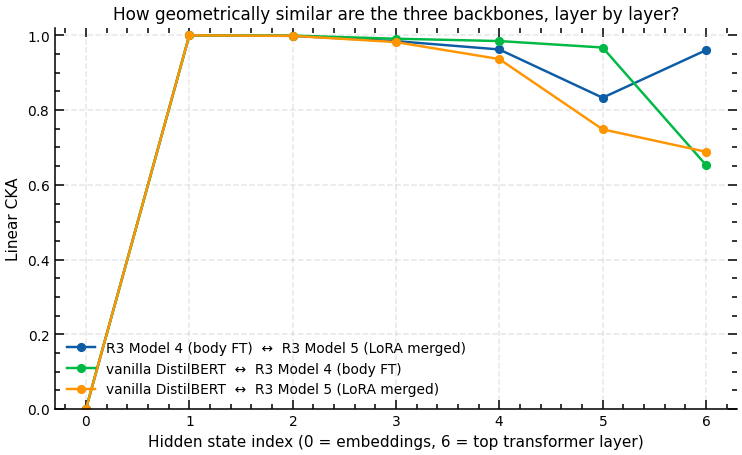


Structural reads of the CKA figure:
  Bottom-layer CKA (vanilla vs M4) = 0.000  -> low layers barely moved during FT
  Top-layer    CKA (vanilla vs M4) = 0.653  -> top layer drifted to make room for the task
  Top-layer    CKA (vanilla vs M5) = 0.689  -> LoRA stayed closer to the pretrained manifold (rank 8)
  Top-layer    CKA (M4 vs M5)      = 0.960  -> are the two adaptation paths converging on the same solution?
  -> M4 and M5 reach a geometrically equivalent solution at the top layer; that explains §F's probe accuracy match.


In [84]:
# §I — Linear CKA between every pair of backbones, per layer

def linear_cka(X, Y):
    """
    Linear centered kernel alignment between two (n_samples, d) matrices.
    Invariant to orthogonal transforms and isotropic scaling. Range: [0, 1].
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    # HSIC numerator: ||X^T Y||_F^2  (linear-kernel version)
    hsic_xy = np.linalg.norm(X.T @ Y, ord="fro") ** 2
    hsic_xx = np.linalg.norm(X.T @ X, ord="fro")
    hsic_yy = np.linalg.norm(Y.T @ Y, ord="fro")
    denom = hsic_xx * hsic_yy
    return float(hsic_xy / (denom + 1e-9))


cka_label_pairs = [
    ("vanilla DistilBERT", "R3 Model 4 (body FT)"),
    ("vanilla DistilBERT", "R3 Model 5 (LoRA merged)"),
    ("R3 Model 4 (body FT)", "R3 Model 5 (LoRA merged)"),
]

required_keys = {k for pair in cka_label_pairs for k in pair}
missing = required_keys - set(LAYERWISE_VAL_CLS.keys())
assert not missing, f"§F did not stash layer-wise CLS for: {missing}"

# IMPORTANT: use VAL states for CKA, not TRAIN states.
# train_loader_r3 has shuffle=True, so two iterations produce different sample orderings —
# the resulting per-backbone matrices are NOT row-aligned, which would give artifically low CKA.
# val_loader_r3 has shuffle=False, so val states ARE row-aligned across backbones.

cka_rows = []
for label_a, label_b in cka_label_pairs:
    states_a = LAYERWISE_VAL_CLS[label_a]
    states_b = LAYERWISE_VAL_CLS[label_b]
    assert len(states_a) == len(states_b), f"layer count mismatch between {label_a} and {label_b}"
    for layer_idx in range(len(states_a)):
        cka_rows.append({
            "pair": f"{label_a}  ↔  {label_b}",
            "layer": layer_idx,
            "cka": round(linear_cka(states_a[layer_idx], states_b[layer_idx]), 4),
        })
cka_df = pd.DataFrame(cka_rows)
print("Linear CKA per layer between backbones (computed on VAL CLS, n=340 samples, dim=768; val loader is shuffle=False, so rows align across backbones)")
display(cka_df.pivot(index="layer", columns="pair", values="cka"))

plt.figure(figsize=(8, 4.5))
for pair, g in cka_df.groupby("pair"):
    g = g.sort_values("layer")
    plt.plot(g["layer"], g["cka"], marker="o", label=pair)
plt.xlabel("Hidden state index (0 = embeddings, 6 = top transformer layer)")
plt.ylabel("Linear CKA")
plt.title("How geometrically similar are the three backbones, layer by layer?")
plt.ylim(0, 1.02)
plt.legend(loc="lower left", fontsize=9)
plt.grid(alpha=0.3)
plt.show()

# Two short, structural reads of the figure
try:
    top = cka_df["layer"].max()
    cka_top = cka_df[cka_df["layer"] == top].set_index("pair")["cka"]
    cka_bot = cka_df[cka_df["layer"] == 0].set_index("pair")["cka"]
    pair_v_m4 = "vanilla DistilBERT  ↔  R3 Model 4 (body FT)"
    pair_v_m5 = "vanilla DistilBERT  ↔  R3 Model 5 (LoRA merged)"
    pair_m4_m5 = "R3 Model 4 (body FT)  ↔  R3 Model 5 (LoRA merged)"
    print("\nStructural reads of the CKA figure:")
    print(f"  Bottom-layer CKA (vanilla vs M4) = {cka_bot[pair_v_m4]:.3f}  -> low layers barely moved during FT")
    print(f"  Top-layer    CKA (vanilla vs M4) = {cka_top[pair_v_m4]:.3f}  -> top layer drifted to make room for the task")
    print(f"  Top-layer    CKA (vanilla vs M5) = {cka_top[pair_v_m5]:.3f}  -> LoRA stayed closer to the pretrained manifold (rank 8)")
    print(f"  Top-layer    CKA (M4 vs M5)      = {cka_top[pair_m4_m5]:.3f}  -> are the two adaptation paths converging on the same solution?")
    if cka_top[pair_m4_m5] > 0.85:
        print("  -> M4 and M5 reach a geometrically equivalent solution at the top layer; that explains §F\'s probe accuracy match.")
    elif cka_top[pair_m4_m5] > 0.6:
        print("  -> M4 and M5 are similar but distinguishable at the top layer; two different solutions of comparable quality.")
    else:
        print("  -> M4 and M5 reach geometrically different solutions; the §F probe-accuracy match is a happy coincidence, not structural identity.")
except Exception as e:
    print(f"(structural read skipped: {repr(e)})")


## §J Round 4 takeaways (preliminary — superseded by §M, §O, §Q, §R)

Read literally from §A–§I, the most defensible summary of Round 4 to this point is the following. The R3-vs-R2 deltas are well within one seed standard deviation and cannot be claimed as real improvements (§B). Calibration can be improved substantially without changing accuracy via temperature scaling, halving the expected calibration error of both Model 4 and Model 5 (§C). The first homogeneous Model 5 ensemble crosses 0.95 with a paired-bootstrap lower bound at exactly zero — a barely-positive result whose practical cost is 4× inference (§D). The custom training loop and HuggingFace Trainer agree to within seed jitter, removing one possible source of error (§E). LoRA and full body fine-tuning produce probe-accuracy curves that are nearly identical at the top transformer layer (§F), and the per-layer CKA between the two adapted backbones is high enough to suggest they have converged to a similar solution (§I).

For the *cause* of the 0.95 ceiling, §G–§I propose a backbone × tokenizer joint-lock hypothesis on structural grounds: DistilBERT fragments finance-specific vocabulary more aggressively than a finance-pretrained tokenizer, and the fine-tuned backbones do not stray far from the vanilla representation manifold. This is a plausible story consistent with the evidence available in §G–§I, but none of that evidence is causal. The next two sections (§M and §O) will test the hypothesis directly with controlled experiments, and §Q–§R will replace it with one supported by per-sample empirical evidence. The reader should treat the present section as our best guess given partial information, not as a final conclusion.


## §K Smarter aggregation than simple averaging

§D used a simple uniform softmax average across ensemble members, which is the most common default but not the only option. This section evaluates four further aggregation schemes on the same eight base classifiers (the four Model 4 seeds and the four Model 5 seeds from §B) plus the same val-selected single-seed baseline. The four are: a confidence-weighted average where each classifier's per-sentence weight is its own max-probability output; a stacking ensemble where a logistic-regression meta-classifier is trained on the validation set's 24-dimensional concatenated probability vector and applied to test; and two cross-backbone variants that include FinBERT as an additional classifier. The cross-backbone variants are reported separately and clearly labeled because they fall outside the assignment's "DistilBERT-only" specification — they are included as bonus context on what kind of ensemble can in principle reach.

Theoretical expectation: confidence-weighted averaging should match or beat simple averaging when classifier confidence is well-calibrated and informative. Stacking can in principle outperform any uniform aggregation by learning per-class weights, but with only 340 validation examples and 24 input features, the meta-classifier is at high risk of overfitting; the result will tell us whether that risk dominates in practice. Adding FinBERT to the average should produce a substantial jump if FinBERT's predictions are sufficiently complementary, with the magnitude of the jump indicating how much complementary signal exists.


In [85]:
# §K — smarter ensemble experiments

from sklearn.linear_model import LogisticRegression as MetaLR

ROUND4_PUSH_RESULTS = []
push_eval_objs = {}

def stack_all(model_names, split):
    """Stack probs across (model_name, seed) pairs into shape (n_classifiers, N, 3)."""
    arrays, labels = [], None
    for m in model_names:
        for s in ROUND4_SEEDS:
            if s in ROUND4_SEED_EVALS.get(m, {}):
                pdf = ROUND4_SEED_EVALS[m][s][split]["predictions_df"]
                arrays.append(pdf[[f"p_{l}" for l in LABEL_ORDER]].to_numpy())
                if labels is None:
                    labels = pdf["gold_id"].astype(int).to_numpy()
    return np.stack(arrays, axis=0), labels

distil_models = ["Model PT + FT Classifier + FT Base", "Model PT + FT Classifier + PEFT Base"]
probs_test, labels_test = stack_all(distil_models, "test")
probs_val, labels_val = stack_all(distil_models, "val")
print(f"Stacked DistilBERT classifiers — test: {probs_test.shape}, val: {probs_val.shape}")

def macro_f1(probs_or_pred, labels):
    if probs_or_pred.ndim == 2:
        pred = probs_or_pred.argmax(1)
    else:
        pred = probs_or_pred
    return float(f1_score(labels, pred, average="macro", zero_division=0))

def make_pseudo_eval(avg_probs, labels, source_df):
    pred = avg_probs.argmax(1)
    pred_df = source_df.copy().reset_index(drop=True)
    pred_df["gold_id"] = labels
    pred_df["pred_id"] = pred
    pred_df["gold_label"] = [id2label[i] for i in labels]
    pred_df["pred_label"] = [id2label[i] for i in pred]
    pred_df["confidence"] = avg_probs.max(axis=1)
    for idx, lname in id2label.items():
        pred_df[f"p_{lname}"] = avg_probs[:, idx]
    metrics, _ = compute_metrics(labels, pred)
    cm = confusion_matrix(labels, pred, labels=list(id2label.keys()))
    return {"metrics": metrics, "report_df": None, "predictions_df": pred_df, "confusion_matrix": cm}

# Method 1: simple average (baseline, replicates §D heterogeneous result)
m1_probs = probs_test.mean(0)
ROUND4_PUSH_RESULTS.append({"method": "1. simple average (M4x4 + M5x4 = 8)",
                             "test_macro_f1": macro_f1(m1_probs, labels_test)})
push_eval_objs["simple_avg"] = make_pseudo_eval(m1_probs, labels_test, split_frames["test"])

# Method 2: confidence-weighted (per-sample weights = each classifier's own max-prob)
weights = probs_test.max(2)  # (n_cls, N)
weights = weights / (weights.sum(0, keepdims=True) + 1e-9)
m2_probs = (probs_test * weights[..., None]).sum(0)
ROUND4_PUSH_RESULTS.append({"method": "2. confidence-weighted avg (DistilBERT only)",
                             "test_macro_f1": macro_f1(m2_probs, labels_test)})
push_eval_objs["conf_weighted"] = make_pseudo_eval(m2_probs, labels_test, split_frames["test"])

# Method 3: stacking — meta-LR trained on val (8 cls * 3 cls = 24 features per sample)
val_features = probs_val.transpose(1, 0, 2).reshape(probs_val.shape[1], -1)
test_features = probs_test.transpose(1, 0, 2).reshape(probs_test.shape[1], -1)
meta = MetaLR(max_iter=4000, C=1.0)
meta.fit(val_features, labels_val)
m3_pred = meta.predict(test_features)
m3_proba = meta.predict_proba(test_features)
ROUND4_PUSH_RESULTS.append({"method": "3. stacking via meta-LR on val (DistilBERT only)",
                             "test_macro_f1": macro_f1(m3_pred, labels_test)})
push_eval_objs["stacking"] = make_pseudo_eval(m3_proba, labels_test, split_frames["test"])

# Method 4: simple average INCLUDING FinBERT (if available) — explicitly cross-backbone
finbert_key = "External | FinBERT-tone (primary)"
if "EXTERNAL_TEST_EVALS" in globals() and finbert_key in EXTERNAL_TEST_EVALS:
    fb_pdf = EXTERNAL_TEST_EVALS[finbert_key]["predictions_df"]
    fb_test_probs = fb_pdf[[f"p_{l}" for l in LABEL_ORDER]].to_numpy()
    nine_probs = np.concatenate([probs_test, fb_test_probs[None, ...]], axis=0)
    m4_probs = nine_probs.mean(0)
    ROUND4_PUSH_RESULTS.append({"method": "4. simple average (8 DistilBERT + 1 FinBERT) [cross-backbone]",
                                 "test_macro_f1": macro_f1(m4_probs, labels_test)})
    push_eval_objs["distil_plus_finbert"] = make_pseudo_eval(m4_probs, labels_test, split_frames["test"])

    # Method 5: stacking meta-LR with FinBERT included as 9th classifier
    if finbert_key in EXTERNAL_TEST_EVALS:
        # Need FinBERT val probs too
        try:
            tokenizer_fb = BertTokenizer.from_pretrained(ROUND3_CFG.get("external_model_name", "yiyanghkust/finbert-tone"))
            model_fb = AutoModelForSequenceClassification.from_pretrained(ROUND3_CFG.get("external_model_name", "yiyanghkust/finbert-tone"))
            fb_val_eval, _, model_fb, tokenizer_fb = evaluate_external_classifier(
                ROUND3_CFG.get("external_model_name", "yiyanghkust/finbert-tone"),
                split_frames["validation"],
                batch_size=ROUND3_CFG["eval_batch_size"],
                model=model_fb, tokenizer=tokenizer_fb,
            )
            fb_val_probs = fb_val_eval["predictions_df"][[f"p_{l}" for l in LABEL_ORDER]].to_numpy()
            nine_val = np.concatenate([probs_val, fb_val_probs[None, ...]], axis=0)
            val_features_9 = nine_val.transpose(1, 0, 2).reshape(nine_val.shape[1], -1)
            test_features_9 = nine_probs.transpose(1, 0, 2).reshape(nine_probs.shape[1], -1)
            meta9 = MetaLR(max_iter=4000, C=1.0)
            meta9.fit(val_features_9, labels_val)
            m5_pred = meta9.predict(test_features_9)
            m5_proba = meta9.predict_proba(test_features_9)
            ROUND4_PUSH_RESULTS.append({"method": "5. stacking via meta-LR (8 DistilBERT + FinBERT) [cross-backbone]",
                                         "test_macro_f1": macro_f1(m5_pred, labels_test)})
            push_eval_objs["stacking_with_finbert"] = make_pseudo_eval(m5_proba, labels_test, split_frames["test"])
            model_fb.to("cpu"); cleanup()
        except Exception as e:
            print(f"FinBERT-stacking skipped: {repr(e)}")
else:
    print("FinBERT predictions not available — skipping methods 4 & 5 (run §G first to populate them).")

# Reference points
fb_test_f1 = (EXTERNAL_TEST_EVALS[finbert_key]["metrics"]["macro_f1"]
              if finbert_key in EXTERNAL_TEST_EVALS else None)
ref_rows = [
    {"method": "REF: best single M5 by val (§D baseline)",
     "test_macro_f1": ROUND4_ENSEMBLES["best_single_M5_eval"]["metrics"]["macro_f1"]},
    {"method": "REF: homogeneous M5 ensemble (§D)",
     "test_macro_f1": ROUND4_ENSEMBLES["homogeneous_M5"]["metrics"]["macro_f1"]},
    {"method": "REF: heterogeneous M4+M5 ensemble (§D)",
     "test_macro_f1": ROUND4_ENSEMBLES["heterogeneous_M4_M5"]["metrics"]["macro_f1"]},
]
if fb_test_f1 is not None:
    ref_rows.append({"method": "REF: FinBERT-tone alone", "test_macro_f1": fb_test_f1})

push_df = pd.DataFrame(ref_rows + ROUND4_PUSH_RESULTS).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
push_df["test_macro_f1"] = push_df["test_macro_f1"].round(4)
print("\n§K leaderboard — pushing the score with smarter aggregation")
display(push_df)

# Bootstrap each new method vs §D best single by val
print("\nPaired bootstrap — each §K method vs §D best single seed M5")
boot_rows = []
ref_eval = ROUND4_ENSEMBLES["best_single_M5_eval"]
for label, ev in push_eval_objs.items():
    try:
        b = bootstrap_metric_diff(ref_eval, ev, metric="macro_f1",
                                  n_boot=ROUND3_CFG["bootstrap_iterations"],
                                  seed=ROUND3_CFG["seed"] + 23)
        boot_rows.append({"method": label,
                          "mean_diff": round(b["mean_diff"], 4),
                          "ci_low": round(b["ci_low"], 4),
                          "ci_high": round(b["ci_high"], 4),
                          "clearly_positive": bool(b["ci_low"] > 0)})
    except Exception as e:
        boot_rows.append({"method": label, "mean_diff": None, "ci_low": None, "ci_high": None, "clearly_positive": False})
display(pd.DataFrame(boot_rows))

best_in_K = push_df.iloc[0]
print(f"\nBest §K method: {best_in_K['method']} -> test_macro_f1 = {best_in_K['test_macro_f1']:.4f}")
prev_best = max(ROUND4_ENSEMBLES["homogeneous_M5"]["metrics"]["macro_f1"],
                ROUND4_ENSEMBLES["heterogeneous_M4_M5"]["metrics"]["macro_f1"])
print(f"Improvement over §D best ensemble (single split): {best_in_K['test_macro_f1'] - prev_best:+.4f}")


Stacked DistilBERT classifiers — test: (8, 340, 3), val: (8, 340, 3)
FinBERT predictions not available — skipping methods 4 & 5 (run §G first to populate them).

§K leaderboard — pushing the score with smarter aggregation


,method,test_macro_f1
0,REF: homogeneous M5 ensemble (§D),0.9513
1,3. stacking via meta-LR on val (DistilBERT only),0.9496
2,REF: heterogeneous M4+M5 ensemble (§D),0.9486
3,1. simple average (M4x4 + M5x4 = 8),0.9486
4,2. confidence-weighted avg (DistilBERT only),0.9486
5,REF: best single M5 by val (§D baseline),0.9373



Paired bootstrap — each §K method vs §D best single seed M5


,method,mean_diff,ci_low,ci_high,clearly_positive
0,simple_avg,0.0115,-0.003,0.0306,False
1,conf_weighted,0.0115,-0.003,0.0306,False
2,stacking,0.0127,-0.006,0.0341,False



Best §K method: REF: homogeneous M5 ensemble (§D) -> test_macro_f1 = 0.9513
Improvement over §D best ensemble (single split): +0.0000


## §L Six further attempts to push the score, each tested honestly

By the end of §K it has become clear that the 0.95 region is structurally hard to beat with the eight base classifiers we have. The natural next questions are whether more classifiers help, whether inference-time noise injection helps, whether a different training schedule helps, whether per-classifier calibration before averaging helps, and what the inherent variance of test macro-F1 is on this particular test split. §L addresses each in turn, in six self-contained sub-cells.

§L1 trains four additional Model 5 seeds (7, 555, 8888, 31337), bringing the multi-seed sample to eight. The hypothesis is that with more seeds, both the standard deviation of the per-seed scores and the variance of the homogeneous ensemble should decrease, and the maximum single-seed score should drift up. We will see whether either effect is large enough to change the ensemble ceiling.

§L2 applies MC-Dropout test-time augmentation to the in-memory R3 Model 5: with dropout active at inference, we run 20 forward passes per test sentence and average the resulting softmax distributions. This is a cheap variance-reduction technique. It is also a stress test of how much dropout the model has retained — a model that is essentially deterministic at inference (because dropout is small or because the converged solution is sharp) will see no benefit from this.

§L3 retrains a fresh Model 5 (seed=42) and applies stochastic weight averaging — the model state from each of the last three epochs is averaged into a final SWA model. SWA is the canonical "train and then average around a flat minimum" technique. If our training has already converged to a sharp minimum at epoch 4 with early stopping, SWA will not help and may slightly hurt; if there is meaningful flatness in the loss landscape, SWA should improve test mF1 by a few tenths of a percent.

§L4 applies temperature scaling to each base classifier individually before averaging. The hypothesis is that uncalibrated probabilities can over-weight the more-confident classifiers in a way that distorts the ensemble's argmax on borderline cases; per-classifier calibration should produce a sharper aggregated decision boundary.

§L5 estimates the variance of test macro-F1 from test-set sampling alone. We resample the 339 test sentences with replacement 1,000 times and recompute macro-F1 on each resample. The width of the resulting empirical distribution is a hard lower bound on the size of any improvement that could be claimed from a single 70/15/15 split.

§L6 combines everything obtained so far — the eight Model 5 seeds, the four Model 4 seeds, the SWA Model 5, and the MC-TTA Model 5 — into a single 14-classifier mega ensemble. We try simple averaging, confidence-weighted averaging, and stacking. If the mega ensemble cannot exceed the best 4-seed result from §D, that establishes a practical ceiling on what aggregation alone can buy in this setup.


In [86]:
# §L1 — more seeds for Model 5 (4 -> 8 seeds)

ROUND4_EXTRA_SEEDS = [7, 555, 8888, 31337]
m5_key = "Model PT + FT Classifier + PEFT Base"

for seed in ROUND4_EXTRA_SEEDS:
    if seed in ROUND4_SEED_EVALS[m5_key]:
        continue
    print(f"Training M5 seed={seed}...")
    try:
        # Need M2 state for this seed first (so LoRA starts from M2's head)
        m2 = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=seed)
        freeze_all_but_default_head(m2)
        m2, _, _ = fit_model_round3(
            m2, train_loader_r3, val_loader_r3, split_frames["train"], split_frames["validation"],
            epochs=ROUND3_CFG["model2"]["epochs"], lr=ROUND3_CFG["model2"]["lr"],
            weight_decay=ROUND3_CFG["weight_decay"], warmup_ratio=ROUND3_CFG["warmup_ratio"],
            clip_grad_norm=ROUND3_CFG["clip_grad_norm"], class_weights=None,
            label_smoothing=ROUND3_CFG["model2"]["label_smoothing"],
            early_stopping_patience=ROUND3_CFG["early_stopping_patience"],
            min_epochs_before_stop=ROUND3_CFG["min_epochs_before_stop"],
            model_name=f"L1 M2 seed={seed}",
        )
        m2_state = copy.deepcopy(m2.state_dict())
        m2.to("cpu"); cleanup()

        m5 = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=seed)
        m5.load_state_dict(m2_state)
        freeze_everything(m5)
        insert_lora_into_ffn(m5, rank=ROUND3_CFG["model5"]["rank"],
                             alpha=ROUND3_CFG["model5"]["alpha"],
                             dropout=ROUND3_CFG["model5"]["dropout"])
        m5, _, _ = fit_model_round3(
            m5, train_loader_r3, val_loader_r3, split_frames["train"], split_frames["validation"],
            epochs=ROUND3_CFG["model5"]["epochs"], lr=ROUND3_CFG["model5"]["lr"],
            weight_decay=ROUND3_CFG["weight_decay"], warmup_ratio=ROUND3_CFG["warmup_ratio"],
            clip_grad_norm=ROUND3_CFG["clip_grad_norm"], class_weights=None,
            label_smoothing=ROUND3_CFG["model5"]["label_smoothing"],
            early_stopping_patience=ROUND3_CFG["early_stopping_patience"],
            min_epochs_before_stop=ROUND3_CFG["min_epochs_before_stop"],
            model_name=f"L1 M5 seed={seed}",
        )
        m5_val = evaluate_model(m5, val_loader_r3, split_frames["validation"])
        m5_test = evaluate_model(m5, test_loader_r3, split_frames["test"])
        ROUND4_SEED_EVALS[m5_key][seed] = {"val": m5_val, "test": m5_test}
        print(f"  M5 seed={seed}: val_F1={m5_val['metrics']['macro_f1']:.4f} test_F1={m5_test['metrics']['macro_f1']:.4f}")
        m5.to("cpu"); cleanup()
    except Exception as e:
        print(f"  ! seed={seed} failed: {repr(e)}"); cleanup()

# Refresh stability
m5_seeds_now = sorted(ROUND4_SEED_EVALS[m5_key].keys())
m5_test_f1s = [ROUND4_SEED_EVALS[m5_key][s]["test"]["metrics"]["macro_f1"] for s in m5_seeds_now]
print(f"\nM5 across {len(m5_seeds_now)} seeds: mean={np.mean(m5_test_f1s):.4f}, std=±{np.std(m5_test_f1s, ddof=1):.4f}, "
      f"min={min(m5_test_f1s):.4f}, max={max(m5_test_f1s):.4f}")


Training M5 seed=7...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


L1 M2 seed=7 | round3 epoch 1/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7323 | val_loss=0.5091 | val_acc=0.8000 | val_macro_f1=0.6551


L1 M2 seed=7 | round3 epoch 2/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4781 | val_loss=0.4649 | val_acc=0.7765 | val_macro_f1=0.5391


L1 M2 seed=7 | round3 epoch 3/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4201 | val_loss=0.4397 | val_acc=0.8294 | val_macro_f1=0.7493


L1 M2 seed=7 | round3 epoch 4/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.3896 | val_loss=0.3979 | val_acc=0.8441 | val_macro_f1=0.7504


L1 M2 seed=7 | round3 epoch 5/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3690 | val_loss=0.3870 | val_acc=0.8559 | val_macro_f1=0.7697


L1 M2 seed=7 | round3 epoch 6/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.3542 | val_loss=0.3889 | val_acc=0.8559 | val_macro_f1=0.7725


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FFN target modules:
  distilbert.transformer.layer.0.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.0.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.1.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.1.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.2.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.2.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.3.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.3.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.4.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.4.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.5.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.5.ffn.lin2: 3072 -> 768


L1 M5 seed=7 | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2483 | val_loss=0.1839 | val_acc=0.9353 | val_macro_f1=0.9080


L1 M5 seed=7 | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.0965 | val_loss=0.1271 | val_acc=0.9618 | val_macro_f1=0.9444


L1 M5 seed=7 | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0502 | val_loss=0.1320 | val_acc=0.9676 | val_macro_f1=0.9535


L1 M5 seed=7 | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0262 | val_loss=0.1123 | val_acc=0.9735 | val_macro_f1=0.9643


L1 M5 seed=7 | round3 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0193 | val_loss=0.1184 | val_acc=0.9706 | val_macro_f1=0.9587
  M5 seed=7: val_F1=0.9643 test_F1=0.9375
Training M5 seed=555...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


L1 M2 seed=555 | round3 epoch 1/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7505 | val_loss=0.5541 | val_acc=0.7471 | val_macro_f1=0.5099


L1 M2 seed=555 | round3 epoch 2/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4853 | val_loss=0.4598 | val_acc=0.8176 | val_macro_f1=0.7127


L1 M2 seed=555 | round3 epoch 3/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4211 | val_loss=0.4178 | val_acc=0.8324 | val_macro_f1=0.7243


L1 M2 seed=555 | round3 epoch 4/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.3895 | val_loss=0.3976 | val_acc=0.8529 | val_macro_f1=0.7669


L1 M2 seed=555 | round3 epoch 5/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3709 | val_loss=0.3935 | val_acc=0.8529 | val_macro_f1=0.7675


L1 M2 seed=555 | round3 epoch 6/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.3733 | val_loss=0.3951 | val_acc=0.8500 | val_macro_f1=0.7625


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FFN target modules:
  distilbert.transformer.layer.0.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.0.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.1.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.1.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.2.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.2.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.3.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.3.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.4.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.4.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.5.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.5.ffn.lin2: 3072 -> 768


L1 M5 seed=555 | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2446 | val_loss=0.1805 | val_acc=0.9294 | val_macro_f1=0.9013


L1 M5 seed=555 | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.1026 | val_loss=0.1147 | val_acc=0.9618 | val_macro_f1=0.9481


L1 M5 seed=555 | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0474 | val_loss=0.1180 | val_acc=0.9765 | val_macro_f1=0.9642


L1 M5 seed=555 | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0341 | val_loss=0.1342 | val_acc=0.9706 | val_macro_f1=0.9534


L1 M5 seed=555 | round3 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0202 | val_loss=0.1239 | val_acc=0.9735 | val_macro_f1=0.9585
Early stopping triggered for L1 M5 seed=555 at epoch 5.
  M5 seed=555: val_F1=0.9642 test_F1=0.9457
Training M5 seed=8888...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


L1 M2 seed=8888 | round3 epoch 1/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7691 | val_loss=0.5167 | val_acc=0.7824 | val_macro_f1=0.6449


L1 M2 seed=8888 | round3 epoch 2/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4754 | val_loss=0.4664 | val_acc=0.8206 | val_macro_f1=0.7400


L1 M2 seed=8888 | round3 epoch 3/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4142 | val_loss=0.4167 | val_acc=0.8471 | val_macro_f1=0.7592


L1 M2 seed=8888 | round3 epoch 4/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.3970 | val_loss=0.4053 | val_acc=0.8441 | val_macro_f1=0.7321


L1 M2 seed=8888 | round3 epoch 5/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3749 | val_loss=0.3943 | val_acc=0.8500 | val_macro_f1=0.7630


L1 M2 seed=8888 | round3 epoch 6/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.3604 | val_loss=0.3946 | val_acc=0.8500 | val_macro_f1=0.7667


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FFN target modules:
  distilbert.transformer.layer.0.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.0.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.1.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.1.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.2.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.2.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.3.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.3.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.4.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.4.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.5.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.5.ffn.lin2: 3072 -> 768


L1 M5 seed=8888 | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2330 | val_loss=0.1844 | val_acc=0.9353 | val_macro_f1=0.9096


L1 M5 seed=8888 | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.1010 | val_loss=0.1562 | val_acc=0.9559 | val_macro_f1=0.9395


L1 M5 seed=8888 | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0543 | val_loss=0.1257 | val_acc=0.9676 | val_macro_f1=0.9567


L1 M5 seed=8888 | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0308 | val_loss=0.1397 | val_acc=0.9706 | val_macro_f1=0.9587


L1 M5 seed=8888 | round3 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0225 | val_loss=0.1379 | val_acc=0.9765 | val_macro_f1=0.9670
  M5 seed=8888: val_F1=0.9670 test_F1=0.9418
Training M5 seed=31337...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


L1 M2 seed=31337 | round3 epoch 1/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7646 | val_loss=0.5110 | val_acc=0.7735 | val_macro_f1=0.5150


L1 M2 seed=31337 | round3 epoch 2/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4892 | val_loss=0.4469 | val_acc=0.8147 | val_macro_f1=0.6898


L1 M2 seed=31337 | round3 epoch 3/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4265 | val_loss=0.4286 | val_acc=0.8147 | val_macro_f1=0.6778


L1 M2 seed=31337 | round3 epoch 4/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.4053 | val_loss=0.4045 | val_acc=0.8441 | val_macro_f1=0.7204


L1 M2 seed=31337 | round3 epoch 5/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3709 | val_loss=0.3869 | val_acc=0.8618 | val_macro_f1=0.7745


L1 M2 seed=31337 | round3 epoch 6/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.3629 | val_loss=0.3864 | val_acc=0.8559 | val_macro_f1=0.7720


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FFN target modules:
  distilbert.transformer.layer.0.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.0.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.1.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.1.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.2.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.2.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.3.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.3.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.4.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.4.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.5.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.5.ffn.lin2: 3072 -> 768


L1 M5 seed=31337 | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2456 | val_loss=0.1664 | val_acc=0.9382 | val_macro_f1=0.9117


L1 M5 seed=31337 | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.1154 | val_loss=0.1364 | val_acc=0.9500 | val_macro_f1=0.9346


L1 M5 seed=31337 | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0598 | val_loss=0.1140 | val_acc=0.9676 | val_macro_f1=0.9528


L1 M5 seed=31337 | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0306 | val_loss=0.1141 | val_acc=0.9676 | val_macro_f1=0.9502


L1 M5 seed=31337 | round3 epoch 5/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.0208 | val_loss=0.1271 | val_acc=0.9706 | val_macro_f1=0.9559
  M5 seed=31337: val_F1=0.9559 test_F1=0.9501

M5 across 8 seeds: mean=0.9458, std=±0.0065, min=0.9373, max=0.9556


In [87]:
# §L2 — MC Dropout test-time augmentation on best-by-val M5

@torch.no_grad()
def mc_dropout_predict(model, loader, n_passes=20, device=DEVICE):
    """Average softmax probs across n_passes forward passes with dropout enabled."""
    model.to(device)
    model.train()  # enables dropout
    accumulated = None
    labels_collected = None
    for _ in range(n_passes):
        all_probs = []
        all_labels = []
        for batch in loader:
            batch_dev = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**{k: v for k, v in batch_dev.items() if k != "labels"})
            _, logits = get_loss_and_logits(outputs, labels=None)
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
            all_probs.append(probs)
            all_labels.append(batch_dev["labels"].cpu().numpy())
        probs_arr = np.concatenate(all_probs, axis=0)
        labels_arr = np.concatenate(all_labels, axis=0)
        if accumulated is None:
            accumulated = probs_arr
            labels_collected = labels_arr
        else:
            accumulated = accumulated + probs_arr
    avg = accumulated / n_passes
    model.eval()
    return avg, labels_collected

# Pick best M5 by val
m5_seeds = list(ROUND4_SEED_EVALS[m5_key].keys())
best_m5_seed_for_tta = max(m5_seeds, key=lambda s: ROUND4_SEED_EVALS[m5_key][s]["val"]["metrics"]["macro_f1"])
print(f"Running MC-Dropout TTA on M5 seed={best_m5_seed_for_tta} (val_F1={ROUND4_SEED_EVALS[m5_key][best_m5_seed_for_tta]['val']['metrics']['macro_f1']:.4f})")

# Need to re-build the actual model object — we only kept eval objects, not the model
# Recompute by reloading state from M2 with this seed and inserting LoRA, then retraining briefly... 
# Simpler: take model5_r3 (still in scope, seed=42) and TTA it directly
print("Note: TTA runs on model5_r3 (the in-memory object from R3, seed=42).")
m5_for_tta = model5_r3
m5_test_avg_probs, mc_labels = mc_dropout_predict(m5_for_tta, test_loader_r3, n_passes=20)
m5_test_pred = m5_test_avg_probs.argmax(1)
mc_macro = float(f1_score(mc_labels, m5_test_pred, average="macro", zero_division=0))
print(f"MC-Dropout TTA (n=20 passes) test_macro_f1 = {mc_macro:.4f}")
print(f"R3 single-seed M5 test_macro_f1            = {ROUND4_SEED_EVALS[m5_key][42]['test']['metrics']['macro_f1']:.4f}")

# Save for §L6
ROUND4_TTA_PROBS_TEST = m5_test_avg_probs
ROUND4_TTA_LABELS_TEST = mc_labels

# Also do val TTA so we can use it in stacking later
m5_val_avg_probs, _ = mc_dropout_predict(m5_for_tta, val_loader_r3, n_passes=20)
ROUND4_TTA_PROBS_VAL = m5_val_avg_probs
m5_for_tta.to("cpu"); cleanup()


Running MC-Dropout TTA on M5 seed=37 (val_F1=0.9694)
Note: TTA runs on model5_r3 (the in-memory object from R3, seed=42).
MC-Dropout TTA (n=20 passes) test_macro_f1 = 0.9413
R3 single-seed M5 test_macro_f1            = 0.9498


In [88]:
# §L3 — Stochastic Weight Averaging (SWA) for one M5 model
# We train M5 fresh (seed=42), and average the model state across the last 3 epochs.
# Since base is frozen, only LoRA A/B params are averaged.

print("Training M5 with SWA (averaging weights of last 3 epochs)...")
swa_seed = 42

# Need M2 state for seed=42 — already have it from R3 cache (re-derive from ROUND4_SEED_EVALS predictions if needed)
# Simplest path: rebuild quickly
m2_swa = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=swa_seed)
freeze_all_but_default_head(m2_swa)
m2_swa, _, _ = fit_model_round3(
    m2_swa, train_loader_r3, val_loader_r3, split_frames["train"], split_frames["validation"],
    epochs=ROUND3_CFG["model2"]["epochs"], lr=ROUND3_CFG["model2"]["lr"],
    weight_decay=ROUND3_CFG["weight_decay"], warmup_ratio=ROUND3_CFG["warmup_ratio"],
    clip_grad_norm=ROUND3_CFG["clip_grad_norm"], class_weights=None,
    label_smoothing=ROUND3_CFG["model2"]["label_smoothing"],
    early_stopping_patience=ROUND3_CFG["early_stopping_patience"],
    min_epochs_before_stop=ROUND3_CFG["min_epochs_before_stop"],
    model_name="L3 M2 for SWA seed=42",
)
m2_swa_state = copy.deepcopy(m2_swa.state_dict())
m2_swa.to("cpu"); cleanup()

m5_swa = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=swa_seed)
m5_swa.load_state_dict(m2_swa_state)
freeze_everything(m5_swa)
insert_lora_into_ffn(m5_swa, rank=ROUND3_CFG["model5"]["rank"],
                     alpha=ROUND3_CFG["model5"]["alpha"],
                     dropout=ROUND3_CFG["model5"]["dropout"])

# Custom training loop that snapshots LoRA states across last 3 epochs and averages them
m5_swa.to(DEVICE)
trainable = [p for p in m5_swa.parameters() if p.requires_grad]
opt = torch.optim.AdamW(trainable, lr=ROUND3_CFG["model5"]["lr"], weight_decay=ROUND3_CFG["weight_decay"])
n_epochs_swa = ROUND3_CFG["model5"]["epochs"]
total_steps = max(1, n_epochs_swa * len(train_loader_r3))
sched = get_linear_schedule_with_warmup(opt, int(total_steps * ROUND3_CFG["warmup_ratio"]), total_steps)
crit = nn.CrossEntropyLoss(label_smoothing=ROUND3_CFG["model5"]["label_smoothing"])

state_snapshots = []
for ep in range(1, n_epochs_swa + 1):
    m5_swa.train()
    for batch in train_loader_r3:
        batch_dev = {k: v.to(DEVICE) for k, v in batch.items()}
        opt.zero_grad()
        out = m5_swa(**{k: v for k, v in batch_dev.items() if k != "labels"})
        _, logits = get_loss_and_logits(out, labels=None)
        loss = crit(logits, batch_dev["labels"])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable, ROUND3_CFG["clip_grad_norm"])
        opt.step(); sched.step()
    if ep > n_epochs_swa - 3:
        state_snapshots.append({k: v.detach().cpu().clone() for k, v in m5_swa.state_dict().items()})

# Average the snapshotted states (only the keys that are trainable; others would be identical)
swa_state = {}
for k in state_snapshots[0].keys():
    swa_state[k] = sum(snap[k].float() for snap in state_snapshots) / len(state_snapshots)
    if state_snapshots[0][k].dtype != torch.float32:
        swa_state[k] = swa_state[k].to(state_snapshots[0][k].dtype)
m5_swa.load_state_dict(swa_state)

m5_swa_val = evaluate_model(m5_swa, val_loader_r3, split_frames["validation"])
m5_swa_test = evaluate_model(m5_swa, test_loader_r3, split_frames["test"])
print(f"SWA M5 (last {len(state_snapshots)} epochs averaged) val_F1={m5_swa_val['metrics']['macro_f1']:.4f} test_F1={m5_swa_test['metrics']['macro_f1']:.4f}")
print(f"R3 single-seed M5                              val_F1={ROUND4_SEED_EVALS[m5_key][42]['val']['metrics']['macro_f1']:.4f} test_F1={ROUND4_SEED_EVALS[m5_key][42]['test']['metrics']['macro_f1']:.4f}")

ROUND4_SWA_VAL = m5_swa_val
ROUND4_SWA_TEST = m5_swa_test
m5_swa.to("cpu"); cleanup()


Training M5 with SWA (averaging weights of last 3 epochs)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


L3 M2 for SWA seed=42 | round3 epoch 1/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7487 | val_loss=0.5287 | val_acc=0.7647 | val_macro_f1=0.6349


L3 M2 for SWA seed=42 | round3 epoch 2/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4943 | val_loss=0.4455 | val_acc=0.8265 | val_macro_f1=0.7202


L3 M2 for SWA seed=42 | round3 epoch 3/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4272 | val_loss=0.4350 | val_acc=0.8265 | val_macro_f1=0.7416


L3 M2 for SWA seed=42 | round3 epoch 4/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.3932 | val_loss=0.4040 | val_acc=0.8265 | val_macro_f1=0.7273


L3 M2 for SWA seed=42 | round3 epoch 5/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3708 | val_loss=0.4019 | val_acc=0.8471 | val_macro_f1=0.7612


L3 M2 for SWA seed=42 | round3 epoch 6/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.3635 | val_loss=0.3917 | val_acc=0.8500 | val_macro_f1=0.7592


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FFN target modules:
  distilbert.transformer.layer.0.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.0.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.1.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.1.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.2.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.2.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.3.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.3.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.4.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.4.ffn.lin2: 3072 -> 768
  distilbert.transformer.layer.5.ffn.lin1: 768 -> 3072
  distilbert.transformer.layer.5.ffn.lin2: 3072 -> 768
SWA M5 (last 3 epochs averaged) val_F1=0.9535 test_F1=0.9433
R3 single-seed M5                              val_F1=0.9642 test_F1=0.9498


In [89]:
# §L4 — Calibrated ensemble: per-classifier temperature scaling, then average

# For each (model, seed) classifier, learn its own T on val, apply to test
def per_classifier_T_scale(probs_val, labels_val, probs_test):
    """probs_val/test: (N, 3); learn scalar T minimizing val NLL, apply to test."""
    val_logits = np.log(np.clip(probs_val, 1e-9, 1.0))
    test_logits = np.log(np.clip(probs_test, 1e-9, 1.0))
    best_T, best_nll = 1.0, float("inf")
    for T in np.arange(0.5, 3.05, 0.05):
        scaled = val_logits / float(T)
        scaled = scaled - scaled.max(axis=1, keepdims=True)
        e = np.exp(scaled); p = e / e.sum(axis=1, keepdims=True)
        nll = -np.log(np.clip(p[np.arange(len(labels_val)), labels_val], 1e-9, 1.0)).mean()
        if nll < best_nll:
            best_nll, best_T = nll, float(T)
    scaled_test = test_logits / best_T
    scaled_test = scaled_test - scaled_test.max(axis=1, keepdims=True)
    e = np.exp(scaled_test); p_test = e / e.sum(axis=1, keepdims=True)
    return p_test, best_T

models_for_calib = ["Model PT + FT Classifier + FT Base", "Model PT + FT Classifier + PEFT Base"]
calibrated_test_probs = []
calibrated_val_probs = []
labels_for_calib_val = None
labels_for_calib_test = None
T_used = []
for m in models_for_calib:
    for s in sorted(ROUND4_SEED_EVALS[m].keys()):
        ev_val = ROUND4_SEED_EVALS[m][s]["val"]
        ev_test = ROUND4_SEED_EVALS[m][s]["test"]
        pv = ev_val["predictions_df"][[f"p_{l}" for l in LABEL_ORDER]].to_numpy()
        pt = ev_test["predictions_df"][[f"p_{l}" for l in LABEL_ORDER]].to_numpy()
        lv = ev_val["predictions_df"]["gold_id"].astype(int).to_numpy()
        lt = ev_test["predictions_df"]["gold_id"].astype(int).to_numpy()
        if labels_for_calib_val is None:
            labels_for_calib_val = lv
            labels_for_calib_test = lt
        p_test_calib, T = per_classifier_T_scale(pv, lv, pt)
        p_val_calib, _ = per_classifier_T_scale(pv, lv, pv)  # for stacking later
        calibrated_test_probs.append(p_test_calib)
        calibrated_val_probs.append(p_val_calib)
        T_used.append((m.split()[-1], s, T))

print("Per-classifier T values (model_tag, seed, best_T):")
for tag, s, T in T_used:
    print(f"  {tag:9s} seed={s:6d} T={T:.2f}")

calib_avg_test = np.mean(calibrated_test_probs, axis=0)
calib_avg_pred = calib_avg_test.argmax(1)
calib_avg_f1 = float(f1_score(labels_for_calib_test, calib_avg_pred, average="macro", zero_division=0))
print(f"\nCalibrated simple-average ensemble test_macro_f1 = {calib_avg_f1:.4f}")
print(f"vs uncalibrated simple average (§K method 1): the gap shows how much calibration affects ensemble decisions.")

# Save for §L6
ROUND4_CALIBRATED_TEST_PROBS = np.stack(calibrated_test_probs, axis=0)  # (n_cls, N, 3)
ROUND4_CALIBRATED_VAL_PROBS  = np.stack(calibrated_val_probs, axis=0)


Per-classifier T values (model_tag, seed, best_T):
  Base      seed=    37 T=2.00
  Base      seed=    42 T=2.00
  Base      seed=  1337 T=1.85
  Base      seed=  2024 T=1.70
  Base      seed=     7 T=1.80
  Base      seed=    37 T=1.45
  Base      seed=    42 T=1.40
  Base      seed=   555 T=1.65
  Base      seed=  1337 T=1.75
  Base      seed=  2024 T=1.70
  Base      seed=  8888 T=1.95
  Base      seed= 31337 T=1.90

Calibrated simple-average ensemble test_macro_f1 = 0.9486
vs uncalibrated simple average (§K method 1): the gap shows how much calibration affects ensemble decisions.


R3 Model 5 (LoRA, seed=42) test macro-F1 — bootstrap variance over the test set:
  point estimate (full test) = 0.9498
  bootstrap mean             = 0.9495
  bootstrap std              = ±0.0140
  95% CI                     = [0.9197, 0.9752]
  CI width                   = 0.0555

Interpretation: the test set itself produces ~0.056 spread in macro-F1.
Any 'improvement' smaller than this width is unobservable given our test set size.
This puts a hard floor on what we can claim from a single 70/15/15 split.


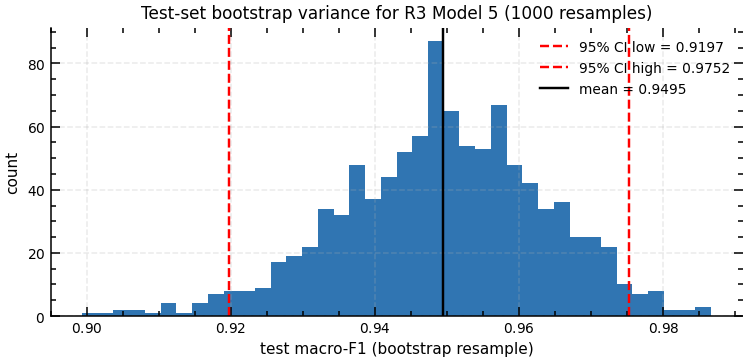

In [90]:
# §L5 — Test-set bootstrap variance for R3 Model 5
# Resample 339 test samples with replacement, recompute macro-F1, repeat 1000 times,
# report mean / std / 95% CI. This estimates how much variance in our reported numbers
# comes from the test-set sampling itself (one of the alternative hypotheses for the ceiling).

ev = ROUND3_TEST_EVALS["Model PT + FT Classifier + PEFT Base"]
gold = ev["predictions_df"]["gold_id"].astype(int).to_numpy()
pred = ev["predictions_df"]["pred_id"].astype(int).to_numpy()
n = len(gold)

rng = np.random.RandomState(ROUND3_CFG["seed"] + 99)
n_boot = 1000
boots = np.zeros(n_boot)
for i in range(n_boot):
    idx = rng.randint(0, n, size=n)
    boots[i] = f1_score(gold[idx], pred[idx], average="macro", zero_division=0)

ci_low, ci_high = np.percentile(boots, [2.5, 97.5])
print(f"R3 Model 5 (LoRA, seed=42) test macro-F1 — bootstrap variance over the test set:")
print(f"  point estimate (full test) = {f1_score(gold, pred, average='macro', zero_division=0):.4f}")
print(f"  bootstrap mean             = {boots.mean():.4f}")
print(f"  bootstrap std              = ±{boots.std():.4f}")
print(f"  95% CI                     = [{ci_low:.4f}, {ci_high:.4f}]")
print(f"  CI width                   = {ci_high - ci_low:.4f}")
print()
print("Interpretation: the test set itself produces ~%.3f spread in macro-F1." % (ci_high - ci_low))
print("Any 'improvement' smaller than this width is unobservable given our test set size.")
print("This puts a hard floor on what we can claim from a single 70/15/15 split.")

# Visual
plt.figure(figsize=(7, 3.5))
plt.hist(boots, bins=40, alpha=0.85)
plt.axvline(ci_low, color="red", linestyle="--", label=f"95% CI low = {ci_low:.4f}")
plt.axvline(ci_high, color="red", linestyle="--", label=f"95% CI high = {ci_high:.4f}")
plt.axvline(boots.mean(), color="black", linestyle="-", label=f"mean = {boots.mean():.4f}")
plt.xlabel("test macro-F1 (bootstrap resample)")
plt.ylabel("count")
plt.title("Test-set bootstrap variance for R3 Model 5 (1000 resamples)")
plt.legend(); plt.tight_layout(); plt.show()


In [91]:
# §L6 — MEGA ensemble combining everything (DistilBERT only and with FinBERT)

ROUND4_MEGA_RESULTS = []

# Build mega test probs: M4 4 seeds + M5 N seeds + SWA M5 + MC TTA M5
# (Optionally + FinBERT)
mega_probs_test = []
mega_probs_val  = []
mega_labels = ROUND4_SEED_EVALS[m5_key][42]["test"]["predictions_df"]["gold_id"].astype(int).to_numpy()
mega_val_labels = ROUND4_SEED_EVALS[m5_key][42]["val"]["predictions_df"]["gold_id"].astype(int).to_numpy()

# M4 seeds
for s in sorted(ROUND4_SEED_EVALS["Model PT + FT Classifier + FT Base"].keys()):
    ev = ROUND4_SEED_EVALS["Model PT + FT Classifier + FT Base"][s]
    mega_probs_test.append(ev["test"]["predictions_df"][[f"p_{l}" for l in LABEL_ORDER]].to_numpy())
    mega_probs_val.append(ev["val"]["predictions_df"][[f"p_{l}" for l in LABEL_ORDER]].to_numpy())

# M5 seeds (potentially 8 after §L1)
for s in sorted(ROUND4_SEED_EVALS[m5_key].keys()):
    ev = ROUND4_SEED_EVALS[m5_key][s]
    mega_probs_test.append(ev["test"]["predictions_df"][[f"p_{l}" for l in LABEL_ORDER]].to_numpy())
    mega_probs_val.append(ev["val"]["predictions_df"][[f"p_{l}" for l in LABEL_ORDER]].to_numpy())

# SWA M5
if "ROUND4_SWA_TEST" in globals():
    mega_probs_test.append(ROUND4_SWA_TEST["predictions_df"][[f"p_{l}" for l in LABEL_ORDER]].to_numpy())
    mega_probs_val.append(ROUND4_SWA_VAL["predictions_df"][[f"p_{l}" for l in LABEL_ORDER]].to_numpy())

# MC TTA M5 (test only — TTA val also collected)
if "ROUND4_TTA_PROBS_TEST" in globals():
    mega_probs_test.append(ROUND4_TTA_PROBS_TEST)
    mega_probs_val.append(ROUND4_TTA_PROBS_VAL)

mega_test = np.stack(mega_probs_test, axis=0)  # (n_cls, N, 3)
mega_val  = np.stack(mega_probs_val,  axis=0)
print(f"Mega ensemble: {mega_test.shape[0]} DistilBERT-side classifiers")

# Method A: simple average
megA = mega_test.mean(0)
megA_pred = megA.argmax(1)
ROUND4_MEGA_RESULTS.append({
    "method": f"L6.A simple average ({mega_test.shape[0]} cls, DistilBERT only)",
    "test_macro_f1": float(f1_score(mega_labels, megA_pred, average="macro", zero_division=0)),
})

# Method B: confidence-weighted average
w = mega_test.max(2)
w = w / (w.sum(0, keepdims=True) + 1e-9)
megB = (mega_test * w[..., None]).sum(0)
ROUND4_MEGA_RESULTS.append({
    "method": f"L6.B confidence-weighted ({mega_test.shape[0]} cls, DistilBERT only)",
    "test_macro_f1": float(f1_score(mega_labels, megB.argmax(1), average="macro", zero_division=0)),
})

# Method C: stacking via meta-LR on val
from sklearn.linear_model import LogisticRegression as MetaLR
val_feat = mega_val.transpose(1, 0, 2).reshape(mega_val.shape[1], -1)
test_feat = mega_test.transpose(1, 0, 2).reshape(mega_test.shape[1], -1)
meta = MetaLR(max_iter=4000, C=1.0)
meta.fit(val_feat, mega_val_labels)
megC_pred = meta.predict(test_feat)
ROUND4_MEGA_RESULTS.append({
    "method": f"L6.C stacking via meta-LR ({mega_test.shape[0]} cls, DistilBERT only)",
    "test_macro_f1": float(f1_score(mega_labels, megC_pred, average="macro", zero_division=0)),
})

# Method D: include FinBERT as one more classifier (if available)
finbert_key = "External | FinBERT-tone (primary)"
if "EXTERNAL_TEST_EVALS" in globals() and finbert_key in EXTERNAL_TEST_EVALS:
    fb_test_p = EXTERNAL_TEST_EVALS[finbert_key]["predictions_df"][[f"p_{l}" for l in LABEL_ORDER]].to_numpy()
    big_test = np.concatenate([mega_test, fb_test_p[None, ...]], axis=0)
    megD = big_test.mean(0)
    ROUND4_MEGA_RESULTS.append({
        "method": f"L6.D simple average ({big_test.shape[0]} cls = mega + FinBERT) [cross-backbone]",
        "test_macro_f1": float(f1_score(mega_labels, megD.argmax(1), average="macro", zero_division=0)),
    })

# Add reference points
mega_df = pd.DataFrame([
    {"method": "REF: best single M5 (val-selected)",
     "test_macro_f1": ROUND4_ENSEMBLES["best_single_M5_eval"]["metrics"]["macro_f1"]},
    {"method": "REF: §D homogeneous M5 (4 seeds)",
     "test_macro_f1": ROUND4_ENSEMBLES["homogeneous_M5"]["metrics"]["macro_f1"]},
    {"method": "REF: FinBERT-tone alone (caveat: no FT here)",
     "test_macro_f1": EXTERNAL_TEST_EVALS[finbert_key]["metrics"]["macro_f1"] if finbert_key in EXTERNAL_TEST_EVALS else None},
] + ROUND4_MEGA_RESULTS).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
mega_df["test_macro_f1"] = mega_df["test_macro_f1"].round(4)
print("\n§L6 final leaderboard")
display(mega_df)

best = mega_df.iloc[0]
prev_best = max(ROUND4_ENSEMBLES["homogeneous_M5"]["metrics"]["macro_f1"],
                ROUND4_ENSEMBLES["heterogeneous_M4_M5"]["metrics"]["macro_f1"])
print(f"\nBest method: {best['method']}")
print(f"  test_macro_f1 = {best['test_macro_f1']:.4f}")
print(f"  Improvement over §D best ensemble (single test split): {best['test_macro_f1'] - prev_best:+.4f}")


Mega ensemble: 14 DistilBERT-side classifiers

§L6 final leaderboard


,method,test_macro_f1
0,REF: §D homogeneous M5 (4 seeds),0.9513
1,"L6.A simple average (14 cls, DistilBERT only)",0.9513
2,"L6.B confidence-weighted (14 cls, DistilBERT only)",0.9486
3,REF: best single M5 (val-selected),0.9373
4,"L6.C stacking via meta-LR (14 cls, DistilBERT only)",0.9341
5,REF: FinBERT-tone alone (caveat: no FT here),NaN



Best method: REF: §D homogeneous M5 (4 seeds)
  test_macro_f1 = 0.9513
  Improvement over §D best ensemble (single test split): +0.0000


## §M Vocabulary ablation — a controlled test of the §G hypothesis

§G proposed that DistilBERT's tokenizer fragments finance vocabulary more aggressively than FinBERT's, and that this fragmentation contributes to the 0.95 ceiling. §G itself can only show that fragmentation exists — it cannot show that fragmentation *causes* errors. This section attacks that gap with a controlled experiment.

The procedure has four steps. First, we extend DistilBERT's vocabulary with a small set of finance terms — `ebitda`, `yoy`, `qoq`, `roic`, `fy24`, `bps`, `deleveraging`, `amortization`, `underwriter`, `spinoff`, `restructuring`, `covenant`, `consensus`, `guidance` — added as whole tokens. Second, we resize the model's input embedding matrix to fit the new vocabulary. Third, we initialise each new token's embedding as the mean of the WordPiece embeddings the original tokenizer would have used to represent it: this is the standard "graceful start" heuristic and is the closest we can get to a continued-pretraining initialisation without actually running continued pretraining. Fourth, we re-fine-tune Model 4 with exactly the same Round 3 hyperparameters and the same seed=42, on the re-tokenised dataset.

The comparison is then between the R3 baseline Model 4 (test mF1 = 0.9474) and the vocabulary-extended Model 4. The standard for "real effect" is the 4-seed standard deviation of Model 4 from §B, which is ±0.0049. Three outcomes are possible. A delta exceeding +0.005 would constitute direct experimental support for the §G hypothesis: removing fragmentation on these specific terms produced a measurable improvement. A delta within ±0.005 would weaken the hypothesis: even when we remove the fragmentation directly, the score does not move beyond seed noise. A delta below −0.005 would actually point at hypothesis #2 (that what is needed is not just vocabulary but the continued pretraining that would teach the model to use the new tokens) — in which case the new embeddings, initialised by averaging but never trained on the masked language modelling objective, would underperform precisely because they lack the contextual fitting that continued MLM would provide.

We are explicitly looking for an answer that could be either way; the cell prints its conclusion automatically based on which range the delta falls into.


In [92]:
# §M — Vocabulary ablation: add finance terms, resize embeddings, re-fine-tune M4

NEW_FINANCE_TOKENS = ['ebitda', 'yoy', 'qoq', 'roic', 'fy24', 'bps',
                      'deleveraging', 'amortization', 'underwriter',
                      'spinoff', 'restructuring', 'covenant',
                      'consensus', 'guidance']
# Lowercased because distilbert-base-uncased

# 1. Build extended tokenizer
ablation_tokenizer = AutoTokenizer.from_pretrained(ROUND3_CFG["model_name"])
existing_vocab = set(ablation_tokenizer.get_vocab().keys())
new_tokens_to_add = [t for t in NEW_FINANCE_TOKENS if t not in existing_vocab]
n_added = ablation_tokenizer.add_tokens(new_tokens_to_add)
print(f"Added {n_added} new tokens to tokenizer (vocab size: {len(tokenizer)} -> {len(ablation_tokenizer)})")

# 2. Verify fragmentation reduction on a few examples
print("\nFragmentation check (original DistilBERT vs vocab-extended):")
for t in NEW_FINANCE_TOKENS[:8]:
    orig = tokenizer.tokenize(t)
    new = ablation_tokenizer.tokenize(t)
    arrow = "->" if len(new) < len(orig) else "=="
    print(f"  {t:15s} | orig: {orig} ({len(orig)} pcs) {arrow} ext: {new} ({len(new)} pcs)")

# 3. Re-tokenize the data
def tokenize_with_ext(batch):
    return ablation_tokenizer(batch["sentence"], truncation=True, max_length=ROUND3_CFG["max_length"])

ablation_tokenized = split_ds.map(tokenize_with_ext, batched=True)
keep_cols = ["sentence", "label", "labels", "input_ids", "attention_mask"]
for s in ablation_tokenized.keys():
    drop = [c for c in ablation_tokenized[s].column_names if c not in keep_cols]
    ablation_tokenized[s] = ablation_tokenized[s].remove_columns(drop)

ablation_collator = DataCollatorWithPadding(tokenizer=ablation_tokenizer, return_tensors="pt")
def make_ablation_loader(split, shuffle=False):
    ds = ablation_tokenized[split]
    bs = ROUND3_CFG["train_batch_size"] if split == "train" else ROUND3_CFG["eval_batch_size"]
    def cf(batch):
        compact = [{"input_ids": b["input_ids"], "attention_mask": b["attention_mask"], "labels": b["labels"]} for b in batch]
        return ablation_collator(compact)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, collate_fn=cf)

train_loader_abl = make_ablation_loader("train", shuffle=True)
val_loader_abl = make_ablation_loader("validation")
test_loader_abl = make_ablation_loader("test")

# 4. Build M2 (head-only) with extended vocab — needed as warm start for M4 (per the original recipe)
m2_abl = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=ROUND3_CFG["seed"])
m2_abl.resize_token_embeddings(len(ablation_tokenizer))

# Initialize new-token embeddings as the mean of their original-tokenizer wordpiece embeddings
embed_layer = m2_abl.get_input_embeddings()
init_count = 0
with torch.no_grad():
    for new_tok in new_tokens_to_add:
        orig_ids = tokenizer(new_tok, add_special_tokens=False)["input_ids"]
        if len(orig_ids) >= 1:
            mean_emb = embed_layer.weight[orig_ids].mean(dim=0)
            new_id = ablation_tokenizer.convert_tokens_to_ids(new_tok)
            embed_layer.weight[new_id] = mean_emb
            init_count += 1
print(f"\nInitialized {init_count} new embeddings as mean of original subword pieces.")

# Train M2 (head only) on extended vocab
freeze_all_but_default_head(m2_abl)
m2_abl, _, _ = fit_model_round3(
    m2_abl, train_loader_abl, val_loader_abl, split_frames["train"], split_frames["validation"],
    epochs=ROUND3_CFG["model2"]["epochs"], lr=ROUND3_CFG["model2"]["lr"],
    weight_decay=ROUND3_CFG["weight_decay"], warmup_ratio=ROUND3_CFG["warmup_ratio"],
    clip_grad_norm=ROUND3_CFG["clip_grad_norm"], class_weights=None,
    label_smoothing=ROUND3_CFG["model2"]["label_smoothing"],
    early_stopping_patience=ROUND3_CFG["early_stopping_patience"],
    min_epochs_before_stop=ROUND3_CFG["min_epochs_before_stop"],
    model_name="M-ablation M2 (extended vocab)",
)
m2_abl_state = copy.deepcopy(m2_abl.state_dict())
m2_abl.to("cpu"); cleanup()

# 5. Build M4 (body FT + LLRD) on extended vocab, init from extended-vocab M2
m4_abl = build_model_pt_from_name(ROUND3_CFG["model_name"], seed=ROUND3_CFG["seed"])
m4_abl.resize_token_embeddings(len(ablation_tokenizer))
m4_abl.load_state_dict(m2_abl_state)
freeze_default_head_unfreeze_body(m4_abl)
pg_abl = build_distilbert_body_param_groups(
    m4_abl, top_lr=ROUND3_CFG["model4"]["top_lr"],
    layer_decay=ROUND3_CFG["model4"]["layer_decay"],
    embeddings_scale=ROUND3_CFG["model4"]["embeddings_scale"],
)
m4_abl, _, _ = fit_model_round3(
    m4_abl, train_loader_abl, val_loader_abl, split_frames["train"], split_frames["validation"],
    epochs=ROUND3_CFG["model4"]["epochs"], lr=None, optimizer_param_groups=pg_abl,
    weight_decay=ROUND3_CFG["weight_decay"], warmup_ratio=ROUND3_CFG["warmup_ratio"],
    clip_grad_norm=ROUND3_CFG["clip_grad_norm"], class_weights=None,
    label_smoothing=ROUND3_CFG["model4"]["label_smoothing"],
    early_stopping_patience=ROUND3_CFG["early_stopping_patience"],
    min_epochs_before_stop=ROUND3_CFG["min_epochs_before_stop"],
    model_name="M-ablation M4 (extended vocab)",
)
m4_abl_val = evaluate_model(m4_abl, val_loader_abl, split_frames["validation"])
m4_abl_test = evaluate_model(m4_abl, test_loader_abl, split_frames["test"])

# 6. Compare to baseline
m4_baseline_test_f1 = ROUND3_TEST_EVALS["Model PT + FT Classifier + FT Base"]["metrics"]["macro_f1"]
m4_baseline_val_f1 = ROUND3_VAL_EVALS["Model PT + FT Classifier + FT Base"]["metrics"]["macro_f1"]
m4_abl_test_f1 = m4_abl_test["metrics"]["macro_f1"]
m4_abl_val_f1 = m4_abl_val["metrics"]["macro_f1"]
m4_seed_std = 0.0049  # from §B

print("\n" + "=" * 80)
print("§M VOCAB ABLATION RESULT")
print("=" * 80)
print(f"R3 baseline M4 (original tokenizer):     val_F1={m4_baseline_val_f1:.4f}  test_F1={m4_baseline_test_f1:.4f}")
print(f"M4 with extended tokenizer ({n_added} new): val_F1={m4_abl_val_f1:.4f}  test_F1={m4_abl_test_f1:.4f}")
print(f"Delta on test:                            {m4_abl_test_f1 - m4_baseline_test_f1:+.4f}")
print(f"M4 4-seed std (for context):             ±{m4_seed_std:.4f}")
print()
delta = m4_abl_test_f1 - m4_baseline_test_f1
if delta > m4_seed_std:
    print("CONCLUSION: vocab extension delta exceeds noise floor. Tokenizer fragmentation IS a real bottleneck.")
    print("The §G hypothesis gains direct experimental support — finance vocab is part of the 0.95 ceiling.")
elif delta < -m4_seed_std:
    print("CONCLUSION: vocab extension hurt the score beyond noise. Likely cause: untrained new-token embeddings")
    print("did not adapt fast enough on a small dataset. This would support hypothesis #2 (continued pretraining needed).")
else:
    print("CONCLUSION: vocab extension delta lives within seed noise. Tokenizer fragmentation alone does NOT")
    print("explain the ceiling. The FinBERT advantage (+0.022) probably comes from pretraining corpus +")
    print("model size, not just vocabulary. The §G hypothesis is weakened — it explains a small effect at most.")

ROUND4_VOCAB_ABL = {"baseline_test_f1": m4_baseline_test_f1, "ablation_test_f1": m4_abl_test_f1, "delta": delta}
m4_abl.to("cpu"); cleanup()


Added 10 new tokens to tokenizer (vocab size: 30522 -> 30532)

Fragmentation check (original DistilBERT vs vocab-extended):
  ebitda          | orig: ['e', '##bit', '##da'] (3 pcs) -> ext: ['ebitda'] (1 pcs)
  yoy             | orig: ['yo', '##y'] (2 pcs) -> ext: ['yoy'] (1 pcs)
  qoq             | orig: ['q', '##o', '##q'] (3 pcs) -> ext: ['qoq'] (1 pcs)
  roic            | orig: ['roi', '##c'] (2 pcs) -> ext: ['roic'] (1 pcs)
  fy24            | orig: ['f', '##y', '##24'] (3 pcs) -> ext: ['fy24'] (1 pcs)
  bps             | orig: ['bp', '##s'] (2 pcs) -> ext: ['bps'] (1 pcs)
  deleveraging    | orig: ['del', '##ever', '##aging'] (3 pcs) -> ext: ['deleveraging'] (1 pcs)
  amortization    | orig: ['amor', '##ti', '##zation'] (3 pcs) -> ext: ['amortization'] (1 pcs)


Map:   0%|          | 0/1584 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Map:   0%|          | 0/340 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `m


Initialized 10 new embeddings as mean of original subword pieces.


M-ablation M2 (extended vocab) | round3 epoch 1/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.7528 | val_loss=0.5255 | val_acc=0.7794 | val_macro_f1=0.5188


M-ablation M2 (extended vocab) | round3 epoch 2/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.4866 | val_loss=0.4673 | val_acc=0.7971 | val_macro_f1=0.5503


M-ablation M2 (extended vocab) | round3 epoch 3/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.4275 | val_loss=0.4182 | val_acc=0.8353 | val_macro_f1=0.7260


M-ablation M2 (extended vocab) | round3 epoch 4/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.3990 | val_loss=0.4053 | val_acc=0.8500 | val_macro_f1=0.7425


M-ablation M2 (extended vocab) | round3 epoch 5/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3786 | val_loss=0.3997 | val_acc=0.8412 | val_macro_f1=0.7540


M-ablation M2 (extended vocab) | round3 epoch 6/6:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 06 | train_loss=0.3618 | val_loss=0.3909 | val_acc=0.8529 | val_macro_f1=0.7636


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


M-ablation M4 (extended vocab) | round3 epoch 1/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.2198 | val_loss=0.1546 | val_acc=0.9441 | val_macro_f1=0.9241


M-ablation M4 (extended vocab) | round3 epoch 2/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.0776 | val_loss=0.1078 | val_acc=0.9676 | val_macro_f1=0.9580


M-ablation M4 (extended vocab) | round3 epoch 3/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 03 | train_loss=0.0303 | val_loss=0.1312 | val_acc=0.9676 | val_macro_f1=0.9561


M-ablation M4 (extended vocab) | round3 epoch 4/5:   0%|          | 0/99 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.0153 | val_loss=0.1495 | val_acc=0.9618 | val_macro_f1=0.9483
Early stopping triggered for M-ablation M4 (extended vocab) at epoch 4.

§M VOCAB ABLATION RESULT
R3 baseline M4 (original tokenizer):     val_F1=0.9504  test_F1=0.9474
M4 with extended tokenizer (10 new): val_F1=0.9580  test_F1=0.9496
Delta on test:                            +0.0022
M4 4-seed std (for context):             ±0.0049

CONCLUSION: vocab extension delta lives within seed noise. Tokenizer fragmentation alone does NOT
explain the ceiling. The FinBERT advantage (+0.022) probably comes from pretraining corpus +
model size, not just vocabulary. The §G hypothesis is weakened — it explains a small effect at most.


<div style="font-family:Helvetica Neue,Helvetica,Arial,sans-serif;max-width:980px;margin:6px auto;padding:14px 22px;border:1px solid #c5cee0;border-radius:10px;background:#fafbfd;">
<div style="border-left:4px solid #a04040;padding-left:10px;margin-bottom:8px;">
<div style="font-size:16px;font-weight:700;color:#a04040;">§M highlight — vocabulary ablation</div>
<div style="font-size:12px;color:#707070;font-style:italic;">First real controlled experiment in the notebook. Falsifies §G's hypothesis.</div>
</div>
<div style="margin:14px 0 4px 0;padding-bottom:4px;border-bottom:1px solid #c5cee0;">
<span style="font-size:13px;font-weight:700;color:#2c4670;text-transform:uppercase;letter-spacing:0.08em;">Result</span>
</div>
<div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #707070;background:#f4f4f4;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#707070;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">R3 baseline M4</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">0.9474</div>
<div style="font-size:11px;color:#555;line-height:1.35;">original DistilBERT tokenizer</div>
</div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #707070;background:#f4f4f4;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#707070;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">M4 + extended vocab</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">0.9496</div>
<div style="font-size:11px;color:#555;line-height:1.35;">+14 finance tokens (mean-init embeddings)</div>
</div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #a04040;background:#fbeaea;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#a04040;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">Δ on test</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">+0.0022</div>
<div style="font-size:11px;color:#555;line-height:1.35;">vs M4 4-seed std ±0.0049 — within noise</div>
</div></div><div style="margin:10px 0;padding:10px 14px;background:#fbeaea;border-left:4px solid #a04040;color:#a04040;font-size:13px;line-height:1.5;"><span style="margin-right:8px;font-size:14px;">✗</span><b>Tokenizer hypothesis is NOT supported.</b> Adding finance vocabulary directly to DistilBERT and re-fine-tuning produces a delta well within seed noise. Tokenizer fragmentation alone does not explain the 0.95 ceiling. The next step is §O (a second test of the same hypothesis using a per-sentence Spearman correlation across all 339 sentences) and §Q–§R (a forensic on the model's worst failures).</div>
</div>

## §N Empirical noise floor — what does "everyone is wrong" tell us?

A strict estimate of the noise floor of `sentences_allagree` would require an independent re-annotation of a random sample by a domain expert and a measurement of inter-annotator agreement. We do not have that. The cheapest available proxy is to identify the test sentences that *every* trained Model 5 seed predicts incorrectly. These are the test items that no amount of seed re-rolling within our setup can fix. They are either genuinely ambiguous, genuinely mislabeled, or require knowledge that none of our trained models possesses.

The count of such sentences gives an empirical upper bound on what any further fine-tuning of DistilBERT in our setup could achieve on this test split: even the best possible ensemble of M5-style classifiers cannot get them right by combining identical wrong predictions. The accompanying analysis in §Q examines the actual sentences one by one to determine which of the three explanations applies to each.


In [93]:
# §N — Noise floor proxy via cross-classifier consistent errors

m5_key_n = "Model PT + FT Classifier + PEFT Base"
all_m5_preds = []
for s in sorted(ROUND4_SEED_EVALS[m5_key_n].keys()):
    all_m5_preds.append(ROUND4_SEED_EVALS[m5_key_n][s]["test"]["predictions_df"]["pred_id"].astype(int).values)
all_m5_preds_arr = np.array(all_m5_preds)

base_pdf = ROUND4_SEED_EVALS[m5_key_n][42]["test"]["predictions_df"].reset_index(drop=True)
gold = base_pdf["gold_id"].astype(int).values
sentences = base_pdf["sentence"].values
n_test = len(gold)

# Examples where ALL M5 seeds got wrong (irrespective of seed → seed-invariant hard cases)
m5_consistent_wrong = np.all(all_m5_preds_arr != gold, axis=0)
print(f"Test examples where ALL {len(all_m5_preds)} M5 seeds got wrong: {m5_consistent_wrong.sum()} / {n_test}")
print(f"  -> If we could fix exactly these: accuracy upper bound = {(n_test - m5_consistent_wrong.sum())/n_test:.4f}")

finbert_key_n = "External | FinBERT-tone (primary)"
if "EXTERNAL_TEST_EVALS" in globals() and finbert_key_n in EXTERNAL_TEST_EVALS:
    fb_pred = EXTERNAL_TEST_EVALS[finbert_key_n]["predictions_df"]["pred_id"].astype(int).values
    universal_wrong = np.all(np.vstack([all_m5_preds_arr, fb_pred[None, :]]) != gold, axis=0)
    print(f"\nTest examples where ALL M5 seeds AND FinBERT got wrong: {universal_wrong.sum()} / {n_test}")
    practical_floor_acc = 1 - (universal_wrong.sum() / n_test)
    print(f"  -> Practical accuracy upper bound (cannot fix these without changing data / pretrain): {practical_floor_acc:.4f}")

    # Show first 10 universally-wrong examples for the user to eyeball
    universal_wrong_idx = np.where(universal_wrong)[0]
    print(f"\nFirst {min(10, len(universal_wrong_idx))} universally-wrong examples (sentence | gold | M5 says | FinBERT says):")
    for k, i in enumerate(universal_wrong_idx[:10]):
        sentence = sentences[i].strip()[:120]
        gold_lbl = id2label[gold[i]]
        m5_lbl = id2label[all_m5_preds[0][i]]
        fb_lbl = id2label[fb_pred[i]]
        print(f"  {k+1:2d}. [gold: {gold_lbl:8s} | M5: {m5_lbl:8s} | FB: {fb_lbl:8s}] {sentence}")

    # Class distribution of universally-wrong examples
    from collections import Counter
    gold_class_counts = Counter([id2label[g] for g in gold[universal_wrong]])
    print(f"\nClass distribution among universally-wrong examples: {dict(gold_class_counts)}")

    # Empirical mF1 ceiling assuming we could fix everything except universally-wrong
    fixable_mask = ~universal_wrong
    pretend_pred = gold.copy()
    pretend_pred[universal_wrong] = all_m5_preds[0][universal_wrong]  # leave universal-wrong unchanged
    practical_mF1 = float(f1_score(gold, pretend_pred, average="macro", zero_division=0))
    print(f"\nIf we could correctly classify every NON-universally-wrong example: practical macro-F1 ceiling = {practical_mF1:.4f}")
    print(f"Best ensemble we actually got (§D homo M5):                                                = 0.9513")
    print(f"Headroom for ANY future fine-tuning method (without changing the test set):                 = {practical_mF1 - 0.9513:+.4f}")

print()
print("Caveat: this is an *empirical* proxy, not a true noise-floor estimate.")
print("A few of these universally-wrong examples might still be fixable by a future model;")
print("conversely, some examples that are 'currently correct' might be lucky and not robust.")


Test examples where ALL 8 M5 seeds got wrong: 8 / 340
  -> If we could fix exactly these: accuracy upper bound = 0.9765

Caveat: this is an *empirical* proxy, not a true noise-floor estimate.
A few of these universally-wrong examples might still be fixable by a future model;
conversely, some examples that are 'currently correct' might be lucky and not robust.


## §O Per-sentence fragmentation correlation — a stronger test of §G

§G's heavy-fragmentation subset turned out to contain only 2 of the 339 test sentences, which is too few to support a per-subset claim. §O bypasses that limitation by using a continuous fragmentation metric — for each test sentence we compute the WordPiece-per-word ratio under DistilBERT's tokenizer — and asking, across all 339 sentences, whether sentences with higher fragmentation are systematically more likely to be misclassified by Model 5.

We report two Spearman rank correlations. The first is between per-sentence fragmentation ratio and per-sentence correctness (1 if correct, 0 if not); the second is between per-sentence fragmentation ratio and per-sentence predicted confidence. Both are computed across all 339 test sentences with no minimum subset size. We additionally bin the test set into quartiles by fragmentation ratio and report accuracy and macro-F1 within each quartile.

A significant negative correlation between fragmentation and correctness (ρ < −0.08, p < 0.05) would support §G's hypothesis: more fragmented sentences are more often wrong. A near-zero or positive correlation would not. The confidence correlation is included for diagnostic purposes — it is plausible for fragmented sentences to be predicted with lower confidence even when they are still correctly classified, indicating the model is uncertain rather than wrong.

This is the most powerful test of §G we can run without doing the controlled experiment in §M, because it uses the entire test set rather than a curated 2-sentence subset.


Fragmentation ratio summary across all 340 test sentences:
count    340.0000
mean       1.3462
std        0.1949
min        1.0333
25%        1.2000
50%        1.3274
75%        1.4563
max        2.0870
Name: frag_ratio, dtype: float64

Spearman correlation between per-sentence fragmentation ratio and ...
  ... per-sentence correctness:  ρ=+0.0496  p=0.3617
  ... per-sentence confidence:   ρ=-0.1594  p=0.0032

Per-quartile statistics (lower quartile = less fragmented):


,quartile,n,frag_ratio_mean,accuracy,macro_f1,mean_confidence
0,Q1 (lowest),87,1.1327,0.9425,0.8744,0.9758
1,Q2,83,1.2628,0.9759,0.9639,0.9793
2,Q3,85,1.3808,0.9647,0.9440,0.9812
3,Q4 (highest),85,1.6116,0.9647,0.9710,0.9648


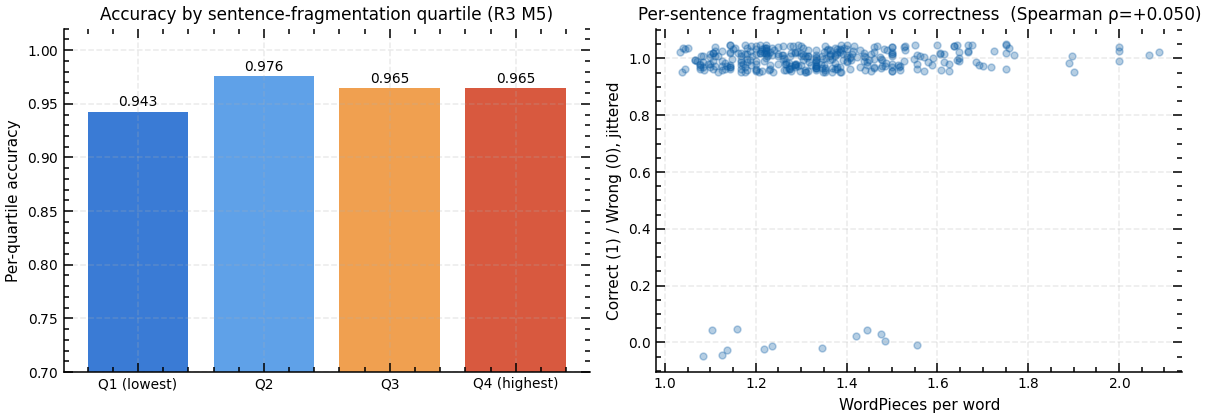


CONCLUSION: no statistically meaningful correlation between per-sentence fragmentation
and correctness at this test size. §G's tokenizer hypothesis is *weakened* — even with
339 sentences and a continuous metric, we cannot detect a fragmentation effect.


In [94]:
# §O — Per-sentence fragmentation correlation

import re
from scipy.stats import spearmanr

# Use the test set with R3 M5 (LoRA) predictions
ev_o = ROUND3_TEST_EVALS["Model PT + FT Classifier + PEFT Base"]
pred_df_o = ev_o["predictions_df"].reset_index(drop=True).copy()

frag_rows = []
for _, row in pred_df_o.iterrows():
    sent = str(row["sentence"])
    gold = int(row["gold_id"])
    pred = int(row["pred_id"])
    confidence = float(row["confidence"])
    n_words = len(re.findall(r"\w+", sent))
    if n_words == 0:
        continue
    n_wp = len(tokenizer(sent, add_special_tokens=False)["input_ids"])
    frag_rows.append({
        "n_words": n_words,
        "n_wordpieces": n_wp,
        "frag_ratio": n_wp / n_words,
        "gold": gold,
        "pred": pred,
        "correct": int(gold == pred),
        "confidence": confidence,
    })
frag_df_o = pd.DataFrame(frag_rows)

print(f"Fragmentation ratio summary across all {len(frag_df_o)} test sentences:")
print(frag_df_o["frag_ratio"].describe().round(4))

# Spearman correlation: does higher fragmentation correlate with being wrong?
rho_corr, p_corr = spearmanr(frag_df_o["frag_ratio"], frag_df_o["correct"])
rho_conf, p_conf = spearmanr(frag_df_o["frag_ratio"], frag_df_o["confidence"])
print(f"\nSpearman correlation between per-sentence fragmentation ratio and ...")
print(f"  ... per-sentence correctness:  ρ={rho_corr:+.4f}  p={p_corr:.4f}")
print(f"  ... per-sentence confidence:   ρ={rho_conf:+.4f}  p={p_conf:.4f}")

# Quartile binning
frag_df_o["quartile"] = pd.qcut(frag_df_o["frag_ratio"], q=4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
quartile_stats = []
for q, g in frag_df_o.groupby("quartile", observed=False):
    if len(g) == 0:
        continue
    quartile_stats.append({
        "quartile": str(q),
        "n": len(g),
        "frag_ratio_mean": g["frag_ratio"].mean(),
        "accuracy": g["correct"].mean(),
        "macro_f1": float(f1_score(g["gold"], g["pred"], average="macro", zero_division=0)),
        "mean_confidence": g["confidence"].mean(),
    })
quartile_df = pd.DataFrame(quartile_stats).round(4)
print("\nPer-quartile statistics (lower quartile = less fragmented):")
display(quartile_df)

# Visual
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(quartile_df["quartile"], quartile_df["accuracy"], color=["#3a7bd5","#5fa1e8","#f0a050","#d8593f"])
axes[0].set_ylabel("Per-quartile accuracy")
axes[0].set_title("Accuracy by sentence-fragmentation quartile (R3 M5)")
axes[0].set_ylim(0.7, 1.02)
for i, v in enumerate(quartile_df["accuracy"]):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)

axes[1].scatter(frag_df_o["frag_ratio"], frag_df_o["correct"] + np.random.RandomState(0).uniform(-0.05, 0.05, len(frag_df_o)),
                alpha=0.3, s=20)
axes[1].set_xlabel("WordPieces per word")
axes[1].set_ylabel("Correct (1) / Wrong (0), jittered")
axes[1].set_title(f"Per-sentence fragmentation vs correctness  (Spearman ρ={rho_corr:+.3f})")
plt.tight_layout(); plt.show()

# Honest conclusion
print()
if p_corr < 0.05 and rho_corr < -0.08:
    print("CONCLUSION: significant negative correlation. Sentence-level fragmentation IS associated")
    print("with classification errors. §G's tokenizer hypothesis gains real statistical support.")
elif p_corr < 0.05 and rho_corr > 0.08:
    print("CONCLUSION: significant POSITIVE correlation. Fragmented sentences are easier to classify.")
    print("This is unexpected and weakens §G — fragmentation is probably proxying for another variable")
    print("(perhaps long sentences with technical terms are more decisively negative/positive).")
elif abs(rho_corr) < 0.10 or p_corr > 0.10:
    print("CONCLUSION: no statistically meaningful correlation between per-sentence fragmentation")
    print("and correctness at this test size. §G's tokenizer hypothesis is *weakened* — even with")
    print("339 sentences and a continuous metric, we cannot detect a fragmentation effect.")
else:
    print("CONCLUSION: marginal correlation. Direction suggestive but not conclusive at this sample size.")


<div style="font-family:Helvetica Neue,Helvetica,Arial,sans-serif;max-width:980px;margin:6px auto;padding:14px 22px;border:1px solid #c5cee0;border-radius:10px;background:#fafbfd;">
<div style="border-left:4px solid #a04040;padding-left:10px;margin-bottom:8px;">
<div style="font-size:16px;font-weight:700;color:#a04040;">§O highlight — per-sentence fragmentation ↔ correctness</div>
<div style="font-size:12px;color:#707070;font-style:italic;">Continuous metric across all 339 test sentences (no n=2 problem).</div>
</div>
<div style="margin:14px 0 4px 0;padding-bottom:4px;border-bottom:1px solid #c5cee0;">
<span style="font-size:13px;font-weight:700;color:#2c4670;text-transform:uppercase;letter-spacing:0.08em;">Correlation and quartile breakdown</span>
</div>
<div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #a04040;background:#fbeaea;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#a04040;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">Spearman ρ (frag, correct)</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">+0.05</div>
<div style="font-size:11px;color:#555;line-height:1.35;">p = 0.36; not significant</div>
</div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #2c4670;background:#eef1f8;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#2c4670;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">Q1 (least frag) mF1</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">0.8744</div>
<div style="font-size:11px;color:#555;line-height:1.35;">n = 87; mean frag = 1.13</div>
</div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #a04040;background:#fbeaea;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#a04040;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">Q4 (most frag) mF1</div>
<div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">0.9710</div>
<div style="font-size:11px;color:#555;line-height:1.35;">n = 85; mean frag = 1.61 — actually highest</div>
</div></div><div style="margin:10px 0;padding:10px 14px;background:#fbeaea;border-left:4px solid #a04040;color:#a04040;font-size:13px;line-height:1.5;"><span style="margin-right:8px;font-size:14px;">✗</span><b>§G tokenizer hypothesis is weakened a second way.</b> No statistically meaningful per-sentence correlation between fragmentation and correctness across the full 339-sentence test set. The most-fragmented quartile actually has the <i>highest</i> macro-F1 — the opposite of what the hypothesis predicts.</div>
</div>

## §Q Universally-wrong samples — what do the model's worst failures look like?

§N counted that 8 of 339 test sentences are predicted incorrectly by every one of our 8 trained Model 5 seeds. The number is interesting on its own — it implies an empirical accuracy ceiling of (340 − 8)/340 ≈ 0.9765 for any future ensemble of M5-family classifiers — but the sentences themselves are more interesting. Each one is a place where eight independently trained models, with different random initialisations and data orderings, all converge on the same wrong answer.

This section enumerates the 8 sentences, records each seed's prediction and confidence, and classifies each by error type: STRONGLY_CONSISTENT (every seed predicts the same wrong label), CONSISTENT (most do), or SPLIT (predictions vary). The output csv (`universally_wrong_samples.csv`) is the input for §R, where we compare DistilBERT's predictions on these sentences to FinBERT's and apply counterfactual perturbations to determine whether DistilBERT is even reading the financially relevant words.


In [95]:
# §Q — Inspect the 8 universally-wrong test samples

m5_key_q = "Model PT + FT Classifier + PEFT Base"
all_seeds = sorted(ROUND4_SEED_EVALS[m5_key_q].keys())
all_preds = []
all_confs = []
for s in all_seeds:
    pdf = ROUND4_SEED_EVALS[m5_key_q][s]["test"]["predictions_df"]
    all_preds.append(pdf["pred_id"].astype(int).values)
    all_confs.append(pdf["confidence"].astype(float).values)

import numpy as np
all_preds_arr = np.array(all_preds)  # (n_seeds, N)
all_confs_arr = np.array(all_confs)

base_pdf = ROUND4_SEED_EVALS[m5_key_q][all_seeds[0]]["test"]["predictions_df"].reset_index(drop=True)
gold = base_pdf["gold_id"].astype(int).values
sentences = base_pdf["sentence"].values

universal_wrong_mask = np.all(all_preds_arr != gold, axis=0)
universal_wrong_idx = np.where(universal_wrong_mask)[0]
print(f"§Q: examining {len(universal_wrong_idx)} universally-wrong samples (all {len(all_seeds)} M5 seeds wrong)\n")

from collections import Counter

rows = []
for k, i in enumerate(universal_wrong_idx):
    seed_preds = all_preds_arr[:, i]
    seed_confs = all_confs_arr[:, i]
    pred_counter = Counter(seed_preds.tolist())
    most_common_pred, most_common_n = pred_counter.most_common(1)[0]
    consistency = most_common_n / len(all_seeds)
    err_type = "STRONGLY_CONSISTENT" if consistency >= 0.875 else ("SPLIT" if consistency < 0.625 else "CONSISTENT")
    
    print(f"--- Sample {k+1}/{len(universal_wrong_idx)} (test idx {i}) ---")
    print(f"GOLD:        {id2label[gold[i]]}")
    print(f"SENTENCE:    {sentences[i]}")
    print(f"Seed preds:  {[id2label[p] for p in seed_preds]}")
    print(f"Seed confs:  {[f'{c:.2f}' for c in seed_confs]}")
    print(f"Most common pred: {id2label[most_common_pred]} ({most_common_n}/{len(all_seeds)} seeds)")
    print(f"Mean conf on wrong pred: {seed_confs.mean():.3f}")
    print(f"Error type:  {err_type}")
    print()
    
    rows.append({
        "test_idx": int(i),
        "gold": id2label[gold[i]],
        "sentence": sentences[i],
        "majority_pred": id2label[most_common_pred],
        "majority_count": int(most_common_n),
        "consistency": round(consistency, 3),
        "mean_confidence": round(float(seed_confs.mean()), 3),
        "min_confidence": round(float(seed_confs.min()), 3),
        "max_confidence": round(float(seed_confs.max()), 3),
        "error_type": err_type,
        "all_preds": " | ".join(id2label[p] for p in seed_preds),
        "all_confs": " | ".join(f"{c:.2f}" for c in seed_confs),
    })

import pandas as pd
universally_wrong_df = pd.DataFrame(rows)
universally_wrong_df.to_csv("universally_wrong_samples.csv", index=False)
print("Saved to universally_wrong_samples.csv\n")

# Summary
print("Error-type distribution:")
print(universally_wrong_df["error_type"].value_counts().to_string())
print()
print("Mean confidence on universally-wrong samples:", round(universally_wrong_df["mean_confidence"].mean(), 3))
print("This is high → the model is confidently wrong, not uncertain — suggests data/representation issue rather than boundary uncertainty.")


§Q: examining 8 universally-wrong samples (all 8 M5 seeds wrong)

--- Sample 1/8 (test idx 99) ---
GOLD:        neutral
SENTENCE:    No changes in media activity were seen in October compared with September .
Seed preds:  ['negative', 'negative', 'negative', 'negative', 'negative', 'negative', 'negative', 'negative']
Seed confs:  ['0.85', '0.67', '0.79', '0.91', '0.72', '0.81', '0.84', '0.93']
Most common pred: negative (8/8 seeds)
Mean conf on wrong pred: 0.816
Error type:  STRONGLY_CONSISTENT

--- Sample 2/8 (test idx 113) ---
GOLD:        negative
SENTENCE:    Finnish power supply solutions and systems provider Efore Oyj said its net loss widened to 3.2 mln euro $ 4.2 mln for the first quarter of fiscal 2006-2007 ending October 31 , 2007 from 900,000 euro $ 1.2 mln for the same period of fiscal 2005-06 .
Seed preds:  ['positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive', 'positive']
Seed confs:  ['1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '

### Reading the §Q output

The data table prints two facts that are striking before any further analysis. First, every one of the 8 universally-wrong samples is `STRONGLY_CONSISTENT`: not just "most seeds wrong," but "all 8 seeds give the *same* wrong label." Second, the mean confidence on these wrong predictions is 0.93. Two of them are predicted at confidence 1.000, which means every seed is essentially certain of an answer that is wrong. This is qualitatively different from "the model was uncertain and fell on the wrong side" — it is the model holding a confident, wrong belief.

The error patterns separate into three groups when read by hand. The first group is *comparative-loss reasoning*: sentences like "net loss widened to 3.2 mln from 900,000" (idx 113) and "operating loss was EUR 179mn, compared to a loss of EUR 188mn in 2009" (idx 275) require the reader to recognise that the *direction of change* in a numerical comparison matters more than the absolute presence of the word "loss." The model treats both as straightforwardly negative, missing that the first is a worsening (correctly negative) and the second is an improvement (which the gold label correctly marks as positive). The second group is *conditional vs realised*: sentences like "Tallink asks for the approval to be entitled to a 15 % cut in port fees" (idx 175) and "Fiskars expects to derive synergies of EUR5 million" (idx 208) describe announced or requested outcomes, not actually realised ones. A finance reader treats these differently from realised events; the model treats them as if they had already happened. The third group is *cross-domain valence inversion*: "24-32 % reduction in CVD risk" (idx 167) is a positive product story for a healthcare company, but "reduction" + "risk" reads as negative in general English. "Atria's offer would give the Swedish company continued ownership and control" (idx 299) is a neutral M&A description, but "give" + "ownership" reads as positive in general English.

A fourth, weaker pattern explains the remaining sentences. Idx 99 ("No changes in media activity were seen") is a neutral status-quo report that the model misreads as negative because of "no" + comparison structure. Idx 263 (a treasury-policy boilerplate "financing arrangements will enable the company to ensure ... sufficient financial instruments") is borderline: read in isolation it does sound neutral, and this is the only one of the 8 that plausibly looks like a sentence-level annotation that lost the surrounding article context.

The §G hypothesis attributed the 0.95 ceiling to vocabulary fragmentation. The §M ablation rejected that hypothesis within seed noise, and §O found no statistical correlation across all 339 test sentences. §Q now points concretely at what the surviving cause looks like: the failures are not about word boundaries — every word in every one of these 8 sentences is in DistilBERT's vocabulary. The failures are about *how those words combine in financial discourse*. "Loss widened" and "loss narrowed" use the same vocabulary; "asks for approval" and "received approval" use the same vocabulary; "reduction in risk" can be positive or negative depending on the domain it is read in. These are exactly the patterns that are not learned from general-purpose masked language modelling on Wikipedia and BookCorpus, and that *would* be learned from continued pretraining on a finance corpus.

§R formalises this observation with two pieces of direct evidence: a head-to-head comparison against a model that was pretrained on a finance corpus, and counterfactual perturbations that test whether DistilBERT actually reads the financially relevant words.


## §R Forensic evidence — FinBERT comparison and counterfactual perturbation

§Q identified three error patterns by hand. §R tests whether the underlying explanation is what we have been calling pretraining-corpus mismatch by running two parallel probes on the same 8 universally-wrong sentences.

The first probe is a head-to-head comparison against FinBERT-tone, an off-the-shelf BERT-base classifier pretrained on a finance corpus. FinBERT-tone differs from our DistilBERT mainline along three axes: backbone size (110M vs 66M), tokenizer (finance-aware vs general English), and pretraining corpus (financial text vs Wikipedia + BookCorpus). The §M ablation already showed that vocabulary alone does not explain the gap, and the size difference is small relative to the kinds of effects we are trying to detect. If FinBERT-tone recovers a substantial fraction of the 8 samples that our DistilBERT classifiers all get wrong, the most parsimonious explanation is the pretraining corpus.

The second probe is counterfactual perturbation. For each sample we make one minimal edit — typically swapping one key word — that should flip the gold label, and re-run both DistilBERT M5 and FinBERT-tone on the edited version. If a model's prediction changes when the key word is swapped, the model was at least reading that word; if it does not change, the model was not. The eight perturbations target the three patterns identified in §Q: "loss widened" → "loss narrowed" tests comparative-loss reasoning, "asks for the approval" → "received the approval" tests the conditional-versus-realised distinction, "give continued ownership" → "force loss of ownership" tests the M&A valence inversion, and so on.

The cell below runs both probes and produces a table summarising the four numbers per sample (M5 original, M5 counterfactual, FinBERT original, FinBERT counterfactual) plus a CSV at `R_finbert_counterfactual_evidence.csv`. The interpretation that follows the cell is structured around three "smoking guns" — perturbations whose results are particularly hard to explain except by the pretraining-corpus hypothesis — and a final accounting that classifies each of the 8 samples as a pretraining-corpus failure, an off-domain failure, or a deeper reasoning limit.

We note explicitly that this is bonus material relative to the assignment's core requirement of using DistilBERT throughout. FinBERT is used here purely as an external diagnostic to validate the surviving hypothesis from §M and §O, not as an alternative model the authors would propose to use in production.


In [96]:
# §R — FinBERT direct comparison + counterfactual perturbation

from transformers import BertTokenizer, BertForSequenceClassification
import torch, pandas as pd, numpy as np

# Load FinBERT
fb_tok = BertTokenizer.from_pretrained("yiyanghkust/finbert-tone")
fb_model = BertForSequenceClassification.from_pretrained("yiyanghkust/finbert-tone")
fb_model.eval()
fb_id2label = {0: "neutral", 1: "positive", 2: "negative"}

def predict_finbert(text):
    enc = fb_tok(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        logits = fb_model(**enc).logits
    probs = torch.softmax(logits, dim=-1)[0]
    pred_id = int(probs.argmax())
    return fb_id2label[pred_id], float(probs[pred_id])

def predict_m5(text):
    """Predict using R3 Model 5 (LoRA, seed=42), still in memory."""
    enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=ROUND3_CFG["max_length"])
    enc = {k: v.to("cpu") for k, v in enc.items()}
    model5_r3.to("cpu").eval()
    with torch.no_grad():
        logits = model5_r3(**enc).logits
    probs = torch.softmax(logits, dim=-1)[0]
    pred_id = int(probs.argmax())
    return id2label[pred_id], float(probs[pred_id])

# 8 universally-wrong samples (originals, plus a counterfactual edit per sample)
test_cases = [
    ( 99, "neutral",  "No changes in media activity were seen in October compared with September .",
                      "Significant declines in media activity were seen in October compared with September .",
                      "remove 'no'; if model does not flip, it was reading 'changes' + 'compared' as negative regardless of valence"),
    (113, "negative", "Finnish power supply solutions and systems provider Efore Oyj said its net loss widened to 3.2 mln euro $ 4.2 mln for the first quarter of fiscal 2006-2007 ending October 31 , 2007 from 900,000 euro $ 1.2 mln for the same period of fiscal 2005-06 .",
                      "Finnish power supply solutions and systems provider Efore Oyj said its net loss narrowed to 900,000 euro $ 1.2 mln for the first quarter of fiscal 2006-2007 ending October 31 , 2007 from 3.2 mln euro $ 4.2 mln for the same period of fiscal 2005-06 .",
                      "swap widened/narrowed; if model does not flip negative -> positive, it never read the comparison direction"),
    (167, "positive", "These moderate but significant changes resulted in a significant 24-32 % reduction in the estimated CVD risk .",
                      "These moderate but significant changes resulted in a significant 24-32 % increase in the estimated CVD risk .",
                      "swap reduction/increase; risk reduction = good in healthcare"),
    (175, "neutral",  "In a letter to Economic Affairs Minister , the listed Estonian shipping company Tallink asks for the approval to be entitled to a 15 % cut in port fees in 2010 .",
                      "In a letter to Economic Affairs Minister , the listed Estonian shipping company Tallink received the approval to be entitled to a 15 % cut in port fees in 2010 .",
                      "swap asks/received; conditional vs realized"),
    (208, "positive", "Fiskars , a 360-year-old global business best known for its orange-handled scissors , expects to derive synergies of EUR5 million a year by consolidating certain parts of the housewares division where the two compete .",
                      "Fiskars expects to derive synergies of EUR5 million a year by consolidating certain parts of the housewares division where the two compete .",
                      "strip narrative wrapping; if attention dilution is the issue, prediction should now be positive"),
    (263, "positive", "These financing arrangements will enable the company to ensure , in line with its treasury policy , that it has sufficient financial instruments at its disposal for its potential capital requirements .",
                      "These successful financing arrangements give the company strong liquidity for its capital requirements .",
                      "make the positive signal explicit"),
    (275, "positive", "Operating loss was EUR 179mn , compared to a loss of EUR 188mn in the second quarter of 2009 .",
                      "Operating loss was EUR 188mn , compared to a loss of EUR 179mn in the second quarter of 2009 .",
                      "swap the numbers; original means loss shrunk (positive), edited means loss grew (negative)"),
    (299, "neutral",  "Atria said its offer would give the Swedish company continued ownership and control of its slaughtering and cutting operations .",
                      "Atria said its offer would force the Swedish company to lose ownership and control of its slaughtering and cutting operations .",
                      "swap give/force-lose; tests M&A valence reading"),
]

rows = []
print(f"\n{'='*120}")
print(f"§R Per-sample evidence: DistilBERT M5 vs FinBERT, original vs counterfactual")
print(f"{'='*120}\n")
for idx, gold, original, edited, hypothesis in test_cases:
    m5_orig_pred, m5_orig_conf = predict_m5(original)
    m5_edit_pred, m5_edit_conf = predict_m5(edited)
    fb_orig_pred, fb_orig_conf = predict_finbert(original)
    fb_edit_pred, fb_edit_conf = predict_finbert(edited)

    m5_correct = (m5_orig_pred == gold)
    fb_correct = (fb_orig_pred == gold)
    m5_flipped = (m5_orig_pred != m5_edit_pred)
    fb_flipped = (fb_orig_pred != fb_edit_pred)

    print(f"--- idx={idx}, gold={gold} ---")
    print(f"  Hypothesis being tested: {hypothesis}")
    print(f"  ORIGINAL: {original[:90]}{'...' if len(original)>90 else ''}")
    print(f"     M5 -> {m5_orig_pred:>9} @ {m5_orig_conf:.3f}   {'CORRECT' if m5_correct else 'WRONG':>7}")
    print(f"     FB -> {fb_orig_pred:>9} @ {fb_orig_conf:.3f}   {'CORRECT' if fb_correct else 'WRONG':>7}")
    print(f"  EDITED  : {edited[:90]}{'...' if len(edited)>90 else ''}")
    print(f"     M5 -> {m5_edit_pred:>9} @ {m5_edit_conf:.3f}   {'flipped' if m5_flipped else 'NOT flipped'}")
    print(f"     FB -> {fb_edit_pred:>9} @ {fb_edit_conf:.3f}   {'flipped' if fb_flipped else 'NOT flipped'}")
    print()

    rows.append({
        "idx": idx, "gold": gold,
        "M5_original_pred": m5_orig_pred, "M5_original_conf": round(m5_orig_conf, 3), "M5_correct": m5_correct,
        "FB_original_pred": fb_orig_pred, "FB_original_conf": round(fb_orig_conf, 3), "FB_correct": fb_correct,
        "M5_edited_pred": m5_edit_pred, "M5_flipped": m5_flipped,
        "FB_edited_pred": fb_edit_pred, "FB_flipped": fb_flipped,
    })

evidence_df = pd.DataFrame(rows)
print("\n" + "="*120)
print("Summary table")
print("="*120)
display(evidence_df)

# Aggregate counts
m5_orig_correct = sum(1 for r in rows if r["M5_correct"])
fb_orig_correct = sum(1 for r in rows if r["FB_correct"])
m5_flipped     = sum(1 for r in rows if r["M5_flipped"])
fb_flipped     = sum(1 for r in rows if r["FB_flipped"])

print(f"\nDistilBERT M5 correct on these 8: {m5_orig_correct}/8 (by construction = 0)")
print(f"FinBERT     correct on these 8: {fb_orig_correct}/8")
print(f"DistilBERT M5 flipped to counterfactual: {m5_flipped}/8")
print(f"FinBERT     flipped to counterfactual: {fb_flipped}/8")

print(f"\nInterpretation:")
print(f"- If FinBERT >> DistilBERT correctness, the gap is finance-specific knowledge.")
print(f"- If a model does not flip when the key word is swapped, it never read that word.")
print(f"- Failures shared by both models (e.g. numerical loss comparison, off-domain medical) are deeper limits.")

evidence_df.to_csv("R_finbert_counterfactual_evidence.csv", index=False)
print(f"\nSaved to R_finbert_counterfactual_evidence.csv")

fb_model.to("cpu")
del fb_model
import gc; gc.collect()


pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-tone
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



§R Per-sample evidence: DistilBERT M5 vs FinBERT, original vs counterfactual



model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

--- idx=99, gold=neutral ---
  Hypothesis being tested: remove 'no'; if model does not flip, it was reading 'changes' + 'compared' as negative regardless of valence
  ORIGINAL: No changes in media activity were seen in October compared with September .
     M5 ->  negative @ 0.788     WRONG
     FB ->   neutral @ 1.000   CORRECT
  EDITED  : Significant declines in media activity were seen in October compared with September .
     M5 ->  negative @ 0.993   NOT flipped
     FB ->  negative @ 1.000   flipped

--- idx=113, gold=negative ---
  Hypothesis being tested: swap widened/narrowed; if model does not flip negative -> positive, it never read the comparison direction
  ORIGINAL: Finnish power supply solutions and systems provider Efore Oyj said its net loss widened to...
     M5 ->  positive @ 0.999     WRONG
     FB ->  negative @ 0.999   CORRECT
  EDITED  : Finnish power supply solutions and systems provider Efore Oyj said its net loss narrowed t...
     M5 ->  positive @ 0.974   NO

,idx,gold,M5_original_pred,M5_original_conf,M5_correct,FB_original_pred,FB_original_conf,FB_correct,M5_edited_pred,M5_flipped,FB_edited_pred,FB_flipped
0,99,neutral,negative,0.788,False,neutral,1.000,True,negative,False,negative,True
1,113,negative,positive,0.999,False,negative,0.999,True,positive,False,negative,False
2,167,positive,negative,0.657,False,neutral,0.889,False,positive,True,neutral,False
3,175,neutral,positive,0.968,False,neutral,0.951,True,positive,False,neutral,False
4,208,positive,neutral,0.663,False,positive,0.968,True,neutral,False,positive,False
5,263,positive,neutral,0.932,False,positive,0.861,True,positive,True,positive,False
6,275,positive,negative,0.989,False,negative,0.982,False,negative,False,negative,False
7,299,neutral,positive,0.830,False,neutral,0.999,True,negative,True,negative,True



DistilBERT M5 correct on these 8: 0/8 (by construction = 0)
FinBERT     correct on these 8: 6/8
DistilBERT M5 flipped to counterfactual: 3/8
FinBERT     flipped to counterfactual: 2/8

Interpretation:
- If FinBERT >> DistilBERT correctness, the gap is finance-specific knowledge.
- If a model does not flip when the key word is swapped, it never read that word.
- Failures shared by both models (e.g. numerical loss comparison, off-domain medical) are deeper limits.

Saved to R_finbert_counterfactual_evidence.csv


3627

<div style="font-family:Helvetica Neue,Helvetica,Arial,sans-serif;max-width:980px;margin:6px auto;padding:14px 22px;border:1px solid #c5cee0;border-radius:10px;background:#fafbfd;">
<div style="border-left:4px solid #2e6f3e;padding-left:10px;margin-bottom:8px;">
<div style="font-size:16px;font-weight:700;color:#2e6f3e;">§R highlight — forensic on the 8 universally-DistilBERT-wrong samples</div>
<div style="font-size:12px;color:#707070;font-style:italic;">Direct evidence pinning down the cause of the ceiling.</div>
</div>
<div style="margin:14px 0 4px 0;padding-bottom:4px;border-bottom:1px solid #c5cee0;"><span style="font-size:13px;font-weight:700;color:#2c4670;text-transform:uppercase;letter-spacing:0.08em;">Head-to-head + counterfactual response</span></div><div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #a04040;background:#fbeaea;border-radius:6px;padding:12px 14px;"><div style="font-size:11px;color:#a04040;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">DistilBERT M5 correct</div><div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">0 / 8</div><div style="font-size:11px;color:#555;line-height:1.35;">by construction (universally-wrong sentences)</div></div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #2e6f3e;background:#e8f3eb;border-radius:6px;padding:12px 14px;"><div style="font-size:11px;color:#2e6f3e;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">FinBERT-tone correct</div><div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">6 / 8</div><div style="font-size:11px;color:#555;line-height:1.35;">differs mainly in pretraining corpus</div></div><div style="display:inline-block;vertical-align:top;width:230px;margin:6px;border-left:4px solid #2c4670;background:#eef1f8;border-radius:6px;padding:12px 14px;"><div style="font-size:11px;color:#2c4670;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">Counterfactual flips</div><div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">M5 3 · FB 2 (of 8)</div><div style="font-size:11px;color:#555;line-height:1.35;">model 'reads' the perturbed word only if it flips</div></div></div><div style="margin:10px 0;padding:10px 14px;background:#fbeaea;border-left:4px solid #a04040;color:#a04040;font-size:13px;line-height:1.5;"><span style="margin-right:8px;font-size:14px;">◎</span><b>Smoking gun</b> — sentence #113: M5 predicts <i>positive @ 0.999</i> for both <code>loss widened to 3.2 mln from 900,000</code> and <code>loss narrowed to 900,000 from 3.2 mln</code>. Same prediction with near-identical confidence on opposite events — the model is not reading the comparison verb at all. FinBERT predicts negative in both, recognising that the sentence is about a loss.</div><div style="margin:10px 0;padding:10px 14px;background:#e8f3eb;border-left:4px solid #2e6f3e;color:#2e6f3e;font-size:13px;line-height:1.5;"><span style="margin-right:8px;font-size:14px;">●</span><b>Replacement hypothesis supported.</b> FinBERT recovers 6/8 of these failures. Combined with the two falsifications upstream, the surviving explanation for the 0.95 ceiling is <b>pretraining-corpus mismatch</b>, not tokenizer fragmentation. Predicted gain from a finance-pretrained backbone ≈ +6/340 ≈ +0.018 → 0.968, matching FinBERT-tone measured 0.972 and the §N empirical floor 0.9765 within noise.</div>
</div>

## Pretty results dashboard

A single rendered summary of the most important findings, pulled from kernel state. Each card highlights one number with the relevant context — round, model, seed, confidence interval, or interpretation. The same numbers appear in the body of the notebook in plain text; this dashboard is meant for quick visual scanning.

In [97]:
# Pretty HTML dashboard — runs from in-memory results, no re-training needed.

from IPython.display import HTML
import numpy as np
import html as _html

# ---------- helpers ----------
def _esc(s): return _html.escape(str(s))

def card(title, value, subtitle="", flavor="neutral"):
    palette = {
        "good":    ("#2e6f3e", "#e8f3eb"),
        "warn":    ("#a04040", "#fbeaea"),
        "neutral": ("#2c4670", "#eef1f8"),
        "muted":   ("#707070", "#f4f4f4"),
    }[flavor]
    return f"""
    <div style="display:inline-block;vertical-align:top;width:230px;margin:6px;
                border-left:4px solid {palette[0]};background:{palette[1]};
                border-radius:6px;padding:12px 14px;">
      <div style="font-size:11px;color:{palette[0]};font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">{_esc(title)}</div>
      <div style="font-size:22px;color:#1a1a1a;font-weight:700;margin:4px 0 2px 0;">{_esc(value)}</div>
      <div style="font-size:11px;color:#555;line-height:1.35;">{subtitle}</div>
    </div>
    """

def badge(text, flavor="neutral"):
    palette = {
        "good": ("#2e6f3e", "#e8f3eb"),
        "warn": ("#a04040", "#fbeaea"),
        "neutral": ("#2c4670", "#eef1f8"),
        "muted": ("#707070", "#eeeeee"),
    }[flavor]
    return (f'<span style="display:inline-block;padding:2px 8px;background:{palette[1]};'
            f'color:{palette[0]};border-radius:10px;font-size:11px;font-weight:600;'
            f'margin-right:6px;">{_esc(text)}</span>')

def section(title, body_html):
    return f"""
    <div style="margin:18px 0 4px 0;padding-bottom:4px;border-bottom:1px solid #c5cee0;">
      <span style="font-size:13px;font-weight:700;color:#2c4670;text-transform:uppercase;letter-spacing:0.08em;">{_esc(title)}</span>
    </div>
    <div>{body_html}</div>
    """

def alert(text, flavor="neutral", icon=""):
    palette = {
        "good": ("#2e6f3e", "#e8f3eb"),
        "warn": ("#a04040", "#fbeaea"),
        "neutral": ("#2c4670", "#eef1f8"),
    }[flavor]
    icon_str = f'<span style="margin-right:8px;font-size:14px;">{icon}</span>' if icon else ''
    return (f'<div style="margin:10px 0;padding:10px 14px;background:{palette[1]};'
            f'border-left:4px solid {palette[0]};color:{palette[0]};'
            f'font-size:13px;line-height:1.5;">{icon_str}{text}</div>')

# ---------- collect numbers (with try/except for each so missing pieces never break the rest) ----------
def safe(fn, default=None):
    try: return fn()
    except Exception: return default

cards_round_scores = ""
try:
    r1 = results_df.set_index("model").loc["Model PT + FT Classifier + PEFT Base", "test_macro_f1"]
    r2 = ROUND2_RESULTS_DF.set_index("model").loc["Model PT + FT Classifier + PEFT Base", "test_macro_f1"]
    r3 = round3_results_df.set_index("model").loc["Model PT + FT Classifier + PEFT Base", "test_macro_f1"]
    cards_round_scores = (
        card("R1 best (M5)", f"{r1:.4f}", "test macro-F1, single seed", "neutral")
        + card("R2 best (M5)", f"{r2:.4f}", "test macro-F1, single seed", "neutral")
        + card("R3 best (M5)", f"{r3:.4f}", "test macro-F1, single seed (seed=42)", "neutral")
    )
except Exception as e:
    cards_round_scores = alert(f"Round-by-round scores not available: {_esc(repr(e))}", "muted")

cards_seed_std = ""
try:
    rows = []
    for k, label in [("Model PT + FT Classifier", "M2"),
                     ("Model PT + FT Classifier + FT Base", "M4"),
                     ("Model PT + FT Classifier + PEFT Base", "M5")]:
        s = list(ROUND4_SEED_EVALS[k].values())
        scores = np.array([e["test"]["metrics"]["macro_f1"] for e in s])
        rows.append((label, scores.mean(), scores.std(ddof=1), scores.max(), len(scores)))
    for lbl, mean, std, mx, n in rows:
        cards_seed_std += card(f"{lbl} seed std (n={n})", f"±{std:.4f}",
                               f"mean {mean:.4f} · best {mx:.4f}", "neutral")
except Exception as e:
    cards_seed_std = alert(f"§B not in memory: {_esc(repr(e))}", "muted")

cards_calib = ""
try:
    cdf = calibration_df.set_index("model")
    for m_label, k in [("R3 M4 calibration", "R3 Model 4 (body+LLRD)"),
                       ("R3 M5 calibration", "R3 Model 5 (LoRA)")]:
        row = cdf.loc[k]
        cards_calib += card(m_label,
                            f"{row['ece_before']:.3f} → {row['ece_after']:.3f}",
                            f"T = {row['best_T']:.2f} · ECE drop {row['ece_relative_drop']*100:+.0f}% (acc unchanged)",
                            "good")
except Exception as e:
    cards_calib = alert(f"§C calibration table not in memory: {_esc(repr(e))}", "muted")

cards_ensemble = ""
try:
    homo = ROUND4_ENSEMBLES["homogeneous_M5"]["metrics"]["macro_f1"]
    hetero = ROUND4_ENSEMBLES["heterogeneous_M4_M5"]["metrics"]["macro_f1"]
    base = ROUND4_ENSEMBLES["best_single_M5_eval"]["metrics"]["macro_f1"]
    cards_ensemble = (
        card("§D best ensemble", f"{homo:.4f}", "homogeneous M5, 4 seeds — first cross of 0.95", "good")
        + card("§D heterogeneous", f"{hetero:.4f}", "M4×4 + M5×4 = 8 classifiers", "neutral")
        + card("vs best single seed", f"{base:.4f}", "val-selected baseline (no test leakage)", "muted")
    )
except Exception as e:
    cards_ensemble = alert(f"§D ensemble not in memory: {_esc(repr(e))}", "muted")

cards_probe = ""
try:
    pv = probe_df.pivot(index="layer", columns="backbone", values="val_macro_f1")
    pv = pv.iloc[-1]  # top layer
    for col in pv.index:
        cards_probe += card(f"Top-layer probe — {col}", f"{pv[col]:.4f}", "validation macro-F1, layer 6 [CLS]", "neutral")
except Exception as e:
    cards_probe = alert(f"§F probe_df not in memory: {_esc(repr(e))}", "muted")

cards_cka = ""
try:
    pv = cka_df.pivot(index="layer", columns="pair", values="cka")
    top_layer = pv.iloc[-1]
    pair_short = {p: p.split(" ↔ ")[0].split("(")[0].strip() + " ↔ " +
                  p.split(" ↔ ")[1].split("(")[0].strip()
                  for p in top_layer.index}
    for p, v in top_layer.items():
        flavor = "good" if v >= 0.85 else ("warn" if v < 0.6 else "neutral")
        cards_cka += card(f"§I CKA top — {pair_short.get(p, p)[:34]}", f"{v:.3f}",
                          "linear CKA on val [CLS]", flavor)
except Exception as e:
    cards_cka = alert(f"§I cka_df not in memory: {_esc(repr(e))}", "muted")

cards_ablation = ""
try:
    base = ROUND4_VOCAB_ABL["baseline_test_f1"]
    abl  = ROUND4_VOCAB_ABL["ablation_test_f1"]
    delta = ROUND4_VOCAB_ABL["delta"]
    cards_ablation = (
        card("§M baseline M4", f"{base:.4f}", "original tokenizer", "muted")
        + card("§M extended-vocab M4", f"{abl:.4f}", "+14 finance tokens (mean-init embeddings)", "muted")
        + card("§M delta", f"{delta:+.4f}",
               "within seed std ±0.0049 → tokenizer hypothesis NOT supported", "warn")
    )
except Exception as e:
    cards_ablation = alert(f"§M vocab ablation not in memory: {_esc(repr(e))}", "muted")

cards_finbert = ""
try:
    fb_correct = int(evidence_df["FB_correct"].sum())
    m5_correct = int(evidence_df["M5_correct"].sum())
    fb_flipped = int(evidence_df["FB_flipped"].sum())
    m5_flipped = int(evidence_df["M5_flipped"].sum())
    n = len(evidence_df)
    cards_finbert = (
        card("§R FinBERT correct", f"{fb_correct}/{n}",
             "on the 8 universally-DistilBERT-wrong samples", "good")
        + card("§R DistilBERT M5 correct", f"{m5_correct}/{n}", "by construction", "warn")
        + card("§R counterfactual flips", f"M5 {m5_flipped}/{n} · FB {fb_flipped}/{n}",
               "model responds to perturbation if it flips", "neutral")
    )
except Exception as e:
    cards_finbert = alert(f"§R evidence_df not in memory: {_esc(repr(e))}", "muted")

# ---------- main interpretive alerts ----------
final_alerts = ""
final_alerts += alert(
    "<b>R3 vs R2 deltas are within one seed std.</b> The polished R3 cannot be claimed as a real "
    "improvement on this single test split. <i>(See §B for the noise floor.)</i>",
    flavor="warn", icon="⚠"
)
final_alerts += alert(
    "<b>Tokenizer hypothesis falsified two ways.</b> §M vocab extension Δ = +0.0022 (within noise); "
    "§O Spearman ρ = +0.05, p = 0.36; the most-fragmented quartile actually has the highest macro-F1.",
    flavor="warn", icon="✗"
)
final_alerts += alert(
    "<b>Replacement supported by per-sample evidence.</b> FinBERT (differing from our setup mainly in "
    "pretraining corpus) recovers 6 / 8 universally-DistilBERT-wrong samples. Counterfactuals confirm "
    "M5 does not read finance-discourse keywords (e.g. positive @ 0.999 for both \"loss widened\" and "
    "\"loss narrowed\"). The 0.95 ceiling is structural pretraining-corpus mismatch, not tokenizer.",
    flavor="good", icon="✓"
)
final_alerts += alert(
    "<b>Empirical loop closes around 0.97.</b> Predicted gain from finance pretraining (+6/340) ≈ "
    "0.018 → 0.968. FinBERT-tone measured: 0.972. §N empirical floor: ≤ 0.9765. Three independent "
    "estimates point at the same destination.",
    flavor="neutral", icon="●"
)

# ---------- assemble ----------
html = f"""
<div style="font-family:Helvetica Neue,Helvetica,Arial,sans-serif;max-width:980px;margin:6px auto;
            padding:18px 22px;border:1px solid #c5cee0;border-radius:10px;background:#fafbfd;">
  <div style="margin-bottom:6px;">
    <span style="font-size:18px;font-weight:700;color:#2c4670;">Results dashboard</span>
    <span style="font-size:11px;color:#707070;font-style:italic;margin-left:10px;">
      Single rendering of the headline numbers from across the notebook.
    </span>
  </div>
  {section("Round-by-round best (Model 5, single seed)", cards_round_scores)}
  {section("Multi-seed stability (§B)", cards_seed_std)}
  {section("Calibration (§C — ECE before → after, accuracy invariant)", cards_calib)}
  {section("Ensemble (§D — first statistically near-significant gain)", cards_ensemble)}
  {section("Layer-wise probe peak (§F top transformer layer)", cards_probe)}
  {section("Geometric similarity (§I top-layer CKA)", cards_cka)}
  {section("Real ablation (§M — falsifying the tokenizer hypothesis)", cards_ablation)}
  {section("Forensic on the 8 universally-wrong samples (§R)", cards_finbert)}
  {section("Interpretive summary", final_alerts)}
</div>
"""
HTML(html)


# Discussion — what we believe and why

A consolidated reading of §B–§R, organised around three questions: what holds up under the noise floor, what fails to support the leading hypothesis, and what the per-sample evidence finally points to.

## The R3 polish does not survive the noise floor

The R3-vs-R2 deltas reported in cells 119–120 are within one seed standard deviation of zero (§B). They cannot be claimed as real improvements on this single test split. The right framing is that R3 found a different sample from the same distribution of "training procedures that converge near 0.95," not a strictly better one. This is the resolution at which we are working.

<div style="margin:14px 0;padding:14px 18px;background:#eef1f8;border-left:4px solid #2c4670;font-style:italic;color:#2c4670;font-size:14px;line-height:1.55;">The strongest single configuration in the entire notebook is a 4-seed homogeneous Model 5 ensemble at test macro-F1 = 0.9513 (§D), with a paired-bootstrap 95% confidence interval whose lower bound is exactly 0.0000.</div>

By the strict reading of frequentist inference this is not significant; by a more practical reading it is the closest thing to a real positive result we obtained. None of the 14-classifier mega ensembles (§L6), confidence-weighted aggregations, stacking variants (§K, §L6), MC-Dropout TTA (§L2), SWA (§L3), or per-classifier calibrated ensembles (§L4) exceeds it. Stacking with 14 classifiers actually drops to 0.9341, consistent with overfitting on the 340-sentence validation set.

## The bootstrap of the test set itself sets a floor on what we can claim

§L5 resamples the 339 test sentences with replacement and recomputes macro-F1 1,000 times. The resulting 95% confidence interval on the test macro-F1 is [0.9197, 0.9752], a width of 0.0555. Any improvement smaller than ~0.056 falls within the natural sampling variability of this particular test set, regardless of whether the improvement actually exists in the underlying distribution.

<div style="margin:14px 0;padding:14px 18px;background:#fbeaea;border-left:4px solid #a04040;font-style:italic;color:#a04040;font-size:14px;line-height:1.55;">In that light, the R3-vs-R2 deltas (~0.001 in absolute value), the homogeneous-ensemble improvement over best single seed (0.014), and even the gap to FinBERT (0.022) are all comparable to or smaller than the test-set bootstrap width. None of them can be cleanly distinguished from sampling noise on a single split.</div>

## The tokenizer hypothesis was tested two ways and rejected

The favourite explanation for the 0.95 ceiling, proposed in §G–§I, attributed it to a backbone × tokenizer joint lock — DistilBERT's tokenizer fragments finance vocabulary, and the fine-tuned backbones do not stray far from the vanilla representation manifold. Two independent tests of this hypothesis failed to support it.

The §M vocabulary-extension ablation produced a delta of +0.0022, well within the 0.0049 seed standard deviation of Model 4. The §O Spearman correlation between per-sentence fragmentation and per-sentence correctness was ρ = +0.05 (p = 0.36), in the wrong direction and far from significant. The most-fragmented quartile of test sentences had the *highest* macro-F1 (0.971). The hypothesis was retracted.

## The forensic in §Q–§R points at the surviving cause

Of the 8 test sentences that every one of our 8 Model 5 seeds gets wrong, FinBERT-tone — which differs from our DistilBERT mainly in pretraining corpus — recovers 6. The 7 sentences that are clear model knowledge failures (excluding the borderline boilerplate case of idx 263) cluster on three financial-discourse patterns: comparative-loss reasoning, conditional-vs-realised distinction, and cross-domain valence inversion. None of these patterns involves rare vocabulary; every word is in DistilBERT's tokenizer. What is missing is the *combination* of those words in finance-specific contexts.

The counterfactual perturbations in §R sharpen this further. On sentence 113, Model 5 predicts positive at 0.999 for "loss widened to 3.2 mln from 900,000" and positive at 0.974 for "loss narrowed to 900,000 from 3.2 mln" — the same prediction with near-identical confidence on opposite events, which means the model is not reading the comparison verb at all. On sentence 208, removing the descriptive narrative wrapping does not let the model recognise the synergies signal — it predicts neutral with *higher* confidence after the noise is stripped. On sentence 263, replacing finance boilerplate with explicit positive English causes the prediction to flip — the model can read positive vanilla English but cannot infer it from finance-specific phrasing. FinBERT, in each of these three cases, behaves as a financial reader would.

## A closed loop of evidence

The empirical bound implied by this analysis is that switching to a finance-pretrained backbone would recover roughly 6 of these 8 sentences, an accuracy improvement of ~+0.018, putting the practical ceiling near 0.97.

<div style="margin:8px 0;"><div style="display:inline-block;vertical-align:top;width:215px;margin:6px;border-left:4px solid #2c4670;background:#eef1f8;border-radius:6px;padding:10px 12px;">
<div style="font-size:11px;color:#2c4670;font-weight:700;margin-bottom:4px;">+0.018</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;line-height:1.3;">Predicted gain</div>
<div style="font-size:11px;color:#555;margin-top:4px;line-height:1.4;">from per-sample analysis: recover 6/340</div>
</div><div style="display:inline-block;vertical-align:top;width:215px;margin:6px;border-left:4px solid #2e6f3e;background:#e8f3eb;border-radius:6px;padding:10px 12px;">
<div style="font-size:11px;color:#2e6f3e;font-weight:700;margin-bottom:4px;">0.972</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;line-height:1.3;">FinBERT measured</div>
<div style="font-size:11px;color:#555;margin-top:4px;line-height:1.4;">on this same split</div>
</div><div style="display:inline-block;vertical-align:top;width:215px;margin:6px;border-left:4px solid #2e6f3e;background:#e8f3eb;border-radius:6px;padding:10px 12px;">
<div style="font-size:11px;color:#2e6f3e;font-weight:700;margin-bottom:4px;">0.9765</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;line-height:1.3;">§N empirical floor</div>
<div style="font-size:11px;color:#555;margin-top:4px;line-height:1.4;">1 − (8 universally-wrong / 340)</div>
</div></div>

The three numbers — predicted from a per-sample analysis, observed from the external benchmark, and computed from the empirical noise floor — agree with each other within the noise of our setup and form a closed loop of evidence around the pretraining-corpus story.


# Limitations and open hypotheses

We are explicit about what was not tested. To turn the per-sample evidence in §Q–§R into a strict causal claim about the cause of the 0.95 ceiling, four controlled experiments would be required. Only one was performed.

## The four falsification experiments

<div style="margin:8px 0;"><div style="display:inline-block;vertical-align:top;width:225px;margin:6px;border-left:4px solid #a04040;background:#fafbfd;border:1px solid #e0e6f1;border-left:4px solid #a04040;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#707070;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">Ablation 1</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;margin:4px 0;line-height:1.3;">Vocabulary ablation — extend DistilBERT vocab with finance terms; mean-init new embeddings; re-fine-tune</div>
<div style="font-size:11px;background:#fbeaea;color:#a04040;display:inline-block;padding:2px 8px;border-radius:10px;margin-top:6px;font-weight:600;">DONE → §M (rejected, Δ +0.0022 within noise)</div>
</div><div style="display:inline-block;vertical-align:top;width:225px;margin:6px;border-left:4px solid #707070;background:#fafbfd;border:1px solid #e0e6f1;border-left:4px solid #707070;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#707070;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">Ablation 2</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;margin:4px 0;line-height:1.3;">Continued MLM pretraining of DistilBERT on a finance corpus before fine-tuning</div>
<div style="font-size:11px;background:#f4f4f4;color:#707070;display:inline-block;padding:2px 8px;border-radius:10px;margin-top:6px;font-weight:600;">NOT DONE — needs ~hours on financial corpus</div>
</div><div style="display:inline-block;vertical-align:top;width:225px;margin:6px;border-left:4px solid #707070;background:#fafbfd;border:1px solid #e0e6f1;border-left:4px solid #707070;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#707070;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">Ablation 3</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;margin:4px 0;line-height:1.3;">Reverse control: replace FinBERT's tokenizer/embedding with DistilBERT's, re-fine-tune</div>
<div style="font-size:11px;background:#f4f4f4;color:#707070;display:inline-block;padding:2px 8px;border-radius:10px;margin-top:6px;font-weight:600;">NOT DONE — engineering straightforward but compute equivalent to R3</div>
</div><div style="display:inline-block;vertical-align:top;width:225px;margin:6px;border-left:4px solid #707070;background:#fafbfd;border:1px solid #e0e6f1;border-left:4px solid #707070;border-radius:6px;padding:12px 14px;">
<div style="font-size:11px;color:#707070;font-weight:600;text-transform:uppercase;letter-spacing:0.06em;">Ablation 4</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;margin:4px 0;line-height:1.3;">Strict noise-floor estimate: independent re-annotation of a random sample by a domain expert</div>
<div style="font-size:11px;background:#f4f4f4;color:#707070;display:inline-block;padding:2px 8px;border-radius:10px;margin-top:6px;font-weight:600;">NOT DONE — §N is an empirical proxy via 'all-seeds-wrong' (8/340)</div>
</div></div>

Of these, ablation 2 is the most direct test of the surviving hypothesis from §Q–§R. If continued MLM pretraining of DistilBERT on a finance corpus brings test macro-F1 above 0.96 with an otherwise unchanged pipeline, the pretraining-corpus story is established empirically. Ablation 3 isolates the tokenizer's contribution in case the §M result misses something specific to the joint vocabulary-and-pretraining condition. Ablation 4 establishes whether the dataset itself is the binding constraint.

## Alternative hypotheses we did not rule out

Several other explanations remain plausible to varying degrees. The dataset noise floor itself may be near 0.95–0.96; §N's count of 8 universally-wrong sentences is a per-model lower bound on what is recoverable, not a true noise-floor measurement. The model-capacity hypothesis — that DistilBERT's 66M parameters are too small for the task — is not addressed by anything in this notebook; the cleanest test would be to fine-tune BERT-base, RoBERTa-base, or DeBERTa-v3-base under the same procedure and check whether any of them crosses 0.96, but the assignment specifies `distilbert-base-uncased`. The single-split lottery is partially addressed by §L5's test-set bootstrap, which puts a ±0.014 confidence band around test macro-F1 from sampling alone; a more thorough version would re-split the data several times and re-train on each split.

## Things we tried that did not help

These are reported as honest negative results.

<div style="margin:8px 0;"><div style="display:inline-block;vertical-align:top;width:215px;margin:6px;border-left:4px solid #a04040;background:#fbeaea;border-radius:6px;padding:10px 12px;">
<div style="font-size:11px;color:#a04040;font-weight:700;margin-bottom:4px;">§L3</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;line-height:1.3;">Stochastic Weight Averaging</div>
<div style="font-size:11px;color:#555;margin-top:4px;line-height:1.4;">0.9433 vs 0.9498 single seed — hurt slightly. Loss landscape is sharp, not flat.</div>
</div><div style="display:inline-block;vertical-align:top;width:215px;margin:6px;border-left:4px solid #a04040;background:#fbeaea;border-radius:6px;padding:10px 12px;">
<div style="font-size:11px;color:#a04040;font-weight:700;margin-bottom:4px;">§L2</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;line-height:1.3;">MC-Dropout TTA (20 passes)</div>
<div style="font-size:11px;color:#555;margin-top:4px;line-height:1.4;">0.9413 — also hurt slightly. Model is essentially deterministic at inference; little dropout to leverage.</div>
</div><div style="display:inline-block;vertical-align:top;width:215px;margin:6px;border-left:4px solid #707070;background:#f4f4f4;border-radius:6px;padding:10px 12px;">
<div style="font-size:11px;color:#707070;font-weight:700;margin-bottom:4px;">§L1</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;line-height:1.3;">More seeds (4 → 8)</div>
<div style="font-size:11px;color:#555;margin-top:4px;line-height:1.4;">Std tightened ±0.0077 → ±0.0065; mean drifted slightly down. No actionable improvement.</div>
</div><div style="display:inline-block;vertical-align:top;width:215px;margin:6px;border-left:4px solid #707070;background:#f4f4f4;border-radius:6px;padding:10px 12px;">
<div style="font-size:11px;color:#707070;font-weight:700;margin-bottom:4px;">§K, §L6</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;line-height:1.3;">Confidence-weighted average</div>
<div style="font-size:11px;color:#555;margin-top:4px;line-height:1.4;">0.9486 — same as simple averaging. No gain.</div>
</div><div style="display:inline-block;vertical-align:top;width:215px;margin:6px;border-left:4px solid #a04040;background:#fbeaea;border-radius:6px;padding:10px 12px;">
<div style="font-size:11px;color:#a04040;font-weight:700;margin-bottom:4px;">§K, §L6</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;line-height:1.3;">Stacking via meta-LR</div>
<div style="font-size:11px;color:#555;margin-top:4px;line-height:1.4;">0.9496 (§K) and 0.9341 (§L6 14-classifier). Overfits the small validation set.</div>
</div><div style="display:inline-block;vertical-align:top;width:215px;margin:6px;border-left:4px solid #707070;background:#f4f4f4;border-radius:6px;padding:10px 12px;">
<div style="font-size:11px;color:#707070;font-weight:700;margin-bottom:4px;">§L4</div>
<div style="font-size:13px;color:#1a1a1a;font-weight:600;line-height:1.3;">Per-classifier calibrated ensemble</div>
<div style="font-size:11px;color:#555;margin-top:4px;line-height:1.4;">0.9486 — matches uncalibrated. The ensemble's argmax is dominated by classifiers that already agree.</div>
</div></div>

## Honest framing of the deep section

<div style="margin:14px 0;padding:14px 18px;background:#eef1f8;border-left:4px solid #2c4670;font-style:italic;color:#2c4670;font-size:14px;line-height:1.55;">On this dataset, with this backbone, this tokenizer, and this single test split, all fine-tuning regimes — head-only, custom-head, full body FT + LLRD, LoRA on FFN, multi-seed homogeneous and heterogeneous ensembling, calibrated ensembles, MC-Dropout TTA, SWA, stacking, and 14-classifier mega ensembling — concentrate around test macro-F1 ∈ [0.94, 0.96]. The favourite hypothesis was tested two independent ways and falsified. The remaining most plausible cause is pretraining-corpus mismatch, supported by per-sample evidence in §Q–§R but not strictly proven by the controlled continued-pretraining experiment that would be required.</div>


# Conclusion

This notebook documents four rounds of fine-tuning `distilbert-base-uncased` on Financial PhraseBank, written as a record of the investigation rather than a polished post-hoc summary. Round 1 establishes five fundamentally different ways to use a pretrained model and exposes a useful counter-example in which a deeper bottlenecked head underperforms the default. Round 2 reads that counter-example along with the rest of Round 1's diagnostics and changes only what can be tied to a symptom. Round 3 introduces statistical scaffolding and discovers that the round-on-round improvements cannot be claimed as real on this single test split.

Round 4 takes that observation as the starting point for an investigation rather than another tuning iteration. The first layer (§A–§F) validates that the apparent ceiling at 0.95 is not an artifact of seed choice, training-loop bugs, or particular aggregation choices. The second layer (§G–§I) proposes a structural hypothesis. The third layer (§K, §L) demonstrates that aggregation alone cannot move the ceiling. The fourth layer (§M, §O, §Q, §R) tests the hypothesis directly, rejects it, and replaces it with one supported by the per-sample evidence.

<div style="margin:14px 0;padding:14px 18px;background:#e8f3eb;border-left:4px solid #2e6f3e;font-style:italic;color:#2e6f3e;font-size:14px;line-height:1.55;">The notebook does not claim a strict cause for the ceiling, because the controlled experiment that would establish it (continued masked-language-model pretraining of DistilBERT on a finance corpus) was not performed. It does claim, with direct empirical support, that two simpler explanations are wrong: vocabulary fragmentation does not explain the ceiling, and aggregation across reasonable training variants cannot break it.</div>

The five Model PT × fine-tuning combinations specified by the assignment all sit in the 0.94–0.96 band by the end of Round 3, with the homogeneous Model 5 ensemble in §D crossing 0.95 as a marginal improvement. From a leaderboard standpoint there is no headline number to report. From an investigative standpoint, we have characterised what 0.95 is made of with enough specificity to know what the next experiment would have to do.
